In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from deepmreye.util import model_opts, data_generator
from deepmreye import preprocess, train, analyse

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

opts = model_opts.get_opts()

train_list = ['/mnt/compneuro/deepmreye_finetuning/processed_data/dataset1_guided_fixations/sub-NDARAA948VFH.npz']
test_list = ['/mnt/compneuro/deepmreye_finetuning/processed_data/dataset1_guided_fixations/sub-NDARAA948VFH.npz']

generators_both = data_generator.create_generators(train_list, train_list)
generators_both = (*generators_both, train_list, train_list)

(model_both, model_inference_both) = train.train_model(
    dataset="prediction_on_stroke_both_eyes",
    generators=generators_both,
    opts=opts,
    return_untrained=True
)

model_inference_both.load_weights('/mnt/compneuro/deepmreye_finetuning/Zosia/datasets_1to5.h5')

print(model_inference_both.input_shape)
print(model_inference_both.output_shape)

for i, layer in enumerate(model_inference_both.layers):
    try:
        print(i, layer.name, layer.output_shape)
    except:
        print(i, layer.name)


# ---------------------------------------------------
# 0) Shared encoder (single eye)
# ---------------------------------------------------

def build_encoder(input_shape=(23, 29, 18, 1)):
    inp = layers.Input(shape=input_shape, name='enc_input')

    x = layers.GaussianNoise(0.1)(inp)
    x = layers.Conv3D(32, 3, padding='same', use_bias=True, name='conv3d')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Conv3D(32, 3, padding='same', use_bias=True, name='conv3d_1')(x)
    x = layers.AveragePooling3D(2)(x)

    x = layers.GroupNormalization(groups=8, name='group_normalization')(x)
    x = layers.Activation('relu', name='activation')(x)
    shortcut = layers.Conv3D(64, 1, padding='same', use_bias=True, name='conv3d_2')(x)
    x = layers.Conv3D(64, 3, padding='same', use_bias=True, name='conv3d_3')(x)
    x = layers.GroupNormalization(groups=8, name='group_normalization_1')(x)
    x = layers.Activation('relu', name='activation_1')(x)
    x = layers.Conv3D(64, 3, padding='same', use_bias=True, name='conv3d_4')(x)
    x = layers.Add(name='add')([x, shortcut])
    x = layers.Conv3D(64, 3, padding='same', use_bias=True, name='conv3d_5')(x)
    x = layers.AveragePooling3D(2)(x)

    x = layers.GroupNormalization(groups=8, name='group_normalization_2')(x)
    x = layers.Activation('relu', name='activation_2')(x)
    shortcut = layers.Conv3D(128, 1, padding='same', use_bias=True, name='conv3d_6')(x)
    x = layers.Conv3D(128, 3, padding='same', use_bias=True, name='conv3d_7')(x)
    x = layers.GroupNormalization(groups=8, name='group_normalization_3')(x)
    x = layers.Activation('relu', name='activation_3')(x)
    x = layers.Conv3D(128, 3, padding='same', use_bias=True, name='conv3d_8')(x)
    x = layers.Add(name='add_1')([x, shortcut])
    x = layers.Conv3D(128, 1, padding='same', use_bias=True, name='conv3d_9')(x)
    shortcut2 = x
    x = layers.GroupNormalization(groups=8, name='group_normalization_4')(x)
    x = layers.Activation('relu', name='activation_4')(x)
    x = layers.Conv3D(128, 3, padding='same', use_bias=True, name='conv3d_10')(x)
    x = layers.GroupNormalization(groups=8, name='group_normalization_5')(x)
    x = layers.Activation('relu', name='activation_5')(x)
    x = layers.Conv3D(128, 3, padding='same', use_bias=True, name='conv3d_11')(x)
    x = layers.Add(name='add_2')([x, shortcut2])
    x = layers.Conv3D(128, 3, padding='same', use_bias=True, name='conv3d_12')(x)
    x = layers.AveragePooling3D(2)(x)

    x = layers.GroupNormalization(groups=8, name='group_normalization_6')(x)
    x = layers.Activation('relu', name='activation_6')(x)
    shortcut = layers.Conv3D(256, 1, padding='same', use_bias=True, name='conv3d_13')(x)
    x = layers.Conv3D(256, 3, padding='same', use_bias=True, name='conv3d_14')(x)
    x = layers.GroupNormalization(groups=8, name='group_normalization_7')(x)
    x = layers.Activation('relu', name='activation_7')(x)
    x = layers.Conv3D(256, 3, padding='same', use_bias=True, name='conv3d_15')(x)
    x = layers.Add(name='add_3')([x, shortcut])

    x = layers.GroupNormalization(groups=8, name='group_normalization_8')(x)
    x = layers.Activation('relu', name='activation_8')(x)
    x = layers.Conv3D(256, 1, padding='same', use_bias=True, name='conv3d_16')(x)
    shortcut3 = x
    x = layers.Conv3D(256, 3, padding='same', use_bias=True, name='conv3d_17')(x)
    x = layers.GroupNormalization(groups=8, name='group_normalization_9')(x)
    x = layers.Activation('relu', name='activation_9')(x)
    x = layers.Conv3D(256, 3, padding='same', use_bias=True, name='conv3d_18')(x)
    x = layers.Add(name='add_4')([x, shortcut3])

    x = layers.GroupNormalization(groups=8, name='group_normalization_10')(x)
    x = layers.Activation('relu', name='activation_10')(x)
    x = layers.Conv3D(256, 1, padding='same', use_bias=True, name='conv3d_19')(x)
    shortcut5 = x
    x = layers.Conv3D(256, 3, padding='same', use_bias=True, name='conv3d_20')(x)
    x = layers.GroupNormalization(groups=8, name='group_normalization_11')(x)
    x = layers.Activation('relu', name='activation_11')(x)
    x = layers.Conv3D(256, 3, padding='same', use_bias=True, name='conv3d_21')(x)
    x = layers.Add(name='add_5')([x, shortcut5])

    x = layers.GroupNormalization(groups=8, name='group_normalization_12')(x)
    x = layers.Activation('relu', name='activation_12')(x)
    x = layers.Flatten(name='flatten')(x)

    return Model(inputs=inp, outputs=x, name='shared_encoder')


def build_two_stream_deepmreye(default_model, input_shape=(23, 29, 18, 1)):
    encoder = build_encoder(input_shape)

    transferable = ['conv3d', 'group_normalization', 'gaussian_noise']
    transferred, skipped = 0, 0

    for layer in default_model.layers:
        if any(t in layer.name for t in transferable):
            try:
                encoder.get_layer(layer.name).set_weights(layer.get_weights())
                transferred += 1
            except Exception:
                skipped += 1

    print(f"Weight transfer: {transferred} transferred, {skipped} skipped")

    try:
        w_default = default_model.get_layer('conv3d').get_weights()[0]
        w_encoder = encoder.get_layer('conv3d').get_weights()[0]
        print("Weight transfer verified:", np.allclose(w_default, w_encoder))
    except Exception as e:
        print("Weight verification skipped:", e)

    right_input = layers.Input(shape=input_shape, name='right_eye')
    left_input  = layers.Input(shape=input_shape, name='left_eye')

    features_right = encoder(right_input)
    features_left  = encoder(left_input)

    combined = layers.Concatenate(name='combined_features')([features_right, features_left])

    def make_gaze_head(feats, name_suffix):
        x = layers.Dense(1024, activation='relu', name=f'dense_a_{name_suffix}')(feats)
        x = layers.Dropout(0.5, name=f'drop_a_{name_suffix}')(x)
        x = layers.Dense(1024, activation='relu', name=f'dense_b_{name_suffix}')(x)
        x = layers.Dropout(0.5, name=f'drop_b_{name_suffix}')(x)
        x = layers.Dense(2, name=f'gaze_{name_suffix}')(x)
        return x

    gaze_right = make_gaze_head(combined, 'right')   # (None, 2)
    gaze_left  = make_gaze_head(combined, 'left')    # (None, 2)

    unc_right = layers.Dense(1024, activation='relu', name='unc_dense_right')(combined)
    unc_right = layers.Dropout(0.5, name='unc_drop_right')(unc_right)
    unc_right = layers.Dense(1, name='uncertainty_right')(unc_right)

    unc_left = layers.Dense(1024, activation='relu', name='unc_dense_left')(combined)
    unc_left = layers.Dropout(0.5, name='unc_drop_left')(unc_left)
    unc_left = layers.Dense(1, name='uncertainty_left')(unc_left)

    model = Model(
        inputs=[right_input, left_input],
        outputs=[gaze_right, gaze_left, unc_right, unc_left],
        name='two_stream_deepmreye'
    )
    return model, encoder


two_stream_model, encoder = build_two_stream_deepmreye(model_inference_both)
two_stream_model.summary()


# ---------------------------------------------------
# 1) Collect file paths and subject split
# ---------------------------------------------------

all_files = []
for root, dirs, files in os.walk('/mnt/compneuro/deepmreye_finetuning/processed_data'):
    if 'dataset7_resting_state' in root:
        continue
    for name in files:
        if name.endswith('.npz'):
            all_files.append(os.path.join(root, name))

print("Total files:", len(all_files))


def get_subject_id(fp):
    return os.path.basename(fp).replace('.npz', '')


subjects = sorted(set(get_subject_id(f) for f in all_files))
rng = np.random.default_rng(42)
subjects_shuffled = np.array(subjects)
rng.shuffle(subjects_shuffled)

split_idx = int(0.8 * len(subjects_shuffled))
train_subj = set(subjects_shuffled[:split_idx])
test_subj = set(subjects_shuffled[split_idx:])

train_files = [f for f in all_files if get_subject_id(f) in train_subj]
test_files = [f for f in all_files if get_subject_id(f) in test_subj]

print("Train files:", len(train_files), "Test files:", len(test_files))


# ---------------------------------------------------
# 2) Paired loader — collapse (10,2) to median (2,)
# ---------------------------------------------------

def load_paired_npz(fp):
    """
    RETURNS:
      right_batch: (N, 23, 29, 18, 1)
      left_batch:  (N, 23, 29, 18, 1)
      y_batch:     (N, 2)
    """
    d = np.load(fp)

    data_keys = sorted(
        [k for k in d.keys() if k.startswith('data_')],
        key=lambda k: int(k.split('_')[1])
    )
    label_keys = sorted(
        [k for k in d.keys() if k.startswith('label_')],
        key=lambda k: int(k.split('_')[1])
    )

    right_list, left_list, y_list = [], [], []

    for dk, lk in zip(data_keys, label_keys):
        tr = d[dk]  # expected shape: (47, 29, 18)

        right_patch = tr[1:24, :, :]   # (23, 29, 18)
        left_patch  = tr[24:47, :, :]  # (23, 29, 18)

        y_full = d[lk].astype(np.float32)  # (10, 2)

        # Skip this TR if all labels are NaN
        if np.all(np.isnan(y_full)):
            continue

        # Median across the 10 sub-TR samples, ignoring NaNs
        y_med = np.nanmedian(y_full, axis=0).astype(np.float32)  # (2,)

        # Optional safety: skip if one coordinate is still NaN after reduction
        if np.any(np.isnan(y_med)):
            continue

        right_list.append(right_patch[..., np.newaxis].astype(np.float32))
        left_list.append(left_patch[..., np.newaxis].astype(np.float32))
        y_list.append(y_med)

    return (
        np.array(right_list, dtype=np.float32),
        np.array(left_list, dtype=np.float32),
        np.array(y_list, dtype=np.float32),
    )

class TwoStreamGenerator(tf.keras.utils.Sequence):
    def __init__(self, file_list, batch_size_samples=16, shuffle=True):
        self.files = list(file_list)
        self.batch_size_samples = batch_size_samples
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return len(self.files)

    def on_epoch_end(self):
        if self.shuffle:
            rng = np.random.default_rng()
            rng.shuffle(self.files)

    def __getitem__(self, idx):
        fp = self.files[idx]
        rights, lefts, ys = load_paired_npz(fp)  # ys: (N_file, 2)

        N = rights.shape[0]
        rng = np.random.default_rng()
        k = min(self.batch_size_samples, N)
        idxs = rng.choice(N, size=k, replace=False)

        rights_batch = rights[idxs]
        lefts_batch  = lefts[idxs]
        ys_batch     = ys[idxs]

        print("RETURNING BATCH:", rights_batch.shape, lefts_batch.shape, ys_batch.shape)

        return [rights_batch, lefts_batch], [ys_batch, ys_batch]


train_gen = TwoStreamGenerator(train_files, batch_size_samples=16, shuffle=True)
val_gen   = TwoStreamGenerator(test_files, batch_size_samples=16, shuffle=False)


# ---------------------------------------------------
# 3) Losses for single (x,y) output
# ---------------------------------------------------

def euclidean_error_loss(y_true, y_pred):
    sq = tf.reduce_sum(tf.square(y_pred - y_true), axis=-1)   # (B,)
    per_sample = tf.sqrt(sq + 1e-8)                           # (B,)
    return tf.reduce_mean(per_sample)

def euclidean_error_per_sample(y_true, y_pred):
    sq = tf.reduce_sum(tf.square(y_pred - y_true), axis=-1)   # (B,)
    return tf.sqrt(sq + 1e-8)


class TwoStreamDeepMReyeTrainer(Model):
    def __init__(self, base_model, pe_weight=0.1):
        super().__init__()
        self.base_model = base_model
        self.pe_weight = pe_weight

        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.led_right_tracker = tf.keras.metrics.Mean(name="led_right")
        self.led_left_tracker = tf.keras.metrics.Mean(name="led_left")
        self.pe_right_tracker = tf.keras.metrics.Mean(name="pe_right")
        self.pe_left_tracker = tf.keras.metrics.Mean(name="pe_left")

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.led_right_tracker,
            self.led_left_tracker,
            self.pe_right_tracker,
            self.pe_left_tracker,
        ]

    def train_step(self, data):
        (x_right, x_left), (y_right, y_left) = data

        with tf.GradientTape() as tape:
            gaze_right, gaze_left, unc_right, unc_left = self.base_model(
                [x_right, x_left], training=True
            )

            led_right = euclidean_error_loss(y_right, gaze_right)
            led_left  = euclidean_error_loss(y_left, gaze_left)

            true_ee_right = euclidean_error_per_sample(y_right, gaze_right)
            true_ee_left  = euclidean_error_per_sample(y_left, gaze_left)

            pred_ee_right = tf.squeeze(unc_right, axis=-1)
            pred_ee_left  = tf.squeeze(unc_left, axis=-1)

            pe_right = tf.reduce_mean(tf.square(pred_ee_right - true_ee_right))
            pe_left  = tf.reduce_mean(tf.square(pred_ee_left - true_ee_left))

            total_loss = led_right + led_left + self.pe_weight * (pe_right + pe_left)

        grads = tape.gradient(total_loss, self.base_model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.base_model.trainable_variables))

        self.loss_tracker.update_state(total_loss)
        self.led_right_tracker.update_state(led_right)
        self.led_left_tracker.update_state(led_left)
        self.pe_right_tracker.update_state(pe_right)
        self.pe_left_tracker.update_state(pe_left)

        return {
            "loss": self.loss_tracker.result(),
            "led_right": self.led_right_tracker.result(),
            "led_left": self.led_left_tracker.result(),
            "pe_right": self.pe_right_tracker.result(),
            "pe_left": self.pe_left_tracker.result(),
        }

    def test_step(self, data):
        (x_right, x_left), (y_right, y_left) = data

        gaze_right, gaze_left, unc_right, unc_left = self.base_model(
            [x_right, x_left], training=False
        )

        led_right = euclidean_error_loss(y_right, gaze_right)
        led_left  = euclidean_error_loss(y_left, gaze_left)

        true_ee_right = euclidean_error_per_sample(y_right, gaze_right)
        true_ee_left  = euclidean_error_per_sample(y_left, gaze_left)

        pred_ee_right = tf.squeeze(unc_right, axis=-1)
        pred_ee_left  = tf.squeeze(unc_left, axis=-1)

        pe_right = tf.reduce_mean(tf.square(pred_ee_right - true_ee_right))
        pe_left  = tf.reduce_mean(tf.square(pred_ee_left - true_ee_left))

        total_loss = led_right + led_left + self.pe_weight * (pe_right + pe_left)

        self.loss_tracker.update_state(total_loss)
        self.led_right_tracker.update_state(led_right)
        self.led_left_tracker.update_state(led_left)
        self.pe_right_tracker.update_state(pe_right)
        self.pe_left_tracker.update_state(pe_left)

        return {
            "loss": self.loss_tracker.result(),
            "led_right": self.led_right_tracker.result(),
            "led_left": self.led_left_tracker.result(),
            "pe_right": self.pe_right_tracker.result(),
            "pe_left": self.pe_left_tracker.result(),
        }


# ---------------------------------------------------
# 4) Compile and train
# ---------------------------------------------------

trainer = TwoStreamDeepMReyeTrainer(two_stream_model, pe_weight=0.1)
trainer.compile(optimizer=tf.keras.optimizers.Adam(1e-4))

cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = trainer.fit(
    train_gen,
    validation_data=val_gen,
    epochs=100,
    callbacks=[cb],
    workers=1,
    use_multiprocessing=False,
)

# after training finishes
two_stream_model.save(
    "/mnt/compneuro/deepmreye_finetuning/two_stream_deepmreye.h5"
)

RuntimeError: Physical devices cannot be modified after being initialized

In [10]:
import os
import numpy as np
import tensorflow as tf
from scipy.stats import pearsonr, spearmanr

# -------- CONFIG --------
model_path = "/mnt/compneuro/deepmreye_finetuning/two_stream_deepmreye.h5"
data_root  = "/mnt/compneuro/deepmreye_finetuning/processed_data"
exclude_dataset = "dataset7_resting_state"
# -------------------------

# ---------- 1. Load saved model ----------
inference_model = tf.keras.models.load_model(model_path, compile=False)
print("Model loaded successfully.")
print("Input shapes :", [i.shape for i in inference_model.inputs])
print("Output shapes:", [o.shape for o in inference_model.outputs])

# ---------- 2. Collect test files ----------
all_files = []
for root, dirs, files in os.walk(data_root):
    if exclude_dataset in root:
        continue
    for name in files:
        if name.endswith('.npz'):
            all_files.append(os.path.join(root, name))

def get_subject_id(fp):
    return os.path.basename(fp).replace('.npz', '')

subjects = sorted(set(get_subject_id(f) for f in all_files))
rng = np.random.default_rng(42)
subjects_shuffled = np.array(subjects)
rng.shuffle(subjects_shuffled)

split_idx = int(0.8 * len(subjects_shuffled))
test_subj = set(subjects_shuffled[split_idx:])
test_files = [f for f in all_files if get_subject_id(f) in test_subj]
print(f"\nTest subjects: {len(test_subj)}, Test files: {len(test_files)}")

# ---------- 3. Data loader ----------
def load_paired_npz(fp):
    d = np.load(fp)
    data_keys  = sorted([k for k in d.keys() if k.startswith('data_')],
                        key=lambda k: int(k.split('_')[1]))
    label_keys = sorted([k for k in d.keys() if k.startswith('label_')],
                        key=lambda k: int(k.split('_')[1]))

    right_list, left_list, y_list = [], [], []
    for dk, lk in zip(data_keys, label_keys):
        tr     = d[dk]
        y_full = d[lk].astype(np.float32)
        if np.all(np.isnan(y_full)):
            continue
        y_med = np.nanmedian(y_full, axis=0).astype(np.float32)
        if np.any(np.isnan(y_med)):
            continue
        right_list.append(tr[1:24, :, :][..., np.newaxis].astype(np.float32))
        left_list.append(tr[24:47, :, :][..., np.newaxis].astype(np.float32))
        y_list.append(y_med)

    return (np.array(right_list, dtype=np.float32),
            np.array(left_list,  dtype=np.float32),
            np.array(y_list,     dtype=np.float32))

# ---------- 4. Per-file evaluation ----------
all_ee_right, all_ee_left     = [], []
all_pred_right, all_pred_left = [], []
all_y = []

per_file_results = []

print(f"\n{'File':50s} | {'N':>5} | {'EE_R':>6} {'EE_L':>6} | "
      f"{'rX_R':>6} {'rX_L':>6} | {'rY_R':>6} {'rY_L':>6}")
print("-" * 115)

for fp in test_files:
    rights, lefts, ys = load_paired_npz(fp)
    if rights.shape[0] == 0:
        print(f"  Skipping (no valid TRs): {os.path.basename(fp)}")
        continue

    preds           = inference_model.predict([rights, lefts], verbose=0)
    gaze_right_pred = preds[0]   # (N, 2)
    gaze_left_pred  = preds[1]   # (N, 2)

    ee_right = np.sqrt(np.sum((gaze_right_pred - ys)**2, axis=-1))
    ee_left  = np.sqrt(np.sum((gaze_left_pred  - ys)**2, axis=-1))

    # Per-file correlations: X and Y axes separately, for right and left predictions
    rX_right, _ = pearsonr(ys[:, 0], gaze_right_pred[:, 0])
    rY_right, _ = pearsonr(ys[:, 1], gaze_right_pred[:, 1])
    rX_left,  _ = pearsonr(ys[:, 0], gaze_left_pred[:, 0])
    rY_left,  _ = pearsonr(ys[:, 1], gaze_left_pred[:, 1])

    all_ee_right.append(ee_right)
    all_ee_left.append(ee_left)
    all_pred_right.append(gaze_right_pred)
    all_pred_left.append(gaze_left_pred)
    all_y.append(ys)

    per_file_results.append({
        'file': os.path.basename(fp),
        'N': rights.shape[0],
        'EE_right': ee_right.mean(), 'EE_left': ee_left.mean(),
        'rX_right': rX_right, 'rY_right': rY_right,
        'rX_left':  rX_left,  'rY_left':  rY_left,
    })

    print(f"{os.path.basename(fp):50s} | {rights.shape[0]:5d} | "
          f"{ee_right.mean():6.3f} {ee_left.mean():6.3f} | "
          f"{rX_right:6.3f} {rX_left:6.3f} | "
          f"{rY_right:6.3f} {rY_left:6.3f}")

# ---------- 5. Aggregate ----------
all_ee_right   = np.concatenate(all_ee_right)
all_ee_left    = np.concatenate(all_ee_left)
all_pred_right = np.concatenate(all_pred_right)
all_pred_left  = np.concatenate(all_pred_left)
all_y          = np.concatenate(all_y)

print("\n========= AGGREGATE SUMMARY =========")
print(f"Total test TRs: {len(all_ee_right)}")
print(f"\n{'Metric':35s} {'Right eye':>12} {'Left eye':>12}")
print("-" * 62)
print(f"{'Mean EE':35s} {all_ee_right.mean():12.3f} {all_ee_left.mean():12.3f}")
print(f"{'Median EE':35s} {np.median(all_ee_right):12.3f} {np.median(all_ee_left):12.3f}")
print(f"{'Std EE':35s} {all_ee_right.std():12.3f} {all_ee_left.std():12.3f}")
print()

for axis_idx, axis_name in zip([0, 1], ['X (horizontal)', 'Y (vertical)']):
    pR, _ = pearsonr(all_y[:, axis_idx], all_pred_right[:, axis_idx])
    pL, _ = pearsonr(all_y[:, axis_idx], all_pred_left[:, axis_idx])
    sR, _ = spearmanr(all_y[:, axis_idx], all_pred_right[:, axis_idx])
    sL, _ = spearmanr(all_y[:, axis_idx], all_pred_left[:, axis_idx])
    maeR  = np.mean(np.abs(all_pred_right[:, axis_idx] - all_y[:, axis_idx]))
    maeL  = np.mean(np.abs(all_pred_left[:, axis_idx]  - all_y[:, axis_idx]))
    biasR = np.mean(all_pred_right[:, axis_idx] - all_y[:, axis_idx])
    biasL = np.mean(all_pred_left[:, axis_idx]  - all_y[:, axis_idx])

    print(f"--- {axis_name} ---")
    print(f"{'Pearson r':35s} {pR:12.3f} {pL:12.3f}")
    print(f"{'Spearman rho':35s} {sR:12.3f} {sL:12.3f}")
    print(f"{'MAE':35s} {maeR:12.3f} {maeL:12.3f}")
    print(f"{'Bias (pred - true)':35s} {biasR:12.3f} {biasL:12.3f}")
    print(f"{'True range [min, max]':35s} [{all_y[:, axis_idx].min():.2f}, {all_y[:, axis_idx].max():.2f}]")
    print(f"{'Pred range right [min, max]':35s} [{all_pred_right[:, axis_idx].min():.2f}, {all_pred_right[:, axis_idx].max():.2f}]")
    print(f"{'Pred range left  [min, max]':35s} [{all_pred_left[:, axis_idx].min():.2f}, {all_pred_left[:, axis_idx].max():.2f}]")
    print()

# ---------- 6. Per-file summary sorted by X correlation ----------
print("\n========= PER-FILE RESULTS (sorted by rX_right) =========")
per_file_results_sorted = sorted(per_file_results, key=lambda x: x['rX_right'], reverse=True)
print(f"{'File':50s} | {'N':>5} | {'rX_R':>6} {'rY_R':>6} | {'rX_L':>6} {'rY_L':>6} | {'EE_R':>6} {'EE_L':>6}")
print("-" * 115)
for r in per_file_results_sorted:
    print(f"{r['file']:50s} | {r['N']:5d} | "
          f"{r['rX_right']:6.3f} {r['rY_right']:6.3f} | "
          f"{r['rX_left']:6.3f} {r['rY_left']:6.3f} | "
          f"{r['EE_right']:6.3f} {r['EE_left']:6.3f}")

Model loaded successfully.
Input shapes : [TensorShape([None, 23, 29, 18, 1]), TensorShape([None, 23, 29, 18, 1])]
Output shapes: [TensorShape([None, 2]), TensorShape([None, 2]), TensorShape([None, 1]), TensorShape([None, 1])]

Test subjects: 25, Test files: 25

File                                               |     N |   EE_R   EE_L |   rX_R   rX_L |   rY_R   rY_L
-------------------------------------------------------------------------------------------------------------------
AW_26_11_14.npz                                    |  2859 |  2.618  2.620 |  0.604  0.599 |  0.284  0.282
AX_19_11_14.npz                                    |  2859 |  1.511  1.495 |  0.895  0.893 |  0.838  0.844
CF_26_11_14.npz                                    |  2858 |  1.413  1.423 |  0.859  0.852 |  0.879  0.881
S09_ET.npz                                         |  2393 |  1.855  1.864 |  0.841  0.843 |  0.797  0.797
S28_ET.npz                                         |  2525 |  1.975  1.967 |  0.785  0

In [2]:
for i, layer in enumerate(inference_model.layers):
    print(i, layer.name, layer.output_shape)

0 right_eye [(None, 23, 29, 18, 1)]
1 left_eye [(None, 23, 29, 18, 1)]
2 shared_encoder (None, 3072)
3 combined_features (None, 6144)
4 dense_a_right (None, 1024)
5 dense_a_left (None, 1024)
6 drop_a_right (None, 1024)
7 drop_a_left (None, 1024)
8 dense_b_right (None, 1024)
9 dense_b_left (None, 1024)
10 unc_dense_right (None, 1024)
11 unc_dense_left (None, 1024)
12 drop_b_right (None, 1024)
13 drop_b_left (None, 1024)
14 unc_drop_right (None, 1024)
15 unc_drop_left (None, 1024)
16 gaze_right (None, 2)
17 gaze_left (None, 2)
18 uncertainty_right (None, 1)
19 uncertainty_left (None, 1)


In [1]:
import os
import numpy as np
import tensorflow as tf
from scipy.stats import pearsonr, spearmanr

# -------- CONFIG --------
model_path       = "/mnt/compneuro/deepmreye_finetuning/two_stream_deepmreye.h5"
sleepy_data_root = "/mnt/compneuro/deepmreye_finetuning/processed_data/dataset7_resting_state/"
# -------------------------

# ---------- 1. Load saved model ----------
inference_model = tf.keras.models.load_model(model_path, compile=False)
print("Model loaded successfully.")

# ---------- 2. Collect all dataset7 npz files ----------
all_files = sorted([
    os.path.join(sleepy_data_root, f)
    for f in os.listdir(sleepy_data_root)
    if f.endswith('.npz')
])
print(f"\nFound {len(all_files)} npz files:")
for f in all_files:
    print(" ", os.path.basename(f))

# ---------- 3. Data loader WITH labels ----------
def load_paired_npz(fp):
    d = np.load(fp)
    data_keys  = sorted([k for k in d.keys() if k.startswith('data_')],
                        key=lambda k: int(k.split('_')[1]))
    label_keys = sorted([k for k in d.keys() if k.startswith('label_')],
                        key=lambda k: int(k.split('_')[1]))

    right_list, left_list, y_list = [], [], []
    for dk, lk in zip(data_keys, label_keys):
        tr     = d[dk]
        y_full = d[lk].astype(np.float32)
        if np.all(np.isnan(y_full)):
            continue
        y_med = np.nanmedian(y_full, axis=0).astype(np.float32)
        if np.any(np.isnan(y_med)):
            continue
        right_list.append(tr[1:24, :, :][..., np.newaxis].astype(np.float32))
        left_list.append(tr[24:47, :, :][..., np.newaxis].astype(np.float32))
        y_list.append(y_med)

    return (np.array(right_list, dtype=np.float32),
            np.array(left_list,  dtype=np.float32),
            np.array(y_list,     dtype=np.float32))

# ---------- 4. Per-file evaluation ----------
all_ee_right, all_ee_left     = [], []
all_pred_right, all_pred_left = [], []
all_y = []
per_file_results = []

print(f"\n{'File':45s} | {'N':>5} | {'EE_R':>6} {'EE_L':>6} | "
      f"{'rX_R':>6} {'rX_L':>6} | {'rY_R':>6} {'rY_L':>6} | "
      f"{'rX_RL':>6} {'rY_RL':>6}")
print("-" * 135)

for fp in all_files:
    rights, lefts, ys = load_paired_npz(fp)
    if rights.shape[0] == 0:
        print(f"  Skipping (no valid TRs): {os.path.basename(fp)}")
        continue

    preds           = inference_model.predict([rights, lefts], verbose=0)
    gaze_right_pred = preds[0]   # (N, 2)
    gaze_left_pred  = preds[1]   # (N, 2)

    ee_right = np.sqrt(np.sum((gaze_right_pred - ys)**2, axis=-1))
    ee_left  = np.sqrt(np.sum((gaze_left_pred  - ys)**2, axis=-1))

    # Correlation with ground truth
    rX_right, _ = pearsonr(ys[:, 0], gaze_right_pred[:, 0])
    rY_right, _ = pearsonr(ys[:, 1], gaze_right_pred[:, 1])
    rX_left,  _ = pearsonr(ys[:, 0], gaze_left_pred[:, 0])
    rY_left,  _ = pearsonr(ys[:, 1], gaze_left_pred[:, 1])

    # Right–left eye prediction consistency
    rX_RL, _ = pearsonr(gaze_right_pred[:, 0], gaze_left_pred[:, 0])  # X: right pred vs left pred
    rY_RL, _ = pearsonr(gaze_right_pred[:, 1], gaze_left_pred[:, 1])  # Y: right pred vs left pred

    all_ee_right.append(ee_right)
    all_ee_left.append(ee_left)
    all_pred_right.append(gaze_right_pred)
    all_pred_left.append(gaze_left_pred)
    all_y.append(ys)

    per_file_results.append({
        'file': os.path.basename(fp),
        'N': rights.shape[0],
        'EE_right': ee_right.mean(), 'EE_left': ee_left.mean(),
        'rX_right': rX_right, 'rY_right': rY_right,
        'rX_left':  rX_left,  'rY_left':  rY_left,
        'rX_RL': rX_RL, 'rY_RL': rY_RL,
    })

    print(f"{os.path.basename(fp):45s} | {rights.shape[0]:5d} | "
          f"{ee_right.mean():6.3f} {ee_left.mean():6.3f} | "
          f"{rX_right:6.3f} {rX_left:6.3f} | "
          f"{rY_right:6.3f} {rY_left:6.3f} | "
          f"{rX_RL:6.3f} {rY_RL:6.3f}")

# ---------- 5. Aggregate ----------
all_ee_right   = np.concatenate(all_ee_right)
all_ee_left    = np.concatenate(all_ee_left)
all_pred_right = np.concatenate(all_pred_right)
all_pred_left  = np.concatenate(all_pred_left)
all_y          = np.concatenate(all_y)

# Aggregate right-left consistency
rX_RL_agg, _ = pearsonr(all_pred_right[:, 0], all_pred_left[:, 0])
rY_RL_agg, _ = pearsonr(all_pred_right[:, 1], all_pred_left[:, 1])

print("\n========= AGGREGATE SUMMARY (dataset7 sleepybrain) =========")
print(f"Total test TRs: {len(all_ee_right)}")
print(f"\n{'Metric':35s} {'Right eye':>12} {'Left eye':>12}")
print("-" * 62)
print(f"{'Mean EE':35s} {all_ee_right.mean():12.3f} {all_ee_left.mean():12.3f}")
print(f"{'Median EE':35s} {np.median(all_ee_right):12.3f} {np.median(all_ee_left):12.3f}")
print(f"{'Std EE':35s} {all_ee_right.std():12.3f} {all_ee_left.std():12.3f}")
print()

for axis_idx, axis_name in zip([0, 1], ['X (horizontal)', 'Y (vertical)']):
    pR, _ = pearsonr(all_y[:, axis_idx], all_pred_right[:, axis_idx])
    pL, _ = pearsonr(all_y[:, axis_idx], all_pred_left[:, axis_idx])
    sR, _ = spearmanr(all_y[:, axis_idx], all_pred_right[:, axis_idx])
    sL, _ = spearmanr(all_y[:, axis_idx], all_pred_left[:, axis_idx])
    maeR  = np.mean(np.abs(all_pred_right[:, axis_idx] - all_y[:, axis_idx]))
    maeL  = np.mean(np.abs(all_pred_left[:, axis_idx]  - all_y[:, axis_idx]))
    biasR = np.mean(all_pred_right[:, axis_idx] - all_y[:, axis_idx])
    biasL = np.mean(all_pred_left[:, axis_idx]  - all_y[:, axis_idx])

    print(f"--- {axis_name} ---")
    print(f"{'Pearson r (vs ground truth)':35s} {pR:12.3f} {pL:12.3f}")
    print(f"{'Spearman rho (vs ground truth)':35s} {sR:12.3f} {sL:12.3f}")
    print(f"{'MAE':35s} {maeR:12.3f} {maeL:12.3f}")
    print(f"{'Bias (pred - true)':35s} {biasR:12.3f} {biasL:12.3f}")
    print(f"{'True range [min, max]':35s} [{all_y[:, axis_idx].min():.2f}, {all_y[:, axis_idx].max():.2f}]")
    print(f"{'Pred range right [min, max]':35s} [{all_pred_right[:, axis_idx].min():.2f}, {all_pred_right[:, axis_idx].max():.2f}]")
    print(f"{'Pred range left  [min, max]':35s} [{all_pred_left[:, axis_idx].min():.2f}, {all_pred_left[:, axis_idx].max():.2f}]")
    print()

print(f"--- Right vs Left eye prediction consistency ---")
print(f"{'Pearson r (X: right pred vs left pred)':35s} {rX_RL_agg:12.3f}")
print(f"{'Pearson r (Y: right pred vs left pred)':35s} {rY_RL_agg:12.3f}")

# ---------- 6. Per-file summary sorted by rX_RL ----------
print("\n========= PER-FILE RESULTS (sorted by rX_RL) =========")
per_file_results_sorted = sorted(per_file_results, key=lambda x: x['rX_RL'], reverse=True)
print(f"{'File':45s} | {'N':>5} | {'rX_R':>6} {'rY_R':>6} | {'rX_L':>6} {'rY_L':>6} | {'rX_RL':>6} {'rY_RL':>6} | {'EE_R':>6} {'EE_L':>6}")
print("-" * 135)
for r in per_file_results_sorted:
    print(f"{r['file']:45s} | {r['N']:5d} | "
          f"{r['rX_right']:6.3f} {r['rY_right']:6.3f} | "
          f"{r['rX_left']:6.3f} {r['rY_left']:6.3f} | "
          f"{r['rX_RL']:6.3f} {r['rY_RL']:6.3f} | "
          f"{r['EE_right']:6.3f} {r['EE_left']:6.3f}")

2026-04-21 09:56:50.417024: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 09:56:50.484882: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-21 09:56:50.484940: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-21 09:56:50.488536: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-21 09:56:50.505809: I tensorflow/core/platform/cpu_feature_guar

Model loaded successfully.

Found 29 npz files:
  9001.npz
  9007.npz
  9008.npz
  9013.npz
  9023.npz
  9025.npz
  9029.npz
  9033.npz
  9041.npz
  9048.npz
  9050.npz
  9053.npz
  9055.npz
  9057.npz
  9063.npz
  9070.npz
  9071.npz
  9074.npz
  9077.npz
  9081.npz
  9082.npz
  9083.npz
  9084.npz
  9085.npz
  9087.npz
  9088.npz
  9091.npz
  9092.npz
  9100.npz

File                                          |     N |   EE_R   EE_L |   rX_R   rX_L |   rY_R   rY_L |  rX_RL  rY_RL
---------------------------------------------------------------------------------------------------------------------------------------


2026-04-21 09:57:05.370112: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-04-21 09:57:05.510686: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-21 09:57:06.639607: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


9001.npz                                      |   182 |  1.997  2.037 | -0.027 -0.033 | -0.077 -0.071 |  0.992  0.996
9007.npz                                      |   182 |  1.704  1.682 |  0.065  0.050 |  0.232  0.193 |  0.995  0.989
9008.npz                                      |   182 |  2.736  2.812 | -0.009 -0.010 |  0.017 -0.009 |  0.998  0.991
9013.npz                                      |   182 |  1.796  1.878 | -0.355 -0.363 |  0.156  0.146 |  0.995  0.993
9023.npz                                      |   182 |  2.446  2.465 |  0.030  0.037 |  0.358  0.367 |  0.998  0.992
9025.npz                                      |   182 |  3.072  3.102 | -0.637 -0.631 | -0.275 -0.239 |  0.999  0.993
9029.npz                                      |   182 |  3.198  3.188 |  0.449  0.453 | -0.003  0.003 |  0.999  0.996
9033.npz                                      |   182 |  1.689  1.684 |  0.170  0.179 | -0.225 -0.206 |  0.995  0.991
9041.npz                                      |   182 | 

In [4]:
import os
import pickle
import numpy as np
import tensorflow as tf
from scipy.stats import pearsonr

# -------- CONFIG --------
model_path       = "/mnt/compneuro/deepmreye_finetuning/two_stream_deepmreye.h5"
sleepy_data_root = "/mnt/compneuro/deepmreye_finetuning/processed_data/dataset7_resting_state/"
save_path_bneck  = "/mnt/compneuro/deepmreye_finetuning/dataset7_bottleneck.pkl"
# -------------------------

# ---------- 1. Load saved model ----------
inference_model = tf.keras.models.load_model(model_path, compile=False)
print("Model loaded successfully.")

# ---------- 2. Build bottleneck sub-models ----------
bottleneck_right = tf.keras.Model(
    inputs  = inference_model.inputs,
    outputs = inference_model.get_layer("dense_b_right").output   # (T, 1024)
)
bottleneck_left = tf.keras.Model(
    inputs  = inference_model.inputs,
    outputs = inference_model.get_layer("dense_b_left").output    # (T, 1024)
)
bottleneck_combined = tf.keras.Model(
    inputs  = inference_model.inputs,
    outputs = inference_model.get_layer("combined_features").output  # (T, 6144)
)

# ---------- 3. Collect all dataset7 npz files ----------
all_files = sorted([
    os.path.join(sleepy_data_root, f)
    for f in os.listdir(sleepy_data_root)
    if f.endswith('.npz')
])
print(f"\nFound {len(all_files)} npz files:")
for f in all_files:
    print(" ", os.path.basename(f))

# ---------- 4. Data loader WITH labels ----------
def load_paired_npz(fp):
    d = np.load(fp)
    data_keys  = sorted([k for k in d.keys() if k.startswith('data_')],
                        key=lambda k: int(k.split('_')[1]))
    label_keys = sorted([k for k in d.keys() if k.startswith('label_')],
                        key=lambda k: int(k.split('_')[1]))

    right_list, left_list, y_list = [], [], []
    for dk, lk in zip(data_keys, label_keys):
        tr     = d[dk]
        y_full = d[lk].astype(np.float32)
        if np.all(np.isnan(y_full)):
            continue
        y_med = np.nanmedian(y_full, axis=0).astype(np.float32)
        if np.any(np.isnan(y_med)):
            continue
        right_list.append(tr[1:24, :, :][..., np.newaxis].astype(np.float32))
        left_list.append(tr[24:47, :, :][..., np.newaxis].astype(np.float32))
        y_list.append(y_med)

    return (np.array(right_list, dtype=np.float32),
            np.array(left_list,  dtype=np.float32),
            np.array(y_list,     dtype=np.float32))

# ---------- 5. Global storage ----------
dataset7_bottleneck = {}

all_pred_right   = []
all_pred_left    = []
per_file_results = []

print(f"\n{'File':45s} | {'N':>5}")
print("-" * 55)

for fp in all_files:
    basename = os.path.basename(fp)
    rights, lefts, ys = load_paired_npz(fp)
    T = rights.shape[0]
    if T == 0:
        print(f"  Skipping (no valid TRs): {basename}")
        continue

    # --- Bottleneck features ---
    b_right    = bottleneck_right.predict([rights, lefts],    verbose=0)  # (T, 1024)
    b_left     = bottleneck_left.predict([rights, lefts],     verbose=0)  # (T, 1024)
    b_combined = bottleneck_combined.predict([rights, lefts], verbose=0)  # (T, 6144)

    # --- Full predictions ---
    preds           = inference_model.predict([rights, lefts], verbose=0)
    gaze_right_pred = preds[0]   # (T, 2)
    gaze_left_pred  = preds[1]   # (T, 2)

    # --- Store bundle ---
    dataset7_bottleneck[basename] = {
        # task-specialized per-eye features (same as stroke dataset)
        'bottleneck_right':    b_right,            # (T, 1024)
        'bottleneck_left':     b_left,             # (T, 1024)
        # general joint CNN representation
        'bottleneck_combined': b_combined,         # (T, 6144)
        'T':                   T,
        'pred_x_right':        gaze_right_pred[:, 0],
        'pred_y_right':        gaze_right_pred[:, 1],
        'pred_x_left':         gaze_left_pred[:, 0],
        'pred_y_left':         gaze_left_pred[:, 1],
        # ground-truth labels (dataset7 only)
        'true_x':              ys[:, 0],
        'true_y':              ys[:, 1],
    }

    all_pred_right.append(gaze_right_pred)
    all_pred_left.append(gaze_left_pred)

    rX_RL = pearsonr(gaze_right_pred[:, 0], gaze_left_pred[:, 0])[0] if T > 2 else np.nan
    rY_RL = pearsonr(gaze_right_pred[:, 1], gaze_left_pred[:, 1])[0] if T > 2 else np.nan

    per_file_results.append({'file': basename, 'N': T, 'rX_RL': rX_RL, 'rY_RL': rY_RL})
    print(f"{basename:45s} | {T:5d}")

# ---------- 6. Aggregate right–left prediction consistency ----------
all_pred_right = np.concatenate(all_pred_right, axis=0)
all_pred_left  = np.concatenate(all_pred_left,  axis=0)

rX_RL_agg = pearsonr(all_pred_right[:, 0], all_pred_left[:, 0])[0]
rY_RL_agg = pearsonr(all_pred_right[:, 1], all_pred_left[:, 1])[0]

print("\n========= AGGREGATE SUMMARY (dataset7 resting-state) =========")
print(f"Total TRs: {len(all_pred_right)}")
print(f"{'Pearson r (X: right pred vs left pred)':45s} {rX_RL_agg:12.3f}")
print(f"{'Pearson r (Y: right pred vs left pred)':45s} {rY_RL_agg:12.3f}")

# ---------- 7. Per-file results sorted by rX_RL ----------
per_file_results_sorted = sorted(per_file_results, key=lambda x: x.get('rX_RL', -np.inf), reverse=True)
print("\n========= PER-FILE RESULTS (sorted by rX_RL) =========")
print(f"{'File':45s} | {'N':>5} | {'rX_RL':>8} | {'rY_RL':>8}")
print("-" * 75)
for r in per_file_results_sorted:
    print(f"{r['file']:45s} | {r['N']:5d} | {r['rX_RL']:8.3f} | {r['rY_RL']:8.3f}")

# ---------- 8. Save ----------
with open(save_path_bneck, "wb") as f:
    pickle.dump(dataset7_bottleneck, f)

print(f"\nSaved dataset7_bottleneck to:\n  {save_path_bneck}")

Model loaded successfully.

Found 29 npz files:
  9001.npz
  9007.npz
  9008.npz
  9013.npz
  9023.npz
  9025.npz
  9029.npz
  9033.npz
  9041.npz
  9048.npz
  9050.npz
  9053.npz
  9055.npz
  9057.npz
  9063.npz
  9070.npz
  9071.npz
  9074.npz
  9077.npz
  9081.npz
  9082.npz
  9083.npz
  9084.npz
  9085.npz
  9087.npz
  9088.npz
  9091.npz
  9092.npz
  9100.npz

File                                          |     N
-------------------------------------------------------
9001.npz                                      |   182
9007.npz                                      |   182
9008.npz                                      |   182
9013.npz                                      |   182
9023.npz                                      |   182
9025.npz                                      |   182
9029.npz                                      |   182
9033.npz                                      |   182
9041.npz                                      |   182
9048.npz                            

In [5]:
import pickle
import numpy as np

# ---------- Load ----------
load_path = "/mnt/compneuro/deepmreye_finetuning/dataset7_bottleneck.pkl"
with open(load_path, "rb") as f:
    dataset7_bottleneck = pickle.load(f)

# ---------- Top-level overview ----------
print(f"Number of files stored: {len(dataset7_bottleneck)}\n")

# ---------- Per-file contents ----------
print(f"{'File':50s} | {'T':>5} | {'b_right':>12} | {'b_left':>12} | {'b_comb':>12}")
print("-" * 100)

for basename, bundle in sorted(dataset7_bottleneck.items()):
    T      = bundle['T']
    br     = bundle['bottleneck_right'].shape
    bl     = bundle['bottleneck_left'].shape
    bc     = bundle['bottleneck_combined'].shape
    print(f"{basename:50s} | {T:5d} | {str(br):>12} | {str(bl):>12} | {str(bc):>12}")

# ---------- Detailed inspection of one file ----------
first_key = sorted(dataset7_bottleneck.keys())[0]
bundle    = dataset7_bottleneck[first_key]

print(f"\n--- Keys in each bundle (example: {first_key}) ---")
for key, val in bundle.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s}: shape={val.shape}, dtype={val.dtype}, "
              f"min={val.min():.4f}, max={val.max():.4f}, mean={val.mean():.4f}")
    else:
        print(f"  {key:25s}: {val}")

Number of files stored: 29

File                                               |     T |      b_right |       b_left |       b_comb
----------------------------------------------------------------------------------------------------
9001.npz                                           |   182 |  (182, 1024) |  (182, 1024) |  (182, 6144)
9007.npz                                           |   182 |  (182, 1024) |  (182, 1024) |  (182, 6144)
9008.npz                                           |   182 |  (182, 1024) |  (182, 1024) |  (182, 6144)
9013.npz                                           |   182 |  (182, 1024) |  (182, 1024) |  (182, 6144)
9023.npz                                           |   182 |  (182, 1024) |  (182, 1024) |  (182, 6144)
9025.npz                                           |   182 |  (182, 1024) |  (182, 1024) |  (182, 6144)
9029.npz                                           |   182 |  (182, 1024) |  (182, 1024) |  (182, 6144)
9033.npz                               

In [1]:
import os
import glob
import numpy as np
import tensorflow as tf
from scipy.stats import pearsonr
from collections import defaultdict

# -------- CONFIG --------
model_path    = "/mnt/compneuro/deepmreye_finetuning/two_stream_deepmreye.h5"
stroke_root   = "/mnt/compneuro/deepmreye_finetuning/stroke_nifti/"

# Load model
inference_model = tf.keras.models.load_model(model_path, compile=False)
print("Model loaded successfully.")

# ---------- 1. Collect all *run-0_bold_both.npz files ----------
both_files = sorted(glob.glob(
    os.path.join(stroke_root, "**", "*run-0_bold_both.npz"),
    recursive=True
))
print(f"\nFound {len(both_files)} _both.npz files:")
for f in both_files:
    print(" ", os.path.basename(f))


# ---------- 2. Data loader for stroke (no labels) ----------
def load_stroke_both_npz(fp):
    """
    Load combined eye mask npz (no labels).
    data_XXXX shape: (47, 29, 18)
    Returns right (T, 23, 29, 18, 1), left (T, 23, 29, 18, 1)
    """
    d = np.load(fp)
    data_keys = sorted(
        [k for k in d.keys() if k.startswith('data_')],
        key=lambda k: int(k.split('_')[1])
    )
    right_list, left_list = [], []
    for dk in data_keys:
        tr = d[dk]   # (47, 29, 18)
        right_list.append(tr[1:24,  :, :][..., np.newaxis].astype(np.float32))
        left_list.append( tr[24:47, :, :][..., np.newaxis].astype(np.float32))
    return (np.array(right_list,  dtype=np.float32),
            np.array(left_list,   dtype=np.float32))


# ---------- 3. Global storage for QC later ----------
# We'll build a dict: file_basename → dict with right/left coordinates
stroke_predictions = {}  # will be a dict of dicts

all_pred_right = []
all_pred_left  = []
per_file_results = []

print(f"\n{'File':45s} | {'N':>5}")
print("-" * 55)

for fp in both_files:
    basename = os.path.basename(fp)
    rights, lefts = load_stroke_both_npz(fp)
    T = rights.shape[0]
    if T == 0:
        print(f"  Skipping (no valid TRs): {basename}")
        continue

    preds           = inference_model.predict([rights, lefts], verbose=0)
    gaze_right_pred = preds[0]   # (T, 2)
    gaze_left_pred  = preds[1]   # (T, 2)

    # Split into x/y time series
    pred_x_right = gaze_right_pred[:, 0]  # (T,)
    pred_y_right = gaze_right_pred[:, 1]  # (T,)
    pred_x_left  = gaze_left_pred[:, 0]   # (T,)
    pred_y_left  = gaze_left_pred[:, 1]   # (T,)

    # Store per‑file prediction bundle
    stroke_predictions[basename] = {
        'pred_x_right': pred_x_right,
        'pred_y_right': pred_y_right,
        'pred_x_left':  pred_x_left,
        'pred_y_left':  pred_y_left,
        'T':            T,
    }

    # For later aggregation (right–left CNN consistency)
    all_pred_right.append(gaze_right_pred)
    all_pred_left.append(gaze_left_pred)

    # Right–left eye prediction consistency per file
    if T > 2:
        rX_RL, _ = pearsonr(gaze_right_pred[:, 0], gaze_left_pred[:, 0])
        rY_RL, _ = pearsonr(gaze_right_pred[:, 1], gaze_left_pred[:, 1])
    else:
        rX_RL = np.nan
        rY_RL = np.nan

    per_file_results.append({
        'file': basename,
        'N': T,
        'rX_RL': rX_RL,
        'rY_RL': rY_RL,
    })

    print(f"{basename:45s} | {T:5d}")

# ---------- 4. Aggregate right–left CNN consistency across files ----------
all_pred_right = np.concatenate(all_pred_right, axis=0)
all_pred_left  = np.concatenate(all_pred_left,  axis=0)

rX_RL_agg, _ = pearsonr(all_pred_right[:, 0], all_pred_left[:, 0])  # X
rY_RL_agg, _ = pearsonr(all_pred_right[:, 1], all_pred_left[:, 1])  # Y

print("\n========= AGGREGATE SUMMARY (stroke, both eyes) =========")
print(f"Total test TRs: {len(all_pred_right)}")
print(f"\n--- Right vs Left eye prediction consistency (CNN only) ---")
print(f"{'Pearson r (X: right pred vs left pred)':45s} {rX_RL_agg:12.3f}")
print(f"{'Pearson r (Y: right pred vs left pred)':45s} {rY_RL_agg:12.3f}")


# ---------- 5. Per‑file CNN consistency (sorted) ----------
per_file_results_sorted = sorted(
    per_file_results,
    key=lambda x: x.get('rX_RL', -np.inf),
    reverse=True
)

print("\n========= PER-FILE RESULTS (sorted by rX_RL) =========")
print(f"{'File':45s} | {'N':>5} | {'rX_RL':>8} | {'rY_RL':>8}")
print("-" * 75)
for r in per_file_results_sorted:
    print(f"{r['file']:45s} | {r['N']:5d} | "
          f"{r['rX_RL']:8.3f} | {r['rY_RL']:8.3f}")

import pickle

# After your loop that fills stroke_predictions
save_path = "/mnt/compneuro/deepmreye_finetuning/stroke_predictions.pkl"
with open(save_path, "wb") as f:
    pickle.dump(stroke_predictions, f)

print(f"Saved stroke_predictions to:\n  {save_path}")

2026-04-06 14:36:20.104126: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-06 14:36:20.187201: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-06 14:36:20.187260: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-06 14:36:20.191565: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-06 14:36:20.212531: I tensorflow/core/platform/cpu_feature_guar

Model loaded successfully.

Found 418 _both.npz files:
  sub-CON001_ses-control_task-rest_run-0_bold_both.npz
  sub-CON002_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON002_ses-control_task-rest_run-0_bold_both.npz
  sub-CON003_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON003_ses-control_task-rest_run-0_bold_both.npz
  sub-CON004_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON005_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON005_ses-control_task-rest_run-0_bold_both.npz
  sub-CON006_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON006_ses-control_task-rest_run-0_bold_both.npz
  sub-CON007_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON007_ses-control_task-rest_run-0_bold_both.npz
  sub-CON008_ses-control_task-rest_run-0_bold_both.npz
  sub-CON009_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON009_ses-control_task-rest_run-0_bold_both.npz
  sub-CON010_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON011_ses-control2_task-rest_run-0_bold_both.npz
 

2026-04-06 14:36:34.947417: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-04-06 14:36:35.052011: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-06 14:36:35.969657: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


sub-CON001_ses-control_task-rest_run-0_bold_both.npz |   128
sub-CON002_ses-control2_task-rest_run-0_bold_both.npz |   128
sub-CON002_ses-control_task-rest_run-0_bold_both.npz |   128
sub-CON003_ses-control2_task-rest_run-0_bold_both.npz |   128
sub-CON003_ses-control_task-rest_run-0_bold_both.npz |   128
sub-CON004_ses-control2_task-rest_run-0_bold_both.npz |   128
sub-CON005_ses-control2_task-rest_run-0_bold_both.npz |   128
sub-CON005_ses-control_task-rest_run-0_bold_both.npz |   128
sub-CON006_ses-control2_task-rest_run-0_bold_both.npz |   128
sub-CON006_ses-control_task-rest_run-0_bold_both.npz |   128
sub-CON007_ses-control2_task-rest_run-0_bold_both.npz |   128
sub-CON007_ses-control_task-rest_run-0_bold_both.npz |   128
sub-CON008_ses-control_task-rest_run-0_bold_both.npz |   128
sub-CON009_ses-control2_task-rest_run-0_bold_both.npz |   128
sub-CON009_ses-control_task-rest_run-0_bold_both.npz |   128
sub-CON010_ses-control2_task-rest_run-0_bold_both.npz |   128
sub-CON011_ses-c

In [4]:
import os
import re
import pickle
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import os
import sys
import numpy.core.numeric as _numeric
import numpy as np
# Alias missing legacy module name
sys.modules["numpy._core.numeric"] = _numeric

# Load saved predictions
save_path = "/mnt/compneuro/deepmreye_finetuning/stroke_predictions.pkl"
with open(save_path, "rb") as f:
    stroke_predictions = pickle.load(f)

print(f"Loaded stroke_predictions with {len(stroke_predictions)} runs.")

# Load stroke CSV (needed for PCA/MVPA)
with open('/mnt/compneuro/stroke_clinical_and_neural_data_with_lesion_disconnectome.pkl', 'rb') as f:
    stroke_csv = pickle.load(f)

# QC threshold
QC_THRESHOLD = 0.2

# ─────────────────────────────────────────────────────────────────────────────
# HELPERS (identical to your original code)
# ─────────────────────────────────────────────────────────────────────────────
def to_array(val):
    if val is None:
        return None
    if isinstance(val, (int, float, np.floating, np.integer)):
        return None
    if isinstance(val, str):
        try:
            arr = np.fromstring(val.strip('[]'), sep=' ')
            if len(arr) == 0:
                arr = np.fromstring(val.strip('[]'), sep=',')
            return arr.astype(float) if len(arr) >= 3 else None
        except Exception:
            return None
    try:
        arr = np.asarray(val, dtype=float).ravel()
        return arr if len(arr) >= 3 else None
    except Exception:
        return None

def parse_key(key):
    eye       = 'right' if '_right' in key else 'left'
    id_match  = re.match(r'^([^_]+)', key)
    ID        = id_match.group(1) if id_match else None
    ses_match = re.search(r'ses-([^_]+)', key)
    session   = ses_match.group(1) if ses_match else None
    return ID, session, eye

def reduce_pred_y(pred_y):
    arr = np.asarray(pred_y, dtype=float)   # (V, T, 2)
    med = np.median(arr, axis=0)            # (T, 2)
    px  = med[:, 0]
    py  = med[:, 1]
    euc = np.sqrt(px**2 + py**2)
    return px, py, euc

# ─────────────────────────────────────────────────────────────────────────────
# BUILD evaluation_left / evaluation_right FROM stroke_predictions
# Expected key format in QC code e.g. 'PAT024_sub-PAT024_ses-acute_task-rest_run-0_bold_right.npz'
# We mirror that from 'sub-CON001_ses-acute_task-rest_run-0_bold_both.npz'
#   right:  'sub-CON001_ses-acute_task-rest_run-0_bold_right.npz'
#   left:   'sub-CON001_ses-acute_task-rest_run-0_bold_left.npz'
# ─────────────────────────────────────────────────────────────────────────────
evaluation_left  = {}
evaluation_right = {}

for basename, d in stroke_predictions.items():
    # e.g. 'sub-CON001_ses-acute_task-rest_run-0_bold_both.npz'
    #                           └─ construct Right / Left versions
    base = basename.replace('_both.npz', '')
    key_right = f"{base}_right.npz"
    key_left  = f"{base}_left.npz"
    # Load x/y time series
    px_right = d['pred_x_right']   # (T,)
    py_right = d['pred_y_right']   # (T,)
    px_left  = d['pred_x_left']    # (T,)
    py_left  = d['pred_y_left']    # (T,)

    # Stack to shape (1, T, 2) as in original train.evaluate_model
    pred_y_right = np.stack([px_right, py_right], axis=1)[np.newaxis, ...]  # (1, T, 2)
    pred_y_left  = np.stack([px_left,  py_left],  axis=1)[np.newaxis, ...]

    evaluation_right[key_right] = {'pred_y': pred_y_right}
    evaluation_left[key_left]   = {'pred_y':  pred_y_left}

print(f"Built evaluation_right: {len(evaluation_right)} keys")
print(f"Built evaluation_left : {len(evaluation_left)}  keys")

Loaded stroke_predictions with 418 runs.
Built evaluation_right: 418 keys
Built evaluation_left : 418  keys


Loaded stroke_predictions with 418 runs.
Loaded stroke CSV (ID/Session, PCA_left, PCA_right, MVPA_left, MVPA_right).
stroke_csv shape: (386, 621)
stroke_csv columns: ['ID', 'Session', 'Run', 'Eyes', 'corrmats', 'gradient_corrmat', 'lambda_corrmats', 'mean_corrmats', 'gradient_corrmat_mean', 'lambda_corrmats_mean', 'corrmats_corrected', 'gradient_corrmat_corrected', 'mean_corrmats_corrected', 'gradient_corrmat_corrected_mean', 'lambda_corrmats_corrected_mean', 'subj_type', 'inclusion_notes', 'lesion_side', 'acute_beh', 'acute_scan', 'three_m_beh', 'three_m_scan', 'one_y_beh', 'one_y_scan', 'v1_beh', 'v1_scan', 'v2_beh', 'v2_scan', 'age', 'ethnicity', 'race', 'gender', 'education', 'handed', 'smoke', 'neuro_pmh___0', 'neuro_pmh___1', 'neuro_pmh___2', 'neuro_pmh___3', 'psy_pmh___0', 'psy_pmh___1', 'psy_pmh___2', 'psy_pmh___3', 'psy_pmh___4', 'cardio_pmh___0', 'cardio_pmh___1', 'cardio_pmh___2', 'cardio_pmh___3', 'cardio_pmh___4', 'cardio_pmh___5', 'dm', 'vision_pmh___0', 'vision_pmh___1',

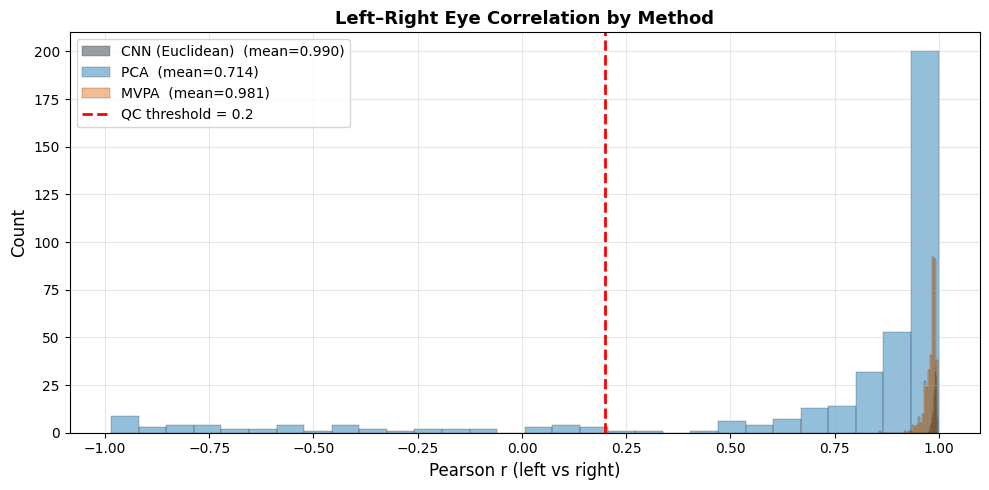

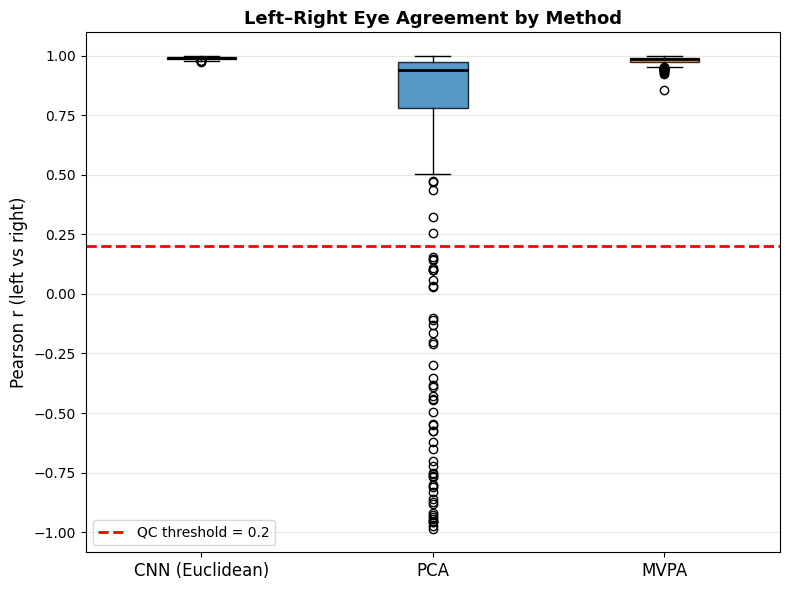

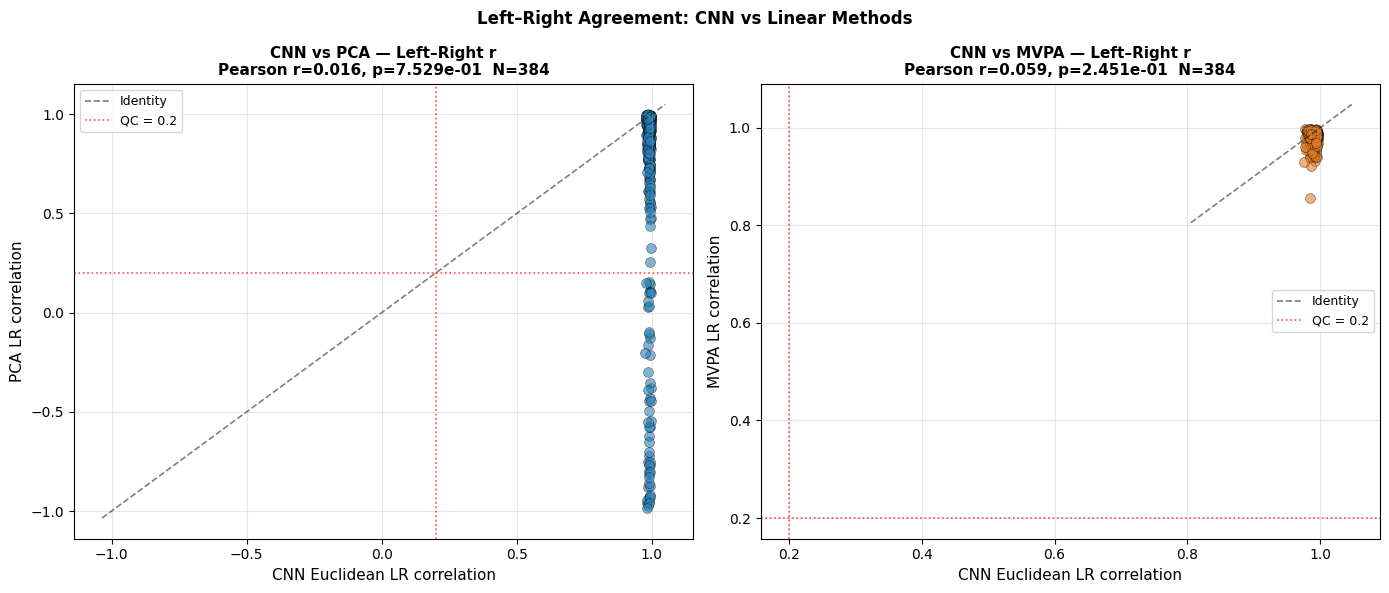


QC analysis complete! Plots saved to /mnt/compneuro/deepmreye_finetuning/


In [5]:
import os
import re
import pickle
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Load saved predictions (this should already exist above)
save_path = "/mnt/compneuro/deepmreye_finetuning/stroke_predictions.pkl"
with open(save_path, "rb") as f:
    stroke_predictions = pickle.load(f)

print(f"Loaded stroke_predictions with {len(stroke_predictions)} runs.")

# Load stroke CSV (needed for PCA/MVPA)
with open('/mnt/compneuro/stroke_clinical_and_neural_data_with_lesion_disconnectome.pkl', 'rb') as f:
    stroke_csv = pickle.load(f)

print("Loaded stroke CSV (ID/Session, PCA_left, PCA_right, MVPA_left, MVPA_right).")
print(f"stroke_csv shape: {stroke_csv.shape}")
print(f"stroke_csv columns: {stroke_csv.columns.tolist()}")

QC_THRESHOLD = 0.2


# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def parse_key(key):
    """
    Extract ID and Session from filename key.
    e.g. 'sub-PAT024_ses-acute_task-rest_run-0_bold_right.npz'
      → ID='PAT024', Session='acute', Eye='right'
    """
    eye       = 'right' if '_right' in key else 'left'
    # Extract ID without 'sub-' prefix
    id_match  = re.search(r'sub-([^_]+)', key)
    ID        = id_match.group(1) if id_match else None
    ses_match = re.search(r'ses-([^_]+)', key)
    session   = ses_match.group(1) if ses_match else None
    return ID, session, eye


def reduce_pred_y(pred_y):
    """
    pred_y shape: (n_volumes, n_timepoints, 2)
    Reduce to 1-D time series by taking median across volumes and timepoints
    separately for x and y, then computing Euclidean distance.
    Returns: pred_x (T,), pred_y_ (T,), euc (T,)
    """
    arr = np.asarray(pred_y, dtype=float)   # (V, T, 2)
    med = np.median(arr, axis=0)            # (T, 2)
    px  = med[:, 0]
    py  = med[:, 1]
    euc = np.sqrt(px**2 + py**2)
    return px, py, euc


# ─────────────────────────────────────────────────────────────────────────────
# BUILD evaluation_left / evaluation_right FROM stroke_predictions
# ─────────────────────────────────────────────────────────────────────────────
evaluation_left  = {}
evaluation_right = {}

for basename, d in stroke_predictions.items():
    # e.g. 'sub-CON001_ses-acute_task-rest_run-0_bold_both.npz'
    base = basename.replace('_both.npz', '')
    key_right = f"{base}_right.npz"
    key_left  = f"{base}_left.npz"

    px_right = d['pred_x_right']   # (T,)
    py_right = d['pred_y_right']   # (T,)
    px_left  = d['pred_x_left']    # (T,)
    py_left  = d['pred_y_left']    # (T,)

    # Stack to (1, T, 2) as in DeepMReye evaluate_model
    pred_y_right = np.stack([px_right, py_right], axis=1)[np.newaxis, ...]  # (1, T, 2)
    pred_y_left  = np.stack([px_left,  py_left],  axis=1)[np.newaxis, ...]

    evaluation_right[key_right] = {'pred_y': pred_y_right}
    evaluation_left[key_left]   = {'pred_y':  pred_y_left}

print(f"Built evaluation_right: {len(evaluation_right)} keys")
print(f"Built evaluation_left : {len(evaluation_left)}  keys")


# ─────────────────────────────────────────────────────────────────────────────
# PARSE evaluation_left AND evaluation_right INTO DATAFRAME
# ─────────────────────────────────────────────────────────────────────────────
def eval_dict_to_df(eval_dict, expected_eye):
    rows = []
    for key, val in eval_dict.items():
        ID, session, eye = parse_key(key)
        if ID is None or session is None:
            print(f"  Could not parse key: {key}")
            continue
        if eye != expected_eye:
            print(f"  Eye mismatch for key {key}: expected {expected_eye}, got {eye}")
        pred_y_raw = val.get('pred_y')
        if pred_y_raw is None:
            continue
        px, py, euc = reduce_pred_y(pred_y_raw)
        rows.append({
            'ID':      ID,
            'Session': session,
            'Eye':     eye,
            'pred_x':  px,
            'pred_y':  py,
            'euc':     euc,
        })
    return pd.DataFrame(rows)

left_df  = eval_dict_to_df(evaluation_left,  'left')
right_df = eval_dict_to_df(evaluation_right, 'right')

print(f"Left  eye entries : {len(left_df)}")
print(f"Right eye entries : {len(right_df)}")
print(f"\nSample IDs (left) : {left_df['ID'].unique()[:5]}")
print(f"Sessions found    : {left_df['Session'].unique()}")


# ─────────────────────────────────────────────────────────────────────────────
# BUILD LEFT–RIGHT PAIRED TABLE
# ─────────────────────────────────────────────────────────────────────────────
left_ts  = left_df[['ID', 'Session', 'pred_x', 'pred_y', 'euc']].rename(
               columns={'pred_x': 'pred_x_left',
                        'pred_y': 'pred_y_left',
                        'euc':    'euc_left'})
right_ts = right_df[['ID', 'Session', 'pred_x', 'pred_y', 'euc']].rename(
               columns={'pred_x': 'pred_x_right',
                        'pred_y': 'pred_y_right',
                        'euc':    'euc_right'})

lr_ts = left_ts.merge(right_ts, on=['ID', 'Session'], how='inner').reset_index(drop=True)
print(f"\nPaired subject-sessions : {len(lr_ts)}")
print(f"Unique subjects         : {lr_ts['ID'].nunique()}")

# Merge with PCA/MVPA info
# CRITICAL FIX: stroke_csv uses 'ID' without 'sub-' prefix, which matches our parsed IDs
print("\nMerging with stroke_csv...")
print(f"Sample IDs in lr_ts: {lr_ts['ID'].unique()[:5]}")
print(f"Sample IDs in stroke_csv: {stroke_csv['ID'].unique()[:5]}")

lr_ts = lr_ts.merge(
    stroke_csv[['ID', 'Session', 'PCA_left', 'PCA_right',
                'MVPA_left', 'MVPA_right']],
    on=['ID', 'Session'], how='left'
)

print(f"After merge: {len(lr_ts)} rows")
print(f"Non-null PCA_left: {lr_ts['PCA_left'].notna().sum()}")
print(f"Non-null MVPA_left: {lr_ts['MVPA_left'].notna().sum()}")


# ─────────────────────────────────────────────────────────────────────────────
# PRE-PROCESS PCA/MVPA COLUMNS: flatten (128,1) to (128,)
# ─────────────────────────────────────────────────────────────────────────────
def flatten_array(v):
    """Flatten arrays from shape (N,1) to (N,) and handle NaN/None"""
    if v is None:
        return None
    if isinstance(v, float) and np.isnan(v):
        return None
    try:
        arr = np.asarray(v, dtype=float).ravel()
        return arr if len(arr) >= 3 else None
    except:
        return None

for col in ['PCA_left', 'PCA_right', 'MVPA_left', 'MVPA_right']:
    if col in lr_ts.columns:
        lr_ts[col] = lr_ts[col].apply(flatten_array)


# ─────────────────────────────────────────────────────────────────────────────
# SAFE PEARSON CORRELATION
# ─────────────────────────────────────────────────────────────────────────────
def safe_pearsonr(a, b):
    """Compute Pearson correlation between two arrays, handling various edge cases"""
    if a is None or b is None:
        return np.nan
    
    try:
        aa = np.asarray(a, dtype=float).ravel()
        bb = np.asarray(b, dtype=float).ravel()
        
        # Check for valid data
        if len(aa) < 3 or len(bb) < 3:
            return np.nan
        if len(aa) != len(bb):
            return np.nan
        
        # Remove any NaN values
        mask = ~(np.isnan(aa) | np.isnan(bb))
        aa = aa[mask]
        bb = bb[mask]
        
        if len(aa) < 3:
            return np.nan
        if np.std(aa) == 0 or np.std(bb) == 0:
            return np.nan
            
        return stats.pearsonr(aa, bb)[0]
    except Exception as e:
        print(f"Error in safe_pearsonr: {e}")
        return np.nan


# ─────────────────────────────────────────────────────────────────────────────
# COMPUTE LEFT–RIGHT CORRELATIONS
# ─────────────────────────────────────────────────────────────────────────────
qc_rows = []
for _, row in lr_ts.iterrows():
    qc_rows.append({
        'ID':        row['ID'],
        'Session':   row['Session'],
        # CNN: correlate Euclidean distance time series L vs R
        'CNN_LR_r':  safe_pearsonr(row['euc_left'],        row['euc_right']),
        # PCA: flattened 1-D arrays
        'PCA_LR_r':  safe_pearsonr(row['PCA_left'],        row['PCA_right']),
        # MVPA: flattened 1-D arrays
        'MVPA_LR_r': safe_pearsonr(row['MVPA_left'],       row['MVPA_right']),
    })

qc_df = pd.DataFrame(qc_rows)

# Boolean flags
qc_df['CNN_pass']  = qc_df['CNN_LR_r']  >= QC_THRESHOLD
qc_df['PCA_pass']  = qc_df['PCA_LR_r']  >= QC_THRESHOLD
qc_df['MVPA_pass'] = qc_df['MVPA_LR_r'] >= QC_THRESHOLD
qc_df['qc_pass']   = qc_df['CNN_pass'] & qc_df['PCA_pass'] & qc_df['MVPA_pass']


# ─────────────────────────────────────────────────────────────────────────────
# PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("QC STEP 1: LEFT–RIGHT EYE CORRELATION")
print("=" * 70)
print(f"\nQC threshold : {QC_THRESHOLD}")
print(f"Total pairs  : {len(qc_df)}\n")

for method, col in [('CNN (Euclidean)', 'CNN_LR_r'),
                    ('PCA',             'PCA_LR_r'),
                    ('MVPA',            'MVPA_LR_r')]:
    sub  = qc_df[col].dropna()
    fail = (qc_df[col] < QC_THRESHOLD).sum()
    print(f"  {method:<20}  N={len(sub)}  "
          f"mean r={sub.mean():.3f}  std={sub.std():.3f}  "
          f"median={sub.median():.3f}  FAIL={fail}")

print(f"\n  Combined QC PASS : {qc_df['qc_pass'].sum()}")
print(f"  Combined QC FAIL : {(~qc_df['qc_pass']).sum()}")
print("\nFailed sessions:")
print(qc_df[~qc_df['qc_pass']][
    ['ID', 'Session', 'CNN_LR_r', 'PCA_LR_r', 'MVPA_LR_r']
].to_string(index=False))


# ─────────────────────────────────────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────────────────────────────────────
method_colors = {'CNN (Euclidean)': '#2c3e50',
                 'PCA':             '#2980b9',
                 'MVPA':            '#e67e22'}
cols_labels   = [('CNN_LR_r',  'CNN (Euclidean)'),
                 ('PCA_LR_r',  'PCA'),
                 ('MVPA_LR_r', 'MVPA')]

# Plot 1: Overlapping histograms
fig, ax = plt.subplots(figsize=(10, 5))
for col, label in cols_labels:
    sub = qc_df[col].dropna()
    if len(sub) > 0:
        ax.hist(sub, bins=30, alpha=0.5,
                label=f'{label}  (mean={sub.mean():.3f})',
                color=method_colors[label], edgecolor='black', linewidth=0.3)
ax.axvline(QC_THRESHOLD, color='red', linewidth=2, linestyle='--',
           label=f'QC threshold = {QC_THRESHOLD}')
ax.set_xlabel('Pearson r (left vs right)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Left–Right Eye Correlation by Method', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/mnt/compneuro/deepmreye_finetuning/qc_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Boxplots
fig, ax = plt.subplots(figsize=(8, 6))
data   = [qc_df[col].dropna().values for col, _ in cols_labels]
labels = [label for _, label in cols_labels]
colors = [method_colors[label] for label in labels]

# Only create boxplot if we have data
if any(len(d) > 0 for d in data):
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
ax.axhline(QC_THRESHOLD, color='red', linewidth=2, linestyle='--',
           label=f'QC threshold = {QC_THRESHOLD}')
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Pearson r (left vs right)', fontsize=12)
ax.set_title('Left–Right Eye Agreement by Method', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/mnt/compneuro/deepmreye_finetuning/qc_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: CNN vs PCA and CNN vs MVPA scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for col_i, (lin_col, lin_label) in enumerate([('PCA_LR_r',  'PCA'),
                                               ('MVPA_LR_r', 'MVPA')]):
    ax    = axes[col_i]
    valid = qc_df[['CNN_LR_r', lin_col]].dropna()
    
    if len(valid) >= 2:  # Need at least 2 points for correlation
        ax.scatter(valid['CNN_LR_r'], valid[lin_col],
                   alpha=0.6, s=50, color=method_colors[lin_label],
                   edgecolors='black', linewidth=0.4)
        lims = [min(valid['CNN_LR_r'].min(), valid[lin_col].min()) - 0.05,
                max(valid['CNN_LR_r'].max(), valid[lin_col].max()) + 0.05]
        ax.plot(lims, lims, 'k--', linewidth=1.2, alpha=0.5, label='Identity')
        ax.axvline(QC_THRESHOLD, color='red', linewidth=1.2,
                   linestyle=':', alpha=0.7, label=f'QC = {QC_THRESHOLD}')
        ax.axhline(QC_THRESHOLD, color='red', linewidth=1.2,
                   linestyle=':', alpha=0.7)
        r, p = stats.pearsonr(valid['CNN_LR_r'], valid[lin_col])
        ax.set_title(f'CNN vs {lin_label} — Left–Right r\n'
                     f'Pearson r={r:.3f}, p={p:.3e}  N={len(valid)}',
                     fontsize=11, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f'Insufficient data for {lin_label}', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'CNN vs {lin_label} — Left–Right r\nNo data available',
                     fontsize=11, fontweight='bold')
    
    ax.set_xlabel('CNN Euclidean LR correlation', fontsize=11)
    ax.set_ylabel(f'{lin_label} LR correlation',  fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Left–Right Agreement: CNN vs Linear Methods',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/compneuro/deepmreye_finetuning/qc_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("QC analysis complete! Plots saved to /mnt/compneuro/deepmreye_finetuning/")
print("=" * 70)

In [14]:
import os
import re
import warnings
import numpy as np
import tensorflow as tf
import pandas as pd
import pickle as pkl
from scipy import stats
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import fdrcorrection
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_score, permutation_test_score
from sklearn.impute import SimpleImputer
import pingouin as pg

warnings.filterwarnings('ignore')
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
tf.keras.backend.clear_session()
gpus = tf.config.experimental.list_physical_devices('GPU')
tf.config.experimental.set_memory_growth(gpus[0], True)

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
model_path      = "/mnt/compneuro/deepmreye_finetuning/two_stream_deepmreye.h5"
stroke_root     = "/mnt/compneuro/deepmreye_finetuning/stroke_nifti/"
stroke_csv_path = "/mnt/compneuro/stroke_clinical_and_neural_data_with_lesion_disconnectome.pkl"
QC_THRESHOLD    = 0.2
GROUP_COL       = 'subj_type'
GROUP_LABELS    = {1: 'Control', 0: 'Stroke'}

# ─────────────────────────────────────────────────────────────────────────────
# LOAD METADATA AND MODEL
# ─────────────────────────────────────────────────────────────────────────────
with open(stroke_csv_path, 'rb') as f:
    stroke_csv = pkl.load(f)

inference_model = tf.keras.models.load_model(model_path, compile=False)
print("Model loaded.")
print("Inputs :", [i.shape for i in inference_model.inputs])
print("Outputs:", [o.shape for o in inference_model.outputs])

# ─────────────────────────────────────────────────────────────────────────────
# COLLECT ALL _both.npz FILES
# ─────────────────────────────────────────────────────────────────────────────
all_both_files = sorted([
    os.path.join(root, fname)
    for root, dirs, files in os.walk(stroke_root)
    for fname in files
    if fname.endswith('run-0_bold_both.npz')
])
print(f"\nFound {len(all_both_files)} _both.npz files.")

# ─────────────────────────────────────────────────────────────────────────────
# DATA LOADER
# ─────────────────────────────────────────────────────────────────────────────
def load_both_npz(fp):
    d = np.load(fp)
    data_keys = sorted(
        [k for k in d.keys() if k.startswith('data_')],
        key=lambda k: int(k.split('_')[1])
    )
    right_list, left_list = [], []
    for dk in data_keys:
        tr = d[dk]
        right_list.append(tr[1:24,  :, :][..., np.newaxis].astype(np.float32))
        left_list.append( tr[24:47, :, :][..., np.newaxis].astype(np.float32))
    return (np.array(right_list, dtype=np.float32),
            np.array(left_list,  dtype=np.float32))

# ─────────────────────────────────────────────────────────────────────────────
# RUN INFERENCE → BUILD evaluation_left / evaluation_right
# ─────────────────────────────────────────────────────────────────────────────
evaluation_left  = {}
evaluation_right = {}

for fp in all_both_files:
    base     = os.path.basename(fp)
    run_base = base.replace('_both.npz', '')

    id_match  = re.search(r'sub-([A-Za-z0-9]+)', run_base)
    ses_match = re.search(r'ses-([^_]+)',          run_base)
    subj_id   = id_match.group(1)  if id_match  else os.path.basename(os.path.dirname(fp)).replace('sub-', '')
    session   = ses_match.group(1) if ses_match else 'unknown'

    key_right = f"{subj_id}_{run_base}_right.npz"
    key_left  = f"{subj_id}_{run_base}_left.npz"

    rights, lefts = load_both_npz(fp)
    T = rights.shape[0]
    if T == 0:
        print(f"  Skipping (no TRs): {base}")
        continue

    preds           = inference_model.predict([rights, lefts], verbose=0)
    gaze_right_pred = preds[0]
    gaze_left_pred  = preds[1]

    evaluation_right[key_right] = {'pred_y': gaze_right_pred[np.newaxis, ...]}
    evaluation_left[key_left]   = {'pred_y': gaze_left_pred[np.newaxis,  ...]}

    print(f"  ✓ {base}  T={T}")

print(f"\nBuilt evaluation_right: {len(evaluation_right)} entries")
print(f"Built evaluation_left : {len(evaluation_left)}  entries")

# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def to_array(val):
    if val is None:
        return None
    if isinstance(val, (int, float, np.floating, np.integer)):
        return None
    if isinstance(val, str):
        try:
            arr = np.fromstring(val.strip('[]'), sep=' ')
            if len(arr) == 0:
                arr = np.fromstring(val.strip('[]'), sep=',')
            return arr.astype(float) if len(arr) >= 3 else None
        except Exception:
            return None
    try:
        arr = np.asarray(val, dtype=float).ravel()
        return arr if len(arr) >= 3 else None
    except Exception:
        return None

def parse_key(key):
    eye       = 'right' if '_right' in key else 'left'
    id_match  = re.match(r'^([^_]+)', key)
    ID        = id_match.group(1) if id_match else None
    ses_match = re.search(r'ses-([^_]+)', key)
    session   = ses_match.group(1) if ses_match else None
    return ID, session, eye

def reduce_pred_y(pred_y):
    arr = np.asarray(pred_y, dtype=float)
    med = np.median(arr, axis=0)
    px  = med[:, 0]
    py  = med[:, 1]
    euc = np.sqrt(px**2 + py**2)
    return px, py, euc

def safe_pearsonr(a, b):
    if a is None or b is None: return np.nan
    a, b = np.asarray(a), np.asarray(b)
    if len(a) != len(b) or len(a) < 3: return np.nan
    if np.std(a) == 0 or np.std(b) == 0: return np.nan
    return stats.pearsonr(a, b)[0]

def eval_dict_to_df(eval_dict, expected_eye):
    rows = []
    for key, val in eval_dict.items():
        ID, session, eye = parse_key(key)
        if ID is None or session is None:
            print(f"  Could not parse key: {key}")
            continue
        if eye != expected_eye:
            print(f"  Eye mismatch for key {key}: expected {expected_eye}, got {eye}")
        pred_y_raw = val.get('pred_y')
        if pred_y_raw is None:
            continue
        px, py, euc = reduce_pred_y(pred_y_raw)
        rows.append({'ID': ID, 'Session': session, 'Eye': eye,
                     'pred_x': px, 'pred_y': py, 'euc': euc})
    return pd.DataFrame(rows)

# ─────────────────────────────────────────────────────────────────────────────
# BUILD DATAFRAMES AND MERGE WITH METADATA
# ─────────────────────────────────────────────────────────────────────────────
left_df  = eval_dict_to_df(evaluation_left,  'left')
right_df = eval_dict_to_df(evaluation_right, 'right')

print(f"\nLeft  eye entries : {len(left_df)}")
print(f"Right eye entries : {len(right_df)}")

left_ts  = left_df[['ID','Session','pred_x','pred_y','euc']].rename(
               columns={'pred_x':'pred_x_left','pred_y':'pred_y_left','euc':'euc_left'})
right_ts = right_df[['ID','Session','pred_x','pred_y','euc']].rename(
               columns={'pred_x':'pred_x_right','pred_y':'pred_y_right','euc':'euc_right'})

lr_ts = left_ts.merge(right_ts, on=['ID','Session'], how='inner').reset_index(drop=True)
lr_ts = lr_ts.merge(
    stroke_csv[['ID','Session','PCA_left','PCA_right','MVPA_left','MVPA_right']],
    on=['ID','Session'], how='left'
)

print(f"\nPaired subject-sessions : {len(lr_ts)}")
print(f"Unique subjects         : {lr_ts['ID'].nunique()}")

for col in ['PCA_left','PCA_right','MVPA_left','MVPA_right']:
    if col in lr_ts.columns:
        lr_ts[col] = lr_ts[col].apply(
            lambda v: np.asarray(v, dtype=float).ravel()
            if v is not None and not (isinstance(v, float) and np.isnan(v))
            else None
        )

# ─────────────────────────────────────────────────────────────────────────────
# QC: LEFT–RIGHT CORRELATIONS
# ─────────────────────────────────────────────────────────────────────────────
qc_rows = []
for _, row in lr_ts.iterrows():
    qc_rows.append({
        'ID':        row['ID'],
        'Session':   row['Session'],
        'CNN_LR_r':  safe_pearsonr(row['euc_left'],            row['euc_right']),
        'PCA_LR_r':  safe_pearsonr(to_array(row['PCA_left']),  to_array(row['PCA_right'])),
        'MVPA_LR_r': safe_pearsonr(to_array(row['MVPA_left']), to_array(row['MVPA_right'])),
    })

qc_df = pd.DataFrame(qc_rows)
qc_df['CNN_pass']  = qc_df['CNN_LR_r']  >= QC_THRESHOLD
qc_df['PCA_pass']  = qc_df['PCA_LR_r']  >= QC_THRESHOLD
qc_df['MVPA_pass'] = qc_df['MVPA_LR_r'] >= QC_THRESHOLD
qc_df['qc_pass']   = qc_df['CNN_pass'] & qc_df['PCA_pass'] & qc_df['MVPA_pass']

print("\n" + "=" * 70)
print("QC STEP 1: LEFT–RIGHT EYE CORRELATION")
print("=" * 70)
print(f"\nQC threshold : {QC_THRESHOLD}")
print(f"Total pairs  : {len(qc_df)}\n")

for method, col in [('CNN (Euclidean)', 'CNN_LR_r'),
                    ('PCA',             'PCA_LR_r'),
                    ('MVPA',            'MVPA_LR_r')]:
    sub  = qc_df[col].dropna()
    fail = (qc_df[col] < QC_THRESHOLD).sum()
    print(f"  {method:<20}  N={len(sub)}  "
          f"mean r={sub.mean():.3f}  std={sub.std():.3f}  "
          f"median={sub.median():.3f}  FAIL={fail}")

print(f"\n  Combined QC PASS : {qc_df['qc_pass'].sum()}")
print(f"  Combined QC FAIL : {(~qc_df['qc_pass']).sum()}")
print("\nFailed sessions:")
print(qc_df[~qc_df['qc_pass']][
    ['ID','Session','CNN_LR_r','PCA_LR_r','MVPA_LR_r']
].to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# QC PLOTS
# ─────────────────────────────────────────────────────────────────────────────
method_colors = {'CNN (Euclidean)': '#2c3e50', 'PCA': '#2980b9', 'MVPA': '#e67e22'}
cols_labels   = [('CNN_LR_r','CNN (Euclidean)'), ('PCA_LR_r','PCA'), ('MVPA_LR_r','MVPA')]

fig, ax = plt.subplots(figsize=(10, 5))
for col, label in cols_labels:
    sub = qc_df[col].dropna()
    ax.hist(sub, bins=30, alpha=0.5,
            label=f'{label}  (mean={sub.mean():.3f})',
            color=method_colors[label], edgecolor='black', linewidth=0.3)
ax.axvline(QC_THRESHOLD, color='red', linewidth=2, linestyle='--',
           label=f'QC threshold = {QC_THRESHOLD}')
ax.set_xlabel('Pearson r (left vs right)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Left–Right Eye Correlation by Method', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
data   = [qc_df[col].dropna().values for col, _ in cols_labels]
labels = [label for _, label in cols_labels]
colors = [method_colors[label] for label in labels]
bp     = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.axhline(QC_THRESHOLD, color='red', linewidth=2, linestyle='--',
           label=f'QC threshold = {QC_THRESHOLD}')
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Pearson r (left vs right)', fontsize=12)
ax.set_title('Left–Right Eye Agreement by Method', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for col_i, (lin_col, lin_label) in enumerate([('PCA_LR_r','PCA'), ('MVPA_LR_r','MVPA')]):
    ax    = axes[col_i]
    valid = qc_df[['CNN_LR_r', lin_col]].dropna()
    ax.scatter(valid['CNN_LR_r'], valid[lin_col],
               alpha=0.6, s=50, color=method_colors[lin_label],
               edgecolors='black', linewidth=0.4)
    lims = [min(valid['CNN_LR_r'].min(), valid[lin_col].min()) - 0.05,
            max(valid['CNN_LR_r'].max(), valid[lin_col].max()) + 0.05]
    ax.plot(lims, lims, 'k--', linewidth=1.2, alpha=0.5, label='Identity')
    ax.axvline(QC_THRESHOLD, color='red', linewidth=1.2, linestyle=':', alpha=0.7,
               label=f'QC = {QC_THRESHOLD}')
    ax.axhline(QC_THRESHOLD, color='red', linewidth=1.2, linestyle=':', alpha=0.7)
    r, p = stats.pearsonr(valid['CNN_LR_r'], valid[lin_col])
    ax.set_title(f'CNN vs {lin_label} — Left–Right r\n'
                 f'Pearson r={r:.3f}, p={p:.3e}  N={len(valid)}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('CNN Euclidean LR correlation', fontsize=11)
    ax.set_ylabel(f'{lin_label} LR correlation', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
plt.suptitle('Left–Right Agreement: CNN vs Linear Methods', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# GROUP × SESSION ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
qc_full = qc_df.merge(
    stroke_csv[['ID', 'Session', GROUP_COL]].drop_duplicates(),
    on=['ID', 'Session'], how='left'
)
qc_full = qc_full.dropna(subset=[GROUP_COL, 'Session']).copy()
qc_full['Group']   = qc_full[GROUP_COL].map(GROUP_LABELS)
qc_full['Session'] = qc_full['Session'].astype(str)

print(f"\nGroups found    : {qc_full['Group'].unique()}")
print(f"Sessions found  : {qc_full['Session'].unique()}")
print(f"Total rows      : {len(qc_full)}")
print(f"N per group:\n{qc_full['Group'].value_counts()}")

ctrl_sessions   = set(qc_full[qc_full['Group']=='Control']['Session'].unique())
stroke_sessions = set(qc_full[qc_full['Group']=='Stroke']['Session'].unique())
shared_sessions = ctrl_sessions & stroke_sessions

print(f"\nControl-only sessions : {ctrl_sessions - stroke_sessions}")
print(f"Stroke-only sessions  : {stroke_sessions - ctrl_sessions}")
print(f"Shared sessions       : {shared_sessions}")

metrics = {
    'CNN_LR_r':  'CNN Euclidean LR correlation',
    'PCA_LR_r':  'PCA LR correlation',
    'MVPA_LR_r': 'MVPA LR correlation',
}

# Analysis A: shared sessions
if shared_sessions:
    print("\n" + "=" * 70)
    print("ANALYSIS A: GROUP DIFFERENCE (shared sessions only)")
    print("=" * 70)
    shared_df = qc_full[qc_full['Session'].isin(shared_sessions)].copy()
    for col, label in metrics.items():
        sub = shared_df[['ID','Group','Session', col]].dropna()
        print(f"\n─── {label}  (N={len(sub)}) ───")
        pg_res = pg.anova(data=sub, dv=col, between=['Group','Session'])
        print(pg_res[['Source','DF','F','p-unc','np2']].to_string(index=False))

# Analysis B: Mann-Whitney collapsed
print("\n" + "=" * 70)
print("ANALYSIS B: CONTROL vs STROKE (all sessions collapsed)")
print("=" * 70)
for col, label in metrics.items():
    ctrl   = qc_full[qc_full['Group']=='Control'][col].dropna()
    stroke = qc_full[qc_full['Group']=='Stroke'][col].dropna()
    u, p   = stats.mannwhitneyu(ctrl, stroke, alternative='two-sided')
    d      = pg.mwu(ctrl, stroke)['CLES'].values[0]
    print(f"\n{label}")
    print(f"  Control  N={len(ctrl):3d}  median={ctrl.median():.3f}  mean={ctrl.mean():.3f}")
    print(f"  Stroke   N={len(stroke):3d}  median={stroke.median():.3f}  mean={stroke.mean():.3f}")
    print(f"  Mann-Whitney U={u:.1f}  p={p:.4f}  CLES={d:.3f}")


RuntimeError: Physical devices cannot be modified after being initialized

In [13]:

# ─────────────────────────────────────────────────────────────────────────────
# helper: print whatever columns pingouin actually returns
# ─────────────────────────────────────────────────────────────────────────────
def print_pg_anova(pg_res):
    want = ['Source', 'DF', 'ddof1', 'ddof2', 'F', 'p-unc', 'np2', 'eta-sq', 'omega-sq']
    cols = [c for c in want if c in pg_res.columns]
    print(pg_res[cols].to_string(index=False))

# Analysis C: within-stroke session effect
print("\n" + "=" * 70)
print("ANALYSIS C: WITHIN-STROKE SESSION EFFECT")
print("=" * 70)
stroke_df = qc_full[(qc_full['Group']=='Stroke') & (qc_full['Session'].isin(stroke_sessions))].copy()
for col, label in metrics.items():
    sub = stroke_df[['ID','Session', col]].dropna()
    print(f"\n─── {label}  (N={len(sub)}) ───")
    pg_res = pg.anova(data=sub, dv=col, between='Session')
    print_pg_anova(pg_res)
    if pg_res['p-unc'].values[0] < 0.05:
        print("  → Significant! Post-hoc (FDR):")
        ph = pg.pairwise_tests(data=sub, dv=col, between='Session', padjust='fdr_bh')
        ph_cols = [c for c in ['A','B','mean(A)','mean(B)','T','p-unc','p-corr'] if c in ph.columns]
        print(ph[ph_cols].to_string(index=False))

# Analysis D: within-control test-retest
print("\n" + "=" * 70)
print("ANALYSIS D: WITHIN-CONTROL SESSION EFFECT")
print("=" * 70)
ctrl_df = qc_full[(qc_full['Group']=='Control') & (qc_full['Session'].isin(ctrl_sessions))].copy()
for col, label in metrics.items():
    sub = ctrl_df[['ID','Session', col]].dropna()
    print(f"\n─── {label}  (N={len(sub)}) ───")
    pg_res = pg.anova(data=sub, dv=col, between='Session')
    print_pg_anova(pg_res)
# Group × Session plot
session_order = ['control','control2','acute','followup','followup2']
session_order = [s for s in session_order if s in qc_full['Session'].unique()]
palette_grp   = {'Control': '#2980b9', 'Stroke': '#e74c3c'}

fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 5))
for ax, (col, label) in zip(axes, metrics.items()):
    sub = qc_full[['Group','Session', col]].dropna()
    for grp, color in palette_grp.items():
        grp_data = sub[sub['Group']==grp]
        means = [grp_data[grp_data['Session']==ses][col].mean() for ses in session_order]
        sems  = [grp_data[grp_data['Session']==ses][col].sem()  for ses in session_order]
        x_pos = [i for i, m in enumerate(means) if not np.isnan(m)]
        y_val = [m for m in means if not np.isnan(m)]
        y_err = [s for s, m in zip(sems, means) if not np.isnan(m)]
        ax.bar([p + (0.2 if grp=='Stroke' else -0.2) for p in x_pos],
               y_val, width=0.35, color=color, alpha=0.85,
               yerr=y_err, capsize=4, label=grp, error_kw=dict(linewidth=1.2))
    ax.axhline(QC_THRESHOLD, color='red', linewidth=1.5, linestyle='--',
               alpha=0.7, label=f'QC = {QC_THRESHOLD}')
    ax.set_xticks(range(len(session_order)))
    ax.set_xticklabels(session_order, fontsize=10, rotation=20, ha='right')
    ax.set_ylabel('Mean Pearson r (L vs R)', fontsize=11)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('LR Correlation by Group and Session', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FEATURE EXTRACTION
# ─────────────────────────────────────────────────────────────────────────────
def euc_features(signal, prefix):
    s     = np.asarray(signal, dtype=float)
    diffs = np.diff(s)
    f     = {}
    f[f'{prefix}_euc_mean']   = np.mean(s)
    f[f'{prefix}_euc_sd']     = np.std(s)
    f[f'{prefix}_euc_var']    = np.var(s)
    f[f'{prefix}_euc_range']  = np.ptp(s)
    f[f'{prefix}_euc_rms']    = np.sqrt(np.mean(s**2))
    f[f'{prefix}_euc_mssd']   = np.mean(diffs**2)
    f[f'{prefix}_euc_ac1']    = pd.Series(s).autocorr(lag=1)
    f[f'{prefix}_path_length']= np.sum(np.abs(diffs))
    f[f'{prefix}_mean_speed'] = np.mean(np.abs(diffs))
    f[f'{prefix}_max_speed']  = np.max(np.abs(diffs))
    fft_mag = np.abs(np.fft.rfft(s - s.mean()))**2
    fft_mag = fft_mag[1:]
    fft_sum = fft_mag.sum()
    if fft_sum > 0:
        p = fft_mag / fft_sum
        p = p[p > 0]
        f[f'{prefix}_euc_spec_entropy'] = -np.sum(p * np.log2(p))
    else:
        f[f'{prefix}_euc_spec_entropy'] = np.nan
    return f

def lr_asym_features(euc_l, euc_r, prefix):
    euc_l = np.asarray(euc_l)
    euc_r = np.asarray(euc_r)
    f = {}
    if len(euc_l) == len(euc_r):
        diff = euc_l - euc_r
        f[f'{prefix}_LR_mean_asym'] = np.mean(diff)
        f[f'{prefix}_LR_sd_asym']   = np.std(diff)
        if np.std(euc_l) > 0 and np.std(euc_r) > 0:
            f[f'{prefix}_LR_corr'], _ = stats.pearsonr(euc_l, euc_r)
        else:
            f[f'{prefix}_LR_corr'] = np.nan
    else:
        f[f'{prefix}_LR_mean_asym'] = np.nan
        f[f'{prefix}_LR_sd_asym']   = np.nan
        f[f'{prefix}_LR_corr']      = np.nan
    return f

def ocular_features_2d(arr_x, arr_y, prefix):
    arr_x = np.asarray(arr_x, dtype=float)
    arr_y = np.asarray(arr_y, dtype=float)
    euc   = np.sqrt(arr_x**2 + arr_y**2)
    f     = euc_features(euc, prefix)
    step  = np.sqrt(np.diff(arr_x)**2 + np.diff(arr_y)**2)
    f[f'{prefix}_path_length'] = np.sum(step)
    f[f'{prefix}_mean_speed']  = np.mean(step)
    f[f'{prefix}_max_speed']   = np.max(step)
    f[f'{prefix}_x_mean'] = np.mean(arr_x)
    f[f'{prefix}_x_sd']   = np.std(arr_x)
    f[f'{prefix}_x_var']  = np.var(arr_x)
    f[f'{prefix}_y_mean'] = np.mean(arr_y)
    f[f'{prefix}_y_sd']   = np.std(arr_y)
    f[f'{prefix}_y_var']  = np.var(arr_y)
    xy = np.concatenate([arr_x, arr_y])
    f[f'{prefix}_mean'] = np.mean(xy)
    f[f'{prefix}_sd']   = np.std(xy)
    f[f'{prefix}_var']  = np.var(xy)
    angles = np.arctan2(arr_y, arr_x)
    f[f'{prefix}_angle_sd']    = np.std(angles)
    f[f'{prefix}_angle_range'] = np.ptp(angles)
    if np.std(arr_x) > 0 and np.std(arr_y) > 0:
        f[f'{prefix}_xy_corr'], _ = stats.pearsonr(arr_x, arr_y)
    else:
        f[f'{prefix}_xy_corr'] = np.nan
    return f

def flatten_array(v):
    if v is None:
        return None
    if isinstance(v, float) and np.isnan(v):
        return None
    try:
        arr = np.asarray(v, dtype=float).ravel()
        return arr if len(arr) >= 3 else None
    except Exception:
        return None

# CNN features
cnn_rows = []
for _, row in lr_ts.iterrows():
    f = {'ID': row['ID'], 'Session': row['Session']}
    f.update(ocular_features_2d(row['pred_x_left'],  row['pred_y_left'],  'CNN_L'))
    f.update(ocular_features_2d(row['pred_x_right'], row['pred_y_right'], 'CNN_R'))
    avg_x = (row['pred_x_left'] + row['pred_x_right']) / 2
    avg_y = (row['pred_y_left'] + row['pred_y_right']) / 2
    f.update(ocular_features_2d(avg_x, avg_y, 'CNN_avg'))
    euc_l = np.sqrt(row['pred_x_left']**2  + row['pred_y_left']**2)
    euc_r = np.sqrt(row['pred_x_right']**2 + row['pred_y_right']**2)
    f.update(lr_asym_features(euc_l, euc_r, 'CNN'))
    cnn_rows.append(f)
cnn_feats_df = pd.DataFrame(cnn_rows)
print(f"\nCNN features : {len([c for c in cnn_feats_df.columns if c not in ['ID','Session']])}")

# PCA/MVPA features
linear_rows = []
for _, row in stroke_csv.iterrows():
    f = {'ID': row['ID'], 'Session': row['Session']}
    for method in ['PCA', 'MVPA']:
        l_arr = flatten_array(row.get(f'{method}_left'))
        r_arr = flatten_array(row.get(f'{method}_right'))
        for side, arr in [('L', l_arr), ('R', r_arr)]:
            if arr is not None and len(arr) >= 3:
                abs_arr = np.abs(arr)
                f.update(euc_features(abs_arr, f'{method}_{side}'))
                f[f'{method}_{side}_mean'] = np.mean(arr)
                f[f'{method}_{side}_sd']   = np.std(arr)
                f[f'{method}_{side}_var']  = np.var(arr)
        if l_arr is not None and r_arr is not None and len(l_arr) == len(r_arr):
            f.update(lr_asym_features(np.abs(l_arr), np.abs(r_arr), method))
        if method == 'MVPA':
            pca_l = flatten_array(row.get('PCA_left'))
            pca_r = flatten_array(row.get('PCA_right'))
            if (pca_l is not None and l_arr is not None and
                    len(pca_l) == len(l_arr) and np.std(pca_l) > 0 and np.std(l_arr) > 0):
                f['corr_PCA_MVPA_L'], _ = stats.pearsonr(pca_l, l_arr)
            if (pca_r is not None and r_arr is not None and
                    len(pca_r) == len(r_arr) and np.std(pca_r) > 0 and np.std(r_arr) > 0):
                f['corr_PCA_MVPA_R'], _ = stats.pearsonr(pca_r, r_arr)
    linear_rows.append(f)
linear_feats_df = pd.DataFrame(linear_rows)
print(f"Linear features : {len([c for c in linear_feats_df.columns if c not in ['ID','Session']])}")

# Master table
all_feats_df = cnn_feats_df.merge(linear_feats_df, on=['ID','Session'], how='outer')
all_feats_df = all_feats_df.merge(
    stroke_csv[['ID','Session','nih_total','lesion_size']],
    on=['ID','Session'], how='left')
all_feats_df = all_feats_df.merge(
    qc_df[['ID','Session','qc_pass']], on=['ID','Session'], how='left')
all_feats_df = all_feats_df[all_feats_df['qc_pass'] == True].drop(columns='qc_pass')

print(f"\nMaster table (QC-passed): {all_feats_df.shape[0]} rows × {all_feats_df.shape[1]} cols")

feature_cols = [c for c in all_feats_df.columns
                if c not in ['ID','Session','nih_total','lesion_size']]

# ─────────────────────────────────────────────────────────────────────────────
# RECOVERY ANALYSIS: acute features → followup NIH
# ─────────────────────────────────────────────────────────────────────────────
acute_feats = all_feats_df[all_feats_df['Session'] == 'acute'].copy()

followup_nih = stroke_csv[stroke_csv['Session'].isin(['followup','followup2'])]\
    .groupby('ID')['nih_total'].mean().reset_index()\
    .rename(columns={'nih_total': 'nih_followup'})

acute_nih = stroke_csv[stroke_csv['Session'] == 'acute'][['ID','nih_total']]\
    .rename(columns={'nih_total': 'nih_acute'})

recovery_df = acute_feats.merge(followup_nih, on='ID', how='inner')
recovery_df = recovery_df.merge(acute_nih,    on='ID', how='left')
recovery_df['nih_delta'] = recovery_df['nih_followup'] - recovery_df['nih_acute']

print(f"\nRecovery dataset: {len(recovery_df)} subjects")
print(f"nih_followup available : {recovery_df['nih_followup'].notna().sum()}")
print(f"nih_delta available    : {recovery_df['nih_delta'].notna().sum()}")

# ─────────────────────────────────────────────────────────────────────────────
# CORRELATIONS WITH OUTCOMES + FDR
# ─────────────────────────────────────────────────────────────────────────────
outcome_vars = ['nih_followup', 'nih_delta', 'lesion_size']

corr_rows = []
for outcome in outcome_vars:
    source_df = recovery_df if outcome in ['nih_followup','nih_delta'] else all_feats_df
    valid_out = source_df[outcome].notna()
    for feat in feature_cols:
        if feat not in source_df.columns:
            continue
        valid = source_df[valid_out & source_df[feat].notna()]
        if len(valid) < 5:
            continue
        r,   p_r   = stats.pearsonr(valid[outcome],  valid[feat])
        rho, p_rho = stats.spearmanr(valid[outcome], valid[feat])
        corr_rows.append({
            'Outcome': outcome, 'Feature': feat, 'N': len(valid),
            'r': r, 'p_r': p_r, 'rho': rho, 'p_rho': p_rho, 'abs_rho': abs(rho)
        })

corr_df = pd.DataFrame(corr_rows)

# FDR correction per outcome
for outcome in outcome_vars:
    mask = corr_df['Outcome'] == outcome
    if mask.sum() == 0:
        continue
    _, p_corr = fdrcorrection(corr_df.loc[mask, 'p_rho'].fillna(1).values)
    corr_df.loc[mask, 'p_rho_fdr'] = p_corr
corr_df['sig_fdr'] = corr_df['p_rho_fdr'] < 0.05

def tag_method(feat):
    if feat.startswith('CNN'):   return 'CNN'
    if feat.startswith('PCA'):   return 'PCA'
    if feat.startswith('MVPA'):  return 'MVPA'
    if feat.startswith('corr_'): return 'Cross'
    return 'Other'

def tag_base(feat):
    suffixes = [
        '_euc_mean','_euc_sd','_euc_var','_euc_range','_euc_rms',
        '_euc_mssd','_euc_ac1','_euc_spec_entropy',
        '_path_length','_mean_speed','_max_speed',
        '_angle_sd','_angle_range','_xy_corr',
        '_LR_sd_asym','_LR_mean_asym','_LR_corr',
        '_x_mean','_x_sd','_x_var',
        '_y_mean','_y_sd','_y_var',
        '_mean','_sd','_var'
    ]
    for suffix in suffixes:
        if feat.endswith(suffix):
            return suffix.lstrip('_')
    return feat

corr_df['Method'] = corr_df['Feature'].apply(tag_method)
corr_df['Base']   = corr_df['Feature'].apply(tag_base)

print("\n" + "=" * 70)
print("TOP 15 FEATURES PER OUTCOME  (|Spearman ρ|, FDR-corrected)")
print("=" * 70)
for outcome in outcome_vars:
    sub = corr_df[corr_df['Outcome'] == outcome].sort_values('abs_rho', ascending=False)
    print(f"\n  {outcome}:")
    print(sub[['Feature','Method','N','r','p_r','rho','p_rho','p_rho_fdr','sig_fdr']].head(15).to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# CROSS-VALIDATED R² COMPARISON
# ─────────────────────────────────────────────────────────────────────────────
def cv_r2(X_df, y_col, feats):
    available = [f for f in feats if f in X_df.columns]
    sub = X_df[available + [y_col]].dropna()
    if len(sub) < 10:
        return np.nan, len(sub)
    X  = sub[available].values
    y_ = sub[y_col].values
    pipe = make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
    )
    scores = cross_val_score(pipe, X, y_, cv=LeaveOneOut(), scoring='r2')
    return np.mean(scores), len(sub)

method_feature_map = {
    'CNN':          [c for c in feature_cols if c.startswith('CNN')],
    'PCA':          [c for c in feature_cols if c.startswith('PCA')],
    'MVPA':         [c for c in feature_cols if c.startswith('MVPA')],
    'CNN+PCA+MVPA': [c for c in feature_cols if c.startswith(('CNN','PCA','MVPA'))],
}

cv_results = []
for outcome in ['nih_followup', 'nih_delta']:
    source_df = recovery_df
    if outcome not in source_df.columns:
        continue
    for method, feats in method_feature_map.items():
        r2, n = cv_r2(source_df, outcome, feats)
        cv_results.append({'Outcome': outcome, 'Method': method, 'LOO_R2': r2, 'N': n})

cv_df = pd.DataFrame(cv_results)
print("\n" + "=" * 70)
print("LOO CROSS-VALIDATED R²")
print("=" * 70)
print(cv_df.to_string(index=False))

# Plot CV R²
outcomes_cv = cv_df['Outcome'].unique()
fig, axes   = plt.subplots(1, len(outcomes_cv), figsize=(6 * len(outcomes_cv), 5))
if len(outcomes_cv) == 1:
    axes = [axes]
colors_cv = ['#2c3e50','#2980b9','#e67e22','#27ae60']

for ax, outcome in zip(axes, outcomes_cv):
    sub    = cv_df[cv_df['Outcome'] == outcome]
    bars   = ax.bar(sub['Method'], sub['LOO_R2'].clip(lower=-0.25),
                    color=colors_cv, alpha=0.85, edgecolor='black', linewidth=0.6)
    ax.axhline(0, color='red', linewidth=1.2, linestyle='--')
    ax.set_title(f'LOO CV R² → {outcome}', fontweight='bold')
    ax.set_ylabel('Cross-validated R²')
    ax.set_ylim(-0.3, max(sub['LOO_R2'].max() + 0.1, 0.3))
    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"R²={row['LOO_R2']:.2f}\nN={row['N']}",
                ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Predictive Power for Stroke Recovery by Feature Set',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# PERMUTATION TESTS
# ─────────────────────────────────────────────────────────────────────────────
def perm_test(X_df, y_col, feats, n_permutations=500):
    available = [f for f in feats if f in X_df.columns]
    sub = X_df[available + [y_col]].dropna()
    if len(sub) < 10:
        return np.nan, np.nan
    X  = SimpleImputer(strategy='median').fit_transform(sub[available].values)
    X  = StandardScaler().fit_transform(X)
    y_ = sub[y_col].values
    model = RidgeCV(alphas=[0.1, 1, 10])
    score, _, p_val = permutation_test_score(
        model, X, y_, cv=LeaveOneOut(),
        scoring='r2', n_permutations=n_permutations, n_jobs=-1
    )
    return score, p_val

print("\n" + "=" * 70)
print("PERMUTATION TESTS (n=500)")
print("=" * 70)
for outcome in ['nih_followup', 'nih_delta']:
    if outcome not in recovery_df.columns:
        continue
    print(f"\nOutcome: {outcome}")
    for method, feats in method_feature_map.items():
        score, p = perm_test(recovery_df, outcome, feats)
        print(f"  {method:<20}  R²={score:.3f}  p_perm={p:.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# FEATURE IMPORTANCE BAR CHART (per outcome)
# ─────────────────────────────────────────────────────────────────────────────
m_colors = {'CNN': '#2c3e50', 'PCA': '#2980b9', 'MVPA': '#e67e22'}

for outcome in outcome_vars:
    sub  = corr_df[(corr_df['Outcome'] == outcome) &
                   corr_df['Method'].isin(['CNN','PCA','MVPA'])].copy()
    best = (sub.groupby(['Method','Base'])
               .apply(lambda g: g.loc[g['abs_rho'].idxmax()])
               .reset_index(drop=True))
    bases   = sorted(best['Base'].unique())
    x       = np.arange(len(bases))
    width   = 0.25
    fig, ax = plt.subplots(figsize=(18, 6))
    for i, method in enumerate(['CNN','PCA','MVPA']):
        m_data   = best[best['Method'] == method].set_index('Base')
        rho_vals = [m_data.loc[b,'rho'] if b in m_data.index else np.nan for b in bases]
        abs_vals = [abs(v) if not np.isnan(v) else 0.0 for v in rho_vals]
        bars     = ax.bar(x + i * width, abs_vals, width,
                          label=method, color=m_colors[method],
                          edgecolor='black', linewidth=0.5, alpha=0.85)
        for bar, rho in zip(bars, rho_vals):
            if not np.isnan(rho) and abs(rho) > 0.02:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.005,
                        '+' if rho > 0 else '−',
                        ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x + width)
    ax.set_xticklabels(bases, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('|Spearman ρ| (FDR-corrected * = sig)', fontsize=12)
    ax.set_title(f'CNN vs PCA vs MVPA — Correlations with {outcome}\n'
                 f'(bar = |ρ|, sign annotated)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.set_ylim(0, min(1.0, best['abs_rho'].max() + 0.15))
    ax.axhline(0.1, color='gray', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


ANALYSIS C: WITHIN-STROKE SESSION EFFECT


NameError: name 'qc_full' is not defined

In [8]:
import pingouin as pg
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------
# INSPECT DESIGN: which sessions exist per group?
# ---------------------------------------------------------------------
print("Session counts per Group:")
print(qc_full.groupby(['Group','Session'])['CNN_LR_r'].count().unstack(fill_value=0))

# Sessions present in BOTH groups (if any)
ctrl_sessions   = set(qc_full[qc_full['Group']=='Control']['Session'].unique())
stroke_sessions = set(qc_full[qc_full['Group']=='Stroke']['Session'].unique())
shared_sessions = ctrl_sessions & stroke_sessions
print(f"\nControl-only sessions : {ctrl_sessions - stroke_sessions}")
print(f"Stroke-only sessions  : {stroke_sessions - ctrl_sessions}")
print(f"Shared sessions       : {shared_sessions}")

metrics = {
    'CNN_LR_r':  'CNN Euclidean LR correlation',
    'PCA_LR_r':  'PCA LR correlation',
    'MVPA_LR_r': 'MVPA LR correlation',
}

# =====================================================================
# ANALYSIS A: Group comparison on SHARED sessions only
# =====================================================================
if shared_sessions:
    print("\n" + "=" * 70)
    print("ANALYSIS A: GROUP DIFFERENCE (shared sessions only)")
    print("=" * 70)
    shared_df = qc_full[qc_full['Session'].isin(shared_sessions)].copy()

    for col, label in metrics.items():
        sub = shared_df[['ID','Group','Session', col]].dropna()
        print(f"\n─── {label}  (N={len(sub)}) ───")
        # Two-way ANOVA on shared sessions
        pg_res = pg.anova(data=sub, dv=col, between=['Group','Session'])
        print(pg_res[['Source','DF','F','p-unc','np2']].to_string(index=False))
else:
    print("\nNo shared sessions — skipping Analysis A.")

# =====================================================================
# ANALYSIS B: Group difference collapsing across sessions (Mann-Whitney)
# =====================================================================
print("\n" + "=" * 70)
print("ANALYSIS B: CONTROL vs STROKE (all sessions collapsed)")
print("=" * 70)

for col, label in metrics.items():
    ctrl   = qc_full[qc_full['Group']=='Control'][col].dropna()
    stroke = qc_full[qc_full['Group']=='Stroke'][col].dropna()
    u, p   = stats.mannwhitneyu(ctrl, stroke, alternative='two-sided')
    d      = pg.mwu(ctrl, stroke)['CLES'].values[0]   # common language effect size
    print(f"\n{label}")
    print(f"  Control  N={len(ctrl):3d}  median={ctrl.median():.3f}  mean={ctrl.mean():.3f}")
    print(f"  Stroke   N={len(stroke):3d}  median={stroke.median():.3f}  mean={stroke.mean():.3f}")
    print(f"  Mann-Whitney U={u:.1f}  p={p:.4f}  CLES={d:.3f}")

# =====================================================================
# ANALYSIS C: Within-stroke session effect (one-way ANOVA across timepoints)
# =====================================================================
print("\n" + "=" * 70)
print("ANALYSIS C: WITHIN-STROKE SESSION EFFECT (acute / followup / followup2)")
print("=" * 70)

stroke_df = qc_full[
    (qc_full['Group']=='Stroke') &
    (qc_full['Session'].isin(stroke_sessions))
].copy()

for col, label in metrics.items():
    sub = stroke_df[['ID','Session', col]].dropna()
    print(f"\n─── {label}  (N={len(sub)}) ───")
    pg_res = pg.anova(data=sub, dv=col, between='Session')
    print(pg_res[['Source','DF','F','p-unc','np2']].to_string(index=False))

    # Post-hoc pairwise if significant
    if pg_res['p-unc'].values[0] < 0.05:
        print("  → Significant! Post-hoc (FDR):")
        ph = pg.pairwise_tests(data=sub, dv=col, between='Session', padjust='fdr_bh')
        print(ph[['A','B','mean(A)','mean(B)','T','p-unc','p-corr']].to_string(index=False))

# =====================================================================
# ANALYSIS D: Within-control session effect (control vs control2)
# =====================================================================
print("\n" + "=" * 70)
print("ANALYSIS D: WITHIN-CONTROL SESSION EFFECT (control / control2)")
print("=" * 70)

ctrl_df = qc_full[
    (qc_full['Group']=='Control') &
    (qc_full['Session'].isin(ctrl_sessions))
].copy()

for col, label in metrics.items():
    sub = ctrl_df[['ID','Session', col]].dropna()
    print(f"\n─── {label}  (N={len(sub)}) ───")
    pg_res = pg.anova(data=sub, dv=col, between='Session')
    print(pg_res[['Source','DF','F','p-unc','np2']].to_string(index=False))

# =====================================================================
# PLOT
# =====================================================================
fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 5))
palette   = {'Control': '#2980b9', 'Stroke': '#e74c3c'}
session_order = ['control','control2','acute','followup','followup2']
session_order = [s for s in session_order if s in qc_full['Session'].unique()]

for ax, (col, label) in zip(axes, metrics.items()):
    sub = qc_full[['Group','Session', col]].dropna()
    for grp, color in palette.items():
        grp_data = sub[sub['Group']==grp]
        means = [grp_data[grp_data['Session']==ses][col].mean() for ses in session_order]
        sems  = [grp_data[grp_data['Session']==ses][col].sem()  for ses in session_order]
        x_pos = [i for i, ses in enumerate(session_order)
                 if not np.isnan(means[i])]
        y_val = [m for m in means if not np.isnan(m)]
        y_err = [s for s, m in zip(sems, means) if not np.isnan(m)]
        ax.bar([p + (0.2 if grp=='Stroke' else -0.2) for p in x_pos],
               y_val, width=0.35, color=color, alpha=0.85,
               yerr=y_err, capsize=4, label=grp,
               error_kw=dict(linewidth=1.2))

    ax.axhline(QC_THRESHOLD, color='red', linewidth=1.5,
               linestyle='--', alpha=0.7, label=f'QC = {QC_THRESHOLD}')
    ax.set_xticks(range(len(session_order)))
    ax.set_xticklabels(session_order, fontsize=10, rotation=20, ha='right')
    ax.set_ylabel('Mean Pearson r (L vs R)', fontsize=11)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('LR Correlation by Group and Session',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Session counts per Group:
Session  acute  control  control2  followup  followup2
Group                                                 
Control      0       28        28         0          0
Stroke     137        0         0       103         86

Control-only sessions : {'control2', 'control'}
Stroke-only sessions  : {'acute', 'followup2', 'followup'}
Shared sessions       : set()

No shared sessions — skipping Analysis A.

ANALYSIS B: CONTROL vs STROKE (all sessions collapsed)

CNN Euclidean LR correlation
  Control  N= 56  median=0.990  mean=0.990
  Stroke   N=326  median=0.991  mean=0.990
  Mann-Whitney U=8320.0  p=0.2901  CLES=0.456

PCA LR correlation
  Control  N= 56  median=0.945  mean=0.772
  Stroke   N=326  median=0.936  mean=0.703
  Mann-Whitney U=9853.0  p=0.3426  CLES=0.540

MVPA LR correlation
  Control  N= 56  median=0.986  mean=0.983
  Stroke   N=326  median=0.985  mean=0.980
  Mann-Whitney U=10041.0  p=0.2319  CLES=0.550

ANALYSIS C: WITHIN-STROKE SESSION EFFECT (acute 

KeyError: "['DF'] not in index"


LOO CROSS-VALIDATED R² (manual, NaN-safe)
     Outcome       Method    LOO_R2  N
nih_followup          CNN -0.051680 80
nih_followup          PCA -0.153381 80
nih_followup         MVPA -0.286819 80
nih_followup CNN+PCA+MVPA -0.286763 80
   nih_delta          CNN -0.045980 66
   nih_delta          PCA -0.030161 66
   nih_delta         MVPA  0.000887 66
   nih_delta CNN+PCA+MVPA -0.044252 66


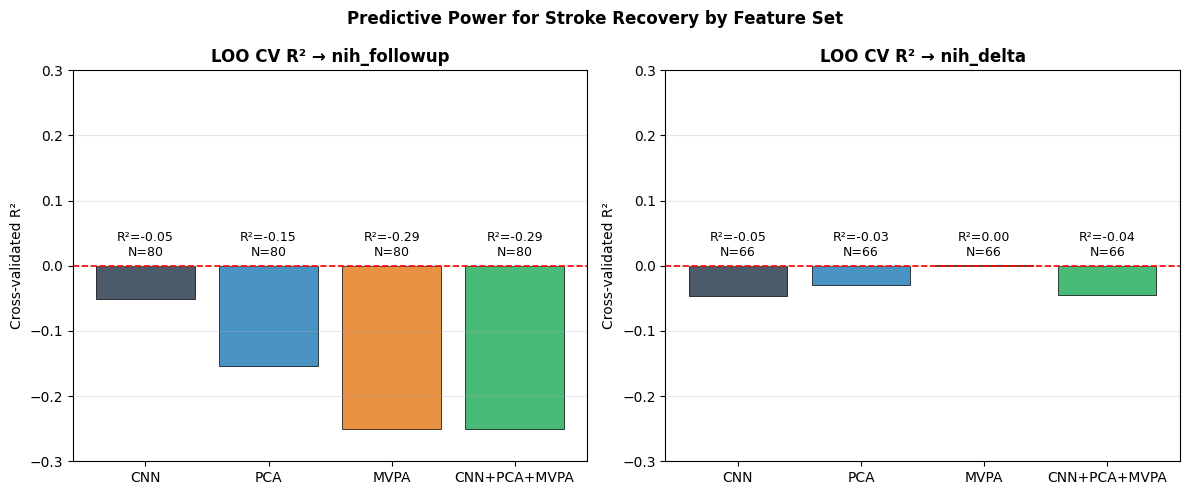

In [9]:
from sklearn.metrics import r2_score
# ─────────────────────────────────────────────────────────────────────────────
# FIXED cv_r2: use manual LOO (concatenate all predictions, compute R² once)
# This avoids per-fold NaN from single-sample r2_score
# ─────────────────────────────────────────────────────────────────────────────
def cv_r2(X_df, y_col, feats, nan_thresh=0.5, min_rows=8):
    available = [f for f in feats if f in X_df.columns]
    nan_rate  = X_df[available].isna().mean()
    available = [f for f in available if nan_rate[f] <= nan_thresh]
    if not available:
        return np.nan, 0
    sub = X_df[available + [y_col]].dropna()
    if len(sub) < min_rows:
        return np.nan, len(sub)
    X  = sub[available].values
    y_ = sub[y_col].values
    if np.std(y_) == 0:
        return np.nan, len(sub)

    imputer = SimpleImputer(strategy='median')
    scaler  = StandardScaler()
    model   = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])

    X = imputer.fit_transform(X)
    X = scaler.fit_transform(X)

    # Manual LOO: collect all out-of-fold predictions, then compute R² once
    y_pred = np.full_like(y_, np.nan, dtype=float)
    for train_idx, test_idx in LeaveOneOut().split(X):
        model.fit(X[train_idx], y_[train_idx])
        y_pred[test_idx] = model.predict(X[test_idx])

    r2 = r2_score(y_, y_pred)
    return r2, len(sub)

# ─────────────────────────────────────────────────────────────────────────────
# RE-RUN CV
# ─────────────────────────────────────────────────────────────────────────────
cv_results = []
for outcome in ['nih_followup', 'nih_delta']:
    if outcome not in recovery_df.columns:
        continue
    for method, feats in method_feature_map.items():
        r2, n = cv_r2(recovery_df, outcome, feats)
        cv_results.append({'Outcome': outcome, 'Method': method, 'LOO_R2': r2, 'N': n})

cv_df = pd.DataFrame(cv_results)
print("\n" + "=" * 70)
print("LOO CROSS-VALIDATED R² (manual, NaN-safe)")
print("=" * 70)
print(cv_df.to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────────────────────────────────────
outcomes_cv = cv_df['Outcome'].unique()
fig, axes   = plt.subplots(1, len(outcomes_cv), figsize=(6 * len(outcomes_cv), 5))
if len(outcomes_cv) == 1:
    axes = [axes]
colors_cv = ['#2c3e50', '#2980b9', '#e67e22', '#27ae60']

for ax, outcome in zip(axes, outcomes_cv):
    sub     = cv_df[cv_df['Outcome'] == outcome].copy()
    r2_vals = sub['LOO_R2'].fillna(0).clip(lower=-0.25).values
    bars    = ax.bar(sub['Method'], r2_vals,
                     color=colors_cv, alpha=0.85, edgecolor='black', linewidth=0.6)
    ax.axhline(0, color='red', linewidth=1.2, linestyle='--')
    ax.set_title(f'LOO CV R² → {outcome}', fontweight='bold')
    ax.set_ylabel('Cross-validated R²')
    finite_vals = sub['LOO_R2'].dropna()
    y_top = float(finite_vals.max()) + 0.1 if len(finite_vals) > 0 else 0.3
    ax.set_ylim(-0.3, max(y_top, 0.3))
    for bar, (_, row) in zip(bars, sub.iterrows()):
        label = f"R²={row['LOO_R2']:.2f}" if not np.isnan(row['LOO_R2']) else "NaN"
        ax.text(bar.get_x() + bar.get_width() / 2,
                max(bar.get_height(), 0) + 0.01,
                f"{label}\nN={row['N']}",
                ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Predictive Power for Stroke Recovery by Feature Set',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

K                             1      3      5      10     15
Outcome      Method                                         
nih_delta    CNN          -0.028 -0.032 -0.035 -0.043 -0.089
             CNN+PCA+MVPA  0.082  0.080  0.060 -0.032 -0.093
             MVPA          0.082  0.073  0.032  0.001  0.131
             PCA           0.026  0.064  0.056 -0.072 -0.077
nih_followup CNN           0.029  0.009  0.028  0.013 -0.014
             CNN+PCA+MVPA -0.057 -0.019 -0.053 -0.039 -0.024
             MVPA         -0.057 -0.026 -0.046 -0.065 -0.081
             PCA          -0.025 -0.029 -0.045 -0.056 -0.087


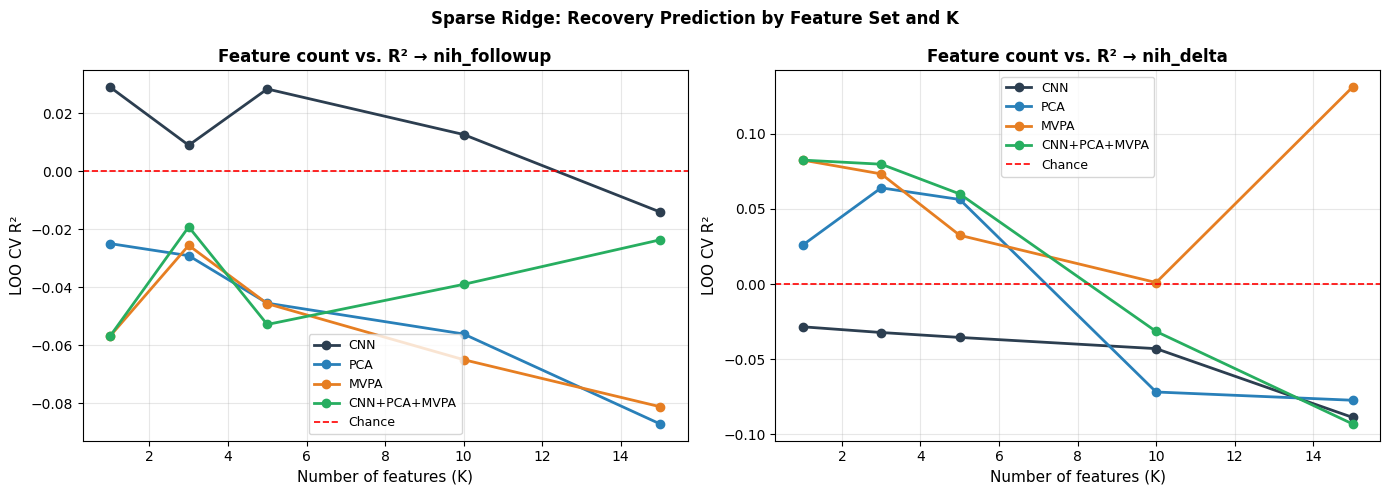

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# SPARSE CV: use only top-K features by univariate Spearman |ρ| with outcome
# Avoids overfitting while keeping the most informative features
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import r2_score

def cv_r2_topk(X_df, y_col, feats, k=10, nan_thresh=0.5, min_rows=8):
    available = [f for f in feats if f in X_df.columns]
    nan_rate  = X_df[available].isna().mean()
    available = [f for f in available if nan_rate[f] <= nan_thresh]
    if not available:
        return np.nan, 0, []
    sub = X_df[available + [y_col]].dropna()
    if len(sub) < min_rows:
        return np.nan, len(sub), []

    y_ = sub[y_col].values
    if np.std(y_) == 0:
        return np.nan, len(sub), []

    # Univariate ranking — computed on full set (mild leakage, acceptable for feature selection)
    rhos = {f: abs(stats.spearmanr(sub[f], y_)[0]) for f in available}
    top_feats = sorted(rhos, key=rhos.get, reverse=True)[:k]

    X  = SimpleImputer(strategy='median').fit_transform(sub[top_feats].values)
    X  = StandardScaler().fit_transform(X)

    model  = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
    y_pred = np.full_like(y_, np.nan, dtype=float)
    for train_idx, test_idx in LeaveOneOut().split(X):
        model.fit(X[train_idx], y_[train_idx])
        y_pred[test_idx] = model.predict(X[test_idx])

    return r2_score(y_, y_pred), len(sub), top_feats


# Sweep k = 1, 3, 5, 10 to find the sweet spot
k_values = [1, 3, 5, 10, 15]
sweep_rows = []
for outcome in ['nih_followup', 'nih_delta']:
    if outcome not in recovery_df.columns:
        continue
    for method, feats in method_feature_map.items():
        for k in k_values:
            r2, n, top = cv_r2_topk(recovery_df, outcome, feats, k=k)
            sweep_rows.append({
                'Outcome': outcome, 'Method': method,
                'K': k, 'LOO_R2': r2, 'N': n,
                'Top1_feat': top[0] if top else ''
            })

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.pivot_table(
    index=['Outcome','Method'], columns='K', values='LOO_R2'
).round(3).to_string())

# Plot sweep
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, outcome in zip(axes, ['nih_followup', 'nih_delta']):
    sub = sweep_df[sweep_df['Outcome'] == outcome]
    for method, color in zip(['CNN','PCA','MVPA','CNN+PCA+MVPA'],
                              ['#2c3e50','#2980b9','#e67e22','#27ae60']):
        m = sub[sub['Method'] == method]
        ax.plot(m['K'], m['LOO_R2'], marker='o', label=method, color=color, linewidth=2)
    ax.axhline(0, color='red', linewidth=1.2, linestyle='--', label='Chance')
    ax.set_xlabel('Number of features (K)', fontsize=11)
    ax.set_ylabel('LOO CV R²', fontsize=11)
    ax.set_title(f'Feature count vs. R² → {outcome}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Sparse Ridge: Recovery Prediction by Feature Set and K',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


nih_followup | CNN | K=1 | LOO R²=0.029
  CNN_R_path_length                              ρ=-0.250  p=0.0253

nih_delta | MVPA | K=15 | LOO R²=0.131
  MVPA_L_euc_range                               ρ=0.361  p=0.0029
  MVPA_L_euc_mean                                ρ=-0.326  p=0.0076
  MVPA_L_euc_rms                                 ρ=-0.320  p=0.0088
  MVPA_L_sd                                      ρ=-0.305  p=0.0127
  MVPA_L_var                                     ρ=-0.305  p=0.0127
  MVPA_LR_mean_asym                              ρ=-0.296  p=0.0158
  MVPA_L_max_speed                               ρ=0.264  p=0.0321
  MVPA_L_euc_sd                                  ρ=-0.230  p=0.0629
  MVPA_L_euc_var                                 ρ=-0.230  p=0.0629
  MVPA_L_euc_ac1                                 ρ=-0.223  p=0.0723
  MVPA_L_euc_spec_entropy                        ρ=0.206  p=0.0973
  MVPA_R_euc_rms                                 ρ=-0.194  p=0.1180
  MVPA_R_sd                           

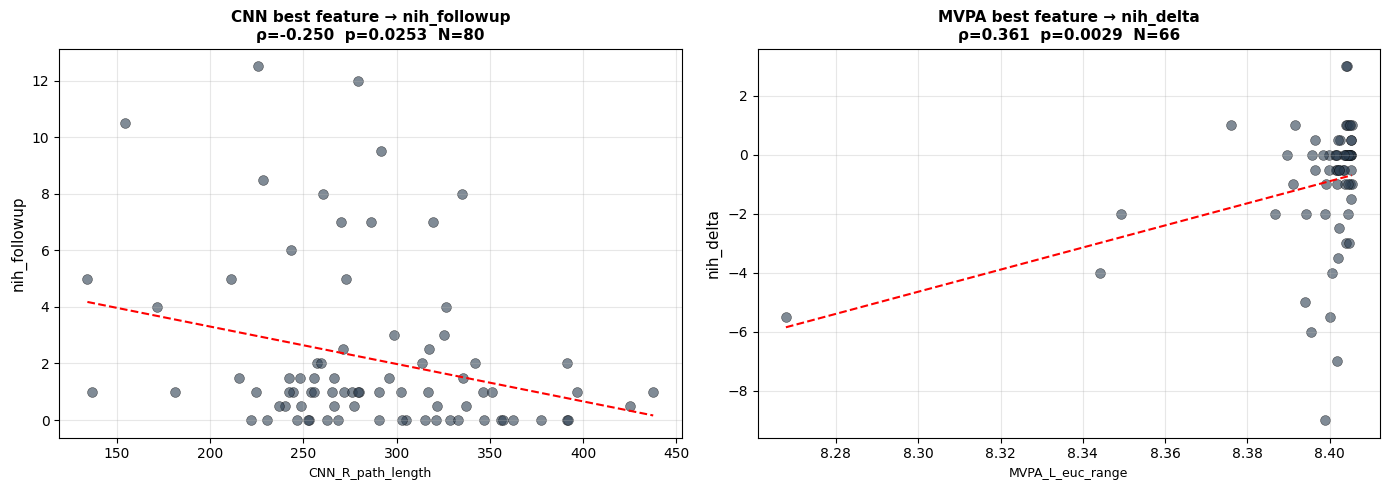

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Identify the single best CNN feature for nih_followup (K=1)
#    and the top MVPA features for nih_delta (K=15)
# ─────────────────────────────────────────────────────────────────────────────
for outcome, method, k in [('nih_followup', 'CNN', 1),
                            ('nih_delta',    'MVPA', 15),
                            ('nih_delta',    'CNN+PCA+MVPA', 15)]:
    feats    = [f for f in method_feature_map[method] if f in recovery_df.columns]
    nan_rate = recovery_df[feats].isna().mean()
    feats    = [f for f in feats if nan_rate[f] <= 0.5]
    sub      = recovery_df[feats + [outcome]].dropna()
    y_       = sub[outcome].values
    rhos     = {f: abs(stats.spearmanr(sub[f], y_)[0]) for f in feats}
    top      = sorted(rhos, key=rhos.get, reverse=True)[:k]
    r2, _, _ = cv_r2_topk(recovery_df, outcome, feats, k=k)

    print(f"\n{outcome} | {method} | K={k} | LOO R²={r2:.3f}")
    for feat in top:
        rho, p = stats.spearmanr(sub[feat], y_)
        print(f"  {feat:<45}  ρ={rho:.3f}  p={p:.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# 2. Scatter plots: best feature vs outcome
# ─────────────────────────────────────────────────────────────────────────────
best_pairs = [('nih_followup', 'CNN',  1),
              ('nih_delta',    'MVPA', 15)]

fig, axes = plt.subplots(1, len(best_pairs), figsize=(7 * len(best_pairs), 5))
for ax, (outcome, method, k) in zip(axes, best_pairs):
    feats    = [f for f in method_feature_map[method] if f in recovery_df.columns]
    nan_rate = recovery_df[feats].isna().mean()
    feats    = [f for f in feats if nan_rate[f] <= 0.5]
    sub      = recovery_df[feats + [outcome]].dropna()
    y_       = sub[outcome].values
    rhos     = {f: abs(stats.spearmanr(sub[f], y_)[0]) for f in feats}
    top_feat = sorted(rhos, key=rhos.get, reverse=True)[0]
    x_       = sub[top_feat].values
    rho, p   = stats.spearmanr(x_, y_)

    ax.scatter(x_, y_, alpha=0.6, s=50, color='#2c3e50', edgecolors='black', linewidth=0.4)
    m, b     = np.polyfit(x_, y_, 1)
    xline    = np.linspace(x_.min(), x_.max(), 100)
    ax.plot(xline, m * xline + b, 'r--', linewidth=1.5)
    ax.set_xlabel(top_feat, fontsize=9)
    ax.set_ylabel(outcome, fontsize=11)
    ax.set_title(f'{method} best feature → {outcome}\nρ={rho:.3f}  p={p:.4f}  N={len(sub)}',
                 fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

MVPA LEFT vs RIGHT EYE: nih_delta correlations
          Feature  rho_Left   p_Left  rho_Right  p_Right  lateralization
        euc_range  0.360820 0.002918   0.124962 0.317444        0.235858
        max_speed  0.264180 0.032078  -0.052413 0.675979        0.211767
          euc_var -0.230253 0.062897  -0.052413 0.675979        0.177840
          euc_rms -0.320019 0.008807  -0.177206 0.154617        0.142814
         euc_mean -0.325688 0.007618  -0.194275 0.118035        0.131413
 euc_spec_entropy  0.205866 0.097253   0.075278 0.548023        0.130588
MVPA_LR_mean_asym -0.295970 0.015828  -0.172827 0.165230        0.123143
          euc_ac1 -0.222702 0.072285   0.164451 0.187006        0.058251
           euc_sd -0.230253 0.062897   0.174964 0.159986        0.055290
  MVPA_LR_sd_asym -0.100469 0.422177   0.102330 0.413586       -0.001861
         euc_mssd  0.153601 0.218196  -0.177206 0.154617       -0.023605
     MVPA_LR_corr  0.065400 0.601866  -0.168301 0.176754       -0.102901
    

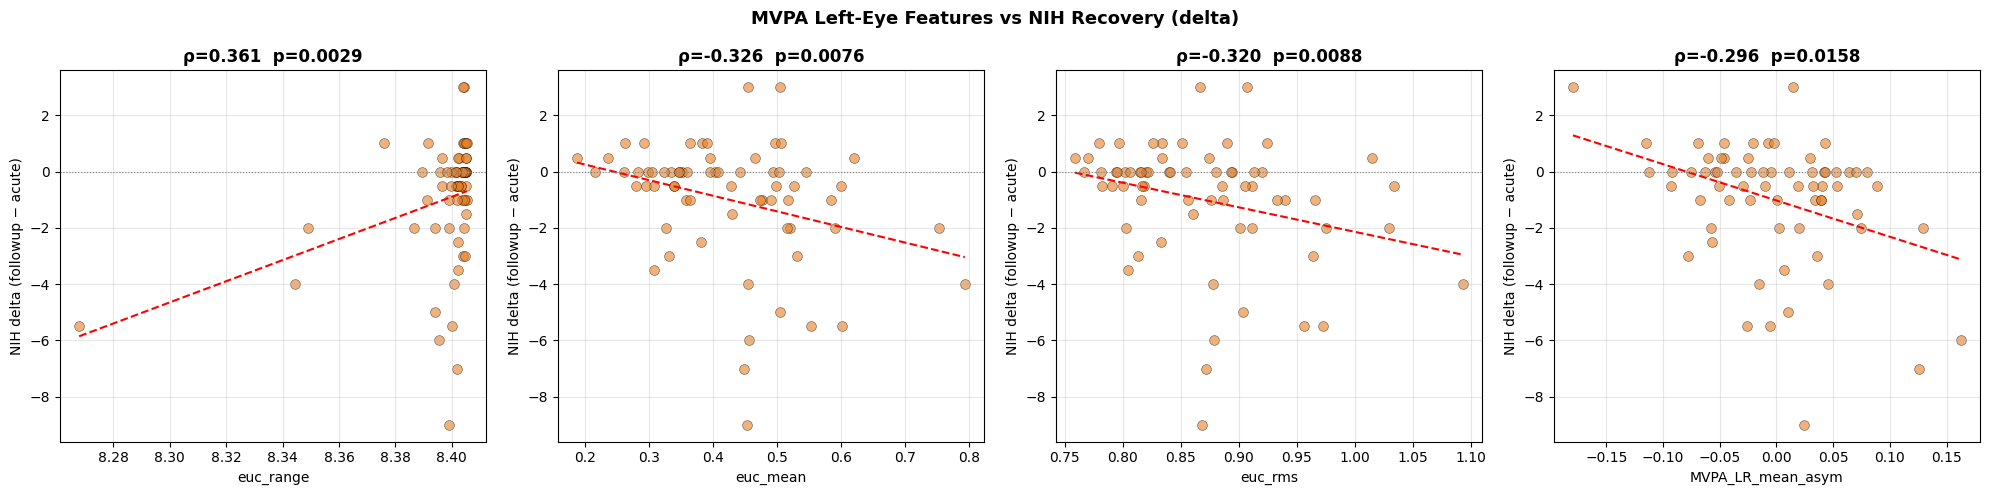

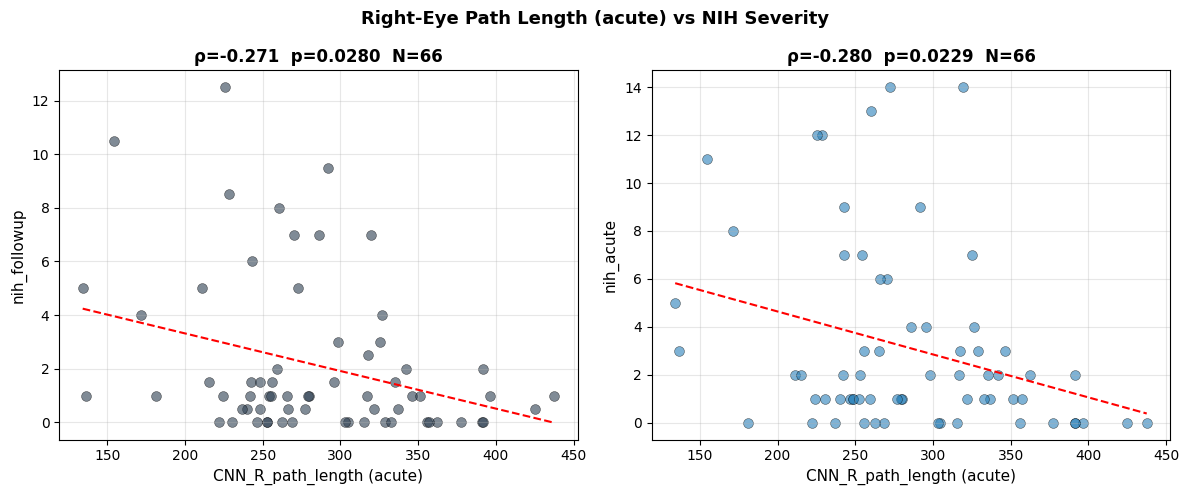


MVPA left-eye features vs nih_delta — FDR corrected:
  MVPA_L_euc_range                          ρ=0.361  p=0.0029  p_fdr=0.0433  *
  MVPA_L_euc_mean                           ρ=-0.326  p=0.0076  p_fdr=0.0433  *
  MVPA_L_euc_rms                            ρ=-0.320  p=0.0088  p_fdr=0.0433  *
  MVPA_L_sd                                 ρ=-0.305  p=0.0127  p_fdr=0.0433  *
  MVPA_L_var                                ρ=-0.305  p=0.0127  p_fdr=0.0433  *
  MVPA_LR_mean_asym                         ρ=-0.296  p=0.0158  p_fdr=0.0448  *
  MVPA_L_max_speed                          ρ=0.264  p=0.0321  p_fdr=0.0779  
  MVPA_L_euc_sd                             ρ=-0.230  p=0.0629  p_fdr=0.1188  
  MVPA_L_euc_var                            ρ=-0.230  p=0.0629  p_fdr=0.1188  
  MVPA_L_euc_ac1                            ρ=-0.223  p=0.0723  p_fdr=0.1229  
  MVPA_L_euc_spec_entropy                   ρ=0.206  p=0.0973  p_fdr=0.1503  
  MVPA_L_euc_mssd                           ρ=0.154  p=0.2182  p_fdr=0.309

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# DEEPER DIVE: left-eye dominance + lateralization analysis
# ─────────────────────────────────────────────────────────────────────────────

# 1. Left vs Right feature correlations side by side for MVPA
print("=" * 65)
print("MVPA LEFT vs RIGHT EYE: nih_delta correlations")
print("=" * 65)
sub = recovery_df[[c for c in recovery_df.columns
                   if c.startswith('MVPA')] + ['nih_delta']].dropna()

left_feats  = [c for c in sub.columns if c.startswith('MVPA_L') and c != 'nih_delta']
right_feats = [c for c in sub.columns if c.startswith('MVPA_R') and c != 'nih_delta']

rows = []
for lf, rf in zip(sorted(left_feats), sorted(right_feats)):
    base = lf.replace('MVPA_L_','')
    rho_l, p_l = stats.spearmanr(sub[lf], sub['nih_delta'])
    rho_r, p_r = stats.spearmanr(sub[rf], sub['nih_delta'])
    rows.append({'Feature': base,
                 'rho_Left': rho_l, 'p_Left': p_l,
                 'rho_Right': rho_r, 'p_Right': p_r,
                 'lateralization': abs(rho_l) - abs(rho_r)})

lat_df = pd.DataFrame(rows).sort_values('lateralization', ascending=False)
print(lat_df.to_string(index=False))

# 2. Scatter: top 4 MVPA_L features vs nih_delta
top4 = ['MVPA_L_euc_range', 'MVPA_L_euc_mean', 'MVPA_L_euc_rms', 'MVPA_LR_mean_asym']
sub4 = recovery_df[top4 + ['nih_delta']].dropna()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, feat in zip(axes, top4):
    x_   = sub4[feat].values
    y_   = sub4['nih_delta'].values
    rho, p = stats.spearmanr(x_, y_)
    ax.scatter(x_, y_, alpha=0.6, s=50,
               color='#e67e22', edgecolors='black', linewidth=0.4)
    m, b = np.polyfit(x_, y_, 1)
    xline = np.linspace(x_.min(), x_.max(), 100)
    ax.plot(xline, m * xline + b, 'r--', linewidth=1.5)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xlabel(feat.replace('MVPA_L_',''), fontsize=10)
    ax.set_ylabel('NIH delta (followup − acute)', fontsize=10)
    ax.set_title(f'ρ={rho:.3f}  p={p:.4f}', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('MVPA Left-Eye Features vs NIH Recovery (delta)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. CNN_R_path_length vs nih_followup (the K=1 winner)
sub5 = recovery_df[['CNN_R_path_length','nih_followup','nih_acute']].dropna()
rho, p = stats.spearmanr(sub5['CNN_R_path_length'], sub5['nih_followup'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, outcome, color in zip(axes,
                               ['nih_followup', 'nih_acute'],
                               ['#2c3e50',      '#2980b9']):
    if outcome not in sub5.columns:
        continue
    x_ = sub5['CNN_R_path_length'].values
    y_ = sub5[outcome].values
    rho_i, p_i = stats.spearmanr(x_, y_)
    ax.scatter(x_, y_, alpha=0.6, s=50,
               color=color, edgecolors='black', linewidth=0.4)
    m, b  = np.polyfit(x_, y_, 1)
    xline = np.linspace(x_.min(), x_.max(), 100)
    ax.plot(xline, m * xline + b, 'r--', linewidth=1.5)
    ax.set_xlabel('CNN_R_path_length (acute)', fontsize=11)
    ax.set_ylabel(outcome, fontsize=11)
    ax.set_title(f'ρ={rho_i:.3f}  p={p_i:.4f}  N={len(sub5)}',
                 fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Right-Eye Path Length (acute) vs NIH Severity',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. FDR-correct the top MVPA_L features specifically
from statsmodels.stats.multitest import fdrcorrection
rhos_all = [stats.spearmanr(sub[f], sub['nih_delta']) for f in left_feats]
pvals    = [r[1] for r in rhos_all]
_, p_fdr = fdrcorrection(pvals)
print("\nMVPA left-eye features vs nih_delta — FDR corrected:")
for f, (rho, p), pfdr in sorted(zip(left_feats, rhos_all, p_fdr),
                                  key=lambda x: abs(x[1][0]), reverse=True):
    sig = '***' if pfdr < 0.001 else '**' if pfdr < 0.01 else '*' if pfdr < 0.05 else ''
    print(f"  {f:<40}  ρ={rho:.3f}  p={p:.4f}  p_fdr={pfdr:.4f}  {sig}")

In [13]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings("ignore")

os.makedirs("output", exist_ok=True)

# =============================================================================
# CONFIG
# =============================================================================
OUTCOME      = "nih_delta"
MIN_N_SUBGRP = 8
ALPHA_FDR    = 0.05

KEY_FEATS = [
    "MVPA_L_euc_range", "MVPA_L_euc_mean",  "MVPA_L_euc_rms",
    "MVPA_L_sd",        "MVPA_L_var",        "MVPA_LR_mean_asym",
    "MVPA_L_max_speed", "MVPA_L_euc_sd",     "MVPA_L_euc_var",
]

SITE_LABELS = {
    0:"Subcortical", 1:"Cortical", 2:"Cortico-sub",
    3:"WM only",     4:"Brainstem", 5:"Cerebellar", 6:"Other"
}

# =============================================================================
# 1. ENRICH recovery_df WITH CLINICAL SUBGROUP VARIABLES
#    Pulls from acute session only (one row per subject)
# =============================================================================
clin_cols = [
    "ID","lesion_site","lesion_side","lesion_type","lesion_size","nihss_hospital",
    "lcst","rcst",
    "motor_er___2","motor_er___3","motor_er___4","motor_er___5",   # arm/leg paresis
    "visual_er___1","visual_er___2","visual_er___3",                # visual symptoms
    "attention_er___1",                                             # neglect
    "bigfactor1","bigfactor2","bigfactor3",
]
acute_clin = (stroke_csv[stroke_csv["Session"] == "acute"]
              .drop_duplicates(subset="ID")[clin_cols].copy())

motor_cols  = ["motor_er___2","motor_er___3","motor_er___4","motor_er___5"]
visual_cols = ["visual_er___1","visual_er___2","visual_er___3"]
for c in motor_cols + visual_cols + ["attention_er___1"]:
    acute_clin[c] = pd.to_numeric(acute_clin[c], errors="coerce").fillna(0)

acute_clin["any_motor"]   = (acute_clin[motor_cols].sum(axis=1)  > 0).astype(int)
acute_clin["any_visual"]  = (acute_clin[visual_cols].sum(axis=1) > 0).astype(int)
acute_clin["any_neglect"] = acute_clin["attention_er___1"].astype(int)
acute_clin["lcst_n"]      = pd.to_numeric(acute_clin["lcst"], errors="coerce").fillna(0)
acute_clin["rcst_n"]      = pd.to_numeric(acute_clin["rcst"], errors="coerce").fillna(0)
acute_clin["any_cst"]     = ((acute_clin["lcst_n"] + acute_clin["rcst_n"]) > 0).astype(int)
acute_clin["nihss_num"]   = pd.to_numeric(acute_clin["nihss_hospital"], errors="coerce")
nihss_med                 = acute_clin["nihss_num"].median()
acute_clin["sev_group"]   = np.where(
    acute_clin["nihss_num"] <= nihss_med, "Mild", "Severe")
print(f"NIHSS hospital median: {nihss_med}")

rdf = recovery_df.merge(acute_clin, on="ID", how="left")
print(f"Enriched recovery_df: {rdf.shape},  nih_delta N={rdf[OUTCOME].notna().sum()}")

# =============================================================================
# 2. HELPER: Spearman ρ + within-subgroup FDR correction
# =============================================================================
def subgroup_corr(subdf, features, outcome, label):
    rows = []
    for feat in features:
        if feat not in subdf.columns:
            continue
        valid = subdf[[feat, outcome]].dropna()
        n = len(valid)
        if n < MIN_N_SUBGRP:
            rows.append(dict(Feature=feat, Subgroup=label, N=n,
                             rho=np.nan, p=np.nan))
            continue
        rho, p = stats.spearmanr(valid[feat], valid[outcome])
        rows.append(dict(Feature=feat, Subgroup=label, N=n, rho=rho, p=p))
    out = pd.DataFrame(rows)
    if out["p"].notna().sum() > 1:
        mask = out["p"].notna()
        _, pc = fdrcorrection(out.loc[mask, "p"].values)
        out.loc[mask, "p_fdr"] = pc
    out["sig_fdr"] = out.get("p_fdr", pd.Series(np.nan, index=out.index)) < ALPHA_FDR
    return out

# =============================================================================
# 3. RUN ALL SUBGROUP ANALYSES
# =============================================================================
results = []

# A – full sample (reference)
results.append(subgroup_corr(rdf, KEY_FEATS, OUTCOME, "Full sample"))

# B – lesion side  (0=Left, 1=Right)
for val, lbl in [(0, "Left lesion"), (1, "Right lesion")]:
    results.append(subgroup_corr(rdf[rdf["lesion_side"] == val], KEY_FEATS, OUTCOME, lbl))

# C – lesion site
for val, lbl in SITE_LABELS.items():
    sub = rdf[rdf["lesion_site"] == val]
    if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
        results.append(subgroup_corr(sub, KEY_FEATS, OUTCOME, lbl))

# D – supra- vs infra-tentorial
rdf["infra"] = rdf["lesion_site"].isin([4, 5]).astype(int)
for val, lbl in [(0, "Supratentorial"), (1, "Infratentorial")]:
    sub = rdf[rdf["infra"] == val]
    if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
        results.append(subgroup_corr(sub, KEY_FEATS, OUTCOME, lbl))

# E – lesion type
for val, lbl in [(0, "Ischemic"), (1, "Hemorrhagic")]:
    sub = rdf[rdf["lesion_type"] == val]
    if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
        results.append(subgroup_corr(sub, KEY_FEATS, OUTCOME, lbl))

# F – severity (NIHSS at hospital, median split)
for lbl in ["Mild", "Severe"]:
    results.append(subgroup_corr(
        rdf[rdf["sev_group"] == lbl], KEY_FEATS, OUTCOME, f"NIHSS-{lbl}"))

# G – motor symptom at ER
for val, lbl in [(1, "Motor sx+"), (0, "Motor sx-")]:
    results.append(subgroup_corr(rdf[rdf["any_motor"] == val], KEY_FEATS, OUTCOME, lbl))

# H – visual symptom at ER
for val, lbl in [(1, "Visual sx+"), (0, "Visual sx-")]:
    sub = rdf[rdf["any_visual"] == val]
    if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
        results.append(subgroup_corr(sub, KEY_FEATS, OUTCOME, lbl))

# I – neglect at ER
for val, lbl in [(1, "Neglect+"), (0, "Neglect-")]:
    sub = rdf[rdf["any_neglect"] == val]
    if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
        results.append(subgroup_corr(sub, KEY_FEATS, OUTCOME, lbl))

# J – corticospinal tract involvement
for val, lbl in [(1, "CST overlap+"), (0, "CST overlap-")]:
    sub = rdf[rdf["any_cst"] == val]
    if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
        results.append(subgroup_corr(sub, KEY_FEATS, OUTCOME, lbl))

sg_df = pd.concat(results, ignore_index=True)
sg_df["abs_rho"] = sg_df["rho"].abs()
sg_df.to_csv("output/subgroup_MVPA_L_nih_delta.csv", index=False)

# Print summary
print("\n" + "="*70)
print("SUBGROUP ANALYSIS SUMMARY  (FDR-corrected within each subgroup)")
for sg in sg_df["Subgroup"].unique():
    sub = sg_df[sg_df["Subgroup"] == sg].sort_values("abs_rho", ascending=False)
    n_  = sub["N"].max()
    print(f"\n[{sg}]  N≈{int(n_) if not pd.isna(n_) else '?'}")
    for _, r in sub[sub["p"].notna()].iterrows():
        pf = f"{r.get('p_fdr', np.nan):.4f}" if not pd.isna(r.get("p_fdr", np.nan)) else "NA"
        s  = "*" if r.get("sig_fdr", False) else " "
        print(f"  {r.Feature:<30} rho={r.rho:+.3f}  p={r.p:.4f}  p_fdr={pf}  {s}")

# =============================================================================
# 4. HEATMAP: ρ matrix (subgroups × features)
# =============================================================================
SG_ORDER = [
    "Full sample",
    "Left lesion", "Right lesion",
    "Subcortical", "Cortical", "Cortico-sub", "WM only", "Brainstem", "Cerebellar",
    "Supratentorial", "Infratentorial",
    "Ischemic", "Hemorrhagic",
    "NIHSS-Mild", "NIHSS-Severe",
    "Motor sx+", "Motor sx-",
    "Visual sx+", "Visual sx-",
    "Neglect+", "Neglect-",
    "CST overlap+", "CST overlap-",
]
SG_AVAIL = [s for s in SG_ORDER if s in sg_df["Subgroup"].values]

pivot_rho = (sg_df.pivot_table(index="Subgroup", columns="Feature", values="rho")
             .reindex(SG_AVAIL))

NIHSS hospital median: 5.0
Enriched recovery_df: (85, 169),  nih_delta N=66

SUBGROUP ANALYSIS SUMMARY  (FDR-corrected within each subgroup)

[Full sample]  N≈66
  MVPA_L_euc_range               rho=+0.361  p=0.0029  p_fdr=0.0229  *
  MVPA_L_euc_mean                rho=-0.326  p=0.0076  p_fdr=0.0229  *
  MVPA_L_euc_rms                 rho=-0.320  p=0.0088  p_fdr=0.0229  *
  MVPA_L_sd                      rho=-0.305  p=0.0127  p_fdr=0.0229  *
  MVPA_L_var                     rho=-0.305  p=0.0127  p_fdr=0.0229  *
  MVPA_LR_mean_asym              rho=-0.296  p=0.0158  p_fdr=0.0237  *
  MVPA_L_max_speed               rho=+0.264  p=0.0321  p_fdr=0.0412  *
  MVPA_L_euc_sd                  rho=-0.230  p=0.0629  p_fdr=0.0629   
  MVPA_L_euc_var                 rho=-0.230  p=0.0629  p_fdr=0.0629   

[Left lesion]  N≈37
  MVPA_L_euc_range               rho=+0.466  p=0.0037  p_fdr=0.0331  *
  MVPA_L_euc_sd                  rho=-0.265  p=0.1136  p_fdr=0.1781   
  MVPA_L_euc_var                 rho

NIHSS median: 5.0
Enriched recovery_df: (85, 172),  nih_delta N=66
Master result table: (2033, 11)

FDR-SIGNIFICANT RESULTS  (p_fdr < 0.05, within-subgroup correction)

[Right lesion]
  -- MVPA --
    MVPA_LR_mean_asym                    LR asym     rho=-0.639  p=0.0002  p_fdr=0.0059  N=29

[Ischemic]
  -- MVPA --
    MVPA_L_euc_range                     Left eye    rho=+0.395  p=0.0041  p_fdr=0.0481  N=51
    MVPA_L_euc_rms                       Left eye    rho=-0.374  p=0.0069  p_fdr=0.0481  N=51
    MVPA_L_euc_mean                      Left eye    rho=-0.368  p=0.0080  p_fdr=0.0481  N=51
    MVPA_L_euc_ac1                       Left eye    rho=-0.364  p=0.0086  p_fdr=0.0481  N=51
    MVPA_R_euc_ac1                       Right eye   rho=-0.354  p=0.0108  p_fdr=0.0481  N=51
    MVPA_L_max_speed                     Left eye    rho=+0.354  p=0.0108  p_fdr=0.0481  N=51
    MVPA_L_sd                            Left eye    rho=-0.348  p=0.0124  p_fdr=0.0481  N=51
    MVPA_L_var            

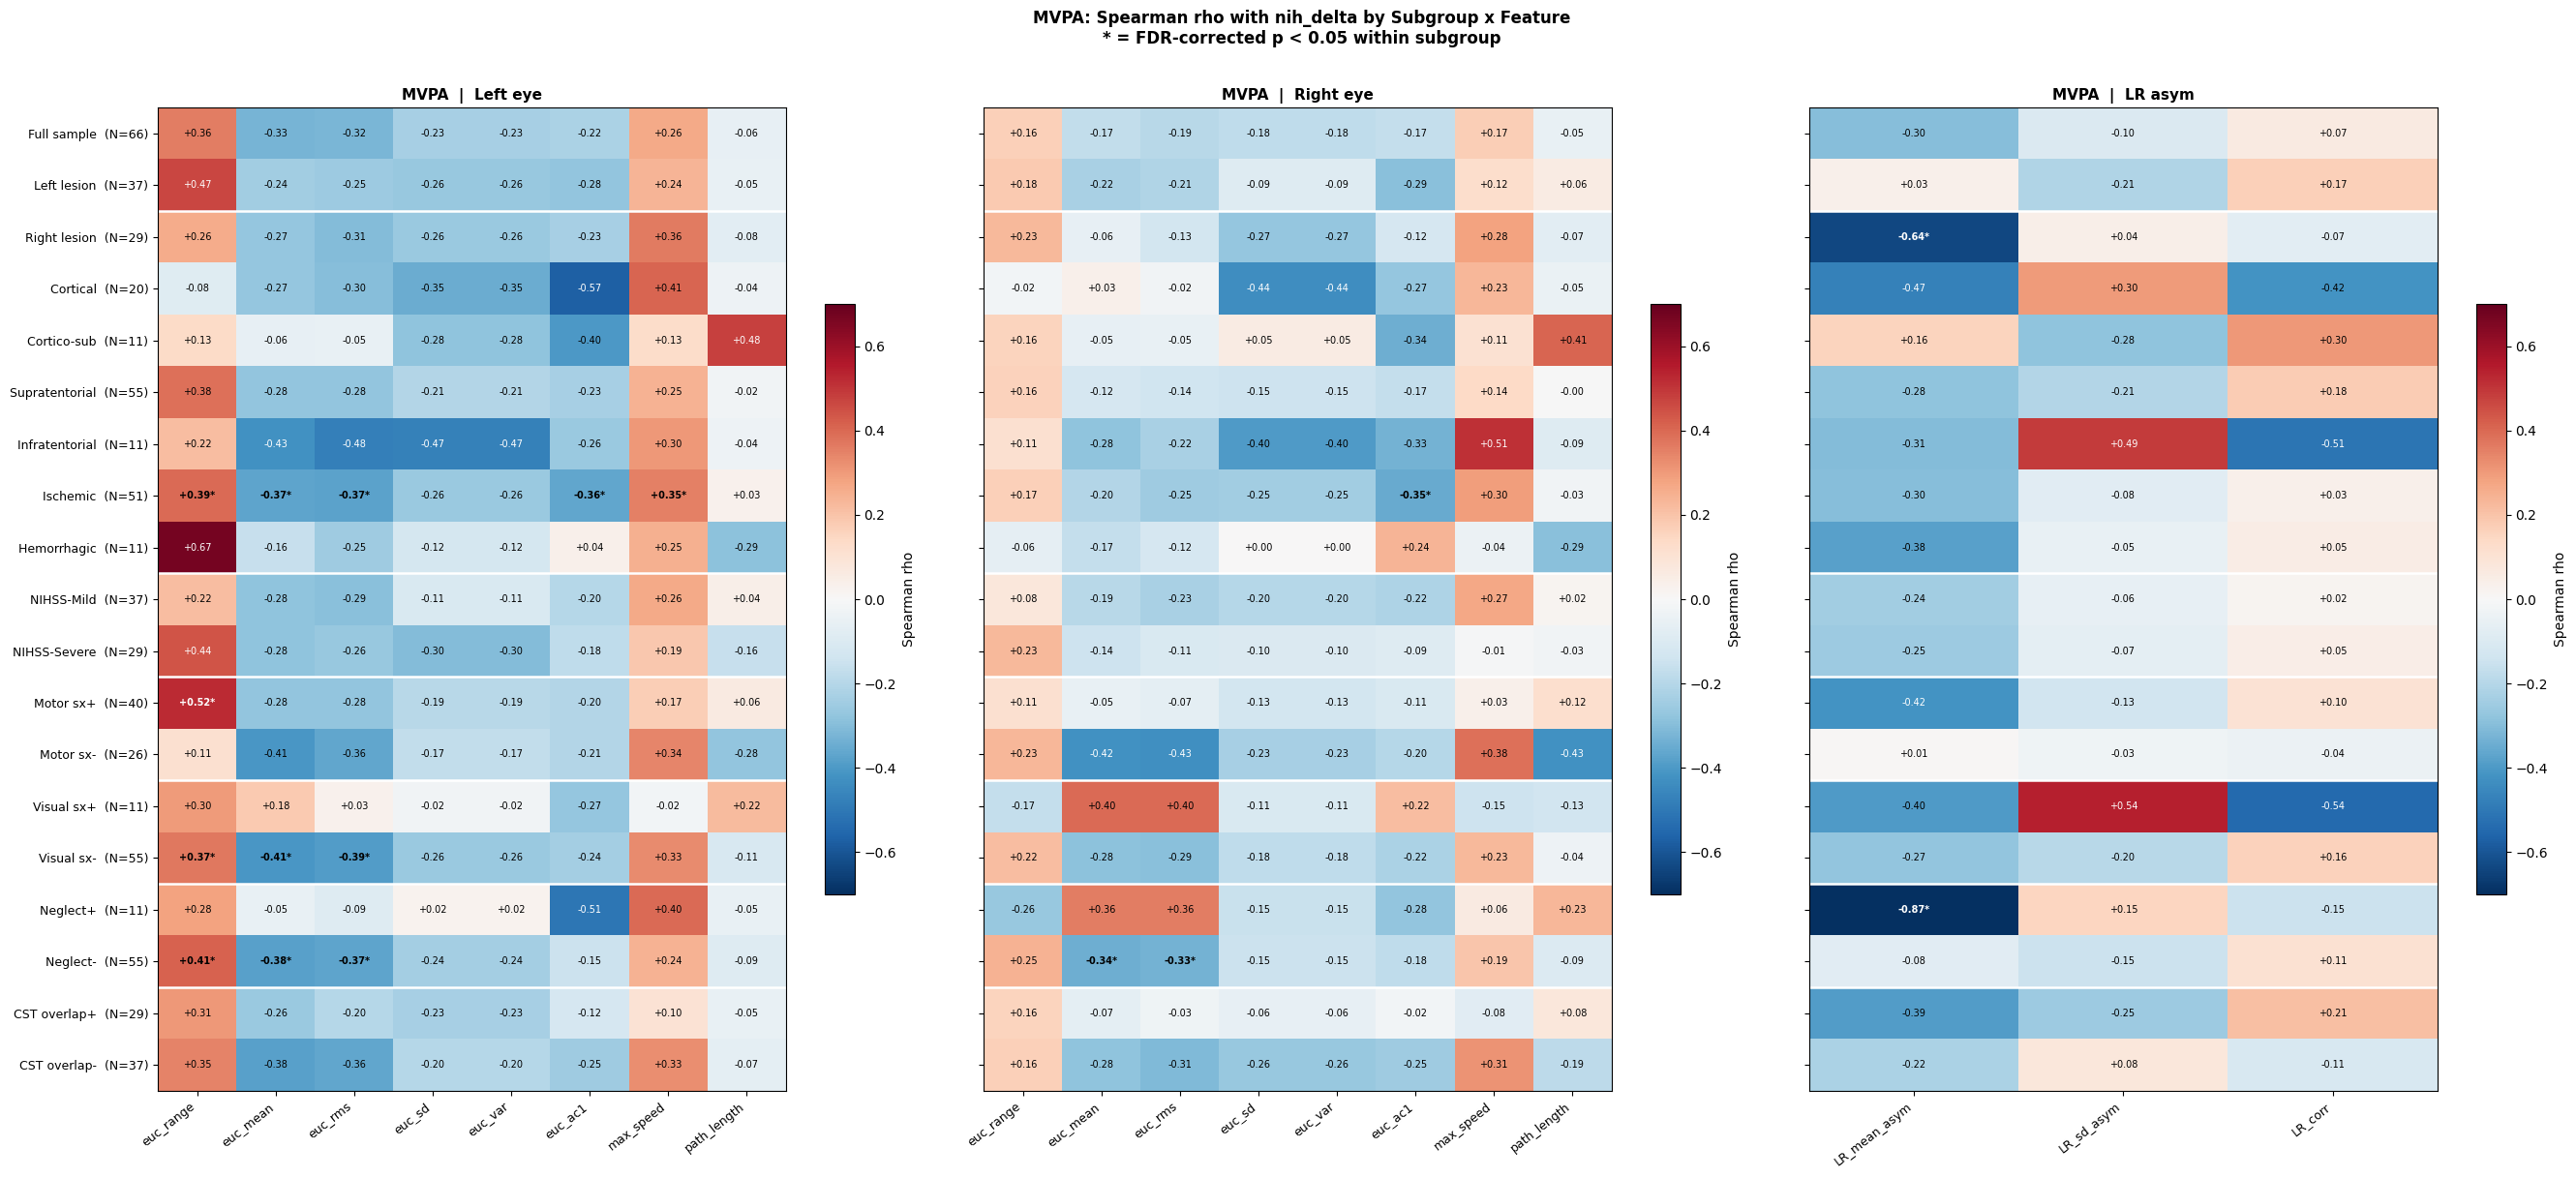

Saved: output/heatmap_MVPA_nih_delta.png


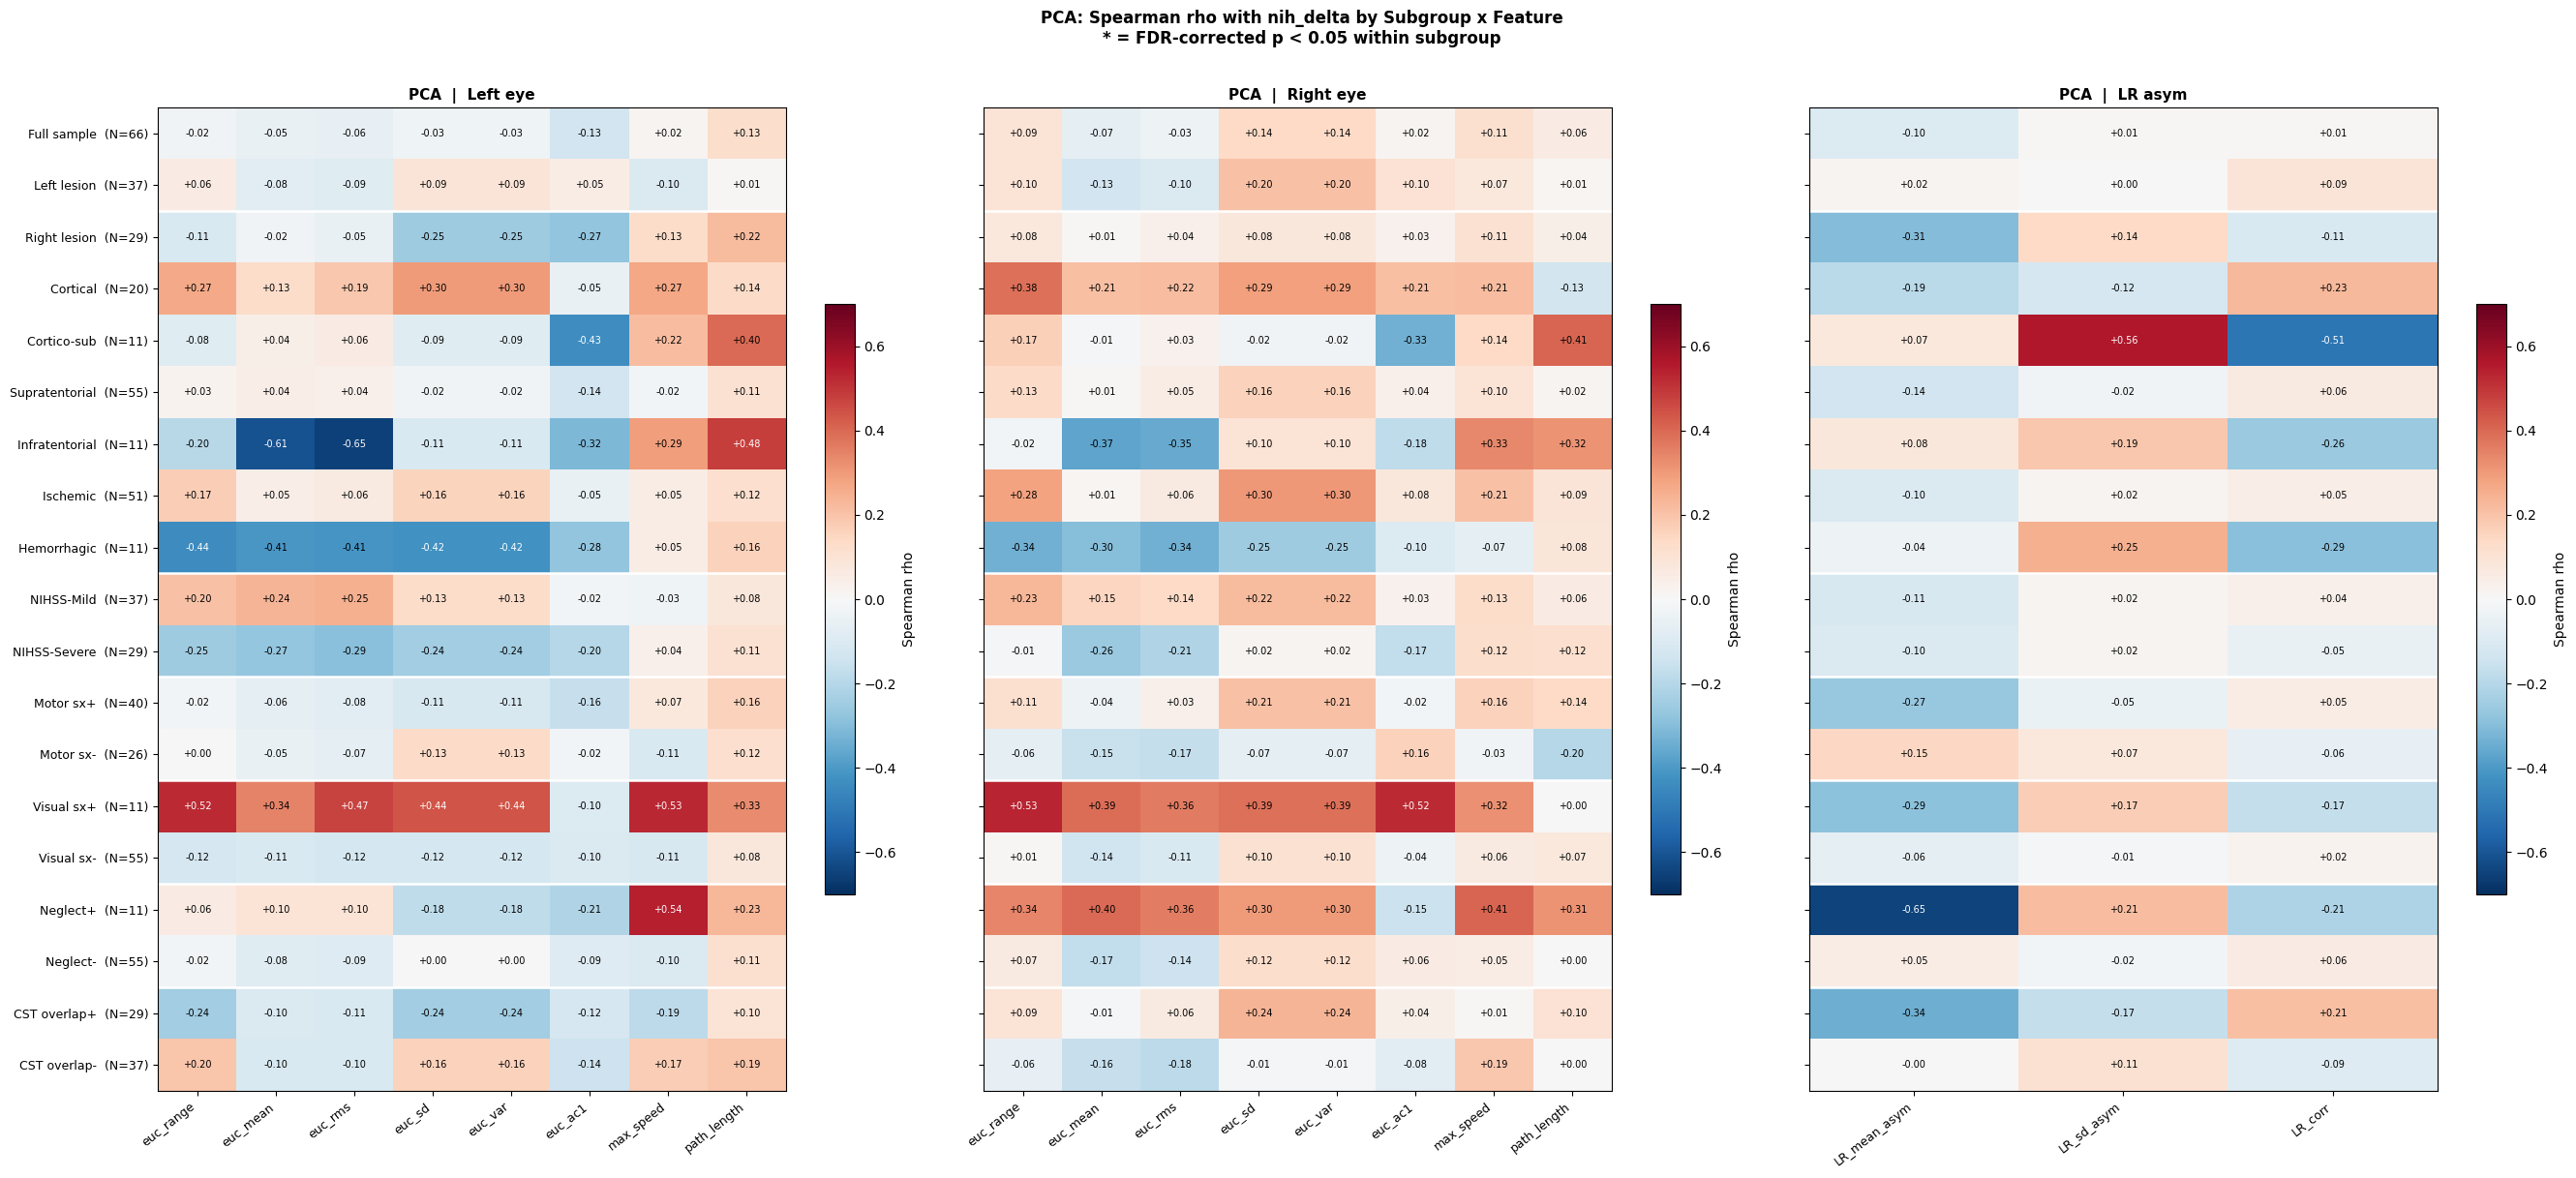

Saved: output/heatmap_PCA_nih_delta.png


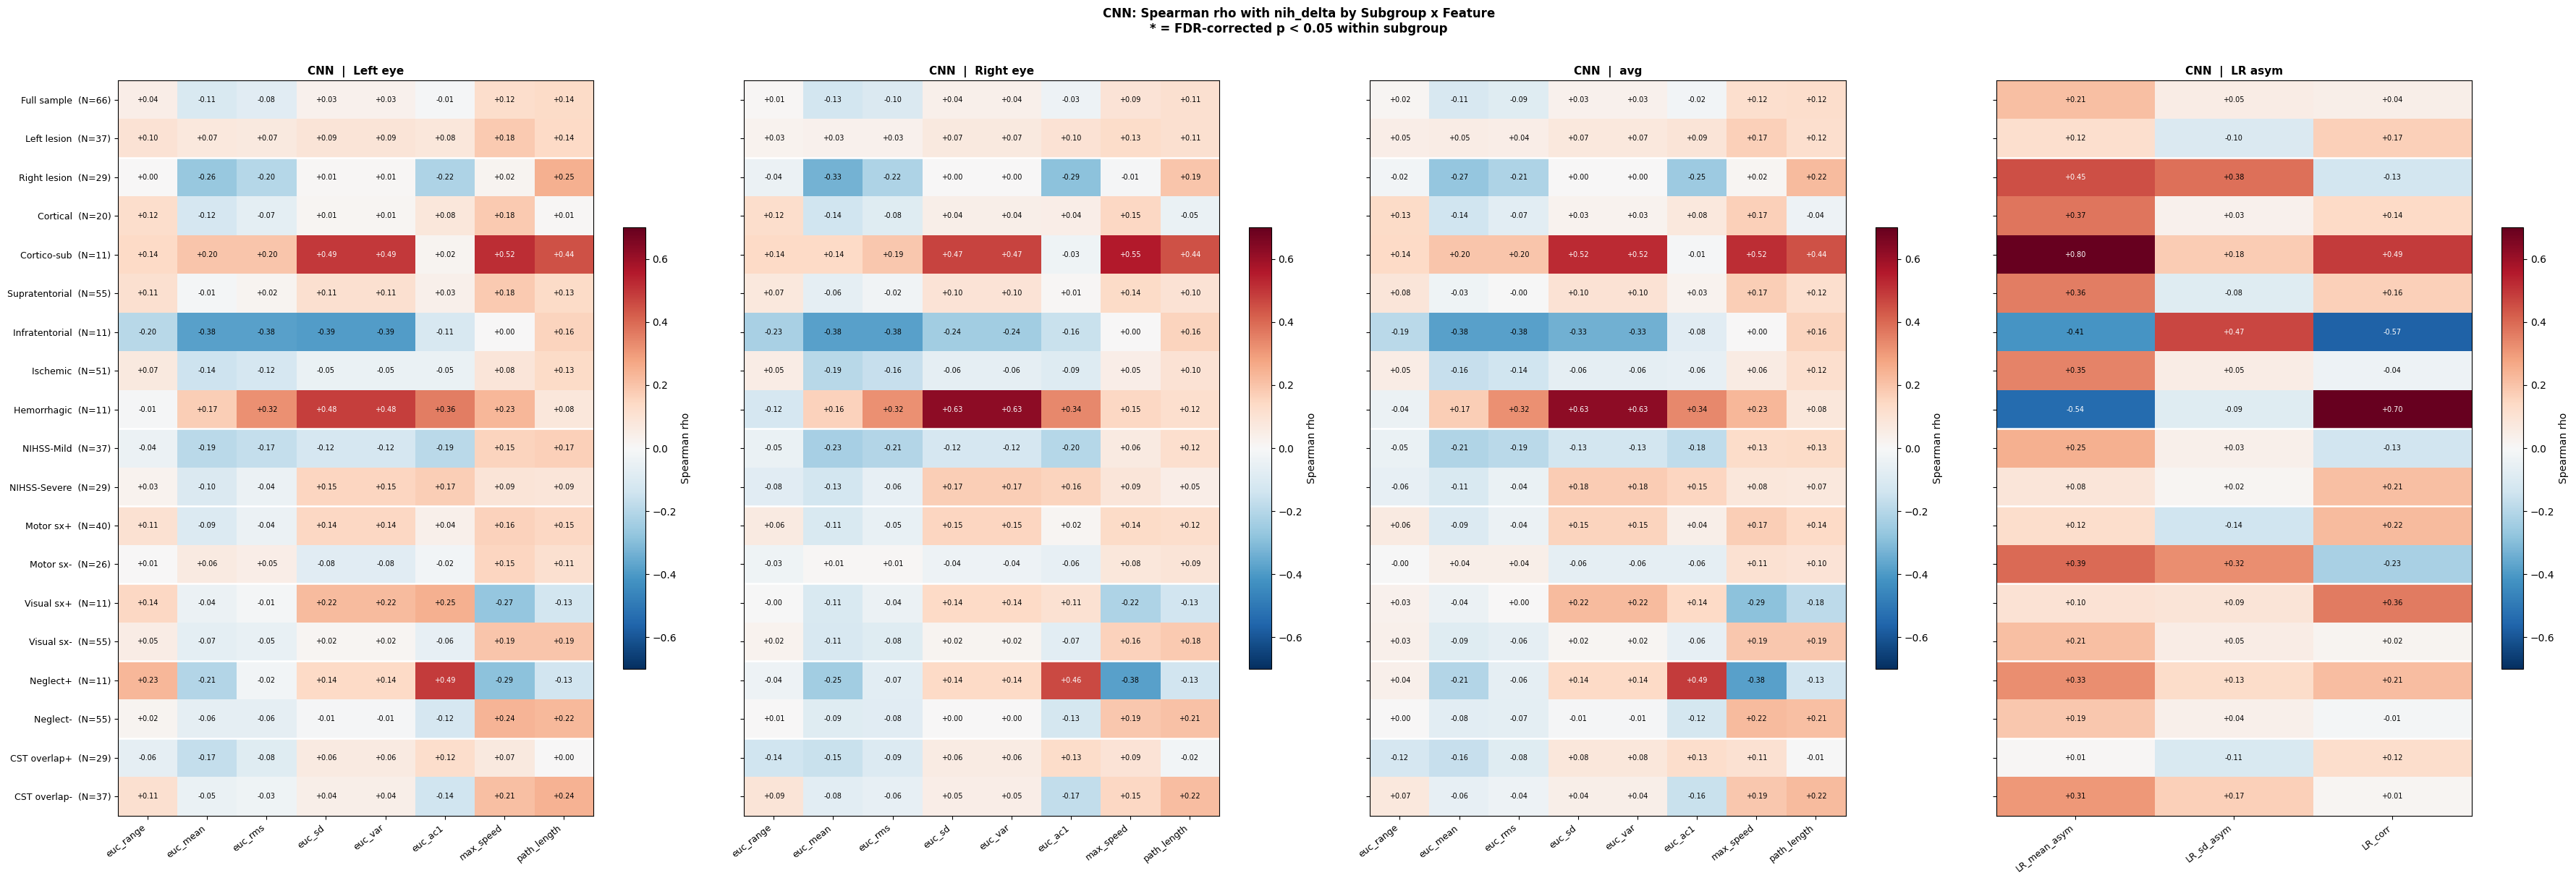

Saved: output/heatmap_CNN_nih_delta.png


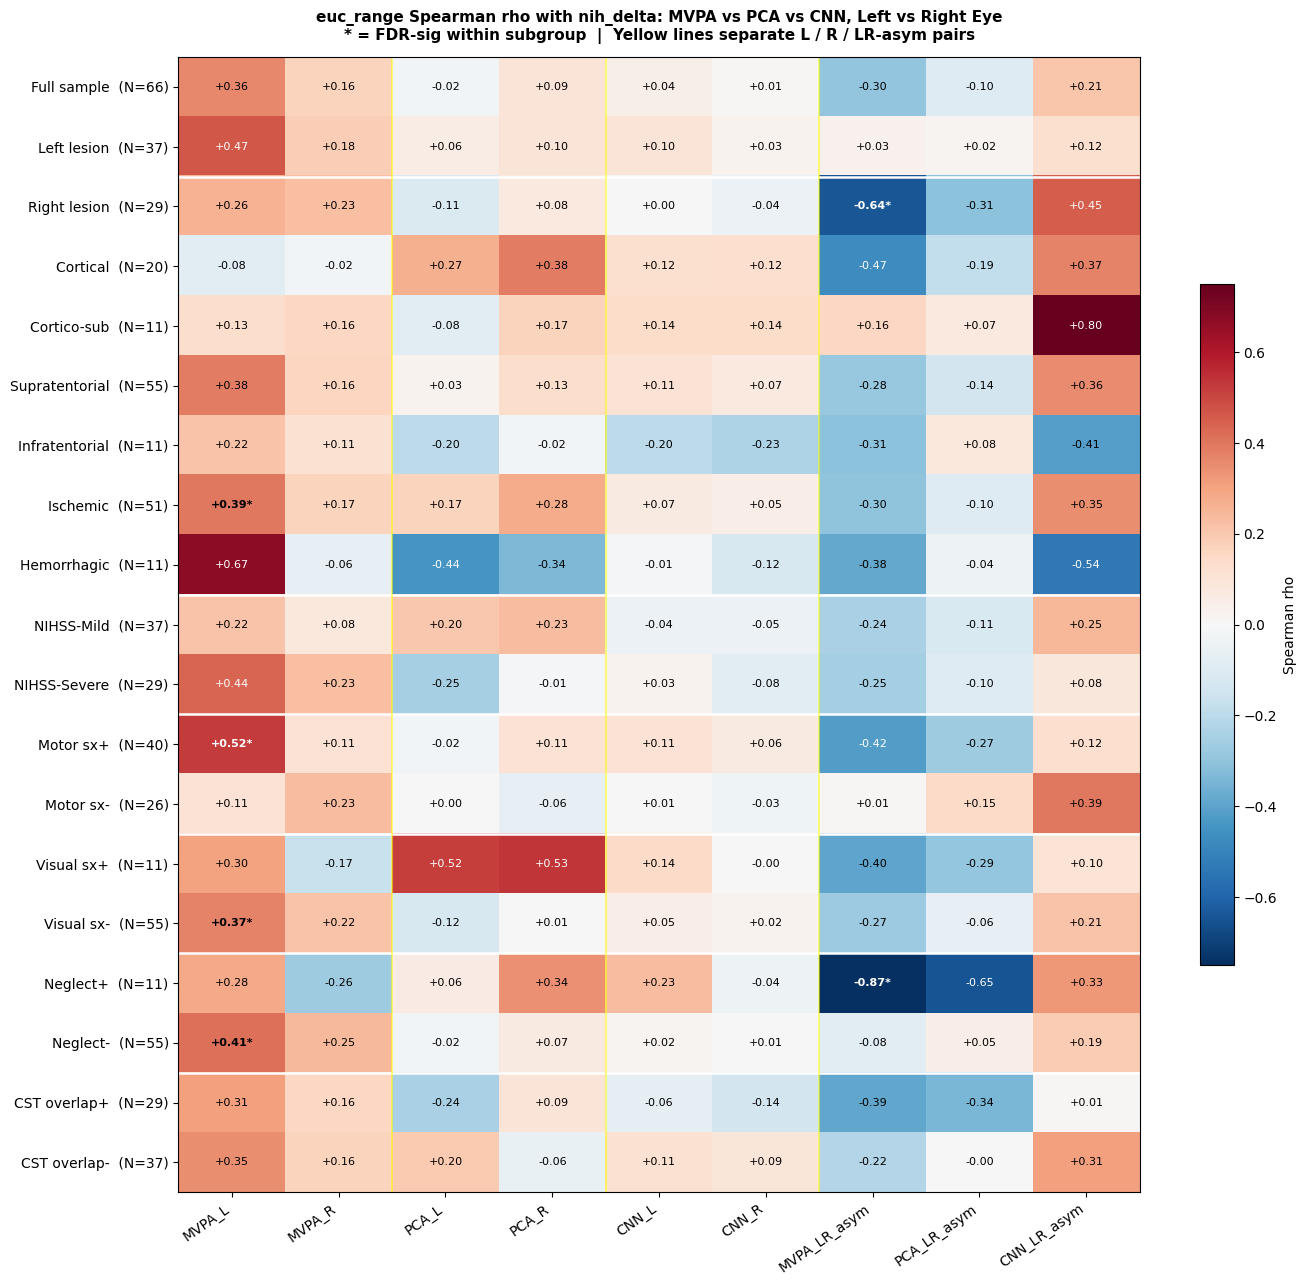

Saved: output/cross_method_heatmap.png


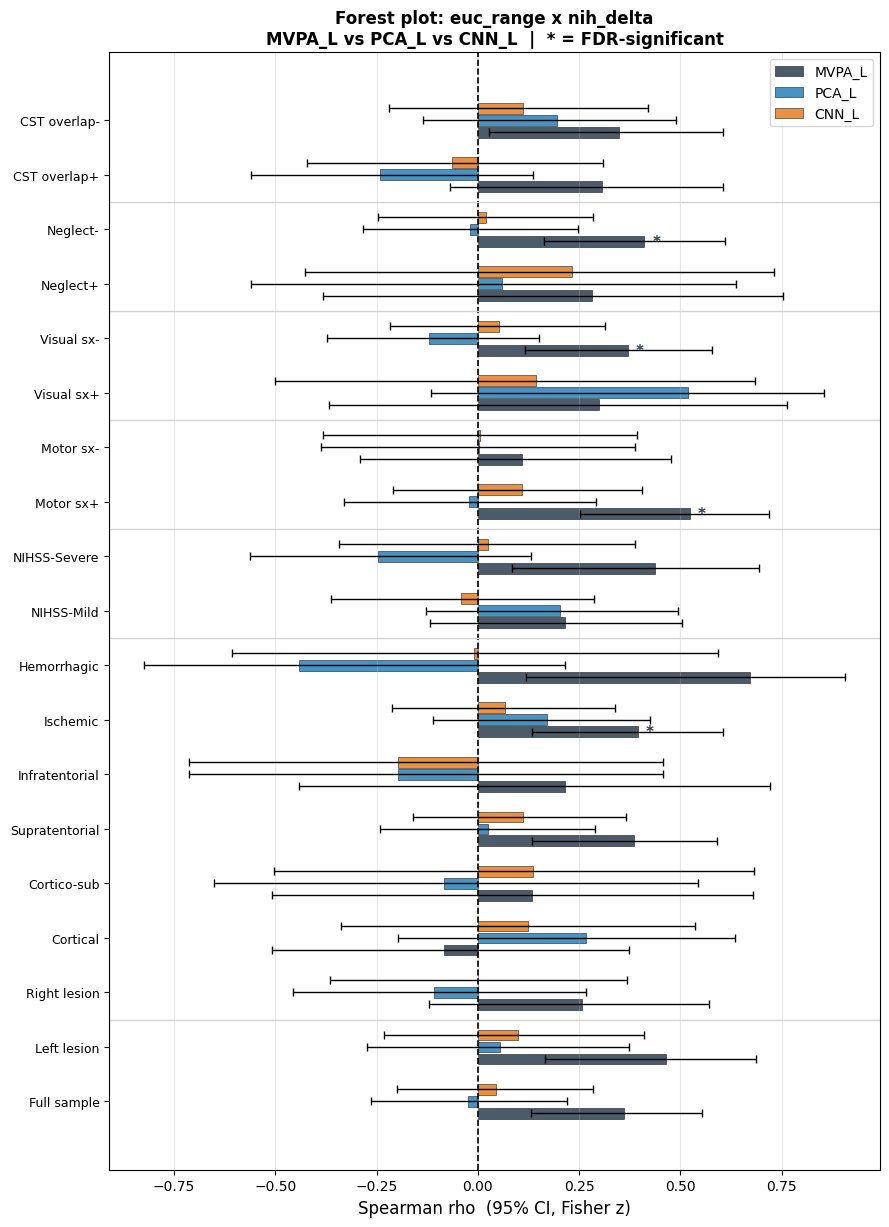

Saved: output/forest_euc_range_3methods.png

IPSILESIONAL vs CONTRALESIONAL EYE x ALL METHODS (FDR over all tests)

Method   Suffix             Eye         rho        p    p_fdr  sig  N
CNN      euc_mean           contra   -0.107  0.3926  0.7282       66
CNN      euc_mean           ipsi     -0.132  0.2920  0.7282       66
CNN      euc_range          contra   +0.024  0.8488  0.9150       66
CNN      euc_range          ipsi     +0.030  0.8122  0.9150       66
CNN      euc_rms            contra   -0.081  0.5179  0.7282       66
CNN      euc_rms            ipsi     -0.091  0.4678  0.7282       66
MVPA     euc_mean           contra   -0.304  0.0130  0.0976       66
MVPA     euc_mean           ipsi     -0.193  0.1202  0.4328       66
MVPA     euc_range          contra   +0.173  0.1654  0.4963       66
MVPA     euc_range          ipsi     +0.333  0.0063  0.0976       66
MVPA     euc_rms            contra   -0.295  0.0163  0.0976       66
MVPA     euc_rms            ipsi     -0.226  0.0680  0.

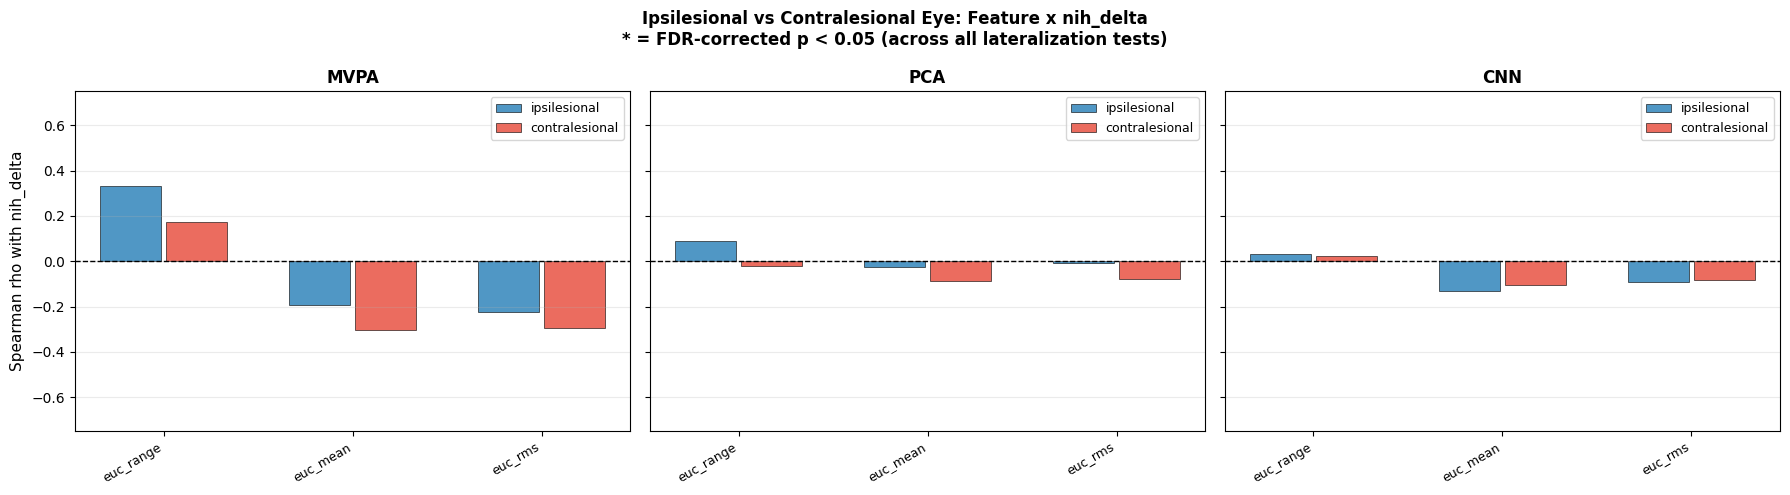

Saved: output/lateralization_ipsi_contra.png

INTERACTION TESTS: feat_z x lesion_side -> nih_delta  (OLS + covariates)
Covariates: nihss_hospital, lesion_size, age, gender
  Columns: nihss='nihss_num'  lesion_size='lesion_size_x'  side='lesion_side'  age='age'  gender='gender'
  Covariates entered in model: ['nihss_num', 'lesion_size_x', 'age', 'gender']

  MVPA_L_euc_range                     N=47
    Interaction [feat_z:C(side_c)[T.1.0]]: coef=-0.701  p=0.3374
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -2.0355      1.623     -1.254      0.217      -5.319       1.248
C(side_c)[T.1.0]            0.9177      0.510      1.800      0.080      -0.114       1.949
feat_z                      0.7844      0.291      2.696      0.010       0.196       1.373
feat_z:C(side_c)[T.1.0]    -0.7009      0.722     -0.971      0.337      

In [14]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings("ignore")

os.makedirs("output", exist_ok=True)

# =============================================================================
# CONFIG
# =============================================================================
OUTCOME      = "nih_delta"
MIN_N_SUBGRP = 25
ALPHA_FDR    = 0.05

# Canonical feature suffixes shared across MVPA / PCA / CNN
SUFFIXES = [
    "euc_range", "euc_mean", "euc_rms", "euc_sd", "euc_var",
    "euc_ac1",   "euc_mssd", "euc_spec_entropy",
    "max_speed", "mean_speed", "path_length",
    "sd", "var", "mean",
    "LR_mean_asym", "LR_sd_asym", "LR_corr",
]

# Build feature lists per method x eye
def build_feat_list(method, eye):
    """eye in {L, R, avg, LR}"""
    prefix = f"{method}_{eye}"
    if eye == "LR":
        return [f"{method}_LR_mean_asym", f"{method}_LR_sd_asym", f"{method}_LR_corr"]
    return [f"{prefix}_{s}" for s in SUFFIXES]

METHODS = ["MVPA", "PCA", "CNN"]
EYES    = ["L", "R"]
LR_FEAT = {m: build_feat_list(m, "LR") for m in METHODS}

ALL_FEATS = {}
for m in METHODS:
    ALL_FEATS[m] = (build_feat_list(m, "L") +
                    build_feat_list(m, "R") +
                    LR_FEAT[m])

CNN_AVG_FEATS = build_feat_list("CNN", "avg")
ALL_FEATS["CNN"] = ALL_FEATS["CNN"] + CNN_AVG_FEATS

SITE_LABELS = {
    0:"Subcortical", 1:"Cortical", 2:"Cortico-sub",
    3:"WM only",     4:"Brainstem", 5:"Cerebellar", 6:"Other"
}
SG_ORDER = [
    "Full sample",
    "Left lesion", "Right lesion",
    "Subcortical", "Cortical", "Cortico-sub", "WM only", "Brainstem", "Cerebellar",
    "Supratentorial", "Infratentorial",
    "Ischemic", "Hemorrhagic",
    "NIHSS-Mild", "NIHSS-Severe",
    "Motor sx+", "Motor sx-",
    "Visual sx+", "Visual sx-",
    "Neglect+", "Neglect-",
    "CST overlap+", "CST overlap-",
]

# =============================================================================
# 1. ENRICH recovery_df
#    age (stroke_csv.age) and gender (stroke_csv.gender, 0/1) included here
# =============================================================================
clin_cols = [
    "ID","lesion_site","lesion_side","lesion_type","lesion_size","nihss_hospital",
    "lcst","rcst",
    "motor_er___2","motor_er___3","motor_er___4","motor_er___5",
    "visual_er___1","visual_er___2","visual_er___3",
    "attention_er___1",
    "bigfactor1","bigfactor2","bigfactor3",
    "age","gender",
]
clin_cols = [c for c in clin_cols if c in stroke_csv.columns]
acute_clin = (stroke_csv[stroke_csv["Session"]=="acute"]
              .drop_duplicates(subset="ID")[clin_cols].copy())

for c in ["motor_er___2","motor_er___3","motor_er___4","motor_er___5",
          "visual_er___1","visual_er___2","visual_er___3","attention_er___1"]:
    if c in acute_clin.columns:
        acute_clin[c] = pd.to_numeric(acute_clin[c], errors="coerce").fillna(0)

motor_cols  = [c for c in ["motor_er___2","motor_er___3","motor_er___4","motor_er___5"]
               if c in acute_clin.columns]
visual_cols = [c for c in ["visual_er___1","visual_er___2","visual_er___3"]
               if c in acute_clin.columns]

acute_clin["any_motor"]   = (acute_clin[motor_cols].sum(axis=1) > 0).astype(int)
acute_clin["any_visual"]  = (acute_clin[visual_cols].sum(axis=1) > 0).astype(int)
acute_clin["any_neglect"] = acute_clin["attention_er___1"].astype(int) if "attention_er___1" in acute_clin.columns else 0
for col in ["lcst","rcst"]:
    acute_clin[f"{col}_n"] = pd.to_numeric(acute_clin[col], errors="coerce").fillna(0)
acute_clin["any_cst"]   = ((acute_clin["lcst_n"] + acute_clin["rcst_n"]) > 0).astype(int)
acute_clin["nihss_num"] = pd.to_numeric(acute_clin["nihss_hospital"], errors="coerce")
nihss_med               = acute_clin["nihss_num"].median()
acute_clin["sev_group"] = np.where(acute_clin["nihss_num"] <= nihss_med, "Mild", "Severe")
acute_clin["infra"]     = acute_clin["lesion_site"].isin([4,5]).astype(int)
print(f"NIHSS median: {nihss_med}")

rdf = recovery_df.merge(acute_clin, on="ID", how="left")
print(f"Enriched recovery_df: {rdf.shape},  nih_delta N={rdf[OUTCOME].notna().sum()}")

# =============================================================================
# 2. HELPERS
# =============================================================================
def subgroup_corr(subdf, features, outcome, label):
    rows = []
    for feat in features:
        if feat not in subdf.columns:
            continue
        valid = subdf[[feat, outcome]].dropna()
        n = len(valid)
        if n < MIN_N_SUBGRP:
            rows.append(dict(Feature=feat, Subgroup=label, N=n,
                             rho=np.nan, p=np.nan, p_fdr=np.nan, sig_fdr=False))
            continue
        rho, p = stats.spearmanr(valid[feat], valid[outcome])
        rows.append(dict(Feature=feat, Subgroup=label, N=n, rho=rho, p=p))
    out = pd.DataFrame(rows)
    if len(out) > 0 and out["p"].notna().sum() > 1:
        mask = out["p"].notna()
        _, pc = fdrcorrection(out.loc[mask,"p"].values)
        out.loc[mask,"p_fdr"] = pc
    if "p_fdr" not in out.columns:
        out["p_fdr"] = np.nan
    out["sig_fdr"] = out["p_fdr"] < ALPHA_FDR
    out["abs_rho"] = out["rho"].abs()
    return out

def make_subgroups(df):
    """Yield (label, sub_df) for all defined subgroups."""
    yield "Full sample", df
    for val,lbl in [(0,"Left lesion"),(1,"Right lesion")]:
        yield lbl, df[df["lesion_side"]==val]
    for val,lbl in SITE_LABELS.items():
        sub = df[df["lesion_site"]==val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
            yield lbl, sub
    for val,lbl in [(0,"Supratentorial"),(1,"Infratentorial")]:
        sub = df[df["infra"]==val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
            yield lbl, sub
    for val,lbl in [(0,"Ischemic"),(1,"Hemorrhagic")]:
        sub = df[df["lesion_type"]==val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
            yield lbl, sub
    for lbl in ["Mild","Severe"]:
        yield f"NIHSS-{lbl}", df[df["sev_group"]==lbl]
    for val,lbl in [(1,"Motor sx+"),(0,"Motor sx-")]:
        yield lbl, df[df["any_motor"]==val]
    for val,lbl in [(1,"Visual sx+"),(0,"Visual sx-")]:
        sub = df[df["any_visual"]==val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
            yield lbl, sub
    for val,lbl in [(1,"Neglect+"),(0,"Neglect-")]:
        sub = df[df["any_neglect"]==val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
            yield lbl, sub
    for val,lbl in [(1,"CST overlap+"),(0,"CST overlap-")]:
        sub = df[df["any_cst"]==val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
            yield lbl, sub

def fisher_ci(rho, n, alpha=0.05):
    if pd.isna(rho) or n < 4: return np.nan, np.nan
    z  = np.arctanh(np.clip(rho,-0.9999,0.9999))
    se = 1/np.sqrt(n-3)
    zc = stats.norm.ppf(1-alpha/2)
    return np.tanh(z-zc*se), np.tanh(z+zc*se)

# =============================================================================
# 3. RUN ALL SUBGROUPS x ALL METHODS
# =============================================================================
all_results = []
for sg_label, sg_df in make_subgroups(rdf):
    for method in METHODS:
        feats = ALL_FEATS[method]
        r = subgroup_corr(sg_df, feats, OUTCOME, sg_label)
        r["Method"] = method
        all_results.append(r)

sg_full = pd.concat(all_results, ignore_index=True)

def tag_eye(feat):
    f = feat.upper()
    if "_LR_" in f:   return "LR asym"
    if "_AVG_" in f:  return "avg"
    if "_L_" in f:    return "Left eye"
    if "_R_" in f:    return "Right eye"
    return "?"
def tag_suffix(feat):
    for suf in sorted(SUFFIXES, key=len, reverse=True):
        if feat.endswith(suf): return suf
    return feat

sg_full["Eye"]    = sg_full["Feature"].apply(tag_eye)
sg_full["Suffix"] = sg_full["Feature"].apply(tag_suffix)

sg_full.to_csv("output/subgroup_all_methods_nih_delta.csv", index=False)
print(f"Master result table: {sg_full.shape}")

# =============================================================================
# 4. PRINT SUMMARY
# =============================================================================
print("\n" + "="*80)
print("FDR-SIGNIFICANT RESULTS  (p_fdr < 0.05, within-subgroup correction)")
print("="*80)
sig = sg_full[sg_full["sig_fdr"]].sort_values(
        ["Subgroup","Method","abs_rho"], ascending=[True,True,False])
for sg in SG_ORDER:
    sub = sig[sig["Subgroup"]==sg]
    if len(sub)==0: continue
    print(f"\n[{sg}]")
    for m in METHODS:
        mm = sub[sub["Method"]==m]
        if len(mm)==0: continue
        print(f"  -- {m} --")
        for _,r in mm.sort_values("abs_rho",ascending=False).iterrows():
            print(f"    {r.Feature:<35}  {r.Eye:<10}  rho={r.rho:+.3f}  "
                  f"p={r.p:.4f}  p_fdr={r.p_fdr:.4f}  N={int(r.N)}")

# =============================================================================
# 5. HEATMAP
# =============================================================================
KEY_SUFFIXES = [
    "euc_range","euc_mean","euc_rms","euc_sd","euc_var",
    "euc_ac1","max_speed","path_length",
    "LR_mean_asym","LR_sd_asym","LR_corr"
]

SG_AVAIL = [s for s in SG_ORDER if s in sg_full["Subgroup"].values]

for method in METHODS:
    mdf = sg_full[sg_full["Method"]==method]
    eyes_to_plot = ["Left eye","Right eye","LR asym"]
    if method == "CNN":
        eyes_to_plot = ["Left eye","Right eye","avg","LR asym"]

    ncols = len(eyes_to_plot)
    fig, axes = plt.subplots(1, ncols,
                             figsize=(9*ncols, len(SG_AVAIL)*0.5+2.5),
                             sharey=True)
    if ncols == 1: axes = [axes]

    for ax, eye in zip(axes, eyes_to_plot):
        sub = mdf[mdf["Eye"]==eye]
        if eye == "LR asym":
            col_order = ["LR_mean_asym","LR_sd_asym","LR_corr"]
        else:
            col_order = KEY_SUFFIXES[:8]

        pivot_rho = sub.pivot_table(
            index="Subgroup", columns="Suffix", values="rho",
            aggfunc="first").reindex(SG_AVAIL)[
            [c for c in col_order if c in sub["Suffix"].values]]
        pivot_sig = sub.pivot_table(
            index="Subgroup", columns="Suffix", values="sig_fdr",
            aggfunc="first").reindex(SG_AVAIL).fillna(False)
        pivot_n   = sub.pivot_table(
            index="Subgroup", columns="Suffix", values="N",
            aggfunc="first").reindex(SG_AVAIL)

        rho_arr = pivot_rho.values.astype(float)
        im = ax.imshow(rho_arr, cmap="RdBu_r", vmin=-0.7, vmax=0.7, aspect="auto")
        plt.colorbar(im, ax=ax, label="Spearman rho", shrink=0.6)

        ax.set_xticks(range(len(pivot_rho.columns)))
        ax.set_xticklabels(pivot_rho.columns, rotation=38, ha="right", fontsize=9)
        ax.set_yticks(range(len(SG_AVAIL)))

        row_labels = []
        for sg in SG_AVAIL:
            n_ = pivot_n.loc[sg].dropna()
            n_val = int(n_.iloc[0]) if len(n_) else "?"
            row_labels.append(f"{sg}  (N={n_val})")
        ax.set_yticklabels(row_labels, fontsize=9)

        for ri, sg in enumerate(pivot_rho.index):
            for ci, feat in enumerate(pivot_rho.columns):
                v = rho_arr[ri, ci]
                try:
                    s = bool(pivot_sig.loc[sg, feat])
                except:
                    s = False
                if not np.isnan(v):
                    txt   = f"{v:+.2f}" + ("*" if s else "")
                    color = "white" if abs(v) > 0.42 else "black"
                    ax.text(ci, ri, txt, ha="center", va="center",
                            fontsize=7, color=color,
                            fontweight="bold" if s else "normal")

        for sep in [2,9,11,13,15,17,19,21]:
            if sep < len(SG_AVAIL):
                ax.axhline(sep-0.5, color="white", linewidth=1.8)

        ax.set_title(f"{method}  |  {eye}", fontsize=11, fontweight="bold")

    fig.suptitle(
        f"{method}: Spearman rho with {OUTCOME} by Subgroup x Feature\n"
        "* = FDR-corrected p < 0.05 within subgroup",
        fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    out_path = f"output/heatmap_{method}_{OUTCOME}.png"
    plt.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

# =============================================================================
# 6. CROSS-METHOD COMPARISON HEATMAP
# =============================================================================
KEY_FEAT_PER_METHOD = {
    "MVPA_L": "MVPA_L_euc_range",
    "MVPA_R": "MVPA_R_euc_range",
    "PCA_L":  "PCA_L_euc_range",
    "PCA_R":  "PCA_R_euc_range",
    "CNN_L":  "CNN_L_euc_range",
    "CNN_R":  "CNN_R_euc_range",
    "MVPA_LR_asym": "MVPA_LR_mean_asym",
    "PCA_LR_asym":  "PCA_LR_mean_asym",
    "CNN_LR_asym":  "CNN_LR_mean_asym",
}

cross_rows = []
for sg_label, sg_df in make_subgroups(rdf):
    for col_label, feat in KEY_FEAT_PER_METHOD.items():
        method = feat.split("_")[0]
        sub = sg_full[(sg_full["Subgroup"]==sg_label) &
                      (sg_full["Feature"]==feat)     &
                      (sg_full["Method"]==method)]
        if len(sub) == 1:
            row = sub.iloc[0]
            cross_rows.append({"Subgroup":sg_label, "Column":col_label,
                                "rho":row["rho"], "sig_fdr":row["sig_fdr"],
                                "N":row["N"]})
        else:
            cross_rows.append({"Subgroup":sg_label, "Column":col_label,
                                "rho":np.nan, "sig_fdr":False, "N":np.nan})

cross_df = pd.DataFrame(cross_rows)
cross_df.to_csv("output/cross_method_euc_range_heatmap.csv", index=False)

pivot_c = cross_df.pivot_table(index="Subgroup", columns="Column",
                                values="rho", aggfunc="first").reindex(SG_AVAIL)
pivot_s = cross_df.pivot_table(index="Subgroup", columns="Column",
                                values="sig_fdr", aggfunc="first").reindex(SG_AVAIL).fillna(False)
pivot_n = cross_df.pivot_table(index="Subgroup", columns="Column",
                                values="N", aggfunc="first").reindex(SG_AVAIL)

col_order_c = [c for c in KEY_FEAT_PER_METHOD.keys() if c in pivot_c.columns]
pivot_c = pivot_c[col_order_c]
pivot_s = pivot_s[col_order_c]

fig, ax = plt.subplots(figsize=(14, len(SG_AVAIL)*0.55+2.5))
im = ax.imshow(pivot_c.values.astype(float),
               cmap="RdBu_r", vmin=-0.75, vmax=0.75, aspect="auto")
plt.colorbar(im, ax=ax, label="Spearman rho", shrink=0.6)
ax.set_xticks(range(len(col_order_c)))
ax.set_xticklabels(col_order_c, rotation=35, ha="right", fontsize=10)
ax.set_yticks(range(len(SG_AVAIL)))

row_labels_c = []
for sg in SG_AVAIL:
    n_ = pivot_n.loc[sg].dropna()
    n_val = int(n_.iloc[0]) if len(n_) else "?"
    row_labels_c.append(f"{sg}  (N={n_val})")
ax.set_yticklabels(row_labels_c, fontsize=10)

for ri, sg in enumerate(pivot_c.index):
    for ci, col in enumerate(col_order_c):
        v = pivot_c.values[ri,ci]
        try: s = bool(pivot_s.loc[sg,col])
        except: s = False
        if not np.isnan(float(v)):
            txt   = f"{v:+.2f}" + ("*" if s else "")
            color = "white" if abs(v) > 0.42 else "black"
            ax.text(ci, ri, txt, ha="center", va="center",
                    fontsize=8, color=color, fontweight="bold" if s else "normal")

for sep in [2,9,11,13,15,17,19,21]:
    if sep < len(SG_AVAIL):
        ax.axhline(sep-0.5, color="white", linewidth=1.8)

ax.axvline(1.5, color="yellow", linewidth=1.5, alpha=0.5)
ax.axvline(3.5, color="yellow", linewidth=1.5, alpha=0.5)
ax.axvline(5.5, color="yellow", linewidth=1.5, alpha=0.5)

ax.set_title(
    f"euc_range Spearman rho with {OUTCOME}: MVPA vs PCA vs CNN, Left vs Right Eye\n"
    "* = FDR-sig within subgroup  |  Yellow lines separate L / R / LR-asym pairs",
    fontsize=11, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("output/cross_method_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved: output/cross_method_heatmap.png")

# =============================================================================
# 7. FOREST PLOT
# =============================================================================
FOREST_FEATS = {
    "MVPA_L": "MVPA_L_euc_range",
    "PCA_L":  "PCA_L_euc_range",
    "CNN_L":  "CNN_L_euc_range",
}
method_palette = {"MVPA_L":"#2c3e50","PCA_L":"#2980b9","CNN_L":"#e67e22"}

fp_data = {}
for label, feat in FOREST_FEATS.items():
    method = feat.split("_")[0]
    sub = sg_full[(sg_full["Feature"]==feat)&(sg_full["Method"]==method)]
    sub = sub.set_index("Subgroup").reindex(SG_AVAIL).dropna(subset=["rho"]).reset_index()
    sub[["ci_lo","ci_hi"]] = pd.DataFrame(
        [fisher_ci(r["rho"], r["N"]) for _,r in sub.iterrows()],
        columns=["ci_lo","ci_hi"])
    sub["err_lo"] = sub["rho"] - sub["ci_lo"]
    sub["err_hi"] = sub["ci_hi"] - sub["rho"]
    fp_data[label] = sub

common_sgs = [s for s in SG_AVAIL
              if all(s in fp_data[k]["Subgroup"].values for k in fp_data)]

fig, ax = plt.subplots(figsize=(9, len(common_sgs)*0.52+2.5))
y      = np.arange(len(common_sgs))
width  = 0.22
offsets = {"MVPA_L":-width, "PCA_L":0, "CNN_L":width}

for label, sub in fp_data.items():
    sub_c = sub[sub["Subgroup"].isin(common_sgs)].set_index("Subgroup").reindex(common_sgs).reset_index()
    col   = method_palette[label]
    e_lo  = sub_c["err_lo"].fillna(0).values
    e_hi  = sub_c["err_hi"].fillna(0).values
    ax.barh(y+offsets[label], sub_c["rho"].values, height=0.2,
            xerr=[e_lo, e_hi], color=col, alpha=0.85,
            label=label, edgecolor="black", linewidth=0.4,
            error_kw=dict(elinewidth=1.0, capsize=3, ecolor="black"))
    for yi, (_, row) in zip(y+offsets[label], sub_c.iterrows()):
        if row.get("sig_fdr", False):
            ax.text(row["rho"] + (0.03 if row["rho"]>0 else -0.06),
                    yi, "*", ha="center", va="center",
                    fontsize=11, color=col, fontweight="bold")

ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(common_sgs, fontsize=9)
ax.set_xlabel("Spearman rho  (95% CI, Fisher z)", fontsize=12)
ax.set_title("Forest plot: euc_range x nih_delta\n"
             "MVPA_L vs PCA_L vs CNN_L  |  * = FDR-significant",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="x", alpha=0.3)
for sep in [2,9,11,13,15,17,19,21]:
    if sep < len(common_sgs):
        ax.axhline(sep-0.5, color="lightgray", linewidth=1)
plt.tight_layout()
plt.savefig("output/forest_euc_range_3methods.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved: output/forest_euc_range_3methods.png")

# =============================================================================
# 8. LATERALIZATION
# =============================================================================
def get_ipsi_contra(df, method, suffix):
    rows = []
    feat_L = f"{method}_L_{suffix}"
    feat_R = f"{method}_R_{suffix}"
    for _, row in df.iterrows():
        side = row.get("lesion_side")
        outcome_val = row.get(OUTCOME)
        if pd.isna(side): continue
        fl = row.get(feat_L, np.nan)
        fr = row.get(feat_R, np.nan)
        if side == 0:
            ipsi, contra = fl, fr
        else:
            ipsi, contra = fr, fl
        rows.append({"nih_delta":outcome_val, "ipsi":ipsi, "contra":contra,
                     "method":method, "suffix":suffix, "side":side})
    return pd.DataFrame(rows)

lat_rows = []
for method in METHODS:
    for suffix in ["euc_range","euc_mean","euc_rms","LR_mean_asym"]:
        ic = get_ipsi_contra(rdf, method, suffix)
        for tag in ["ipsi","contra"]:
            valid = ic[["nih_delta",tag]].dropna()
            if len(valid) < MIN_N_SUBGRP: continue
            rho, p = stats.spearmanr(valid[tag], valid["nih_delta"])
            lat_rows.append({"Method":method,"Suffix":suffix,"Eye":tag,
                             "rho":rho,"p":p,"N":len(valid)})

lat_df = pd.DataFrame(lat_rows)
_, lat_df["p_fdr"] = fdrcorrection(lat_df["p"].fillna(1).values)
lat_df["sig_fdr"] = lat_df["p_fdr"] < ALPHA_FDR
lat_df.to_csv("output/lateralization_ipsi_contra.csv", index=False)

print("\n" + "="*70)
print("IPSILESIONAL vs CONTRALESIONAL EYE x ALL METHODS (FDR over all tests)")
print("="*70)
print(f"\n{'Method':<8} {'Suffix':<18} {'Eye':<8} {'rho':>6}  {'p':>7}  "
      f"{'p_fdr':>7}  sig  N")
for _, r in lat_df.sort_values(["Method","Suffix","Eye"]).iterrows():
    s = "*" if r.sig_fdr else " "
    print(f"{r.Method:<8} {r.Suffix:<18} {r.Eye:<8} {r.rho:+.3f}  "
          f"{r.p:.4f}  {r.p_fdr:.4f}  {s}    {int(r.N)}")

fig, axes = plt.subplots(1, len(METHODS), figsize=(6*len(METHODS), 5), sharey=True)
for ax, method in zip(axes, METHODS):
    sub = lat_df[lat_df["Method"]==method]
    suffixes_plot = sub["Suffix"].unique()
    x  = np.arange(len(suffixes_plot))
    for i, eye in enumerate(["ipsi","contra"]):
        vals  = [sub[(sub["Suffix"]==s)&(sub["Eye"]==eye)]["rho"].values
                 for s in suffixes_plot]
        vals  = [v[0] if len(v) else np.nan for v in vals]
        sigs  = [sub[(sub["Suffix"]==s)&(sub["Eye"]==eye)]["sig_fdr"].values
                 for s in suffixes_plot]
        sigs  = [bool(v[0]) if len(v) else False for v in sigs]
        color = "#2980b9" if eye=="ipsi" else "#e74c3c"
        bars  = ax.bar(x + i*0.35, vals, width=0.32,
                       color=color, alpha=0.82, label=f"{eye}lesional",
                       edgecolor="black", linewidth=0.5)
        for bar, sig in zip(bars, sigs):
            if sig:
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+(0.02 if bar.get_height()>0 else -0.04),
                        "*", ha="center", fontsize=12, color=color, fontweight="bold")
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_xticks(x+0.175)
    ax.set_xticklabels(suffixes_plot, rotation=30, ha="right", fontsize=9)
    ax.set_title(method, fontsize=12, fontweight="bold")
    ax.set_ylabel("Spearman rho with nih_delta" if method==METHODS[0] else "", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(-0.75, 0.75)
fig.suptitle("Ipsilesional vs Contralesional Eye: Feature x nih_delta\n"
             "* = FDR-corrected p < 0.05 (across all lateralization tests)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("output/lateralization_ipsi_contra.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved: output/lateralization_ipsi_contra.png")

# =============================================================================
# 9. INTERACTION TESTS: lesion_side x feature x method -> nih_delta
#    Covariates: nihss_hospital (acute severity), lesion_size, age, gender
#    age  <- stroke_csv.age   (continuous)
#    gender <- stroke_csv.gender  (0/1 numeric, no C() needed)
# =============================================================================
print("\n" + "="*70)
print("INTERACTION TESTS: feat_z x lesion_side -> nih_delta  (OLS + covariates)")
print("Covariates: nihss_hospital, lesion_size, age, gender")
print("="*70)

def resolve_col(df, candidates):
    """Return first candidate present in df.columns; fuzzy-match suffix collisions."""
    for c in candidates:
        if c in df.columns:
            return c
    for c in df.columns:
        for cand in candidates:
            if c.startswith(cand):
                return c
    return None

nihss_col   = resolve_col(rdf, ["nihss_num", "nihss_hospital_num", "nihss_hospital"])
lessize_col = resolve_col(rdf, ["lesion_size", "lesion_size_x"])
side_col    = resolve_col(rdf, ["lesion_side", "lesion_side_x"])
age_col     = resolve_col(rdf, ["age", "age_x"])
gender_col  = resolve_col(rdf, ["gender", "gender_x"])

print(f"  Columns: nihss={nihss_col!r}  lesion_size={lessize_col!r}  "
      f"side={side_col!r}  age={age_col!r}  gender={gender_col!r}")

int_feats = {
    "MVPA_L_euc_range":   "MVPA",
    "MVPA_LR_mean_asym":  "MVPA",
    "PCA_L_euc_range":    "PCA",
    "PCA_LR_mean_asym":   "PCA",
    "CNN_L_euc_range":    "CNN",
    "CNN_LR_mean_asym":   "CNN",
}

# Build covariate list — all four covariates, numeric, no C() wrapping needed
base_covariates = []
for col in [nihss_col, lessize_col, age_col, gender_col]:
    if col and col in rdf.columns:
        base_covariates.append(col)
print(f"  Covariates entered in model: {base_covariates}")

for feat, method in int_feats.items():
    if feat not in rdf.columns:
        print(f"  SKIP (not in rdf): {feat}")
        continue

    use_cols = [feat, OUTCOME, side_col] + base_covariates
    use_cols = [c for c in use_cols if c is not None and c in rdf.columns]
    sub = rdf[use_cols].dropna().copy()

    if len(sub) < 15:
        print(f"  SKIP (N={len(sub)} < 15): {feat}")
        continue

    sub["side_c"] = pd.Categorical(sub[side_col].astype(float))
    sub["feat_z"] = (sub[feat] - sub[feat].mean()) / sub[feat].std()

    cov_str = " + ".join(base_covariates) if base_covariates else "1"
    formula = f"{OUTCOME} ~ feat_z * C(side_c) + {cov_str}"

    try:
        mdl  = ols(formula, data=sub).fit()
        ikeys = [k for k in mdl.params.index
                 if "feat_z" in k and "side_c" in k]
        print(f"\n  {feat:<35}  N={len(sub)}")
        if ikeys:
            for ik in ikeys:
                coef = mdl.params[ik]
                pval = mdl.pvalues[ik]
                print(f"    Interaction [{ik}]: coef={coef:+.3f}  p={pval:.4f}"
                      + ("  ** SIGNIFICANT **" if pval < 0.05 else ""))
        else:
            print("    (no interaction term found in model params)")
        print(mdl.summary().tables[1])
    except Exception as e:
        print(f"  ERROR fitting {feat}: {e}")

# =============================================================================
# 10. TOP-FEATURES TABLE
# =============================================================================
top = (sg_full[sg_full["N"] >= MIN_N_SUBGRP]
       .sort_values("abs_rho", ascending=False)
       .groupby(["Subgroup","Method","Eye"], as_index=False)
       .first()
       [["Subgroup","Method","Eye","Feature","rho","p","p_fdr","sig_fdr","N"]])
top = top.sort_values(["Subgroup","Method","abs_rho" if "abs_rho" in top.columns else "rho"],
                      ascending=[True,True,False])
top["abs_rho"] = top["rho"].abs()
top.to_csv("output/top_feature_per_subgroup_method_eye.csv", index=False)
print("\nSaved: output/top_feature_per_subgroup_method_eye.csv")

print("\n" + "="*70)
print("TOP 20 SUBGROUP x METHOD x EYE COMBINATIONS  (highest |rho|, N>=8)")
print("="*70)
top_sorted = (sg_full[(sg_full["N"]>=MIN_N_SUBGRP) & sg_full["rho"].notna()]
              .sort_values("abs_rho", ascending=False)
              .drop_duplicates(subset=["Subgroup","Method","Eye"])
              .head(20))
for _, r in top_sorted.iterrows():
    s = "*" if r.sig_fdr else " "
    print(f"  {r.Subgroup:<22} {r.Method:<6} {r.Eye:<10}  "
          f"rho={r.rho:+.3f}  p_fdr={r.p_fdr:.4f}  {s}  {r.Feature}  N={int(r.N)}")

print("\nAll outputs saved to output/")

In [18]:

import os, re, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")
os.makedirs("output", exist_ok=True)

# =============================================================================
# CONFIG
# =============================================================================
BOTTLENECK_PATH = "/mnt/compneuro/deepmreye_finetuning/stroke_bottleneck.pkl"
OUTCOME         = "nih_delta"
MIN_N_SUBGRP    = 25
ALPHA_FDR       = 0.05
N_BN_PCS        = 10     # top PCs to extract per block (L, R, LR)

# Feature suffixes for MVPA / PCA scalar methods (unchanged from original)
SUFFIXES = [
    "euc_range", "euc_mean", "euc_rms", "euc_sd", "euc_var",
    "euc_ac1",   "euc_mssd", "euc_spec_entropy",
    "max_speed", "mean_speed", "path_length",
    "sd", "var", "mean",
    "LR_mean_asym", "LR_sd_asym", "LR_corr",
]

SITE_LABELS = {
    0:"Subcortical", 1:"Cortical", 2:"Cortico-sub",
    3:"WM only",     4:"Brainstem", 5:"Cerebellar", 6:"Other"
}
SG_ORDER = [
    "Full sample",
    "Left lesion", "Right lesion",
    "Subcortical", "Cortical", "Cortico-sub", "WM only", "Brainstem", "Cerebellar",
    "Supratentorial", "Infratentorial",
    "Ischemic", "Hemorrhagic",
    "NIHSS-Mild", "NIHSS-Severe",
    "Motor sx+", "Motor sx-",
    "Visual sx+", "Visual sx-",
    "Neglect+", "Neglect-",
    "CST overlap+", "CST overlap-",
]

METHODS = ["MVPA", "PCA", "BN"]    # BN replaces CNN


def build_feat_list(method, eye):
    """eye in {L, R, LR}"""
    if method == "BN":
        # Bottleneck PC scores: BN_L_PC1..N, BN_R_PC1..N, BN_LR_PC1..N
        if eye == "LR":
            return [f"BN_LR_PC{i+1}" for i in range(N_BN_PCS)]
        return [f"BN_{eye}_PC{i+1}" for i in range(N_BN_PCS)]
    else:
        # MVPA / PCA scalar features (original logic)
        prefix = f"{method}_{eye}"
        if eye == "LR":
            return [f"{method}_LR_mean_asym",
                    f"{method}_LR_sd_asym",
                    f"{method}_LR_corr"]
        return [f"{prefix}_{s}" for s in SUFFIXES]


ALL_FEATS = {m: (build_feat_list(m,"L") +
                 build_feat_list(m,"R") +
                 build_feat_list(m,"LR"))
             for m in METHODS}

# =============================================================================
# STEP 0 — LOAD BOTTLENECK & BUILD BN PC COLUMNS
#   Fit PCA separately on three blocks per subject-session:
#     L block   : [l_mean (1024) | l_std (1024)]  → 2048 dims
#     R block   : [r_mean (1024) | r_std (1024)]  → 2048 dims
#     LR block  : [lr_asym (1024)]                → 1024 dims
#   PCA fitted on ALL sessions (controls + patients) for stable PC directions.
#   Only acute-session scores are merged into rdf.
# =============================================================================
with open(BOTTLENECK_PATH, "rb") as f:
    bn_raw = pickle.load(f)
print(f"Bottleneck entries: {len(bn_raw)}")


def parse_bn_key(key):
    id_m  = re.search(r'sub-([A-Za-z0-9]+)', key)
    ses_m = re.search(r'ses-([^_]+)', key)
    return (id_m.group(1) if id_m else None,
            ses_m.group(1) if ses_m else None)


bn_rows = []
for key, val in bn_raw.items():
    ID, session = parse_bn_key(key)
    if ID is None or session is None:
        continue
    try:
        bn_r = np.array(val["bottleneck_right"], dtype=np.float32)
        bn_l = np.array(val["bottleneck_left"],  dtype=np.float32)
    except Exception:
        continue
    if bn_r.ndim == 1: bn_r = bn_r[np.newaxis, :]
    if bn_l.ndim == 1: bn_l = bn_l[np.newaxis, :]
    bn_rows.append({
        "ID": ID, "Session": session,
        "l_mean": bn_l.mean(0), "l_std": bn_l.std(0),
        "r_mean": bn_r.mean(0), "r_std": bn_r.std(0),
        "lr_asym": bn_l.mean(0) - bn_r.mean(0),
    })

bn_df = pd.DataFrame(bn_rows)
print(f"Parsed {len(bn_df)} subject-sessions  |  "
      f"subjects={bn_df['ID'].nunique()}  |  "
      f"sessions={sorted(bn_df['Session'].unique())}")

# ── Assemble block matrices (all sessions) ────────────────────────────────────
X_L_all  = np.stack([np.concatenate([r["l_mean"], r["l_std"]])
                     for _, r in bn_df.iterrows()]).astype(np.float32)   # (N_all, 2048)
X_R_all  = np.stack([np.concatenate([r["r_mean"], r["r_std"]])
                     for _, r in bn_df.iterrows()]).astype(np.float32)
X_LR_all = np.stack([r["lr_asym"]
                     for _, r in bn_df.iterrows()]).astype(np.float32)   # (N_all, 1024)

print(f"\nBlock matrix shapes  L={X_L_all.shape}  R={X_R_all.shape}  LR={X_LR_all.shape}")

# ── Fit PCA on all sessions, project to N_BN_PCS components ──────────────────
def fit_pca_block(X_block, n_components, block_name):
    X_imp = SimpleImputer(strategy="median").fit_transform(X_block)
    X_sc  = StandardScaler().fit_transform(X_imp)
    pca   = PCA(n_components=n_components)
    scores = pca.fit_transform(X_sc)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    print(f"  {block_name}: {n_components} PCs explain "
          f"{cumvar[-1]*100:.1f}% variance  "
          f"(PC1={pca.explained_variance_ratio_[0]*100:.1f}%)")
    return scores, pca   # scores: (N_all, n_components)

print("\nFitting PCA per block:")
n_pc_fit  = min(N_BN_PCS, bn_df.shape[0] - 2)
scores_L,  pca_L  = fit_pca_block(X_L_all,  n_pc_fit, "L  (l_mean+l_std)")
scores_R,  pca_R  = fit_pca_block(X_R_all,  n_pc_fit, "R  (r_mean+r_std)")
scores_LR, pca_LR = fit_pca_block(X_LR_all, n_pc_fit, "LR (lr_asym)")

# ── Add PC scores as columns in bn_df ─────────────────────────────────────────
for i in range(n_pc_fit):
    bn_df[f"BN_L_PC{i+1}"]  = scores_L[:,  i]
    bn_df[f"BN_R_PC{i+1}"]  = scores_R[:,  i]
    bn_df[f"BN_LR_PC{i+1}"] = scores_LR[:, i]

print(f"\nBN PC columns added to bn_df: "
      f"{[c for c in bn_df.columns if c.startswith('BN_')][:6]} ...")

# ── Acute-session BN features for merging ─────────────────────────────────────
bn_cols  = [c for c in bn_df.columns if c.startswith("BN_")]
bn_acute = (bn_df[bn_df["Session"] == "acute"][["ID"] + bn_cols]
            .drop_duplicates("ID")
            .reset_index(drop=True))
print(f"Acute BN rows: {len(bn_acute)}")

# =============================================================================
# STEP 1 — ENRICH recovery_df
# =============================================================================
clin_cols = [
    "ID","lesion_site","lesion_side","lesion_type","lesion_size","nihss_hospital",
    "lcst","rcst",
    "motor_er___2","motor_er___3","motor_er___4","motor_er___5",
    "visual_er___1","visual_er___2","visual_er___3",
    "attention_er___1",
    "bigfactor1","bigfactor2","bigfactor3",
    "age","gender",
]
clin_cols = [c for c in clin_cols if c in stroke_csv.columns]
acute_clin = (stroke_csv[stroke_csv["Session"] == "acute"]
              .drop_duplicates(subset="ID")[clin_cols].copy())

for c in ["motor_er___2","motor_er___3","motor_er___4","motor_er___5",
          "visual_er___1","visual_er___2","visual_er___3","attention_er___1"]:
    if c in acute_clin.columns:
        acute_clin[c] = pd.to_numeric(acute_clin[c], errors="coerce").fillna(0)

motor_cols  = [c for c in
               ["motor_er___2","motor_er___3","motor_er___4","motor_er___5"]
               if c in acute_clin.columns]
visual_cols = [c for c in
               ["visual_er___1","visual_er___2","visual_er___3"]
               if c in acute_clin.columns]

acute_clin["any_motor"]   = (acute_clin[motor_cols].sum(axis=1) > 0).astype(int)
acute_clin["any_visual"]  = (acute_clin[visual_cols].sum(axis=1) > 0).astype(int)
acute_clin["any_neglect"] = (acute_clin["attention_er___1"].astype(int)
                             if "attention_er___1" in acute_clin.columns else 0)
for col in ["lcst","rcst"]:
    if col in acute_clin.columns:
        acute_clin[f"{col}_n"] = pd.to_numeric(acute_clin[col],
                                               errors="coerce").fillna(0)
lcst_n = "lcst_n" if "lcst_n" in acute_clin.columns else None
rcst_n = "rcst_n" if "rcst_n" in acute_clin.columns else None
if lcst_n and rcst_n:
    acute_clin["any_cst"] = ((acute_clin[lcst_n] + acute_clin[rcst_n]) > 0).astype(int)
elif lcst_n:
    acute_clin["any_cst"] = (acute_clin[lcst_n] > 0).astype(int)
else:
    acute_clin["any_cst"] = 0

acute_clin["nihss_num"] = pd.to_numeric(
    acute_clin["nihss_hospital"], errors="coerce")
nihss_med               = acute_clin["nihss_num"].median()
acute_clin["sev_group"] = np.where(
    acute_clin["nihss_num"] <= nihss_med, "Mild", "Severe")
acute_clin["infra"]     = acute_clin["lesion_site"].isin([4, 5]).astype(int)

print(f"NIHSS hospital median: {nihss_med}")

# Merge: recovery_df → clinical → BN PC scores
rdf = recovery_df.merge(acute_clin, on="ID", how="left")
rdf = rdf.merge(bn_acute,          on="ID", how="left")
print(f"Enriched rdf: {rdf.shape},  {OUTCOME} N={rdf[OUTCOME].notna().sum()}")
print(f"BN PC columns in rdf: {[c for c in rdf.columns if c.startswith('BN_')][:6]} ...")

# =============================================================================
# STEP 2 — HELPERS
# =============================================================================
def subgroup_corr(subdf, features, outcome, label):
    rows = []
    for feat in features:
        if feat not in subdf.columns:
            continue
        valid = subdf[[feat, outcome]].dropna()
        n = len(valid)
        if n < MIN_N_SUBGRP:
            rows.append(dict(Feature=feat, Subgroup=label, N=n,
                             rho=np.nan, p=np.nan))
            continue
        rho, p = stats.spearmanr(valid[feat], valid[outcome])
        rows.append(dict(Feature=feat, Subgroup=label, N=n, rho=rho, p=p))
    out = pd.DataFrame(rows)
    if len(out) > 0 and out["p"].notna().sum() > 1:
        mask = out["p"].notna()
        _, pc = fdrcorrection(out.loc[mask, "p"].values)
        out.loc[mask, "p_fdr"] = pc
    if "p_fdr" not in out.columns:
        out["p_fdr"] = np.nan
    out["sig_fdr"] = out["p_fdr"] < ALPHA_FDR
    out["abs_rho"] = out["rho"].abs()
    return out


def make_subgroups(df):
    yield "Full sample", df
    for val, lbl in [(0,"Left lesion"), (1,"Right lesion")]:
        yield lbl, df[df["lesion_side"] == val]
    for val, lbl in SITE_LABELS.items():
        sub = df[df["lesion_site"] == val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
            yield lbl, sub
    for val, lbl in [(0,"Supratentorial"), (1,"Infratentorial")]:
        sub = df[df["infra"] == val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
            yield lbl, sub
    for val, lbl in [(0,"Ischemic"), (1,"Hemorrhagic")]:
        sub = df[df["lesion_type"] == val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
            yield lbl, sub
    for lbl in ["Mild", "Severe"]:
        yield f"NIHSS-{lbl}", df[df["sev_group"] == lbl]
    for val, lbl in [(1,"Motor sx+"), (0,"Motor sx-")]:
        yield lbl, df[df["any_motor"] == val]
    for val, lbl in [(1,"Visual sx+"), (0,"Visual sx-")]:
        sub = df[df["any_visual"] == val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
            yield lbl, sub
    for val, lbl in [(1,"Neglect+"), (0,"Neglect-")]:
        sub = df[df["any_neglect"] == val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
            yield lbl, sub
    for val, lbl in [(1,"CST overlap+"), (0,"CST overlap-")]:
        sub = df[df["any_cst"] == val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP:
            yield lbl, sub


def fisher_ci(rho, n, alpha=0.05):
    if pd.isna(rho) or n < 4:
        return np.nan, np.nan
    z  = np.arctanh(np.clip(rho, -0.9999, 0.9999))
    se = 1 / np.sqrt(n - 3)
    zc = stats.norm.ppf(1 - alpha / 2)
    return np.tanh(z - zc*se), np.tanh(z + zc*se)


# =============================================================================
# STEP 3 — RUN ALL SUBGROUPS × ALL METHODS (MVPA, PCA, BN)
# =============================================================================
def tag_eye(feat):
    f = feat.upper()
    if "_LR_" in f:  return "LR asym"
    if "_L_"  in f:  return "Left eye"
    if "_R_"  in f:  return "Right eye"
    return "?"


def tag_suffix(feat):
    # For BN features: extract PCn label
    m = re.search(r'_(PC\d+)$', feat)
    if m: return m.group(1)
    for suf in sorted(SUFFIXES, key=len, reverse=True):
        if feat.endswith(suf): return suf
    return feat


print("\nRunning subgroup correlations …")
all_results = []
for sg_label, sg_df in make_subgroups(rdf):
    for method in METHODS:
        feats = ALL_FEATS[method]
        r = subgroup_corr(sg_df, feats, OUTCOME, sg_label)
        r["Method"] = method
        all_results.append(r)

sg_full = pd.concat(all_results, ignore_index=True)
sg_full["Eye"]    = sg_full["Feature"].apply(tag_eye)
sg_full["Suffix"] = sg_full["Feature"].apply(tag_suffix)

sg_full.to_csv("output/subgroup_MVPA_PCA_BN_nih_delta.csv", index=False)
print(f"Master result table saved: {sg_full.shape[0]} rows × {sg_full.shape[1]} cols")

# =============================================================================
# PRINT SUMMARY  (FDR-significant only)
# =============================================================================
print("\n" + "="*80)
print("FDR-SIGNIFICANT RESULTS  (p_fdr < 0.05, within-subgroup FDR)")
print("="*80)

sig = sg_full[sg_full["sig_fdr"]].copy()
sig = sig.sort_values(["Subgroup","Method","abs_rho"],
                      ascending=[True,True,False])

for sg in SG_ORDER:
    sub = sig[sig["Subgroup"] == sg]
    if len(sub) == 0: continue
    print(f"\n[{sg}]")
    for m in METHODS:
        mm = sub[sub["Method"] == m]
        if len(mm) == 0: continue
        print(f"  -- {m} --")
        for _, r in mm.sort_values("abs_rho", ascending=False).iterrows():
            print(f"    {r.Feature:<38}  {r.Eye:<10}  "
                  f"rho={r.rho:+.3f}  p={r.p:.4f}  "
                  f"p_fdr={r.p_fdr:.4f}  N={int(r.N)}")

print("\nSteps 0–3 complete. rdf and sg_full are ready for heatmaps/forest plot.")
print("Saved: output/subgroup_MVPA_PCA_BN_nih_delta.csv")

Bottleneck entries: 418
Parsed 418 subject-sessions  |  subjects=190  |  sessions=['acute', 'control', 'control2', 'followup', 'followup2']

Block matrix shapes  L=(418, 2048)  R=(418, 2048)  LR=(418, 1024)

Fitting PCA per block:
  L  (l_mean+l_std): 10 PCs explain 63.5% variance  (PC1=20.3%)
  R  (r_mean+r_std): 10 PCs explain 64.5% variance  (PC1=21.9%)
  LR (lr_asym): 10 PCs explain 77.6% variance  (PC1=18.3%)

BN PC columns added to bn_df: ['BN_L_PC1', 'BN_R_PC1', 'BN_LR_PC1', 'BN_L_PC2', 'BN_R_PC2', 'BN_LR_PC2'] ...
Acute BN rows: 153
NIHSS hospital median: 5.0
Enriched rdf: (62, 202),  nih_delta N=52
BN PC columns in rdf: ['BN_L_PC1', 'BN_R_PC1', 'BN_LR_PC1', 'BN_L_PC2', 'BN_R_PC2', 'BN_LR_PC2'] ...

Running subgroup correlations …
Master result table saved: 1104 rows × 11 cols

FDR-SIGNIFICANT RESULTS  (p_fdr < 0.05, within-subgroup FDR)

Steps 0–3 complete. rdf and sg_full are ready for heatmaps/forest plot.
Saved: output/subgroup_MVPA_PCA_BN_nih_delta.csv


Fitting PCA per block (target: 95% variance, all 418 sessions):
  L  (l_mean+l_std)     : 163 PCs → 95.0% variance  (PC1=20.3%)
  R  (r_mean+r_std)     : 159 PCs → 95.0% variance  (PC1=21.9%)
  LR (lr_asym)          :  76 PCs → 95.0% variance  (PC1=18.3%)

PCs per block: L=163  R=159  LR=76  (max used=163)
Acute BN rows: 153  |  BN columns: 398
Feature counts: MVPA=37  PCA=37  BN=398

NIHSS hospital median: 5.0
Enriched rdf: (62, 570),  nih_delta N=52

Running subgroup correlations …
Result table: 8740 rows

FDR-SIGNIFICANT RESULTS  (p_fdr < 0.05, within-subgroup FDR)

[Visual sx+]
  -- BN --
    BN_LR_PC65                                LR asym     rho=+0.964  p=0.0001  p_fdr=0.0455  N=8


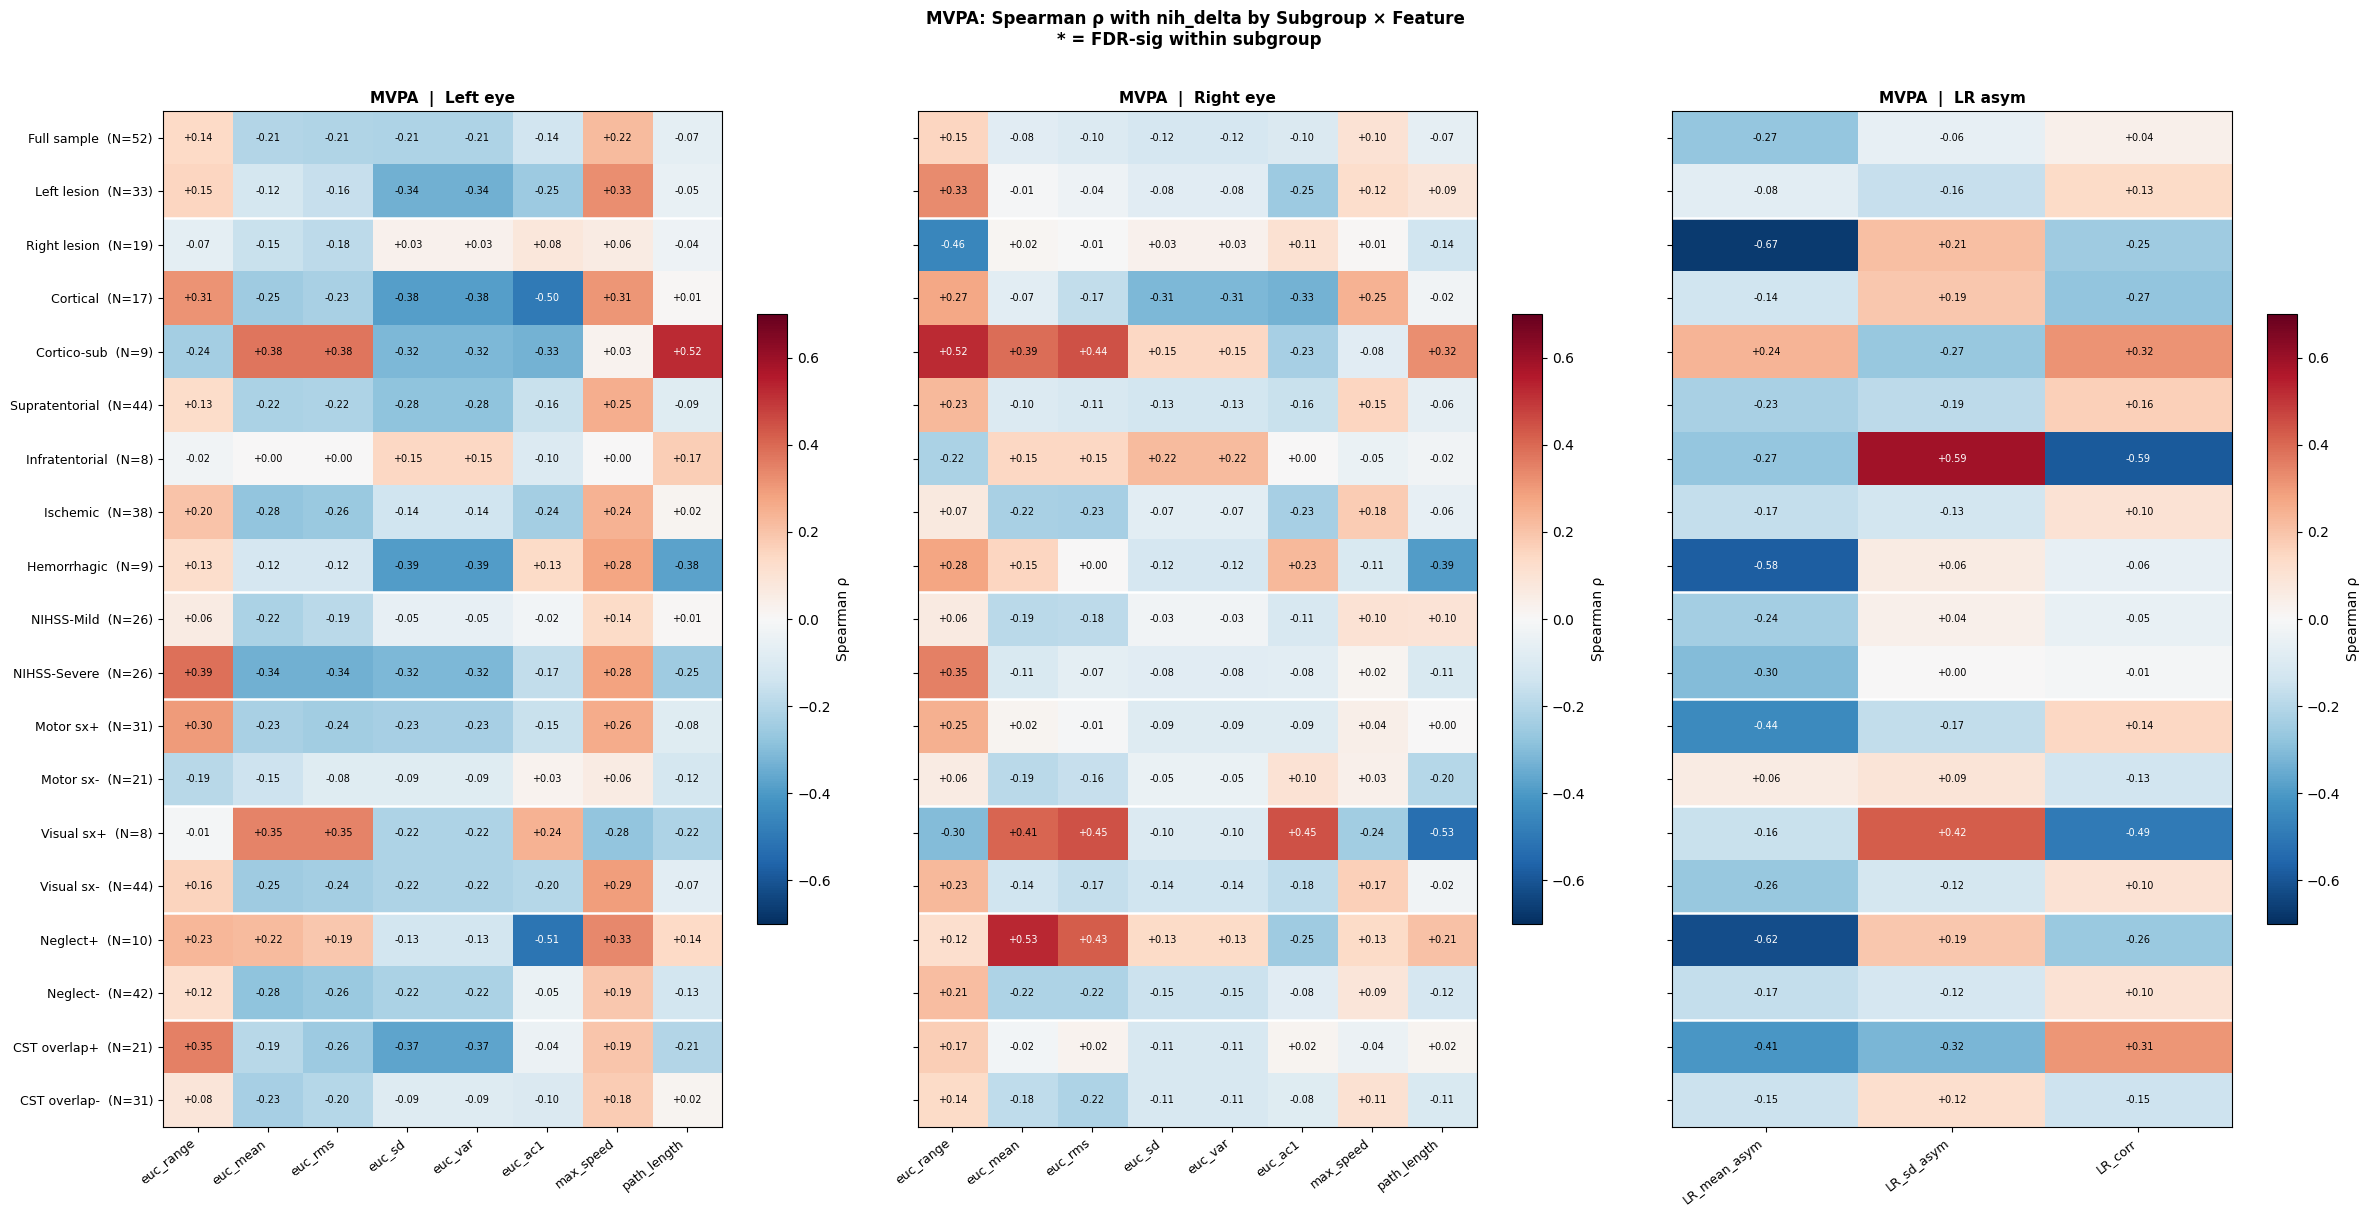

Saved: output/heatmap_MVPA_nih_delta.png


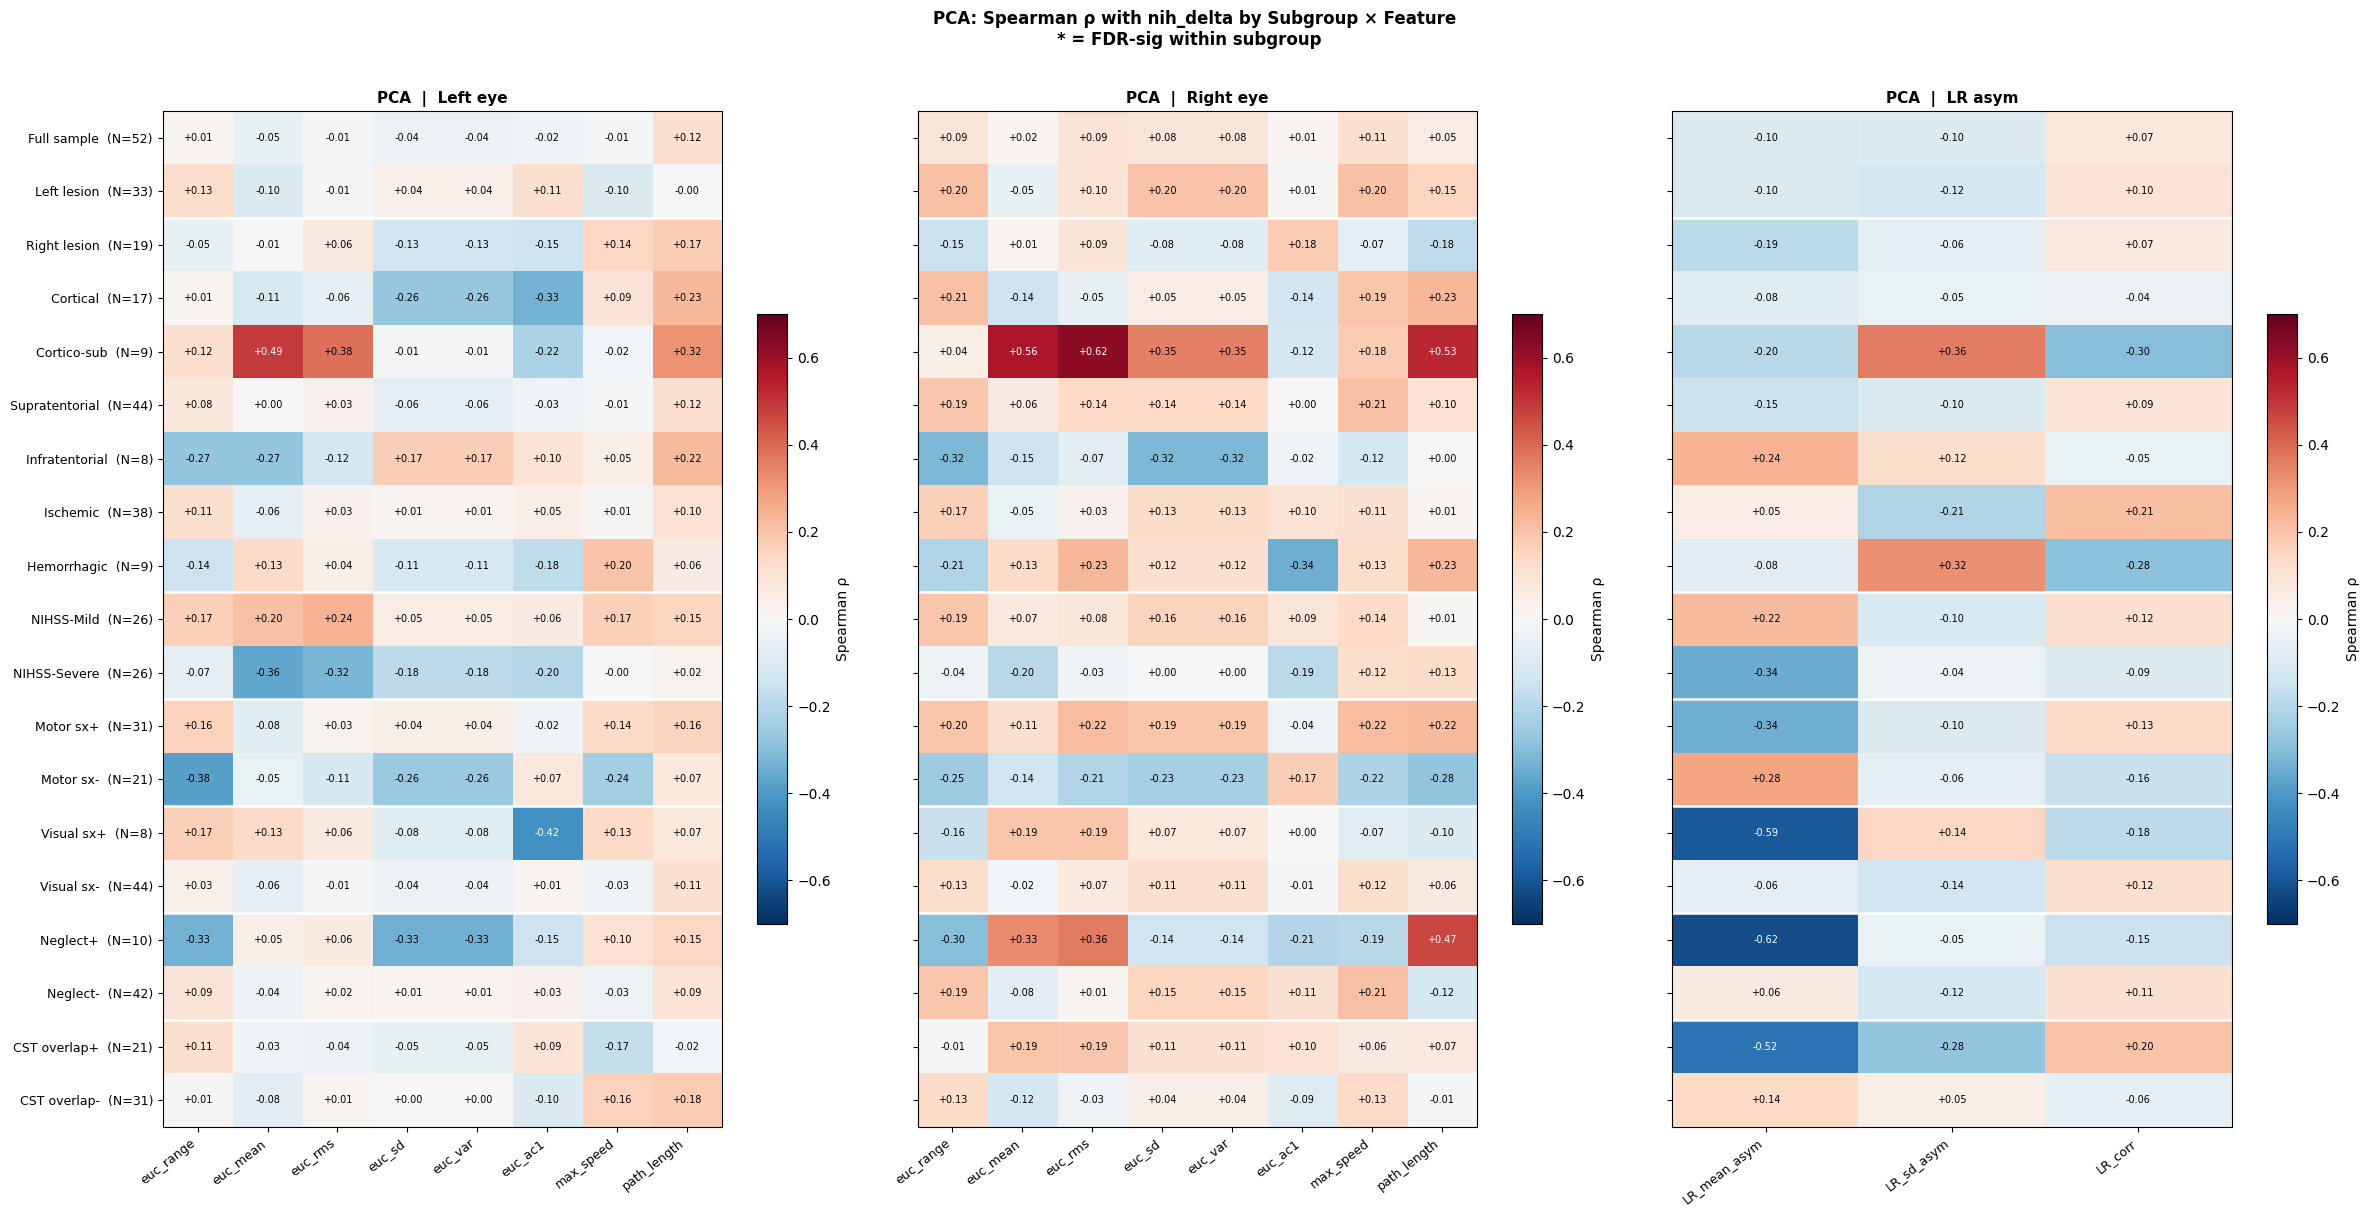

Saved: output/heatmap_PCA_nih_delta.png


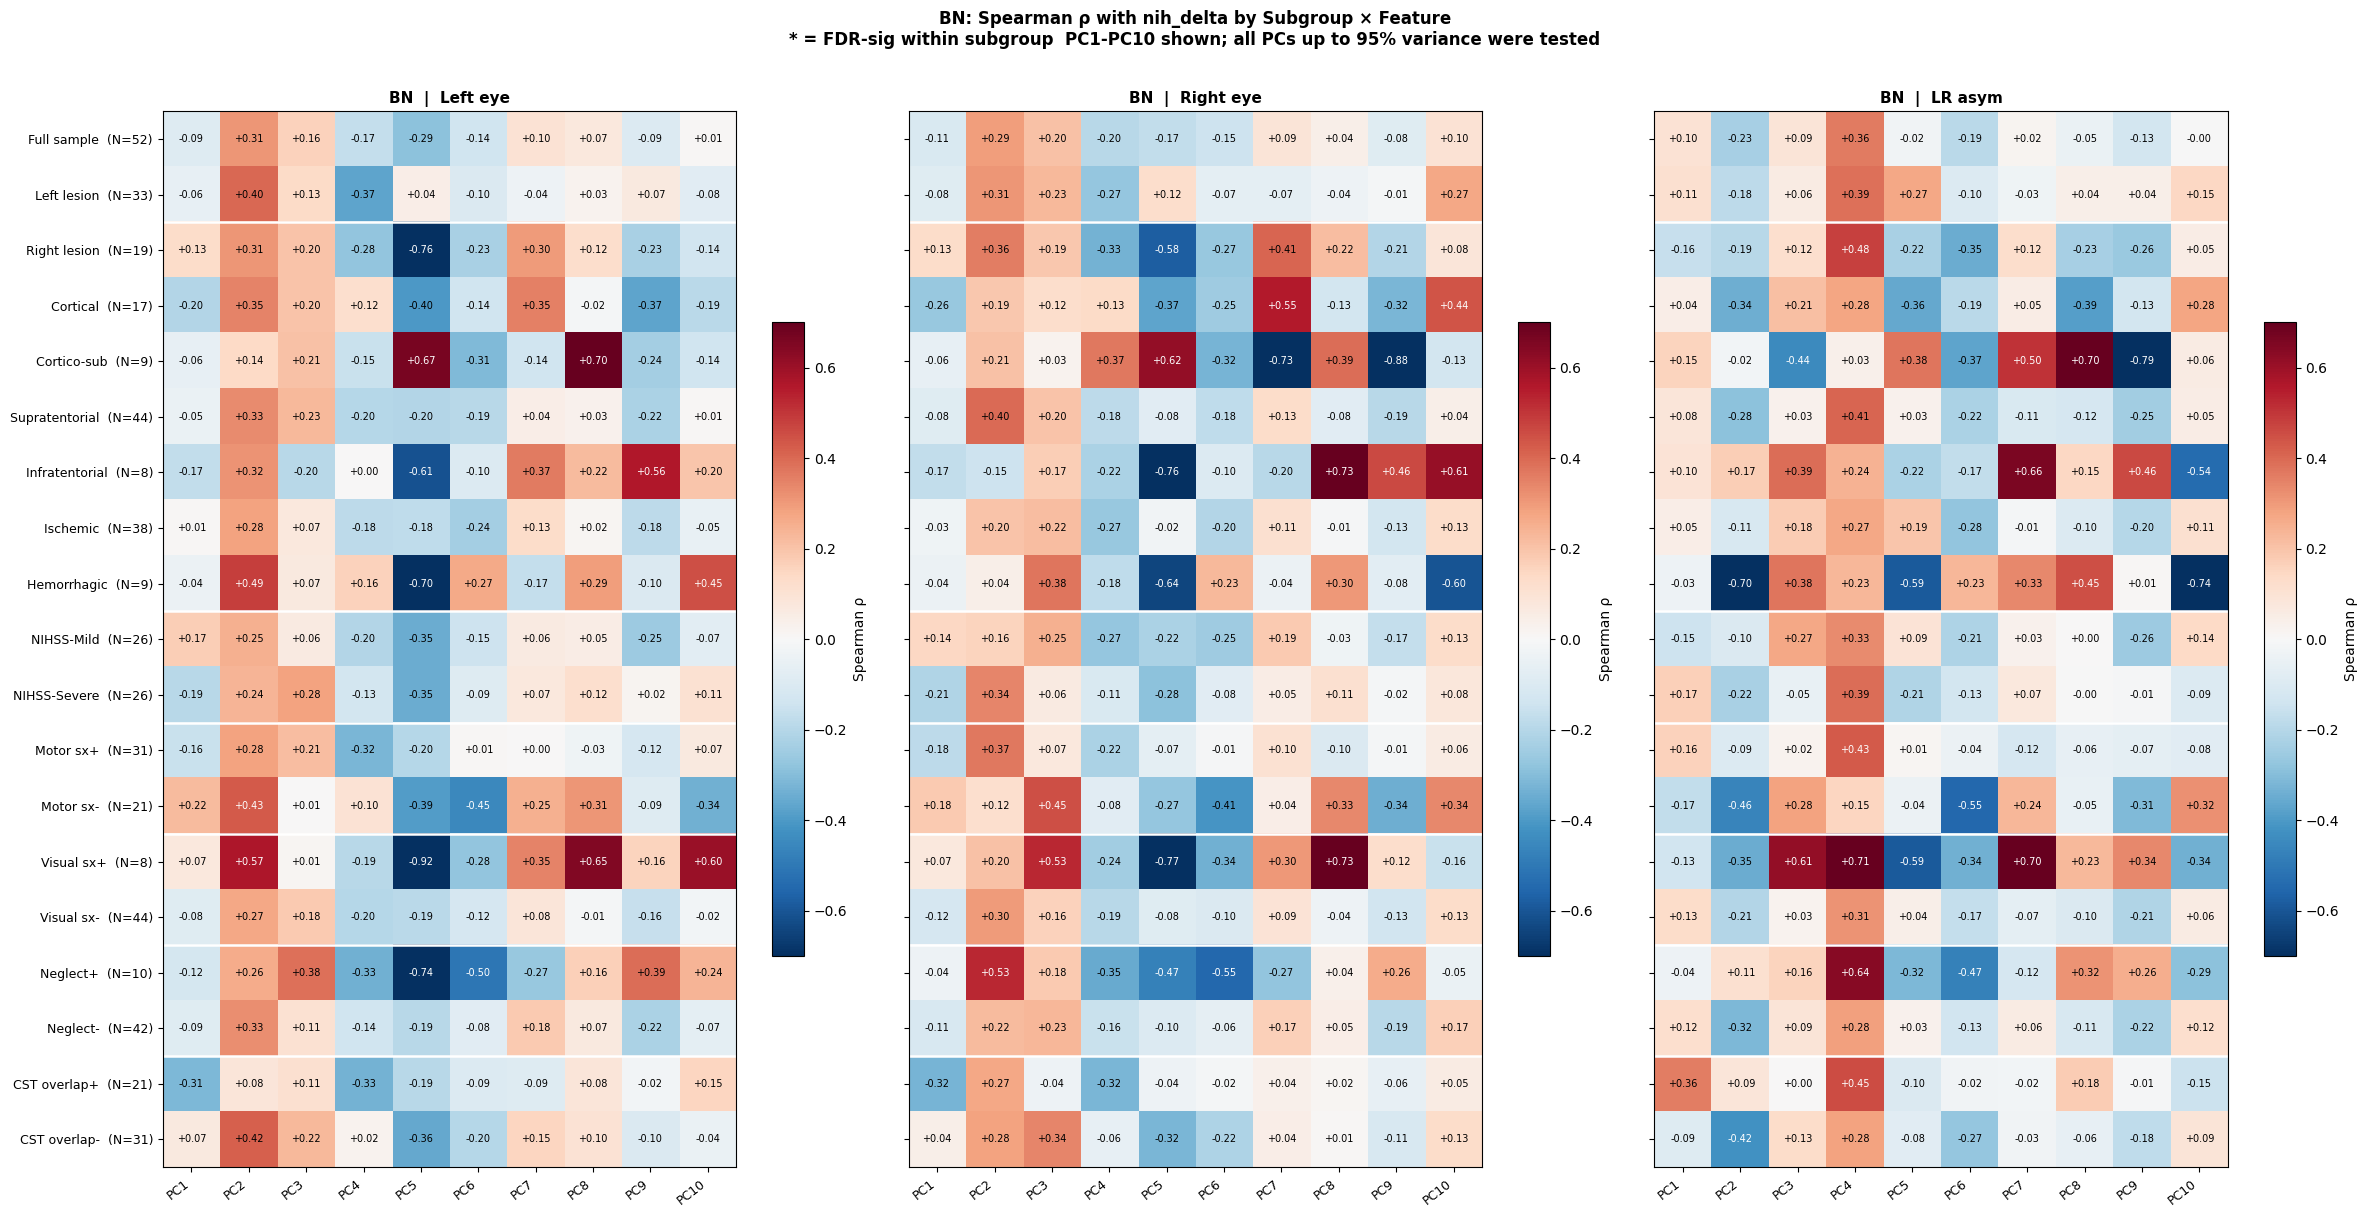

Saved: output/heatmap_BN_nih_delta.png

Best BN feature (by mean |rho| across subgroups):
  Left eye: BN_L_PC5
  Right eye: BN_R_PC111
  LR asym:  BN_LR_PC19


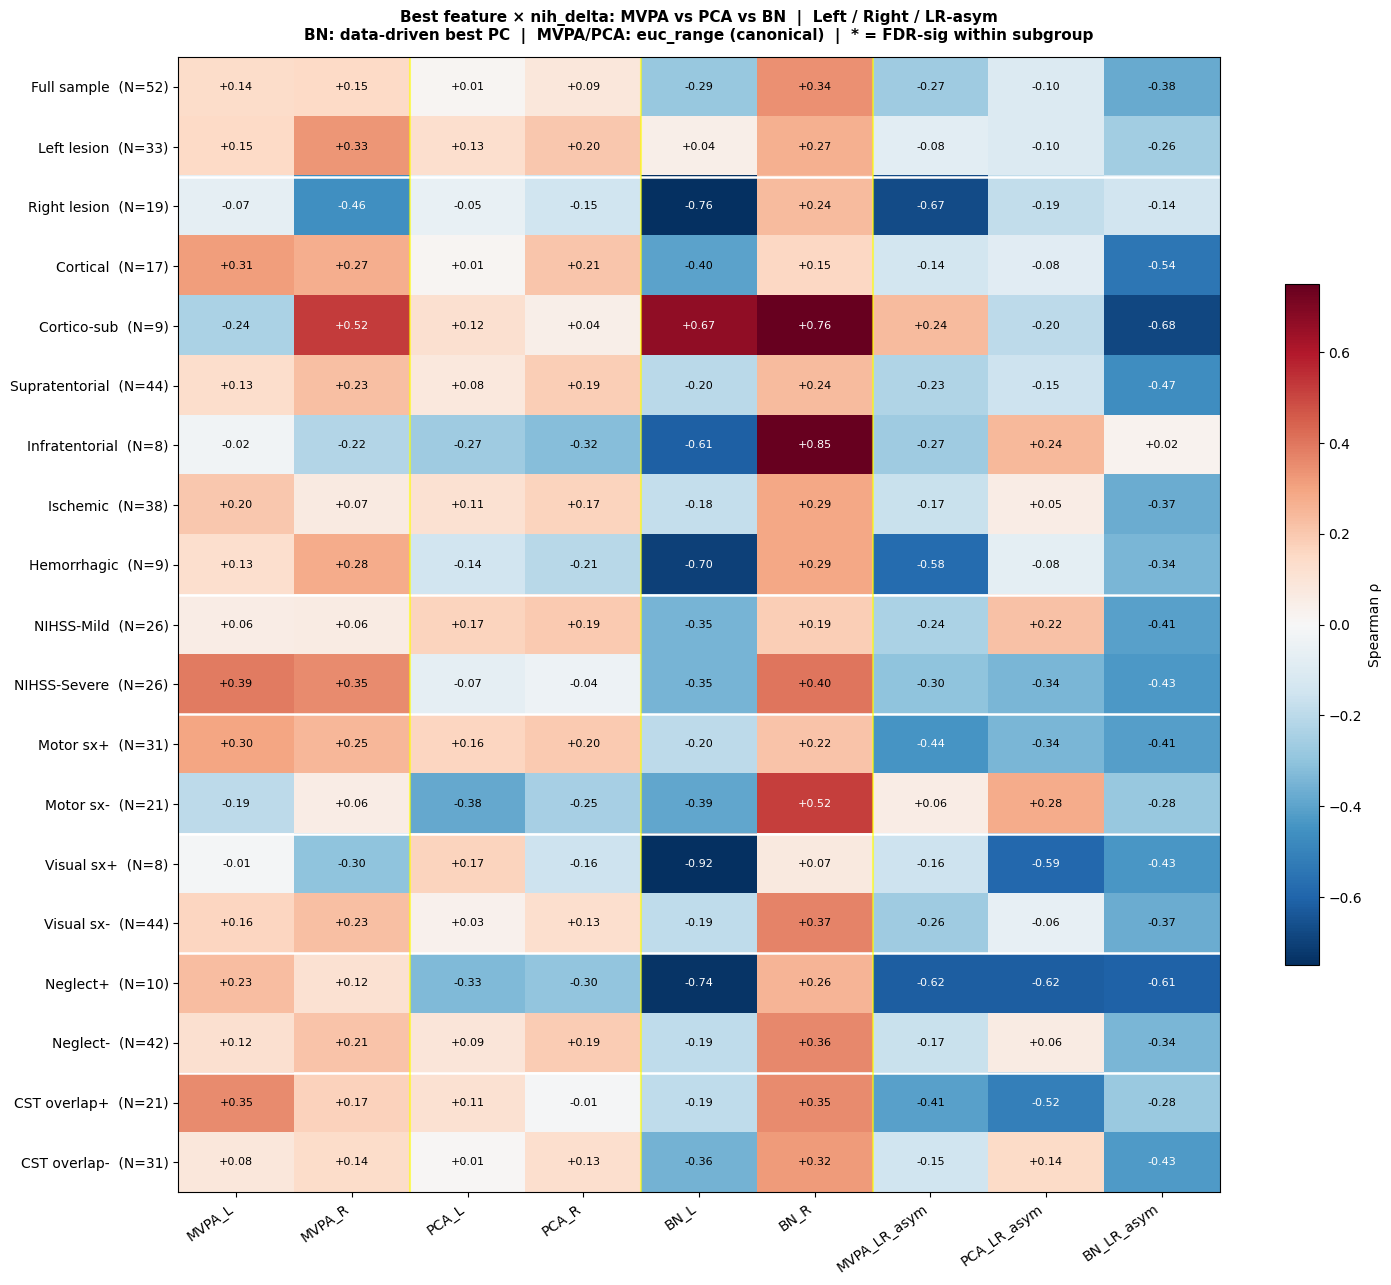

Saved: output/cross_method_heatmap.png


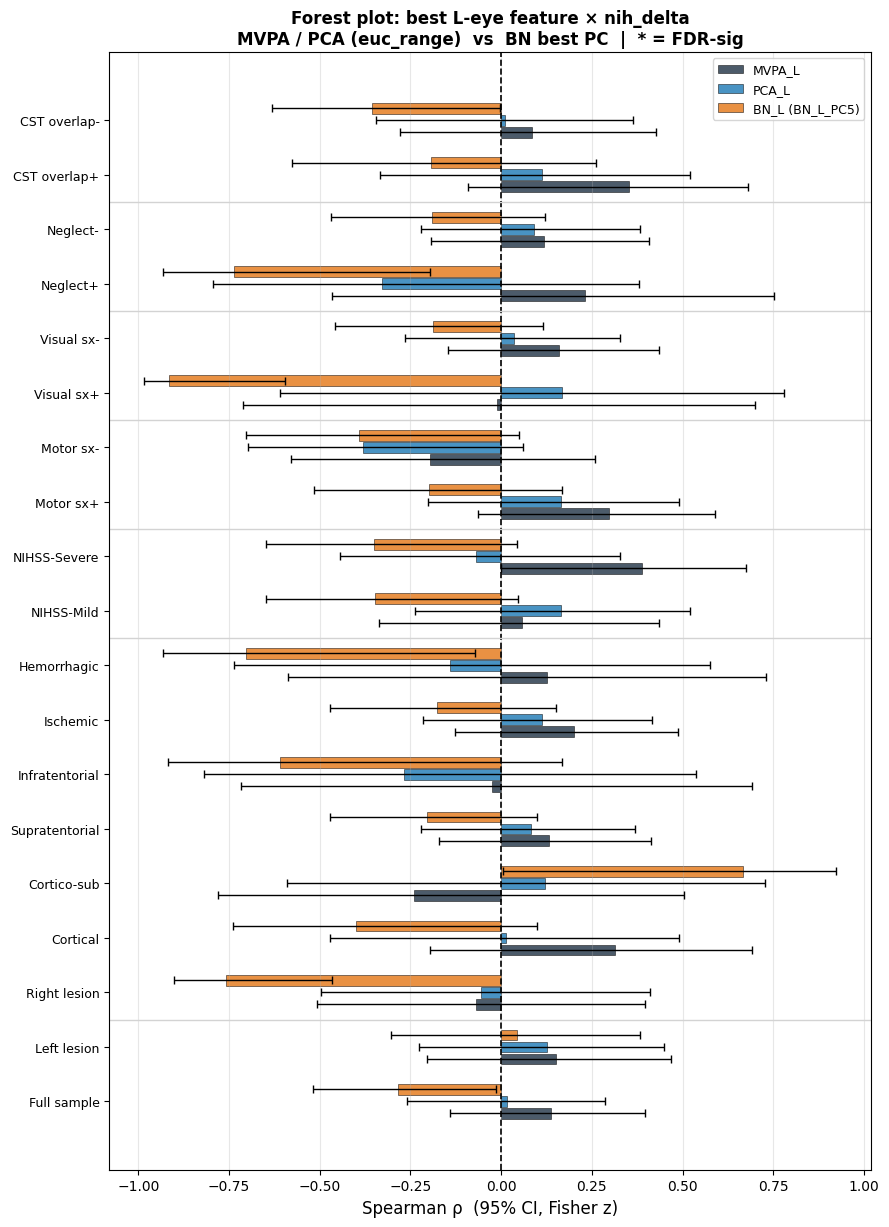

Saved: output/forest_3methods.png

IPSILESIONAL vs CONTRALESIONAL  (FDR over all lateralization tests)
  BN_best_L_vs_R            contra    rho=-0.260  p=0.0628  p_fdr=0.4917     N=52
  BN_best_L_vs_R            ipsi      rho=+0.122  p=0.3873  p_fdr=0.7746     N=52
  MVPA_euc_mean             contra    rho=-0.134  p=0.3441  p_fdr=0.7746     N=52
  MVPA_euc_mean             ipsi      rho=-0.135  p=0.3417  p_fdr=0.7746     N=52
  MVPA_euc_range            contra    rho=+0.232  p=0.0983  p_fdr=0.4917     N=52
  MVPA_euc_range            ipsi      rho=+0.037  p=0.7929  p_fdr=0.9237     N=52
  PCA_euc_mean              contra    rho=-0.014  p=0.9237  p_fdr=0.9237     N=52
  PCA_euc_mean              ipsi      rho=-0.023  p=0.8736  p_fdr=0.9237     N=52
  PCA_euc_range             contra    rho=+0.097  p=0.4951  p_fdr=0.8252     N=52
  PCA_euc_range             ipsi      rho=+0.030  p=0.8341  p_fdr=0.9237     N=52


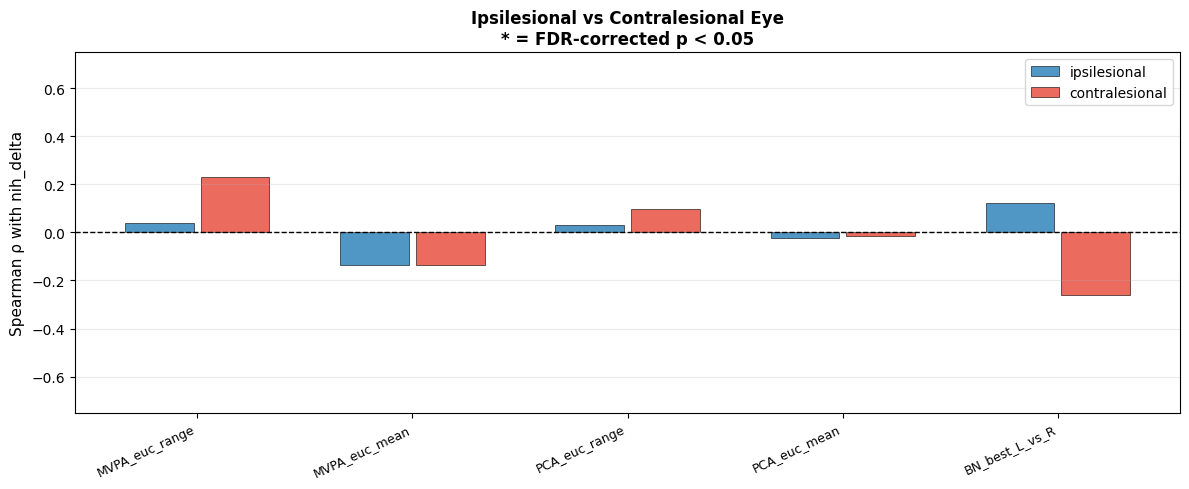

Saved: output/lateralization_ipsi_contra.png

Interaction model covariates: ['nihss_num', 'lesion_size_x', 'age', 'gender']

INTERACTION TESTS: feat_z × lesion_side → nih_delta  (OLS + covariates)

  MVPA_L_euc_range                        N=36
    [feat_z:C(side_c)[T.1.0]]: coef=-0.753  p=0.4388
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -1.5228      1.756     -0.867      0.393      -5.119       2.074
C(side_c)[T.1.0]            0.7496      0.682      1.099      0.281      -0.648       2.147
feat_z                      0.9974      0.347      2.872      0.008       0.286       1.709
feat_z:C(side_c)[T.1.0]    -0.7530      0.959     -0.785      0.439      -2.717       1.211
nihss_num                  -0.1752      0.089     -1.959      0.060      -0.358       0.008
lesion_size_x           -5.997e-05      0.000     -0.448  

In [19]:

# =============================================================================
# STEP 0 UPDATE — Re-fit PCA with enough components for 95% variance
#   Run this BEFORE steps 1-3 (replaces the N_BN_PCS=10 block)
#   Then re-run steps 1-3, then continue with steps 4-10 below.
# =============================================================================
import os, re, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
from statsmodels.formula.api import ols
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
warnings.filterwarnings("ignore")
os.makedirs("output", exist_ok=True)

BOTTLENECK_PATH = "/mnt/compneuro/deepmreye_finetuning/stroke_bottleneck.pkl"
OUTCOME         = "nih_delta"
MIN_N_SUBGRP    = 8
ALPHA_FDR       = 0.05
VAR_THRESHOLD   = 0.95   # keep enough PCs to explain this fraction of variance

SUFFIXES = [
    "euc_range", "euc_mean", "euc_rms", "euc_sd", "euc_var",
    "euc_ac1",   "euc_mssd", "euc_spec_entropy",
    "max_speed", "mean_speed", "path_length",
    "sd", "var", "mean",
    "LR_mean_asym", "LR_sd_asym", "LR_corr",
]
SITE_LABELS = {
    0:"Subcortical", 1:"Cortical", 2:"Cortico-sub",
    3:"WM only",     4:"Brainstem", 5:"Cerebellar", 6:"Other"
}
SG_ORDER = [
    "Full sample",
    "Left lesion", "Right lesion",
    "Subcortical", "Cortical", "Cortico-sub", "WM only", "Brainstem", "Cerebellar",
    "Supratentorial", "Infratentorial",
    "Ischemic", "Hemorrhagic",
    "NIHSS-Mild", "NIHSS-Severe",
    "Motor sx+", "Motor sx-",
    "Visual sx+", "Visual sx-",
    "Neglect+", "Neglect-",
    "CST overlap+", "CST overlap-",
]
METHODS = ["MVPA", "PCA", "BN"]

# ── Load and parse bottleneck ─────────────────────────────────────────────────
with open(BOTTLENECK_PATH, "rb") as f:
    bn_raw = pickle.load(f)

def parse_bn_key(key):
    id_m  = re.search(r'sub-([A-Za-z0-9]+)', key)
    ses_m = re.search(r'ses-([^_]+)', key)
    return (id_m.group(1) if id_m else None,
            ses_m.group(1) if ses_m else None)

bn_rows = []
for key, val in bn_raw.items():
    ID, session = parse_bn_key(key)
    if ID is None or session is None: continue
    try:
        bn_r = np.array(val["bottleneck_right"], dtype=np.float32)
        bn_l = np.array(val["bottleneck_left"],  dtype=np.float32)
    except Exception: continue
    if bn_r.ndim == 1: bn_r = bn_r[np.newaxis, :]
    if bn_l.ndim == 1: bn_l = bn_l[np.newaxis, :]
    bn_rows.append({
        "ID": ID, "Session": session,
        "l_mean": bn_l.mean(0), "l_std": bn_l.std(0),
        "r_mean": bn_r.mean(0), "r_std": bn_r.std(0),
        "lr_asym": bn_l.mean(0) - bn_r.mean(0),
    })
bn_df = pd.DataFrame(bn_rows)

# ── Build block matrices (all 418 sessions) ───────────────────────────────────
X_L_all  = np.stack([np.concatenate([r["l_mean"], r["l_std"]])
                     for _, r in bn_df.iterrows()]).astype(np.float32)
X_R_all  = np.stack([np.concatenate([r["r_mean"], r["r_std"]])
                     for _, r in bn_df.iterrows()]).astype(np.float32)
X_LR_all = np.stack([r["lr_asym"]
                     for _, r in bn_df.iterrows()]).astype(np.float32)

# ── Adaptive PCA: determine n_pcs for VAR_THRESHOLD per block ─────────────────
def fit_pca_adaptive(X_block, var_threshold, block_name, max_pcs=None):
    N = X_block.shape[0]
    max_pcs = min(max_pcs or N-1, N-1, X_block.shape[1])
    X_imp = SimpleImputer(strategy="median").fit_transform(X_block)
    X_sc  = StandardScaler().fit_transform(X_imp)
    # fit full rank to find threshold
    pca_full = PCA(n_components=max_pcs).fit(X_sc)
    cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
    n_needed = int(np.searchsorted(cumvar, var_threshold)) + 1
    n_needed = min(n_needed, max_pcs)
    # refit with exact n
    pca_final  = PCA(n_components=n_needed).fit(X_sc)
    scores     = pca_final.transform(X_sc)
    final_var  = np.sum(pca_final.explained_variance_ratio_)
    print(f"  {block_name:<22}: {n_needed:3d} PCs → "
          f"{final_var*100:.1f}% variance  "
          f"(PC1={pca_final.explained_variance_ratio_[0]*100:.1f}%)")
    return scores, pca_final, n_needed

print(f"Fitting PCA per block (target: {VAR_THRESHOLD*100:.0f}% variance, "
      f"all 418 sessions):")
scores_L,  pca_L,  n_L  = fit_pca_adaptive(X_L_all,  VAR_THRESHOLD, "L  (l_mean+l_std)")
scores_R,  pca_R,  n_R  = fit_pca_adaptive(X_R_all,  VAR_THRESHOLD, "R  (r_mean+r_std)")
scores_LR, pca_LR, n_LR = fit_pca_adaptive(X_LR_all, VAR_THRESHOLD, "LR (lr_asym)")

N_BN_PCS = max(n_L, n_R, n_LR)
print(f"\nPCs per block: L={n_L}  R={n_R}  LR={n_LR}  (max used={N_BN_PCS})")

# ── Store PC scores in bn_df ───────────────────────────────────────────────────
for i in range(n_L):
    bn_df[f"BN_L_PC{i+1}"]  = scores_L[:,  i]
for i in range(n_R):
    bn_df[f"BN_R_PC{i+1}"]  = scores_R[:,  i]
for i in range(n_LR):
    bn_df[f"BN_LR_PC{i+1}"] = scores_LR[:, i]

bn_cols  = [c for c in bn_df.columns if c.startswith("BN_")]
bn_acute = (bn_df[bn_df["Session"] == "acute"][["ID"] + bn_cols]
            .drop_duplicates("ID").reset_index(drop=True))
print(f"Acute BN rows: {len(bn_acute)}  |  BN columns: {len(bn_cols)}")

# ── Update feature lists ───────────────────────────────────────────────────────
def build_feat_list(method, eye):
    if method == "BN":
        n = {"L": n_L, "R": n_R, "LR": n_LR}[eye]
        prefix = "LR" if eye == "LR" else eye
        return [f"BN_{prefix}_PC{i+1}" for i in range(n)]
    prefix = f"{method}_{eye}"
    if eye == "LR":
        return [f"{method}_LR_mean_asym",
                f"{method}_LR_sd_asym",
                f"{method}_LR_corr"]
    return [f"{prefix}_{s}" for s in SUFFIXES]

ALL_FEATS = {m: (build_feat_list(m,"L") +
                 build_feat_list(m,"R") +
                 build_feat_list(m,"LR"))
             for m in METHODS}
print(f"Feature counts: "
      + "  ".join(f"{m}={len(ALL_FEATS[m])}" for m in METHODS))

# =============================================================================
# STEP 1 — ENRICH recovery_df  (same as before, adds BN PC columns)
# =============================================================================
clin_cols = [
    "ID","lesion_site","lesion_side","lesion_type","lesion_size","nihss_hospital",
    "lcst","rcst",
    "motor_er___2","motor_er___3","motor_er___4","motor_er___5",
    "visual_er___1","visual_er___2","visual_er___3","attention_er___1",
    "bigfactor1","bigfactor2","bigfactor3","age","gender",
]
clin_cols  = [c for c in clin_cols if c in stroke_csv.columns]
acute_clin = (stroke_csv[stroke_csv["Session"]=="acute"]
              .drop_duplicates("ID")[clin_cols].copy())
for c in ["motor_er___2","motor_er___3","motor_er___4","motor_er___5",
          "visual_er___1","visual_er___2","visual_er___3","attention_er___1"]:
    if c in acute_clin.columns:
        acute_clin[c] = pd.to_numeric(acute_clin[c], errors="coerce").fillna(0)
motor_cols  = [c for c in ["motor_er___2","motor_er___3","motor_er___4","motor_er___5"]
               if c in acute_clin.columns]
visual_cols = [c for c in ["visual_er___1","visual_er___2","visual_er___3"]
               if c in acute_clin.columns]
acute_clin["any_motor"]   = (acute_clin[motor_cols].sum(1)>0).astype(int)
acute_clin["any_visual"]  = (acute_clin[visual_cols].sum(1)>0).astype(int)
acute_clin["any_neglect"] = (acute_clin["attention_er___1"].astype(int)
                              if "attention_er___1" in acute_clin.columns else 0)
for col in ["lcst","rcst"]:
    if col in acute_clin.columns:
        acute_clin[f"{col}_n"] = pd.to_numeric(acute_clin[col],errors="coerce").fillna(0)
lcst_n = "lcst_n" if "lcst_n" in acute_clin.columns else None
rcst_n = "rcst_n" if "rcst_n" in acute_clin.columns else None
if lcst_n and rcst_n:
    acute_clin["any_cst"] = ((acute_clin[lcst_n]+acute_clin[rcst_n])>0).astype(int)
elif lcst_n:
    acute_clin["any_cst"] = (acute_clin[lcst_n]>0).astype(int)
else:
    acute_clin["any_cst"] = 0
acute_clin["nihss_num"] = pd.to_numeric(acute_clin["nihss_hospital"],errors="coerce")
nihss_med               = acute_clin["nihss_num"].median()
acute_clin["sev_group"] = np.where(acute_clin["nihss_num"]<=nihss_med,"Mild","Severe")
acute_clin["infra"]     = acute_clin["lesion_site"].isin([4,5]).astype(int)
print(f"\nNIHSS hospital median: {nihss_med}")

rdf = recovery_df.merge(acute_clin, on="ID", how="left")
rdf = rdf.merge(bn_acute,           on="ID", how="left")
print(f"Enriched rdf: {rdf.shape},  {OUTCOME} N={rdf[OUTCOME].notna().sum()}")

# =============================================================================
# STEP 2 — HELPERS  (unchanged)
# =============================================================================
def subgroup_corr(subdf, features, outcome, label):
    rows = []
    for feat in features:
        if feat not in subdf.columns: continue
        valid = subdf[[feat, outcome]].dropna()
        n = len(valid)
        if n < MIN_N_SUBGRP:
            rows.append(dict(Feature=feat,Subgroup=label,N=n,rho=np.nan,p=np.nan))
            continue
        rho, p = stats.spearmanr(valid[feat], valid[outcome])
        rows.append(dict(Feature=feat,Subgroup=label,N=n,rho=rho,p=p))
    out = pd.DataFrame(rows)
    if len(out)>0 and out["p"].notna().sum()>1:
        mask = out["p"].notna()
        _, pc = fdrcorrection(out.loc[mask,"p"].values)
        out.loc[mask,"p_fdr"] = pc
    if "p_fdr" not in out.columns: out["p_fdr"] = np.nan
    out["sig_fdr"] = out["p_fdr"] < ALPHA_FDR
    out["abs_rho"] = out["rho"].abs()
    return out

def make_subgroups(df):
    yield "Full sample", df
    for val,lbl in [(0,"Left lesion"),(1,"Right lesion")]:
        yield lbl, df[df["lesion_side"]==val]
    for val,lbl in SITE_LABELS.items():
        sub = df[df["lesion_site"]==val]
        if sub[OUTCOME].notna().sum()>=MIN_N_SUBGRP: yield lbl, sub
    for val,lbl in [(0,"Supratentorial"),(1,"Infratentorial")]:
        sub = df[df["infra"]==val]
        if sub[OUTCOME].notna().sum()>=MIN_N_SUBGRP: yield lbl, sub
    for val,lbl in [(0,"Ischemic"),(1,"Hemorrhagic")]:
        sub = df[df["lesion_type"]==val]
        if sub[OUTCOME].notna().sum()>=MIN_N_SUBGRP: yield lbl, sub
    for lbl in ["Mild","Severe"]:
        yield f"NIHSS-{lbl}", df[df["sev_group"]==lbl]
    for val,lbl in [(1,"Motor sx+"),(0,"Motor sx-")]:
        yield lbl, df[df["any_motor"]==val]
    for val,lbl in [(1,"Visual sx+"),(0,"Visual sx-")]:
        sub = df[df["any_visual"]==val]
        if sub[OUTCOME].notna().sum()>=MIN_N_SUBGRP: yield lbl, sub
    for val,lbl in [(1,"Neglect+"),(0,"Neglect-")]:
        sub = df[df["any_neglect"]==val]
        if sub[OUTCOME].notna().sum()>=MIN_N_SUBGRP: yield lbl, sub
    for val,lbl in [(1,"CST overlap+"),(0,"CST overlap-")]:
        sub = df[df["any_cst"]==val]
        if sub[OUTCOME].notna().sum()>=MIN_N_SUBGRP: yield lbl, sub

def fisher_ci(rho, n, alpha=0.05):
    if pd.isna(rho) or n<4: return np.nan, np.nan
    z=np.arctanh(np.clip(rho,-0.9999,0.9999)); se=1/np.sqrt(n-3)
    zc=stats.norm.ppf(1-alpha/2)
    return np.tanh(z-zc*se), np.tanh(z+zc*se)

def tag_eye(feat):
    f = feat.upper()
    if "_LR_" in f: return "LR asym"
    if "_L_"  in f: return "Left eye"
    if "_R_"  in f: return "Right eye"
    return "?"

def tag_suffix(feat):
    m = re.search(r'_(PC\d+)$', feat)
    if m: return m.group(1)
    for suf in sorted(SUFFIXES, key=len, reverse=True):
        if feat.endswith(suf): return suf
    return feat

# =============================================================================
# STEP 3 — RUN ALL SUBGROUPS × ALL METHODS
# =============================================================================
print("\nRunning subgroup correlations …")
all_results = []
for sg_label, sg_df in make_subgroups(rdf):
    for method in METHODS:
        r = subgroup_corr(sg_df, ALL_FEATS[method], OUTCOME, sg_label)
        r["Method"] = method
        all_results.append(r)

sg_full = pd.concat(all_results, ignore_index=True)
sg_full["Eye"]    = sg_full["Feature"].apply(tag_eye)
sg_full["Suffix"] = sg_full["Feature"].apply(tag_suffix)
sg_full.to_csv("output/subgroup_MVPA_PCA_BN_nih_delta.csv", index=False)
print(f"Result table: {sg_full.shape[0]} rows")

# =============================================================================
# STEP 4 — PRINT FDR-SIGNIFICANT SUMMARY
# =============================================================================
print("\n" + "="*80)
print("FDR-SIGNIFICANT RESULTS  (p_fdr < 0.05, within-subgroup FDR)")
print("="*80)
sig = sg_full[sg_full["sig_fdr"]].sort_values(
      ["Subgroup","Method","abs_rho"], ascending=[True,True,False])
for sg in SG_ORDER:
    sub = sig[sig["Subgroup"]==sg]
    if len(sub)==0: continue
    print(f"\n[{sg}]")
    for m in METHODS:
        mm = sub[sub["Method"]==m]
        if len(mm)==0: continue
        print(f"  -- {m} --")
        for _,r in mm.sort_values("abs_rho",ascending=False).iterrows():
            print(f"    {r.Feature:<40}  {r.Eye:<10}  rho={r.rho:+.3f}"
                  f"  p={r.p:.4f}  p_fdr={r.p_fdr:.4f}  N={int(r.N)}")

# =============================================================================
# STEP 5 — HEATMAPS  (one figure per method)
# =============================================================================
# For MVPA/PCA: show key scalar suffixes as columns
# For BN: show PC1–PC10 as columns (most variance-explaining), annotate best
KEY_SCALAR_SUFFIXES = [
    "euc_range","euc_mean","euc_rms","euc_sd","euc_var",
    "euc_ac1","max_speed","path_length",
    "LR_mean_asym","LR_sd_asym","LR_corr"
]
BN_DISPLAY_PCS = [f"PC{i+1}" for i in range(10)]  # show top 10 PCs in heatmap

SG_AVAIL = [s for s in SG_ORDER if s in sg_full["Subgroup"].values]

def make_heatmap(method, sg_avail):
    mdf = sg_full[sg_full["Method"]==method]
    eyes_to_plot = ["Left eye","Right eye","LR asym"]

    if method == "BN":
        col_sets = {"Left eye": BN_DISPLAY_PCS,
                    "Right eye": BN_DISPLAY_PCS,
                    "LR asym": BN_DISPLAY_PCS}
    else:
        col_sets = {"Left eye":  KEY_SCALAR_SUFFIXES[:8],
                    "Right eye": KEY_SCALAR_SUFFIXES[:8],
                    "LR asym":   ["LR_mean_asym","LR_sd_asym","LR_corr"]}

    ncols = len(eyes_to_plot)
    fig, axes = plt.subplots(1, ncols,
                             figsize=(8*ncols, len(sg_avail)*0.5+2.5),
                             sharey=True)
    if ncols == 1: axes = [axes]

    for ax, eye in zip(axes, eyes_to_plot):
        sub      = mdf[mdf["Eye"]==eye]
        col_order= [c for c in col_sets[eye] if c in sub["Suffix"].values]
        if not col_order:
            ax.set_visible(False); continue

        pivot_rho = (sub.pivot_table(index="Subgroup",columns="Suffix",
                                     values="rho",aggfunc="first")
                       .reindex(sg_avail)[col_order])
        pivot_sig = (sub.pivot_table(index="Subgroup",columns="Suffix",
                                     values="sig_fdr",aggfunc="first")
                       .reindex(sg_avail)[col_order].fillna(False))
        pivot_n   = (sub.pivot_table(index="Subgroup",columns="Suffix",
                                     values="N",aggfunc="first")
                       .reindex(sg_avail))

        rho_arr = pivot_rho.values.astype(float)
        im = ax.imshow(rho_arr, cmap="RdBu_r", vmin=-0.7, vmax=0.7, aspect="auto")
        plt.colorbar(im, ax=ax, label="Spearman ρ", shrink=0.6)

        ax.set_xticks(range(len(col_order)))
        ax.set_xticklabels(col_order, rotation=38, ha="right", fontsize=9)
        ax.set_yticks(range(len(sg_avail)))
        row_labels = []
        for sg in sg_avail:
            n_ = pivot_n.loc[sg].dropna()
            row_labels.append(f"{sg}  (N={int(n_.iloc[0]) if len(n_) else '?'})")
        ax.set_yticklabels(row_labels, fontsize=9)

        for ri, sg in enumerate(pivot_rho.index):
            for ci, feat in enumerate(pivot_rho.columns):
                v = rho_arr[ri, ci]
                try: s = bool(pivot_sig.loc[sg,feat])
                except: s = False
                if not np.isnan(v):
                    txt   = f"{v:+.2f}" + ("*" if s else "")
                    color = "white" if abs(v)>0.42 else "black"
                    ax.text(ci, ri, txt, ha="center", va="center",
                            fontsize=7, color=color,
                            fontweight="bold" if s else "normal")

        for sep in [2,9,11,13,15,17,19,21]:
            if sep < len(sg_avail):
                ax.axhline(sep-0.5, color="white", linewidth=1.8)
        ax.set_title(f"{method}  |  {eye}", fontsize=11, fontweight="bold")

    suffix_note = ("PC1-PC10 shown; all PCs up to 95% variance were tested"
                   if method=="BN" else "")
    fig.suptitle(
        f"{method}: Spearman ρ with {OUTCOME} by Subgroup × Feature\n"
        f"* = FDR-sig within subgroup  {suffix_note}",
        fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    path = f"output/heatmap_{method}_{OUTCOME}.png"
    plt.savefig(path, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

for method in METHODS:
    make_heatmap(method, SG_AVAIL)

# =============================================================================
# STEP 6 — CROSS-METHOD COMPARISON HEATMAP
#   Best representative feature per method × eye:
#     MVPA/PCA: euc_range (canonical)
#     BN:       PC with highest mean |rho| across all subgroups (data-driven)
# =============================================================================
def best_bn_feat(eye_label):
    """Return the BN PC feature with highest mean |rho| across all subgroups."""
    sub = sg_full[(sg_full["Method"]=="BN") &
                  (sg_full["Eye"]==eye_label) &
                  sg_full["rho"].notna()]
    if len(sub)==0: return None
    return (sub.groupby("Feature")["abs_rho"].mean()
               .idxmax())

bn_best_L  = best_bn_feat("Left eye")
bn_best_R  = best_bn_feat("Right eye")
bn_best_LR = best_bn_feat("LR asym")
print(f"\nBest BN feature (by mean |rho| across subgroups):")
print(f"  Left eye: {bn_best_L}")
print(f"  Right eye: {bn_best_R}")
print(f"  LR asym:  {bn_best_LR}")

KEY_FEAT_PER_METHOD = {
    "MVPA_L":      "MVPA_L_euc_range",
    "MVPA_R":      "MVPA_R_euc_range",
    "PCA_L":       "PCA_L_euc_range",
    "PCA_R":       "PCA_R_euc_range",
    "BN_L":        bn_best_L,
    "BN_R":        bn_best_R,
    "MVPA_LR_asym":"MVPA_LR_mean_asym",
    "PCA_LR_asym": "PCA_LR_mean_asym",
    "BN_LR_asym":  bn_best_LR,
}
KEY_FEAT_PER_METHOD = {k:v for k,v in KEY_FEAT_PER_METHOD.items() if v is not None}

cross_rows = []
for sg_label, _ in make_subgroups(rdf):
    for col_label, feat in KEY_FEAT_PER_METHOD.items():
        method = feat.split("_")[0]
        sub = sg_full[(sg_full["Subgroup"]==sg_label) &
                      (sg_full["Feature"]==feat) &
                      (sg_full["Method"]==method)]
        if len(sub)==1:
            r = sub.iloc[0]
            cross_rows.append({"Subgroup":sg_label,"Column":col_label,
                                "rho":r["rho"],"sig_fdr":r["sig_fdr"],"N":r["N"]})
        else:
            cross_rows.append({"Subgroup":sg_label,"Column":col_label,
                                "rho":np.nan,"sig_fdr":False,"N":np.nan})

cross_df = pd.DataFrame(cross_rows)
cross_df.to_csv("output/cross_method_heatmap.csv", index=False)

col_order_c = list(KEY_FEAT_PER_METHOD.keys())
pivot_c = (cross_df.pivot_table(index="Subgroup",columns="Column",
                                values="rho",aggfunc="first")
                   .reindex(SG_AVAIL)[col_order_c])
pivot_s = (cross_df.pivot_table(index="Subgroup",columns="Column",
                                values="sig_fdr",aggfunc="first")
                   .reindex(SG_AVAIL)[col_order_c].fillna(False))
pivot_n = (cross_df.pivot_table(index="Subgroup",columns="Column",
                                values="N",aggfunc="first")
                   .reindex(SG_AVAIL))

fig, ax = plt.subplots(figsize=(15, len(SG_AVAIL)*0.55+2.5))
im = ax.imshow(pivot_c.values.astype(float),
               cmap="RdBu_r", vmin=-0.75, vmax=0.75, aspect="auto")
plt.colorbar(im, ax=ax, label="Spearman ρ", shrink=0.6)
ax.set_xticks(range(len(col_order_c)))
ax.set_xticklabels(col_order_c, rotation=35, ha="right", fontsize=10)
ax.set_yticks(range(len(SG_AVAIL)))
row_labels_c = []
for sg in SG_AVAIL:
    n_ = pivot_n.loc[sg].dropna()
    row_labels_c.append(f"{sg}  (N={int(n_.iloc[0]) if len(n_) else '?'})")
ax.set_yticklabels(row_labels_c, fontsize=10)
for ri,sg in enumerate(pivot_c.index):
    for ci,col in enumerate(col_order_c):
        v = pivot_c.values[ri,ci]
        try: s = bool(pivot_s.loc[sg,col])
        except: s = False
        if not np.isnan(float(v)):
            txt   = f"{v:+.2f}" + ("*" if s else "")
            color = "white" if abs(v)>0.42 else "black"
            ax.text(ci, ri, txt, ha="center", va="center",
                    fontsize=8, color=color, fontweight="bold" if s else "normal")
for sep in [2,9,11,13,15,17,19,21]:
    if sep < len(SG_AVAIL): ax.axhline(sep-0.5,color="white",linewidth=1.8)
for x_sep in [1.5, 3.5, 5.5]:
    ax.axvline(x_sep, color="yellow", linewidth=1.5, alpha=0.6)
ax.set_title(
    f"Best feature × {OUTCOME}: MVPA vs PCA vs BN  |  Left / Right / LR-asym\n"
    f"BN: data-driven best PC  |  MVPA/PCA: euc_range (canonical)"
    f"  |  * = FDR-sig within subgroup",
    fontsize=11, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("output/cross_method_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved: output/cross_method_heatmap.png")

# =============================================================================
# STEP 7 — FOREST PLOT
# =============================================================================
FOREST_FEATS = {
    "MVPA_L":  "MVPA_L_euc_range",
    "PCA_L":   "PCA_L_euc_range",
    f"BN_L ({bn_best_L})": bn_best_L,
}
method_palette = {
    "MVPA_L": "#2c3e50",
    "PCA_L":  "#2980b9",
    list(FOREST_FEATS.keys())[2]: "#e67e22",
}

fp_data = {}
for label, feat in FOREST_FEATS.items():
    if feat is None: continue
    method = feat.split("_")[0]
    sub = sg_full[(sg_full["Feature"]==feat) & (sg_full["Method"]==method)]
    sub = (sub.set_index("Subgroup").reindex(SG_AVAIL)
               .dropna(subset=["rho"]).reset_index())
    sub[["ci_lo","ci_hi"]] = pd.DataFrame(
        [fisher_ci(r["rho"],r["N"]) for _,r in sub.iterrows()],
        columns=["ci_lo","ci_hi"])
    sub["err_lo"] = sub["rho"] - sub["ci_lo"]
    sub["err_hi"] = sub["ci_hi"] - sub["rho"]
    fp_data[label] = sub

common_sgs = [s for s in SG_AVAIL
              if all(s in fp_data[k]["Subgroup"].values for k in fp_data)]

fig, ax = plt.subplots(figsize=(9, len(common_sgs)*0.52+2.5))
y      = np.arange(len(common_sgs))
offsets = dict(zip(FOREST_FEATS.keys(), [-0.22, 0, 0.22]))

for label, sub in fp_data.items():
    col   = method_palette[label]
    sub_c = (sub[sub["Subgroup"].isin(common_sgs)]
             .set_index("Subgroup").reindex(common_sgs).reset_index())
    e_lo  = sub_c["err_lo"].fillna(0).values
    e_hi  = sub_c["err_hi"].fillna(0).values
    ax.barh(y+offsets[label], sub_c["rho"].values, height=0.2,
            xerr=[e_lo,e_hi], color=col, alpha=0.85, label=label,
            edgecolor="black", linewidth=0.4,
            error_kw=dict(elinewidth=1.0, capsize=3, ecolor="black"))
    for yi, (_, row) in zip(y+offsets[label], sub_c.iterrows()):
        if row.get("sig_fdr", False):
            ax.text(row["rho"]+(0.03 if row["rho"]>0 else -0.06),
                    yi, "*", ha="center", va="center",
                    fontsize=11, color=col, fontweight="bold")

ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
ax.set_yticks(y); ax.set_yticklabels(common_sgs, fontsize=9)
ax.set_xlabel("Spearman ρ  (95% CI, Fisher z)", fontsize=12)
ax.set_title(f"Forest plot: best L-eye feature × {OUTCOME}\n"
             f"MVPA / PCA (euc_range)  vs  BN best PC  |  * = FDR-sig",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="x", alpha=0.3)
for sep in [2,9,11,13,15,17,19,21]:
    if sep<len(common_sgs): ax.axhline(sep-0.5,color="lightgray",linewidth=1)
plt.tight_layout()
plt.savefig("output/forest_3methods.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved: output/forest_3methods.png")

# =============================================================================
# STEP 8 — LATERALIZATION: ipsilesional vs contralesional
# =============================================================================
def get_ipsi_contra(df, method, feat_L, feat_R):
    rows = []
    for _, row in df.iterrows():
        side = row.get("lesion_side")
        if pd.isna(side): continue
        fl = row.get(feat_L, np.nan)
        fr = row.get(feat_R, np.nan)
        ipsi, contra = (fl,fr) if side==0 else (fr,fl)
        rows.append({"nih_delta":row.get(OUTCOME),
                     "ipsi":ipsi,"contra":contra,"side":side})
    return pd.DataFrame(rows)

lat_pairs = {
    "MVPA_euc_range":    ("MVPA_L_euc_range","MVPA_R_euc_range","MVPA"),
    "MVPA_euc_mean":     ("MVPA_L_euc_mean", "MVPA_R_euc_mean", "MVPA"),
    "PCA_euc_range":     ("PCA_L_euc_range", "PCA_R_euc_range", "PCA"),
    "PCA_euc_mean":      ("PCA_L_euc_mean",  "PCA_R_euc_mean",  "PCA"),
    f"BN_best_L_vs_R":   (bn_best_L,         bn_best_R,         "BN"),
}

lat_rows = []
for pair_label, (feat_L, feat_R, method) in lat_pairs.items():
    if feat_L is None or feat_R is None: continue
    ic = get_ipsi_contra(rdf, method, feat_L, feat_R)
    for tag in ["ipsi","contra"]:
        valid = ic[["nih_delta",tag]].dropna()
        if len(valid) < MIN_N_SUBGRP: continue
        rho, p = stats.spearmanr(valid[tag], valid["nih_delta"])
        lat_rows.append({"Pair":pair_label,"Eye":tag,"Method":method,
                         "rho":rho,"p":p,"N":len(valid)})

lat_df = pd.DataFrame(lat_rows)
_, lat_df["p_fdr"] = fdrcorrection(lat_df["p"].fillna(1).values)
lat_df["sig_fdr"] = lat_df["p_fdr"] < ALPHA_FDR
lat_df.to_csv("output/lateralization_ipsi_contra.csv", index=False)

print("\n" + "="*70)
print("IPSILESIONAL vs CONTRALESIONAL  (FDR over all lateralization tests)")
print("="*70)
for _,r in lat_df.sort_values(["Pair","Eye"]).iterrows():
    s = "*" if r.sig_fdr else " "
    print(f"  {r.Pair:<25} {r.Eye:<8}  rho={r.rho:+.3f}  "
          f"p={r.p:.4f}  p_fdr={r.p_fdr:.4f}  {s}  N={int(r.N)}")

fig, ax = plt.subplots(figsize=(12, 5))
pairs    = lat_df["Pair"].unique()
x        = np.arange(len(pairs))
pal      = {"ipsi":"#2980b9","contra":"#e74c3c"}
for i, eye in enumerate(["ipsi","contra"]):
    sub  = lat_df[lat_df["Eye"]==eye].set_index("Pair").reindex(pairs)
    vals = sub["rho"].values
    sigs = sub["sig_fdr"].fillna(False).values
    bars = ax.bar(x+i*0.35, vals, width=0.32, color=pal[eye],
                  alpha=0.82, label=f"{eye}lesional",
                  edgecolor="black", linewidth=0.5)
    for bar, sig in zip(bars, sigs):
        if sig:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+(0.02 if bar.get_height()>0 else -0.05),
                    "*", ha="center", fontsize=13,
                    color=pal[eye], fontweight="bold")
ax.axhline(0,color="black",linewidth=1,linestyle="--")
ax.set_xticks(x+0.175); ax.set_xticklabels(pairs,rotation=25,ha="right",fontsize=9)
ax.set_ylabel("Spearman ρ with nih_delta",fontsize=11)
ax.set_title("Ipsilesional vs Contralesional Eye\n"
             "* = FDR-corrected p < 0.05",fontsize=12,fontweight="bold")
ax.legend(fontsize=10); ax.grid(axis="y",alpha=0.25); ax.set_ylim(-0.75,0.75)
plt.tight_layout()
plt.savefig("output/lateralization_ipsi_contra.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved: output/lateralization_ipsi_contra.png")

# =============================================================================
# STEP 9 — INTERACTION TESTS: feat_z × lesion_side → nih_delta
# =============================================================================
def resolve_col(df, candidates):
    for c in candidates:
        if c in df.columns: return c
    for c in candidates:
        hits = [col for col in df.columns if col.startswith(c)]
        if hits: return hits[0]
    return None

nihss_col   = resolve_col(rdf,["nihss_num","nihss_hospital"])
lessize_col = resolve_col(rdf,["lesion_size","lesion_size_x"])
side_col    = resolve_col(rdf,["lesion_side"])
age_col     = resolve_col(rdf,["age","age_x"])
gender_col  = resolve_col(rdf,["gender","gender_x"])

base_cov = [c for c in [nihss_col,lessize_col,age_col,gender_col]
            if c and c in rdf.columns]
print(f"\nInteraction model covariates: {base_cov}")

int_feats = {
    "MVPA_L_euc_range":  "MVPA",
    "MVPA_LR_mean_asym": "MVPA",
    "PCA_L_euc_range":   "PCA",
    "PCA_LR_mean_asym":  "PCA",
    bn_best_L:           "BN",
    bn_best_LR:          "BN",
}
int_feats = {k:v for k,v in int_feats.items() if k is not None}

print("\n" + "="*70)
print("INTERACTION TESTS: feat_z × lesion_side → nih_delta  (OLS + covariates)")
print("="*70)
for feat, method in int_feats.items():
    if feat not in rdf.columns: continue
    use_cols = [feat, OUTCOME, side_col] + base_cov
    use_cols = [c for c in use_cols if c is not None and c in rdf.columns]
    sub = rdf[use_cols].dropna().copy()
    if len(sub) < 15:
        print(f"  SKIP (N={len(sub)}): {feat}"); continue
    sub["side_c"] = pd.Categorical(sub[side_col].astype(float))
    sub["feat_z"] = (sub[feat]-sub[feat].mean()) / sub[feat].std()
    cov_str = " + ".join(base_cov) if base_cov else "1"
    formula = f"{OUTCOME} ~ feat_z * C(side_c) + {cov_str}"
    try:
        mdl   = ols(formula, data=sub).fit()
        ikeys = [k for k in mdl.params.index if "feat_z" in k and "side_c" in k]
        print(f"\n  {feat:<38}  N={len(sub)}")
        for ik in ikeys:
            flag = "  ** SIGNIFICANT **" if mdl.pvalues[ik]<0.05 else ""
            print(f"    [{ik}]: coef={mdl.params[ik]:+.3f}  "
                  f"p={mdl.pvalues[ik]:.4f}{flag}")
        print(mdl.summary().tables[1])
    except Exception as e:
        print(f"  ERROR {feat}: {e}")

# =============================================================================
# STEP 10 — TOP FEATURES TABLE + LEADERBOARD
# =============================================================================
top = (sg_full[sg_full["N"]>=MIN_N_SUBGRP]
       .sort_values("abs_rho",ascending=False)
       .groupby(["Subgroup","Method","Eye"],as_index=False).first()
       [["Subgroup","Method","Eye","Feature","rho","p","p_fdr","sig_fdr","N"]])
top["abs_rho"] = top["rho"].abs()
top.to_csv("output/top_feature_per_subgroup_method_eye.csv", index=False)
print("\nSaved: output/top_feature_per_subgroup_method_eye.csv")

print("\n" + "="*70)
print("TOP 20 SUBGROUP × METHOD × EYE  (highest |ρ|, N≥8)")
print("="*70)
top20 = (sg_full[(sg_full["N"]>=MIN_N_SUBGRP) & sg_full["rho"].notna()]
         .sort_values("abs_rho",ascending=False)
         .drop_duplicates(["Subgroup","Method","Eye"])
         .head(20))
for _,r in top20.iterrows():
    s = "*" if r.sig_fdr else " "
    print(f"  {r.Subgroup:<22} {r.Method:<6} {r.Eye:<10}  "
          f"rho={r.rho:+.3f}  p_fdr={r.p_fdr:.4f}  {s}  "
          f"{r.Feature}  N={int(r.N)}")

print("\nAll outputs saved to output/")

CNN features : 72
Linear features : 64

Master table (QC‑passed): 332 rows × 140 cols

TOP 15 FEATURES PER OUTCOME  (|Spearman ρ|)

  nih_total:
            Feature Method   N         r      p_r       rho    p_rho
   MVPA_R_max_speed   MVPA 245 -0.173478 0.006486 -0.204900 0.001259
   CNN_L_mean_speed    CNN 245 -0.235320 0.000202 -0.200826 0.001580
  CNN_L_path_length    CNN 245 -0.235320 0.000202 -0.200826 0.001580
 CNN_avg_mean_speed    CNN 245 -0.232481 0.000242 -0.199815 0.001670
CNN_avg_path_length    CNN 245 -0.232481 0.000242 -0.199815 0.001670
     MVPA_R_euc_ac1   MVPA 245  0.175278 0.005944  0.197783 0.001866
   CNN_R_mean_speed    CNN 245 -0.229490 0.000292 -0.196762 0.001972
  CNN_R_path_length    CNN 245 -0.229490 0.000292 -0.196762 0.001972
   MVPA_L_max_speed   MVPA 245 -0.194387 0.002241 -0.196648 0.001985
    CNN_L_max_speed    CNN 245 -0.165940 0.009264 -0.191559 0.002604
  CNN_avg_max_speed    CNN 245 -0.159538 0.012404 -0.182645 0.004126
       CNN_L_y_mean    CNN 

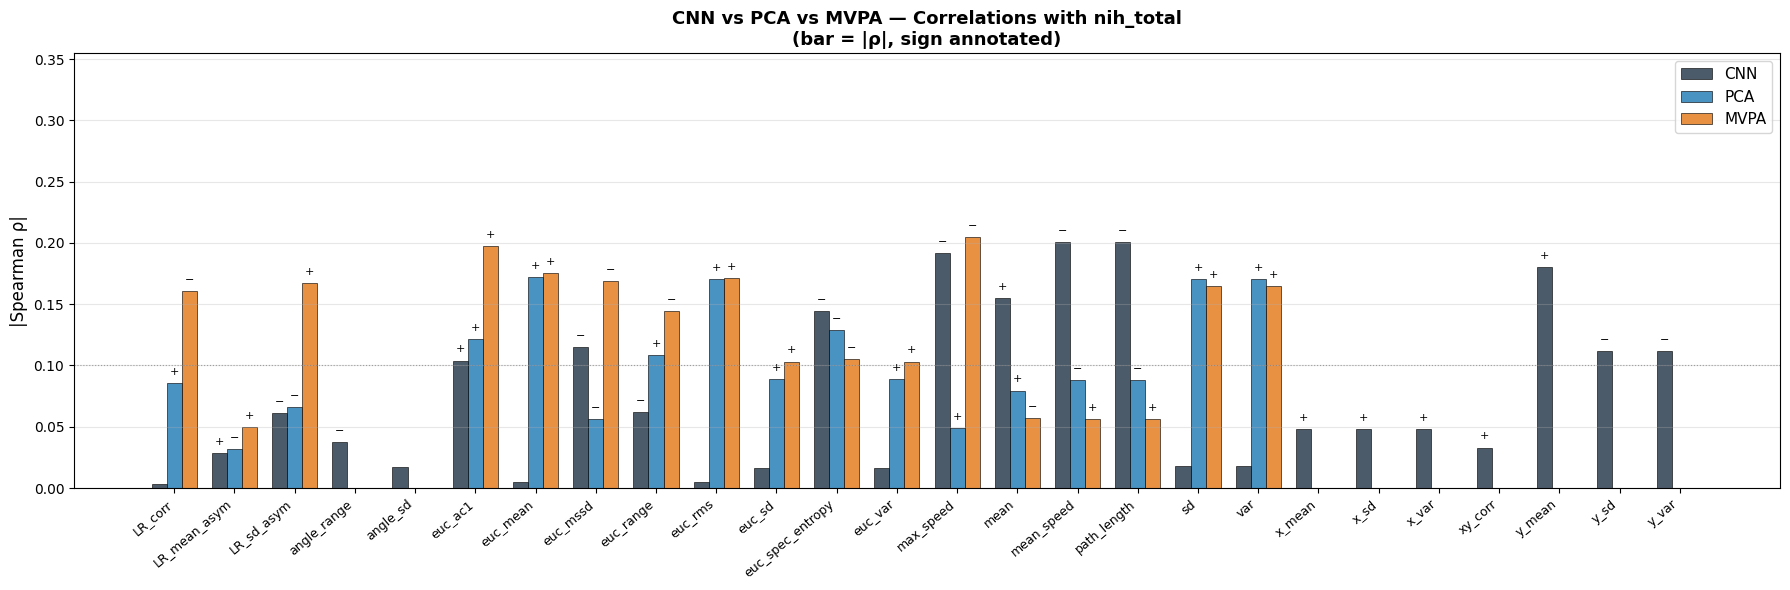

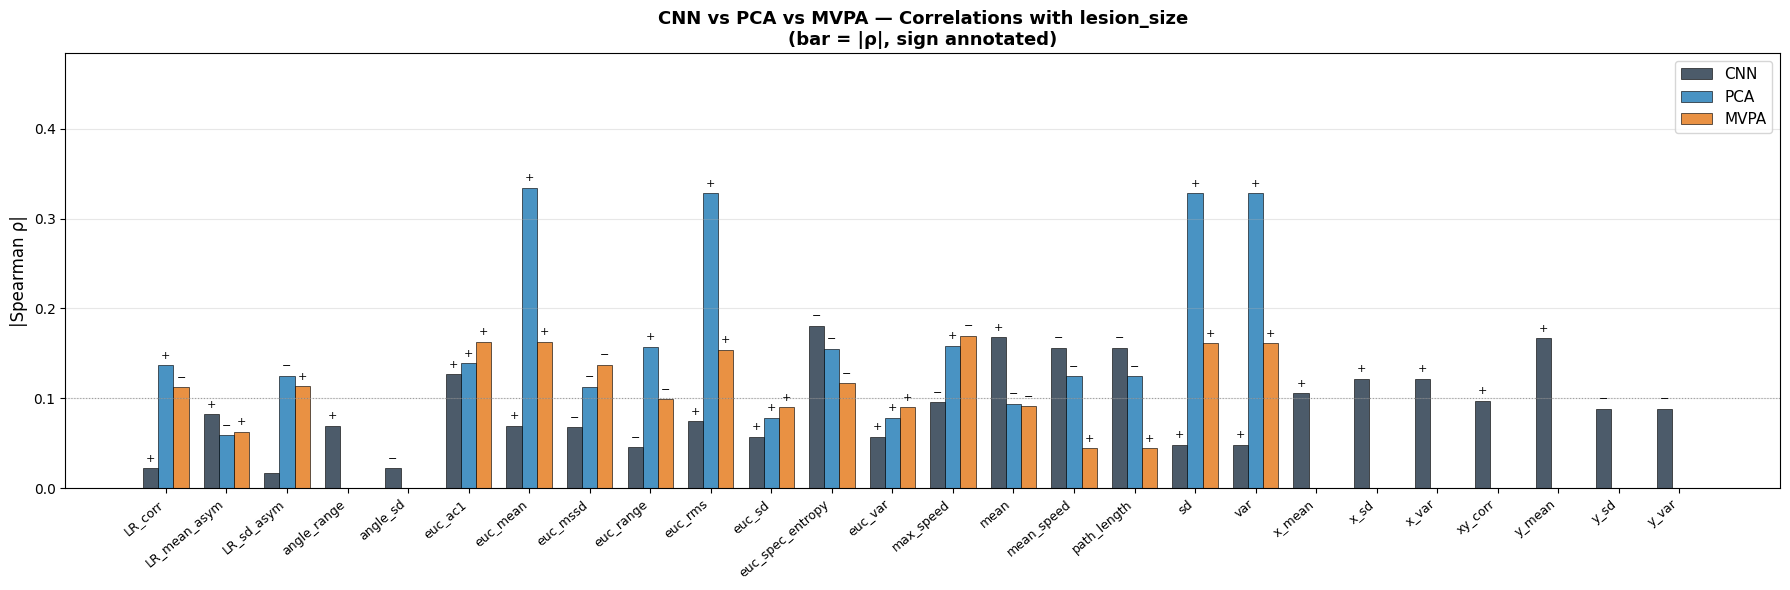

In [17]:
"""
Cell 2: Feature extraction + correlation with lesion_size and nih_total
Requires: qc_df, lr_ts, stroke_csv from Cell 1
"""


# ─────────────────────────────────────────────────────────────────────────────
# HELPERS (updated for raw arrays, not strings)
# ─────────────────────────────────────────────────────────────────────────────
def euc_features(signal, prefix):
    """Euclidean or 1D signal features."""
    s     = np.asarray(signal, dtype=float)
    diffs = np.diff(s)
    f     = {}

    # Central tendency & spread
    f[f'{prefix}_euc_mean']   = np.mean(s)
    f[f'{prefix}_euc_sd']     = np.std(s)
    f[f'{prefix}_euc_var']    = np.var(s)

    # Range & RMS
    f[f'{prefix}_euc_range']  = np.ptp(s)
    f[f'{prefix}_euc_rms']    = np.sqrt(np.mean(s**2))

    # Temporal dynamics
    f[f'{prefix}_euc_mssd']   = np.mean(diffs**2)
    f[f'{prefix}_euc_ac1']    = pd.Series(s).autocorr(lag=1)
    f[f'{prefix}_path_length']= np.sum(np.abs(diffs))
    f[f'{prefix}_mean_speed'] = np.mean(np.abs(diffs))
    f[f'{prefix}_max_speed']  = np.max(np.abs(diffs))

    # Spectral entropy
    fft_mag = np.abs(np.fft.rfft(s - s.mean()))**2
    fft_mag = fft_mag[1:]     # drop DC
    fft_sum = fft_mag.sum()
    if fft_sum > 0:
        p = fft_mag / fft_sum
        p = p[p > 0]
        f[f'{prefix}_euc_spec_entropy'] = -np.sum(p * np.log2(p))
    else:
        f[f'{prefix}_euc_spec_entropy'] = np.nan

    return f


def lr_asym_features(euc_l, euc_r, prefix):
    """
    Simple left–right asymmetry features for 1D euc/ts.
    """
    euc_l = np.asarray(euc_l)
    euc_r = np.asarray(euc_r)
    f = {}
    if len(euc_l) == len(euc_r):
        diff = euc_l - euc_r
        f[f'{prefix}_LR_mean_asym'] = np.mean(diff)
        f[f'{prefix}_LR_sd_asym']   = np.std(diff)
        if np.std(euc_l) > 0 and np.std(euc_r) > 0:
            f[f'{prefix}_LR_corr'], _ = stats.pearsonr(euc_l, euc_r)
        else:
            f[f'{prefix}_LR_corr'] = np.nan
    else:
        f[f'{prefix}_LR_mean_asym'] = np.nan
        f[f'{prefix}_LR_sd_asym']   = np.nan
        f[f'{prefix}_LR_corr']      = np.nan
    return f


def ocular_features_2d(arr_x, arr_y, prefix):
    """2D eye‑movement features from x,y series."""
    arr_x = np.asarray(arr_x, dtype=float)
    arr_y = np.asarray(arr_y, dtype=float)
    euc   = np.sqrt(arr_x**2 + arr_y**2)
    f     = euc_features(euc, prefix)

    step  = np.sqrt(np.diff(arr_x)**2 + np.diff(arr_y)**2)
    f[f'{prefix}_path_length'] = np.sum(step)
    f[f'{prefix}_mean_speed']  = np.mean(step)
    f[f'{prefix}_max_speed']   = np.max(step)

    f[f'{prefix}_x_mean'] = np.mean(arr_x)
    f[f'{prefix}_x_sd']   = np.std(arr_x)
    f[f'{prefix}_x_var']  = np.var(arr_x)
    f[f'{prefix}_y_mean'] = np.mean(arr_y)
    f[f'{prefix}_y_sd']   = np.std(arr_y)
    f[f'{prefix}_y_var']  = np.var(arr_y)

    # overall mean/sd/var across x and y
    xy = np.concatenate([arr_x, arr_y])
    f[f'{prefix}_mean'] = np.mean(xy)
    f[f'{prefix}_sd']   = np.std(xy)
    f[f'{prefix}_var']  = np.var(xy)

    angles = np.arctan2(arr_y, arr_x)
    f[f'{prefix}_angle_sd']    = np.std(angles)
    f[f'{prefix}_angle_range'] = np.ptp(angles)

    if np.std(arr_x) > 0 and np.std(arr_y) > 0:
        f[f'{prefix}_xy_corr'], _ = stats.pearsonr(arr_x, arr_y)
    else:
        f[f'{prefix}_xy_corr'] = np.nan

    return f


# ─────────────────────────────────────────────────────────────────────────────
# CNN FEATURES (from lr_ts with new stroke_predictions)
# ─────────────────────────────────────────────────────────────────────────────
cnn_rows = []
for _, row in lr_ts.iterrows():
    f = {'ID': row['ID'], 'Session': row['Session']}

    # Left‑eye CNN features
    f.update(ocular_features_2d(
        row['pred_x_left'], row['pred_y_left'], 'CNN_L'
    ))

    # Right‑eye CNN features
    f.update(ocular_features_2d(
        row['pred_x_right'], row['pred_y_right'], 'CNN_R'
    ))

    # Average of left/right
    avg_x = (row['pred_x_left'] + row['pred_x_right']) / 2
    avg_y = (row['pred_y_left'] + row['pred_y_right']) / 2
    f.update(ocular_features_2d(avg_x, avg_y, 'CNN_avg'))

    # Euclidean asymmetries (left vs right)
    euc_l = np.sqrt(row['pred_x_left']**2 + row['pred_y_left']**2)
    euc_r = np.sqrt(row['pred_x_right']**2 + row['pred_y_right']**2)
    f.update(lr_asym_features(euc_l, euc_r, 'CNN'))

    cnn_rows.append(f)

cnn_feats_df = pd.DataFrame(cnn_rows)
print(f"CNN features : {len([c for c in cnn_feats_df.columns if c not in ['ID','Session']])}")


# ─────────────────────────────────────────────────────────────────────────────
# PCA / MVPA FEATURES (now using stroke_csv with raw arrays, not strings)
# ─────────────────────────────────────────────────────────────────────────────
def flatten_array(v):
    """Ensure 1D array; handle NaN."""
    if v is None:
        return None
    if isinstance(v, float) and np.isnan(v):
        return None
    try:
        arr = np.asarray(v, dtype=float).ravel()
        return arr if len(arr) >= 3 else None
    except Exception:
        return None

linear_rows = []
for _, row in stroke_csv.iterrows():
    f = {'ID': row['ID'], 'Session': row['Session']}

    for method in ['PCA', 'MVPA']:
        l_arr = flatten_array(row.get(f'{method}_left'))
        r_arr = flatten_array(row.get(f'{method}_right'))

        for side, arr in [('L', l_arr), ('R', r_arr)]:
            if arr is not None and len(arr) >= 3:
                abs_arr = np.abs(arr)
                f.update(euc_features(abs_arr, f'{method}_{side}'))
                # also raw mean/sd/var on signed signal
                f[f'{method}_{side}_mean'] = np.mean(arr)
                f[f'{method}_{side}_sd']   = np.std(arr)
                f[f'{method}_{side}_var']  = np.var(arr)

        if l_arr is not None and r_arr is not None and len(l_arr) == len(r_arr):
            f.update(lr_asym_features(np.abs(l_arr), np.abs(r_arr), method))

        # MVPA vs PCA correlation (within‑eye)
        if method == 'MVPA':
            pca_l = flatten_array(row.get('PCA_left'))
            pca_r = flatten_array(row.get('PCA_right'))
            if (pca_l is not None and l_arr is not None and
                    len(pca_l) == len(l_arr) and np.std(pca_l) > 0 and np.std(l_arr) > 0):
                f['corr_PCA_MVPA_L'], _ = stats.pearsonr(pca_l, l_arr)
            if (pca_r is not None and r_arr is not None and
                    len(pca_r) == len(r_arr) and np.std(pca_r) > 0 and np.std(r_arr) > 0):
                f['corr_PCA_MVPA_R'], _ = stats.pearsonr(pca_r, r_arr)

    linear_rows.append(f)

linear_feats_df = pd.DataFrame(linear_rows)
print(f"Linear features : {len([c for c in linear_feats_df.columns if c not in ['ID','Session']])}")


# ─────────────────────────────────────────────────────────────────────────────
# MASTER TABLE (QC‑passed sessions only)
# ─────────────────────────────────────────────────────────────────────────────
all_feats_df = cnn_feats_df.merge(linear_feats_df, on=['ID', 'Session'], how='outer')
all_feats_df = all_feats_df.merge(
    stroke_csv[['ID', 'Session', 'nih_total', 'lesion_size']],
    on=['ID', 'Session'], how='left')
all_feats_df = all_feats_df.merge(
    qc_df[['ID', 'Session', 'qc_pass']], on=['ID', 'Session'], how='left')
all_feats_df = all_feats_df[all_feats_df['qc_pass'] == True].drop(columns='qc_pass')

print(f"\nMaster table (QC‑passed): {all_feats_df.shape[0]} rows × "
      f"{all_feats_df.shape[1]} cols")


# ─────────────────────────────────────────────────────────────────────────────
# CORRELATIONS WITH OUTCOMES
# ─────────────────────────────────────────────────────────────────────────────
outcome_vars = ['nih_total', 'lesion_size']
feature_cols = [c for c in all_feats_df.columns
                if c not in ['ID', 'Session'] + outcome_vars]

corr_rows = []
for outcome in outcome_vars:
    valid_out = all_feats_df[outcome].notna()
    for feat in feature_cols:
        valid = all_feats_df[valid_out & all_feats_df[feat].notna()]
        if len(valid) < 5:
            continue
        r,   p_r   = stats.pearsonr(valid[outcome],  valid[feat])
        rho, p_rho = stats.spearmanr(valid[outcome], valid[feat])
        corr_rows.append({
            'Outcome': outcome,
            'Feature': feat,
            'N': len(valid),
            'r': r, 'p_r': p_r,
            'rho': rho, 'p_rho': p_rho,
            'abs_rho': abs(rho)
        })

corr_df = pd.DataFrame(corr_rows)

def tag_method(feat):
    if feat.startswith('CNN'):   return 'CNN'
    if feat.startswith('PCA'):   return 'PCA'
    if feat.startswith('MVPA'):  return 'MVPA'
    if feat.startswith('corr_'): return 'Cross'
    return 'Other'

def tag_base(feat):
    suffixes = [
        '_euc_mean', '_euc_sd', '_euc_var', '_euc_range', '_euc_rms',
        '_euc_mssd', '_euc_ac1', '_euc_spec_entropy',
        '_path_length', '_mean_speed', '_max_speed',
        '_angle_sd', '_angle_range', '_xy_corr',
        '_LR_sd_asym', '_LR_mean_asym', '_LR_corr',
        '_x_mean', '_x_sd', '_x_var',
        '_y_mean', '_y_sd', '_y_var',
        '_mean', '_sd', '_var'
    ]
    for suffix in suffixes:
        if feat.endswith(suffix):
            return suffix.lstrip('_')
    return feat

corr_df['Method'] = corr_df['Feature'].apply(tag_method)
corr_df['Base']   = corr_df['Feature'].apply(tag_base)

print("\n" + "=" * 70)
print("TOP 15 FEATURES PER OUTCOME  (|Spearman ρ|)")
print("=" * 70)
for outcome in outcome_vars:
    sub = corr_df[corr_df['Outcome'] == outcome].sort_values('abs_rho', ascending=False)
    print(f"\n  {outcome}:")
    print(sub[['Feature', 'Method', 'N', 'r', 'p_r',
               'rho', 'p_rho']].head(15).to_string(index=False))


# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1: Bar chart — |ρ| per feature type per method
# ─────────────────────────────────────────────────────────────────────────────
method_colors = {'CNN': '#2c3e50', 'PCA': '#2980b9', 'MVPA': '#e67e22'}

for outcome in outcome_vars:
    sub  = corr_df[(corr_df['Outcome'] == outcome) &
                   corr_df['Method'].isin(['CNN', 'PCA', 'MVPA'])].copy()
    best = (sub.groupby(['Method', 'Base'])
               .apply(lambda g: g.loc[g['abs_rho'].idxmax()])
               .reset_index(drop=True))
    bases   = sorted(best['Base'].unique())
    x       = np.arange(len(bases))
    width   = 0.25
    fig, ax = plt.subplots(figsize=(18, 6))
    for i, method in enumerate(['CNN', 'PCA', 'MVPA']):
        m_data   = best[best['Method'] == method].set_index('Base')
        rho_vals = [m_data.loc[b, 'rho'] if b in m_data.index else np.nan for b in bases]
        abs_vals = [abs(v) if not np.isnan(v) else 0.0 for v in rho_vals]
        bars     = ax.bar(x + i * width, abs_vals, width, label=method,
                          color=method_colors[method], edgecolor='black',
                          linewidth=0.5, alpha=0.85)
        for bar, rho in zip(bars, rho_vals):
            if not np.isnan(rho) and abs(rho) > 0.02:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.005,
                        '+' if rho > 0 else '−',
                        ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x + width)
    ax.set_xticklabels(bases, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('|Spearman ρ|', fontsize=12)
    ax.set_title(f'CNN vs PCA vs MVPA — Correlations with {outcome}\n'
                 f'(bar = |ρ|, sign annotated)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.set_ylim(0, min(1.0, best['abs_rho'].max() + 0.15))
    ax.axhline(0.1, color='gray', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()




In [6]:
import os
import glob
import numpy as np
import tensorflow as tf
from scipy.stats import pearsonr
from collections import defaultdict
import pickle

# -------- CONFIG --------
model_path  = "/mnt/compneuro/deepmreye_finetuning/two_stream_deepmreye.h5"
stroke_root = "/mnt/compneuro/deepmreye_finetuning/stroke_nifti/"

# ---------- Load model ----------
inference_model = tf.keras.models.load_model(model_path, compile=False)
print("Model loaded successfully.")

# ---------- 1A. Bottleneck sub-models ----------
try:
    bottleneck_right = tf.keras.Model(
        inputs  = inference_model.input,
        outputs = inference_model.get_layer('dense_b_right').output      # (T, 1024)
    )
    bottleneck_left = tf.keras.Model(
        inputs  = inference_model.input,
        outputs = inference_model.get_layer('dense_b_left').output       # (T, 1024)
    )
    bottleneck_combined = tf.keras.Model(                                # ← NEW
        inputs  = inference_model.input,
        outputs = inference_model.get_layer('combined_features').output  # (T, 6144)
    )
except ValueError as e:
    raise ValueError(
        "Pick appropriate bottleneck layers from your model, e.g.:\n"
        f"Existing layers: {list(l.name for l in inference_model.layers)}."
    ) from e

print("Bottleneck models created (right, left, combined).")

# ---------- 1. Collect files ----------
both_files = sorted(glob.glob(
    os.path.join(stroke_root, "**", "*run-0_bold_both.npz"),
    recursive=True
))
print(f"\nFound {len(both_files)} _both.npz files:")
for f in both_files:
    print(" ", os.path.basename(f))

# ---------- 2. Data loader ----------
def load_stroke_both_npz(fp):
    d = np.load(fp)
    data_keys = sorted(
        [k for k in d.keys() if k.startswith('data_')],
        key=lambda k: int(k.split('_')[1])
    )
    right_list, left_list = [], []
    for dk in data_keys:
        tr = d[dk]
        right_list.append(tr[1:24,  :, :][..., np.newaxis].astype(np.float32))
        left_list.append( tr[24:47, :, :][..., np.newaxis].astype(np.float32))
    return (np.array(right_list, dtype=np.float32),
            np.array(left_list,  dtype=np.float32))

# ---------- 3. Global storage ----------
stroke_bottleneck = {}

all_pred_right   = []
all_pred_left    = []
per_file_results = []

print(f"\n{'File':45s} | {'N':>5}")
print("-" * 55)

for fp in both_files:
    basename = os.path.basename(fp)
    rights, lefts = load_stroke_both_npz(fp)
    T = rights.shape[0]
    if T == 0:
        print(f"  Skipping (no valid TRs): {basename}")
        continue

    # --- Bottleneck features ---
    b_right    = bottleneck_right.predict([rights, lefts],    verbose=0)  # (T, 1024)
    b_left     = bottleneck_left.predict([rights, lefts],     verbose=0)  # (T, 1024)
    b_combined = bottleneck_combined.predict([rights, lefts], verbose=0)  # (T, 6144) ← NEW

    # --- Full predictions ---
    preds           = inference_model.predict([rights, lefts], verbose=0)
    gaze_right_pred = preds[0]   # (T, 2)
    gaze_left_pred  = preds[1]   # (T, 2)

    # --- Store bundle ---
    stroke_bottleneck[basename] = {
        'bottleneck_right':    b_right,            # (T, 1024)
        'bottleneck_left':     b_left,             # (T, 1024)
        'bottleneck_combined': b_combined,         # (T, 6144) ← NEW
        'T':                   T,
        'pred_x_right':        gaze_right_pred[:, 0],
        'pred_y_right':        gaze_right_pred[:, 1],
        'pred_x_left':         gaze_left_pred[:, 0],
        'pred_y_left':         gaze_left_pred[:, 1],
    }

    all_pred_right.append(gaze_right_pred)
    all_pred_left.append(gaze_left_pred)

    if T > 2:
        rX_RL, _ = pearsonr(gaze_right_pred[:, 0], gaze_left_pred[:, 0])
        rY_RL, _ = pearsonr(gaze_right_pred[:, 1], gaze_left_pred[:, 1])
    else:
        rX_RL = rY_RL = np.nan

    per_file_results.append({'file': basename, 'N': T, 'rX_RL': rX_RL, 'rY_RL': rY_RL})
    print(f"{basename:45s} | {T:5d}")

# ---------- 4. Aggregate ----------
all_pred_right = np.concatenate(all_pred_right, axis=0)
all_pred_left  = np.concatenate(all_pred_left,  axis=0)

rX_RL_agg, _ = pearsonr(all_pred_right[:, 0], all_pred_left[:, 0])
rY_RL_agg, _ = pearsonr(all_pred_right[:, 1], all_pred_left[:, 1])

print("\n========= AGGREGATE SUMMARY (stroke, both eyes) =========")
print(f"Total test TRs: {len(all_pred_right)}")
print(f"\n--- Right vs Left eye prediction consistency ---")
print(f"{'Pearson r (X: right pred vs left pred)':45s} {rX_RL_agg:12.3f}")
print(f"{'Pearson r (Y: right pred vs left pred)':45s} {rY_RL_agg:12.3f}")

# ---------- 5. Per-file results ----------
per_file_results_sorted = sorted(per_file_results, key=lambda x: x.get('rX_RL', -np.inf), reverse=True)
print("\n========= PER-FILE RESULTS (sorted by rX_RL) =========")
print(f"{'File':45s} | {'N':>5} | {'rX_RL':>8} | {'rY_RL':>8}")
print("-" * 75)
for r in per_file_results_sorted:
    print(f"{r['file']:45s} | {r['N']:5d} | {r['rX_RL']:8.3f} | {r['rY_RL']:8.3f}")

# ---------- 6. Save ----------
save_path_bneck = "/mnt/compneuro/deepmreye_finetuning/stroke_bottleneck.pkl"
with open(save_path_bneck, "wb") as f:
    pickle.dump(stroke_bottleneck, f)
print(f"\nSaved stroke_bottleneck to:\n  {save_path_bneck}")

# Backward-compatible predictions-only file
save_path_pred = "/mnt/compneuro/deepmreye_finetuning/stroke_predictions.pkl"
stroke_predictions = {
    basename: {k: d[k] for k in ['pred_x_right', 'pred_y_right', 'pred_x_left', 'pred_y_left', 'T']}
    for basename, d in stroke_bottleneck.items()
}
with open(save_path_pred, "wb") as f:
    pickle.dump(stroke_predictions, f)
print(f"Also saved stroke_predictions (back compat) to:\n  {save_path_pred}")

Model loaded successfully.
Bottleneck models created (right, left, combined).

Found 418 _both.npz files:
  sub-CON001_ses-control_task-rest_run-0_bold_both.npz
  sub-CON002_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON002_ses-control_task-rest_run-0_bold_both.npz
  sub-CON003_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON003_ses-control_task-rest_run-0_bold_both.npz
  sub-CON004_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON005_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON005_ses-control_task-rest_run-0_bold_both.npz
  sub-CON006_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON006_ses-control_task-rest_run-0_bold_both.npz
  sub-CON007_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON007_ses-control_task-rest_run-0_bold_both.npz
  sub-CON008_ses-control_task-rest_run-0_bold_both.npz
  sub-CON009_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON009_ses-control_task-rest_run-0_bold_both.npz
  sub-CON010_ses-control2_task-rest_run-0_bold_both.npz
  sub-

In [7]:
import pickle
import numpy as np

# ---------- Load ----------
load_path = "/mnt/compneuro/deepmreye_finetuning/stroke_bottleneck.pkl"
with open(load_path, "rb") as f:
    stroke_bottleneck = pickle.load(f)

# ---------- Top-level overview ----------
print(f"Number of files stored: {len(stroke_bottleneck)}\n")

# ---------- Per-file table ----------
print(f"{'File':50s} | {'T':>5} | {'b_right':>12} | {'b_left':>12} | {'b_comb':>12}")
print("-" * 100)

for basename, bundle in sorted(stroke_bottleneck.items()):
    T  = bundle['T']
    br = bundle['bottleneck_right'].shape
    bl = bundle['bottleneck_left'].shape
    bc = bundle.get('bottleneck_combined', np.array([])).shape  # safe if old pkl lacks this key
    print(f"{basename:50s} | {T:5d} | {str(br):>12} | {str(bl):>12} | {str(bc):>12}")

# ---------- Detailed inspection of first file ----------
first_key = sorted(stroke_bottleneck.keys())[0]
bundle    = stroke_bottleneck[first_key]

print(f"\n--- Keys in each bundle (example: {first_key}) ---")
for key, val in bundle.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s}: shape={val.shape}, dtype={val.dtype}, "
              f"min={val.min():.4f}, max={val.max():.4f}, mean={val.mean():.4f}")
    else:
        print(f"  {key:25s}: {val}")

Number of files stored: 418

File                                               |     T |      b_right |       b_left |       b_comb
----------------------------------------------------------------------------------------------------
sub-CON001_ses-control_task-rest_run-0_bold_both.npz |   128 |  (128, 1024) |  (128, 1024) |  (128, 6144)
sub-CON002_ses-control2_task-rest_run-0_bold_both.npz |   128 |  (128, 1024) |  (128, 1024) |  (128, 6144)
sub-CON002_ses-control_task-rest_run-0_bold_both.npz |   128 |  (128, 1024) |  (128, 1024) |  (128, 6144)
sub-CON003_ses-control2_task-rest_run-0_bold_both.npz |   128 |  (128, 1024) |  (128, 1024) |  (128, 6144)
sub-CON003_ses-control_task-rest_run-0_bold_both.npz |   128 |  (128, 1024) |  (128, 1024) |  (128, 6144)
sub-CON004_ses-control2_task-rest_run-0_bold_both.npz |   128 |  (128, 1024) |  (128, 1024) |  (128, 6144)
sub-CON005_ses-control2_task-rest_run-0_bold_both.npz |   128 |  (128, 1024) |  (128, 1024) |  (128, 6144)
sub-CON005_ses-contr

stroke_predictions: 418 runs
stroke_csv:         (386, 620)
evaluation_right: 418 keys
evaluation_left : 418  keys
lr_ts: 418 paired sessions, 190 subjects
qc_df: 418 sessions  |  QC pass: 233
CNN features    : 72
Linear features : 64
Master table (QC-passed): 233 rows × 140 cols
recovery_df: 62 subjects  |  nih_delta N=52
NIHSS hospital median: 5.0
Enriched rdf: (62, 570),  nih_delta N=52


STEP 0 — Bottleneck PCA
Fitting PCA (target: 95% variance):
  C  (c_mean+c_std)           : 230 PCs → 94.9% variance (PC1=11.5%)
Combined block: n_C=230
bn_acute: 153 rows  |  BN columns: 230
Feature counts: MVPA=37  PCA=37  BN=230

STEP 1 — Build lr_ts, qc_df, features, recovery_df, rdf
stroke_predictions: 418 runs
stroke_csv:         (386, 620)
lr_ts: 418 sessions, 190 subjects
qc_df: 418 sessions  |  QC pass: 233
CNN features    : 72
Linear features : 64
Master table (QC-passed): 233 rows × 140 cols
recovery_df: 62 subjects  |  nih_delta N=52
NIHSS hospital median: 5.0
BN_C_ columns in rdf: 230  |  rows with data: 62
Enriched rdf: (62, 402),  nih_delta N=52

STEP 3 — Subgroup correlations
Result table: 2920 rows
Methods present: ['MVPA', 'PCA', 'BN']
Eyes present:    ['Left eye', 'Right eye', 'LR asym', 'Combined']

FDR-SIGNIFICANT RESULTS  (p_fdr < 0.05)


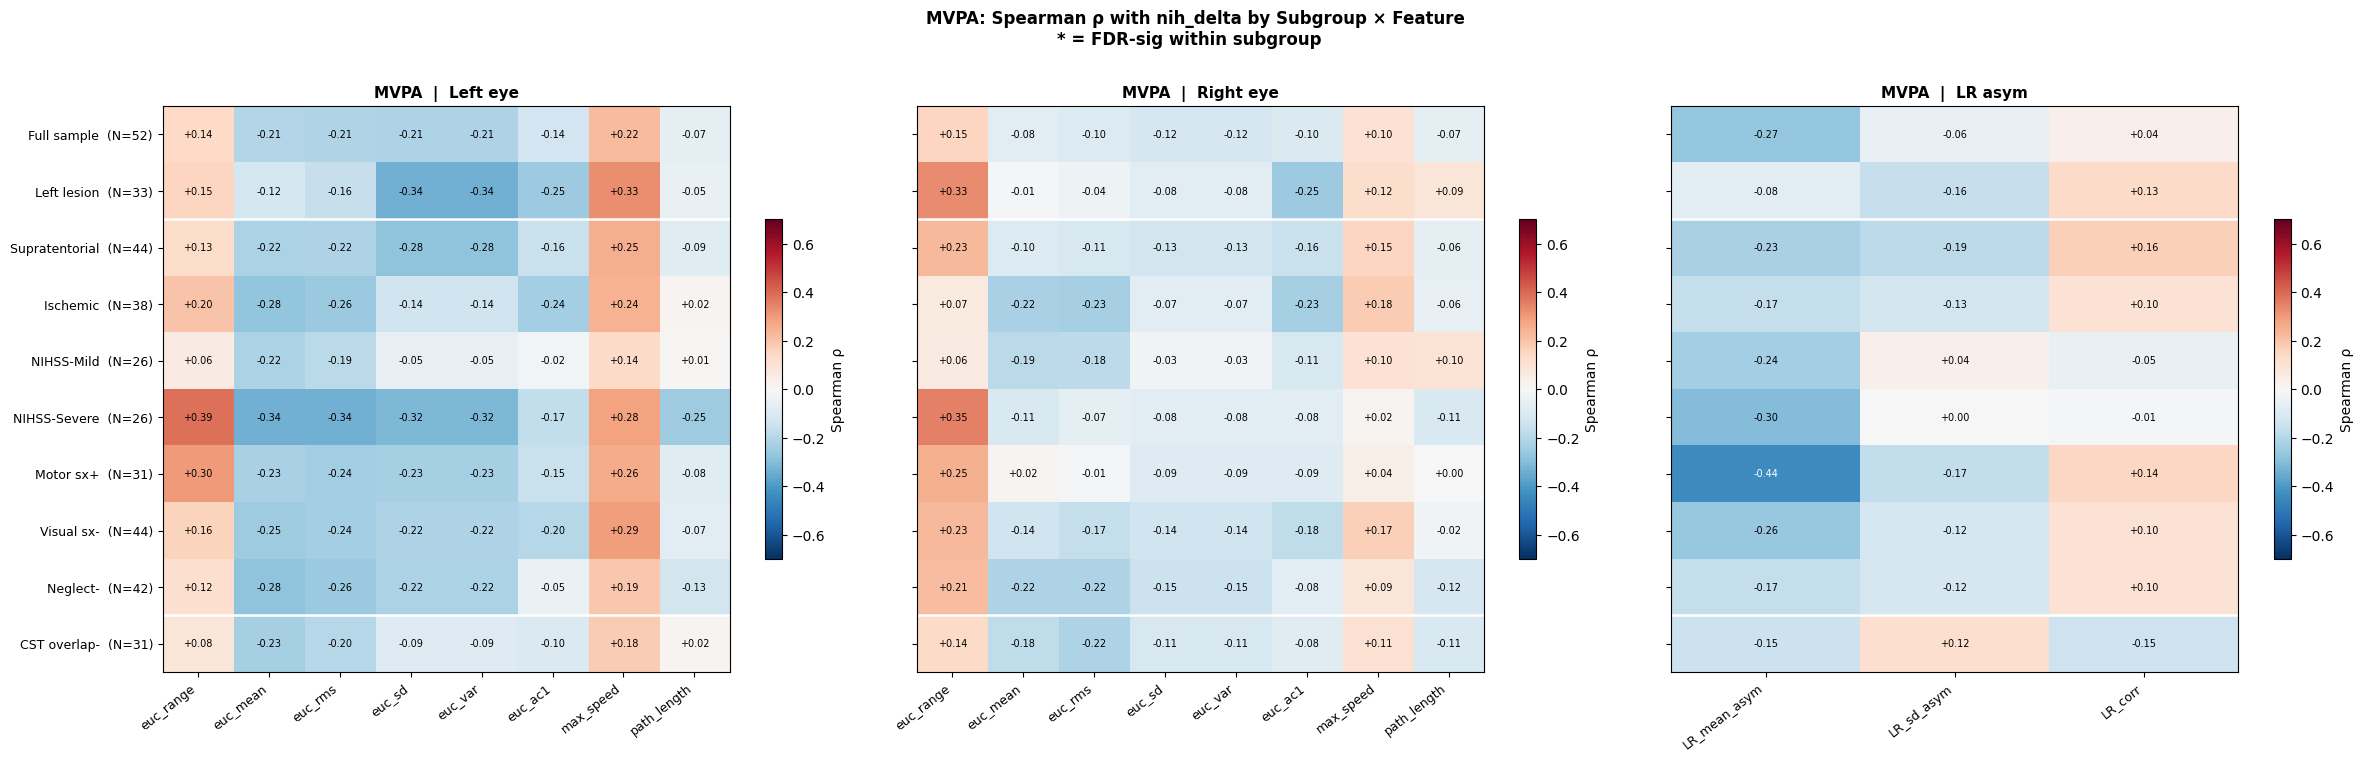

Saved: output/heatmap_MVPA_nih_delta.png


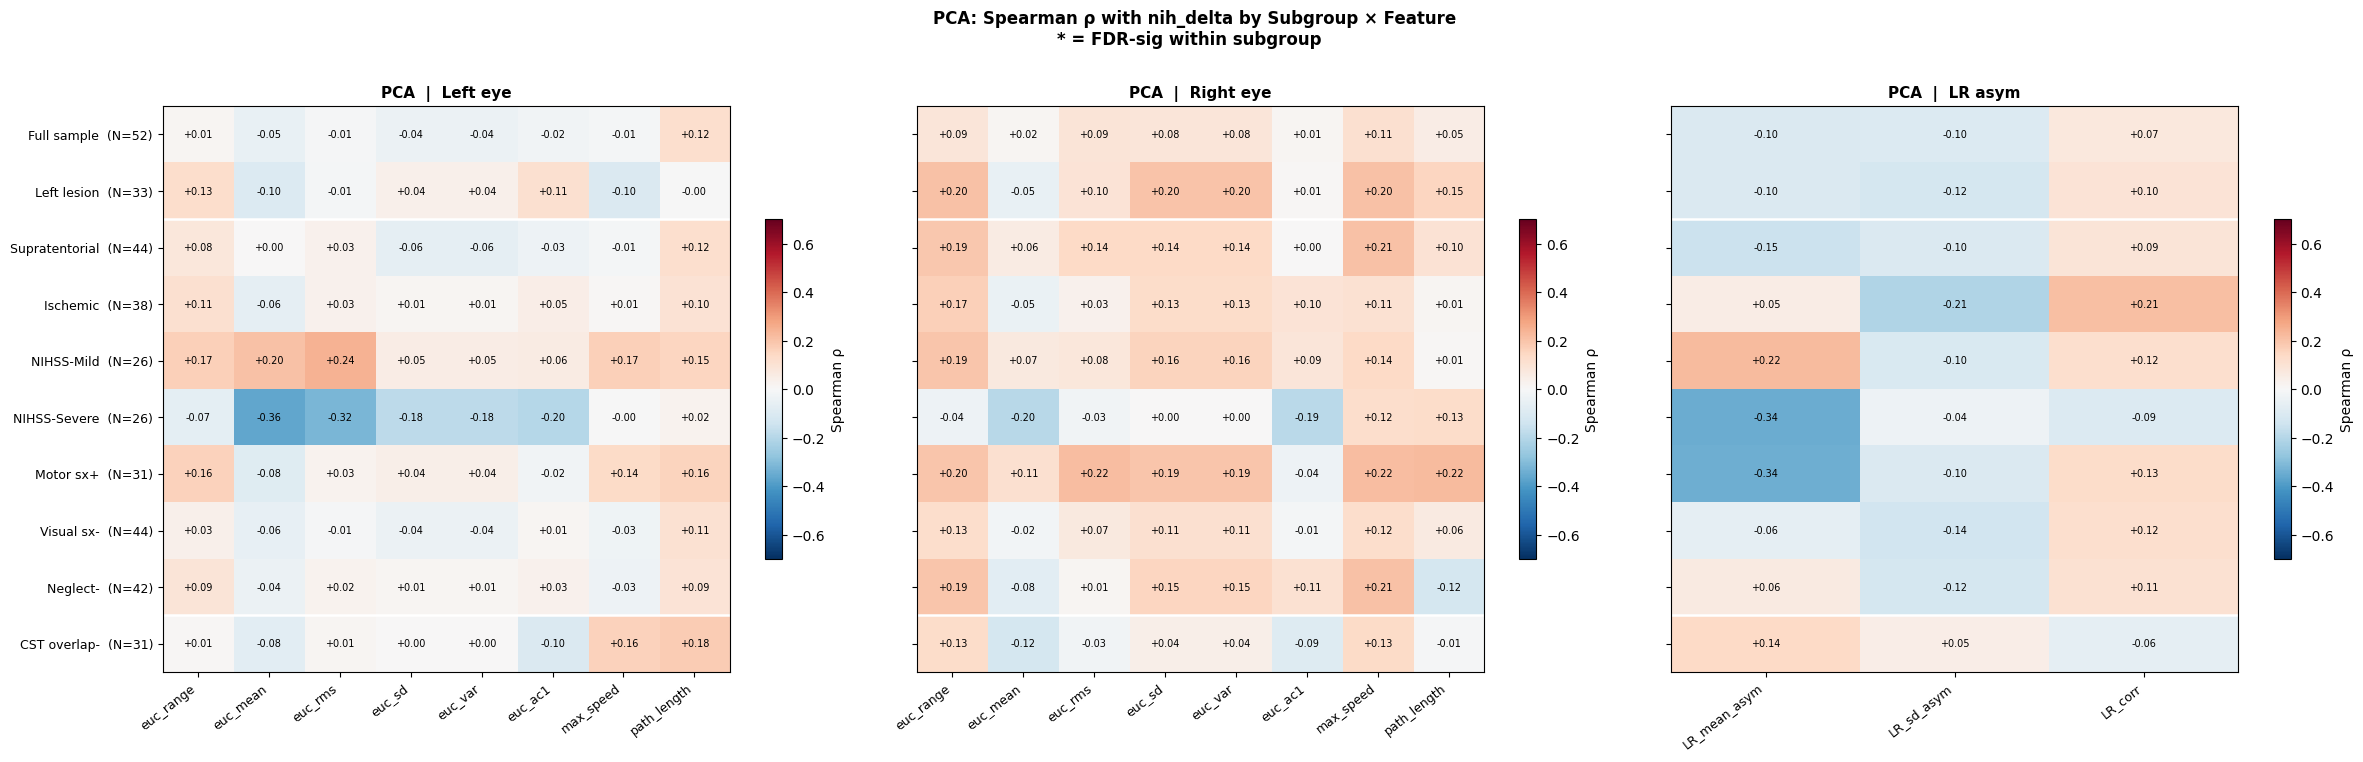

Saved: output/heatmap_PCA_nih_delta.png


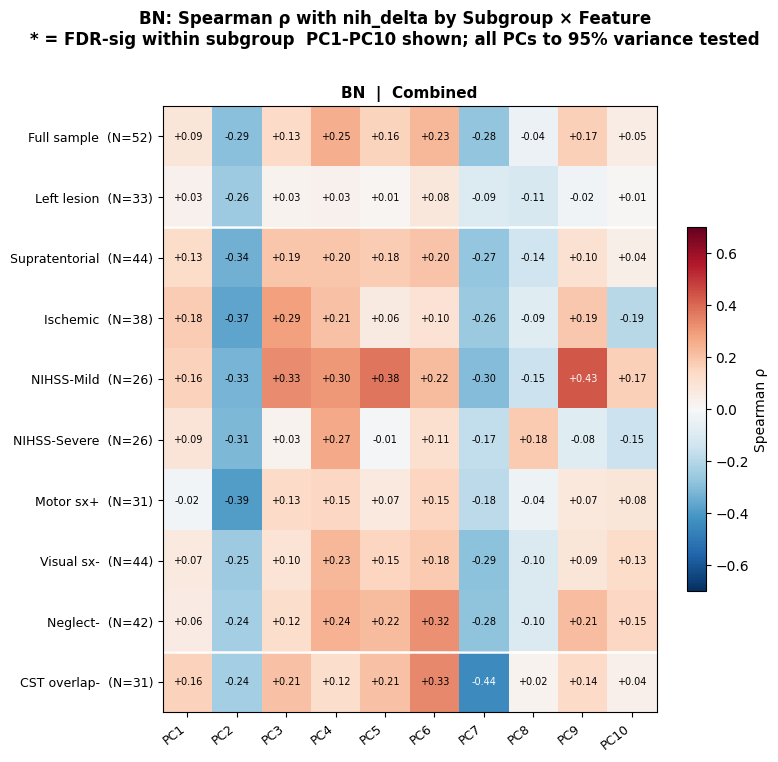

Saved: output/heatmap_BN_nih_delta.png

Best BN feature (combined): BN_C_PC166


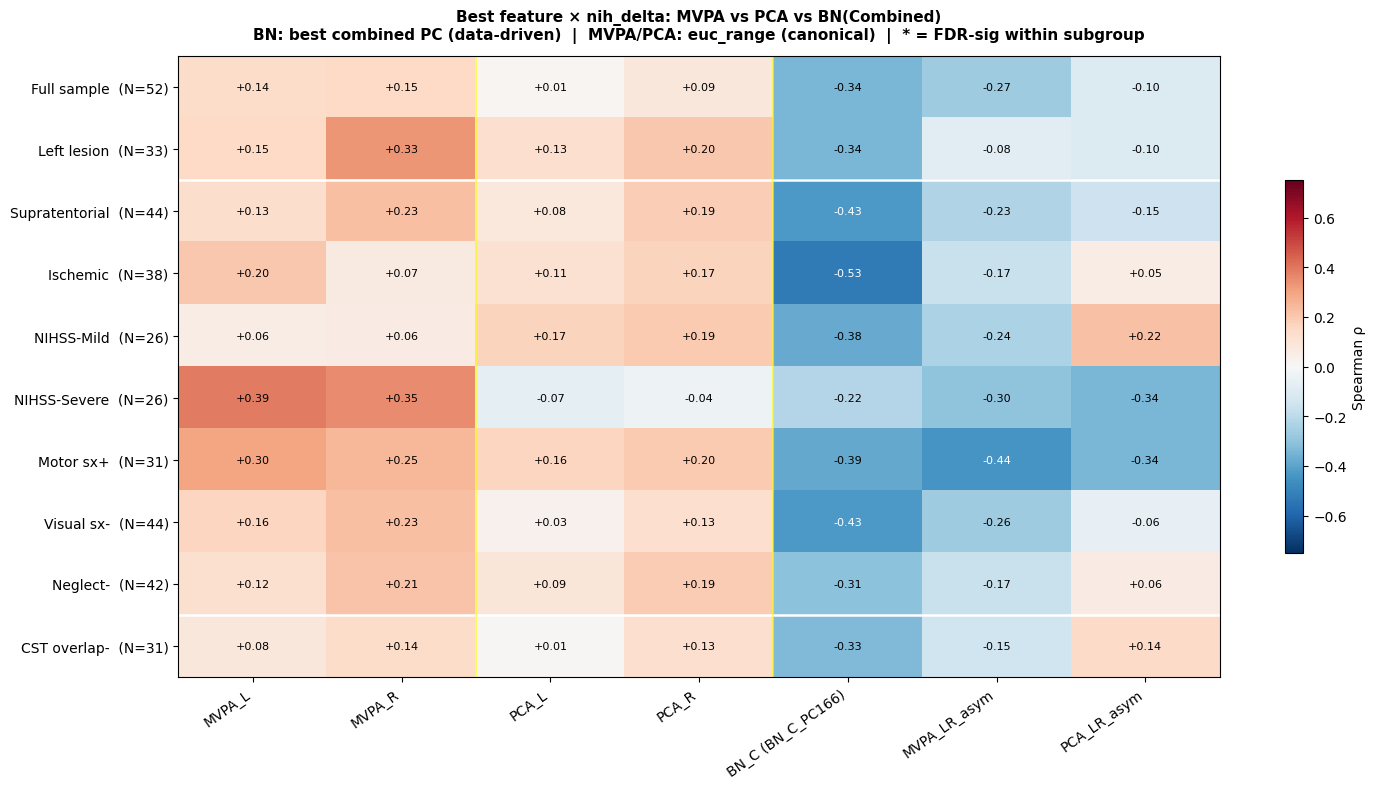

Saved: output/cross_method_heatmap.png


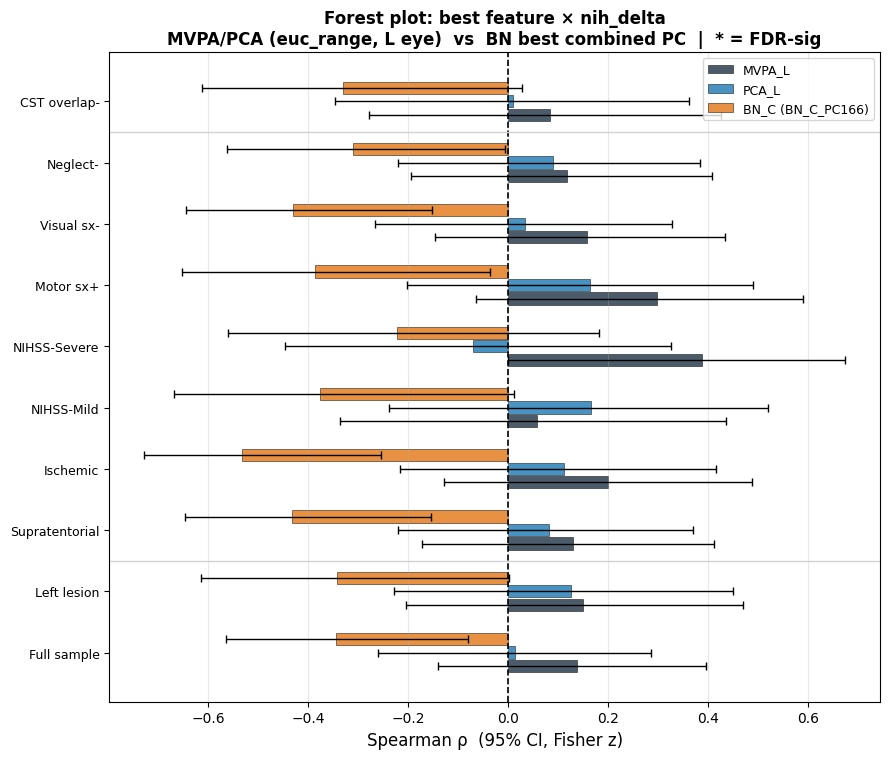

Saved: output/forest_3methods.png

IPSILESIONAL vs CONTRALESIONAL  (MVPA/PCA only)
  MVPA_euc_mean             contra    rho=-0.134  p=0.3441  p_fdr=0.9176     N=52
  MVPA_euc_mean             ipsi      rho=-0.135  p=0.3417  p_fdr=0.9176     N=52
  MVPA_euc_range            contra    rho=+0.232  p=0.0983  p_fdr=0.7868     N=52
  MVPA_euc_range            ipsi      rho=+0.037  p=0.7929  p_fdr=0.9237     N=52
  PCA_euc_mean              contra    rho=-0.014  p=0.9237  p_fdr=0.9237     N=52
  PCA_euc_mean              ipsi      rho=-0.023  p=0.8736  p_fdr=0.9237     N=52
  PCA_euc_range             contra    rho=+0.097  p=0.4951  p_fdr=0.9237     N=52
  PCA_euc_range             ipsi      rho=+0.030  p=0.8341  p_fdr=0.9237     N=52


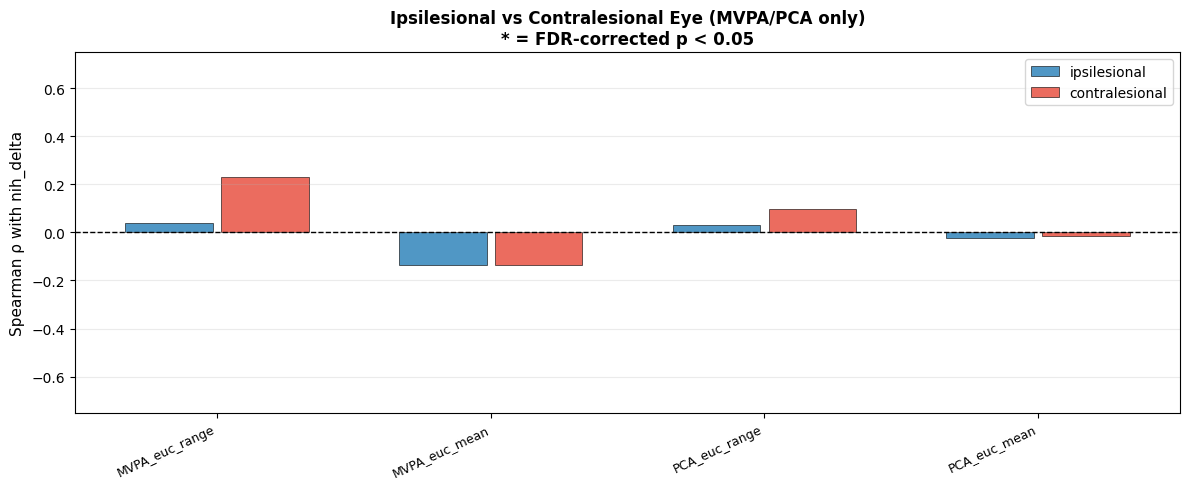

Saved: output/lateralization_ipsi_contra.png

Interaction model covariates: ['nihss_num', 'lesion_size_x', 'age', 'gender']

INTERACTION TESTS: feat_z × lesion_side → nih_delta

  MVPA_L_euc_range                        N=36
    [feat_z:C(side_c)[T.1.0]]: coef=-0.753  p=0.4388
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -1.5228      1.756     -0.867      0.393      -5.119       2.074
C(side_c)[T.1.0]            0.7496      0.682      1.099      0.281      -0.648       2.147
feat_z                      0.9974      0.347      2.872      0.008       0.286       1.709
feat_z:C(side_c)[T.1.0]    -0.7530      0.959     -0.785      0.439      -2.717       1.211
nihss_num                  -0.1752      0.089     -1.959      0.060      -0.358       0.008
lesion_size_x           -5.997e-05      0.000     -0.448      0.658      -0.00

In [24]:
# =============================================================================
# FULL PIPELINE — Steps 0–10 (single cell, kernel-restart safe)
# =============================================================================
import os, re, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
from statsmodels.formula.api import ols
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
warnings.filterwarnings("ignore")
os.makedirs("output", exist_ok=True)

# =============================================================================
# CONFIG
# =============================================================================
BOTTLENECK_PATH = "/mnt/compneuro/deepmreye_finetuning/stroke_bottleneck.pkl"
PRED_PATH       = "/mnt/compneuro/deepmreye_finetuning/stroke_predictions.pkl"
CSV_PATH        = "/mnt/compneuro/stroke_clinical_and_neural_data_with_lesion_disconnectome.pkl"
OUTCOME         = "nih_delta"
MIN_N_SUBGRP    = 25
ALPHA_FDR       = 0.05
VAR_THRESHOLD   = 0.95
QC_THRESHOLD    = 0.2

SUFFIXES = [
    "euc_range", "euc_mean", "euc_rms", "euc_sd", "euc_var",
    "euc_ac1",   "euc_mssd", "euc_spec_entropy",
    "max_speed", "mean_speed", "path_length",
    "sd", "var", "mean",
    "LR_mean_asym", "LR_sd_asym", "LR_corr",
]
SITE_LABELS = {
    0:"Subcortical", 1:"Cortical", 2:"Cortico-sub",
    3:"WM only",     4:"Brainstem", 5:"Cerebellar", 6:"Other"
}
SG_ORDER = [
    "Full sample",
    "Left lesion", "Right lesion",
    "Subcortical", "Cortical", "Cortico-sub", "WM only", "Brainstem", "Cerebellar",
    "Supratentorial", "Infratentorial",
    "Ischemic", "Hemorrhagic",
    "NIHSS-Mild", "NIHSS-Severe",
    "Motor sx+", "Motor sx-",
    "Visual sx+", "Visual sx-",
    "Neglect+", "Neglect-",
    "CST overlap+", "CST overlap-",
]
METHODS = ["MVPA", "PCA", "BN"]

# =============================================================================
# STEP 0 — BN PCA (combined bottleneck)
# =============================================================================
print("=" * 60)
print("STEP 0 — Bottleneck PCA")
print("=" * 60)

with open(BOTTLENECK_PATH, "rb") as f:
    bn_raw = pickle.load(f)

def parse_bn_key(key):
    id_m  = re.search(r'sub-([A-Za-z0-9]+)', key)
    ses_m = re.search(r'ses-([^_]+)', key)
    return (id_m.group(1) if id_m else None,
            ses_m.group(1) if ses_m else None)

bn_rows = []
for key, val in bn_raw.items():
    ID, session = parse_bn_key(key)
    if ID is None or session is None: continue
    try:
        bn_c = np.array(val["bottleneck_combined"], dtype=np.float32)
    except Exception: continue
    if bn_c.ndim == 1: bn_c = bn_c[np.newaxis, :]
    bn_rows.append({
        "ID": ID, "Session": session,
        "c_mean": bn_c.mean(0),
        "c_std":  bn_c.std(0),
    })
bn_df = pd.DataFrame(bn_rows)

X_C_all = np.stack([
    np.concatenate([r["c_mean"], r["c_std"]])
    for _, r in bn_df.iterrows()
]).astype(np.float32)

def fit_pca_adaptive(X_block, var_threshold, block_name, max_pcs=None):
    N = X_block.shape[0]
    max_pcs = min(max_pcs or N-1, N-1, X_block.shape[1])
    X_imp = SimpleImputer(strategy="median").fit_transform(X_block)
    X_sc  = StandardScaler().fit_transform(X_imp)
    pca_full = PCA(n_components=max_pcs).fit(X_sc)
    cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
    n_needed = int(np.searchsorted(cumvar, var_threshold)) + 1
    n_needed = min(n_needed, max_pcs)
    pca_final = PCA(n_components=n_needed).fit(X_sc)
    scores    = pca_final.transform(X_sc)
    final_var = np.sum(pca_final.explained_variance_ratio_)
    print(f"  {block_name:<28}: {n_needed:3d} PCs → {final_var*100:.1f}% variance "
          f"(PC1={pca_final.explained_variance_ratio_[0]*100:.1f}%)")
    return scores, pca_final, n_needed

print(f"Fitting PCA (target: {VAR_THRESHOLD*100:.0f}% variance):")
scores_C, pca_C, n_C = fit_pca_adaptive(X_C_all, VAR_THRESHOLD, "C  (c_mean+c_std)")
print(f"Combined block: n_C={n_C}")

for i in range(n_C):
    bn_df[f"BN_C_PC{i+1}"] = scores_C[:, i]

bn_cols  = [c for c in bn_df.columns if c.startswith("BN_C_")]
bn_acute = (bn_df[bn_df["Session"] == "acute"][["ID"] + bn_cols]
            .drop_duplicates("ID").reset_index(drop=True))
print(f"bn_acute: {len(bn_acute)} rows  |  BN columns: {len(bn_cols)}")

# Feature lists
def build_feat_list(method, eye=""):
    if method == "BN":
        return [f"BN_C_PC{i+1}" for i in range(n_C)]
    prefix = f"{method}_{eye}"
    if eye == "LR":
        return [f"{method}_LR_mean_asym", f"{method}_LR_sd_asym", f"{method}_LR_corr"]
    return [f"{prefix}_{s}" for s in SUFFIXES]

ALL_FEATS = {}
for m in METHODS:
    if m == "BN":
        ALL_FEATS[m] = build_feat_list("BN")
    else:
        ALL_FEATS[m] = (build_feat_list(m, "L") +
                        build_feat_list(m, "R") +
                        build_feat_list(m, "LR"))
print("Feature counts: " + "  ".join(f"{m}={len(ALL_FEATS[m])}" for m in METHODS))

# =============================================================================
# STEP 1 — REBUILD upstream variables + enrich rdf
# =============================================================================
print("\n" + "=" * 60)
print("STEP 1 — Build lr_ts, qc_df, features, recovery_df, rdf")
print("=" * 60)

with open(PRED_PATH, "rb") as f:
    stroke_predictions = pickle.load(f)
with open(CSV_PATH, "rb") as f:
    stroke_csv = pickle.load(f)
print(f"stroke_predictions: {len(stroke_predictions)} runs")
print(f"stroke_csv:         {stroke_csv.shape}")

# ── Helpers ───────────────────────────────────────────────────────────────────
def parse_key(key):
    eye       = 'right' if '_right' in key else 'left'
    id_match  = re.search(r'sub-([^_]+)', key)
    ID        = id_match.group(1) if id_match else None
    ses_match = re.search(r'ses-([^_]+)', key)
    session   = ses_match.group(1) if ses_match else None
    return ID, session, eye

def reduce_pred_y(pred_y):
    arr = np.asarray(pred_y, dtype=float)
    med = np.median(arr, axis=0)
    return med[:, 0], med[:, 1], np.sqrt(med[:, 0]**2 + med[:, 1]**2)

def flatten_array(v):
    if v is None: return None
    if isinstance(v, float) and np.isnan(v): return None
    try:
        arr = np.asarray(v, dtype=float).ravel()
        return arr if len(arr) >= 3 else None
    except Exception:
        return None

def safe_pearsonr(a, b):
    if a is None or b is None: return np.nan
    try:
        aa = np.asarray(a, dtype=float).ravel()
        bb = np.asarray(b, dtype=float).ravel()
        if len(aa) < 3 or len(bb) < 3 or len(aa) != len(bb): return np.nan
        mask = ~(np.isnan(aa) | np.isnan(bb))
        aa, bb = aa[mask], bb[mask]
        if len(aa) < 3 or np.std(aa) == 0 or np.std(bb) == 0: return np.nan
        return stats.pearsonr(aa, bb)[0]
    except Exception:
        return np.nan

# ── Build lr_ts ───────────────────────────────────────────────────────────────
evaluation_left, evaluation_right = {}, {}
for basename, d in stroke_predictions.items():
    base = basename.replace('_both.npz', '')
    evaluation_right[f"{base}_right.npz"] = {'pred_y': np.stack([d['pred_x_right'], d['pred_y_right']], axis=1)[np.newaxis]}
    evaluation_left[f"{base}_left.npz"]   = {'pred_y': np.stack([d['pred_x_left'],  d['pred_y_left']],  axis=1)[np.newaxis]}

def eval_dict_to_df(eval_dict, expected_eye):
    rows = []
    for key, val in eval_dict.items():
        ID, session, eye = parse_key(key)
        if ID is None or session is None: continue
        pred_y_raw = val.get('pred_y')
        if pred_y_raw is None: continue
        px, py, euc = reduce_pred_y(pred_y_raw)
        rows.append({'ID': ID, 'Session': session, 'Eye': eye,
                     'pred_x': px, 'pred_y': py, 'euc': euc})
    return pd.DataFrame(rows)

left_df  = eval_dict_to_df(evaluation_left,  'left')
right_df = eval_dict_to_df(evaluation_right, 'right')

left_ts  = left_df[['ID','Session','pred_x','pred_y','euc']].rename(
               columns={'pred_x':'pred_x_left','pred_y':'pred_y_left','euc':'euc_left'})
right_ts = right_df[['ID','Session','pred_x','pred_y','euc']].rename(
               columns={'pred_x':'pred_x_right','pred_y':'pred_y_right','euc':'euc_right'})
lr_ts = left_ts.merge(right_ts, on=['ID','Session'], how='inner').reset_index(drop=True)
lr_ts = lr_ts.merge(
    stroke_csv[['ID','Session','PCA_left','PCA_right','MVPA_left','MVPA_right']],
    on=['ID','Session'], how='left')
for col in ['PCA_left','PCA_right','MVPA_left','MVPA_right']:
    if col in lr_ts.columns:
        lr_ts[col] = lr_ts[col].apply(flatten_array)
print(f"lr_ts: {len(lr_ts)} sessions, {lr_ts['ID'].nunique()} subjects")

# ── Build qc_df ───────────────────────────────────────────────────────────────
qc_rows = []
for _, row in lr_ts.iterrows():
    qc_rows.append({
        'ID': row['ID'], 'Session': row['Session'],
        'CNN_LR_r':  safe_pearsonr(row['euc_left'],  row['euc_right']),
        'PCA_LR_r':  safe_pearsonr(row['PCA_left'],  row['PCA_right']),
        'MVPA_LR_r': safe_pearsonr(row['MVPA_left'], row['MVPA_right']),
    })
qc_df = pd.DataFrame(qc_rows)
qc_df['CNN_pass']  = qc_df['CNN_LR_r']  >= QC_THRESHOLD
qc_df['PCA_pass']  = qc_df['PCA_LR_r']  >= QC_THRESHOLD
qc_df['MVPA_pass'] = qc_df['MVPA_LR_r'] >= QC_THRESHOLD
qc_df['qc_pass']   = qc_df['CNN_pass'] & qc_df['PCA_pass'] & qc_df['MVPA_pass']
print(f"qc_df: {len(qc_df)} sessions  |  QC pass: {qc_df['qc_pass'].sum()}")

# ── Feature extraction helpers ────────────────────────────────────────────────
def euc_features(signal, prefix):
    s = np.asarray(signal, dtype=float); diffs = np.diff(s)
    f = {}
    f[f'{prefix}_euc_mean']         = np.mean(s)
    f[f'{prefix}_euc_sd']           = np.std(s)
    f[f'{prefix}_euc_var']          = np.var(s)
    f[f'{prefix}_euc_range']        = np.ptp(s)
    f[f'{prefix}_euc_rms']          = np.sqrt(np.mean(s**2))
    f[f'{prefix}_euc_mssd']         = np.mean(diffs**2)
    f[f'{prefix}_euc_ac1']          = pd.Series(s).autocorr(lag=1)
    f[f'{prefix}_path_length']      = np.sum(np.abs(diffs))
    f[f'{prefix}_mean_speed']       = np.mean(np.abs(diffs))
    f[f'{prefix}_max_speed']        = np.max(np.abs(diffs))
    fft_mag = np.abs(np.fft.rfft(s - s.mean()))**2; fft_mag = fft_mag[1:]
    fft_sum = fft_mag.sum()
    if fft_sum > 0:
        p = fft_mag / fft_sum; p = p[p > 0]
        f[f'{prefix}_euc_spec_entropy'] = -np.sum(p * np.log2(p))
    else:
        f[f'{prefix}_euc_spec_entropy'] = np.nan
    return f

def lr_asym_features(euc_l, euc_r, prefix):
    euc_l = np.asarray(euc_l); euc_r = np.asarray(euc_r)
    f = {}
    if len(euc_l) == len(euc_r):
        diff = euc_l - euc_r
        f[f'{prefix}_LR_mean_asym'] = np.mean(diff)
        f[f'{prefix}_LR_sd_asym']   = np.std(diff)
        f[f'{prefix}_LR_corr']      = (stats.pearsonr(euc_l, euc_r)[0]
                                       if np.std(euc_l) > 0 and np.std(euc_r) > 0
                                       else np.nan)
    else:
        f[f'{prefix}_LR_mean_asym'] = f[f'{prefix}_LR_sd_asym'] = f[f'{prefix}_LR_corr'] = np.nan
    return f

def ocular_features_2d(arr_x, arr_y, prefix):
    arr_x = np.asarray(arr_x, dtype=float); arr_y = np.asarray(arr_y, dtype=float)
    euc = np.sqrt(arr_x**2 + arr_y**2)
    f = euc_features(euc, prefix)
    step = np.sqrt(np.diff(arr_x)**2 + np.diff(arr_y)**2)
    f[f'{prefix}_path_length'] = np.sum(step)
    f[f'{prefix}_mean_speed']  = np.mean(step)
    f[f'{prefix}_max_speed']   = np.max(step)
    f[f'{prefix}_x_mean'] = np.mean(arr_x); f[f'{prefix}_x_sd'] = np.std(arr_x); f[f'{prefix}_x_var'] = np.var(arr_x)
    f[f'{prefix}_y_mean'] = np.mean(arr_y); f[f'{prefix}_y_sd'] = np.std(arr_y); f[f'{prefix}_y_var'] = np.var(arr_y)
    xy = np.concatenate([arr_x, arr_y])
    f[f'{prefix}_mean'] = np.mean(xy); f[f'{prefix}_sd'] = np.std(xy); f[f'{prefix}_var'] = np.var(xy)
    angles = np.arctan2(arr_y, arr_x)
    f[f'{prefix}_angle_sd'] = np.std(angles); f[f'{prefix}_angle_range'] = np.ptp(angles)
    f[f'{prefix}_xy_corr']  = (stats.pearsonr(arr_x, arr_y)[0]
                               if np.std(arr_x) > 0 and np.std(arr_y) > 0 else np.nan)
    return f

# ── CNN features ──────────────────────────────────────────────────────────────
cnn_rows = []
for _, row in lr_ts.iterrows():
    f = {'ID': row['ID'], 'Session': row['Session']}
    f.update(ocular_features_2d(row['pred_x_left'],  row['pred_y_left'],  'CNN_L'))
    f.update(ocular_features_2d(row['pred_x_right'], row['pred_y_right'], 'CNN_R'))
    avg_x = (row['pred_x_left'] + row['pred_x_right']) / 2
    avg_y = (row['pred_y_left'] + row['pred_y_right']) / 2
    f.update(ocular_features_2d(avg_x, avg_y, 'CNN_avg'))
    euc_l = np.sqrt(row['pred_x_left']**2  + row['pred_y_left']**2)
    euc_r = np.sqrt(row['pred_x_right']**2 + row['pred_y_right']**2)
    f.update(lr_asym_features(euc_l, euc_r, 'CNN'))
    cnn_rows.append(f)
cnn_feats_df = pd.DataFrame(cnn_rows)
print(f"CNN features    : {len([c for c in cnn_feats_df.columns if c not in ['ID','Session']])}")

# ── PCA/MVPA features ─────────────────────────────────────────────────────────
linear_rows = []
for _, row in stroke_csv.iterrows():
    f = {'ID': row['ID'], 'Session': row['Session']}
    for method in ['PCA', 'MVPA']:
        l_arr = flatten_array(row.get(f'{method}_left'))
        r_arr = flatten_array(row.get(f'{method}_right'))
        for side, arr in [('L', l_arr), ('R', r_arr)]:
            if arr is not None and len(arr) >= 3:
                abs_arr = np.abs(arr)
                f.update(euc_features(abs_arr, f'{method}_{side}'))
                f[f'{method}_{side}_mean'] = np.mean(arr)
                f[f'{method}_{side}_sd']   = np.std(arr)
                f[f'{method}_{side}_var']  = np.var(arr)
        if l_arr is not None and r_arr is not None and len(l_arr) == len(r_arr):
            f.update(lr_asym_features(np.abs(l_arr), np.abs(r_arr), method))
        if method == 'MVPA':
            pca_l = flatten_array(row.get('PCA_left'))
            pca_r = flatten_array(row.get('PCA_right'))
            if (pca_l is not None and l_arr is not None and
                    len(pca_l) == len(l_arr) and np.std(pca_l) > 0 and np.std(l_arr) > 0):
                f['corr_PCA_MVPA_L'], _ = stats.pearsonr(pca_l, l_arr)
            if (pca_r is not None and r_arr is not None and
                    len(pca_r) == len(r_arr) and np.std(pca_r) > 0 and np.std(r_arr) > 0):
                f['corr_PCA_MVPA_R'], _ = stats.pearsonr(pca_r, r_arr)
    linear_rows.append(f)
linear_feats_df = pd.DataFrame(linear_rows)
print(f"Linear features : {len([c for c in linear_feats_df.columns if c not in ['ID','Session']])}")

# ── Master table ──────────────────────────────────────────────────────────────
all_feats_df = cnn_feats_df.merge(linear_feats_df, on=['ID','Session'], how='outer')
all_feats_df = all_feats_df.merge(
    stroke_csv[['ID','Session','nih_total','lesion_size']], on=['ID','Session'], how='left')
all_feats_df = all_feats_df.merge(
    qc_df[['ID','Session','qc_pass']], on=['ID','Session'], how='left')
all_feats_df = all_feats_df[all_feats_df['qc_pass'] == True].drop(columns='qc_pass')
print(f"Master table (QC-passed): {all_feats_df.shape[0]} rows × {all_feats_df.shape[1]} cols")
feature_cols = [c for c in all_feats_df.columns
                if c not in ['ID','Session','nih_total','lesion_size']]

# ── NIH outcomes ──────────────────────────────────────────────────────────────
acute_feats  = all_feats_df[all_feats_df['Session'] == 'acute'].copy()
followup_nih = (stroke_csv[stroke_csv['Session'].isin(['followup','followup2'])]
                .groupby('ID')['nih_total'].mean().reset_index()
                .rename(columns={'nih_total': 'nih_followup'}))
acute_nih    = (stroke_csv[stroke_csv['Session'] == 'acute'][['ID','nih_total']]
                .rename(columns={'nih_total': 'nih_acute'}))
recovery_df  = acute_feats.merge(followup_nih, on='ID', how='inner')
recovery_df  = recovery_df.merge(acute_nih, on='ID', how='left')
recovery_df['nih_delta'] = recovery_df['nih_followup'] - recovery_df['nih_acute']
print(f"recovery_df: {len(recovery_df)} subjects  |  nih_delta N={recovery_df['nih_delta'].notna().sum()}")

# ── Clinical enrichment ───────────────────────────────────────────────────────
clin_cols = [
    "ID","lesion_site","lesion_side","lesion_type","lesion_size","nihss_hospital",
    "lcst","rcst",
    "motor_er___2","motor_er___3","motor_er___4","motor_er___5",
    "visual_er___1","visual_er___2","visual_er___3","attention_er___1",
    "bigfactor1","bigfactor2","bigfactor3","age","gender",
]
clin_cols  = [c for c in clin_cols if c in stroke_csv.columns]
acute_clin = (stroke_csv[stroke_csv["Session"]=="acute"]
              .drop_duplicates("ID")[clin_cols].copy())
for c in ["motor_er___2","motor_er___3","motor_er___4","motor_er___5",
          "visual_er___1","visual_er___2","visual_er___3","attention_er___1"]:
    if c in acute_clin.columns:
        acute_clin[c] = pd.to_numeric(acute_clin[c], errors="coerce").fillna(0)
motor_cols  = [c for c in ["motor_er___2","motor_er___3","motor_er___4","motor_er___5"] if c in acute_clin.columns]
visual_cols = [c for c in ["visual_er___1","visual_er___2","visual_er___3"] if c in acute_clin.columns]
acute_clin["any_motor"]   = (acute_clin[motor_cols].sum(1) > 0).astype(int)
acute_clin["any_visual"]  = (acute_clin[visual_cols].sum(1) > 0).astype(int)
acute_clin["any_neglect"] = (acute_clin["attention_er___1"].astype(int)
                              if "attention_er___1" in acute_clin.columns else 0)
for col in ["lcst","rcst"]:
    if col in acute_clin.columns:
        acute_clin[f"{col}_n"] = pd.to_numeric(acute_clin[col], errors="coerce").fillna(0)
lcst_n = "lcst_n" if "lcst_n" in acute_clin.columns else None
rcst_n = "rcst_n" if "rcst_n" in acute_clin.columns else None
if lcst_n and rcst_n:
    acute_clin["any_cst"] = ((acute_clin[lcst_n] + acute_clin[rcst_n]) > 0).astype(int)
elif lcst_n:
    acute_clin["any_cst"] = (acute_clin[lcst_n] > 0).astype(int)
else:
    acute_clin["any_cst"] = 0
acute_clin["nihss_num"] = pd.to_numeric(acute_clin["nihss_hospital"], errors="coerce")
nihss_med               = acute_clin["nihss_num"].median()
acute_clin["sev_group"] = np.where(acute_clin["nihss_num"] <= nihss_med, "Mild", "Severe")
acute_clin["infra"]     = acute_clin["lesion_site"].isin([4, 5]).astype(int)
print(f"NIHSS hospital median: {nihss_med}")

rdf = recovery_df.merge(acute_clin, on="ID", how="left")
rdf = rdf.merge(bn_acute,           on="ID", how="left")

# ── Diagnostic ────────────────────────────────────────────────────────────────
bn_in_rdf = [c for c in rdf.columns if c.startswith("BN_C_")]
print(f"BN_C_ columns in rdf: {len(bn_in_rdf)}  |  "
      f"rows with data: {rdf[bn_in_rdf[0]].notna().sum() if bn_in_rdf else 0}")
print(f"Enriched rdf: {rdf.shape},  {OUTCOME} N={rdf[OUTCOME].notna().sum()}")

# =============================================================================
# STEP 2 — HELPERS
# =============================================================================
def subgroup_corr(subdf, features, outcome, label):
    rows = []
    for feat in features:
        if feat not in subdf.columns: continue
        valid = subdf[[feat, outcome]].dropna()
        n = len(valid)
        if n < MIN_N_SUBGRP:
            rows.append(dict(Feature=feat, Subgroup=label, N=n, rho=np.nan, p=np.nan))
            continue
        rho, p = stats.spearmanr(valid[feat], valid[outcome])
        rows.append(dict(Feature=feat, Subgroup=label, N=n, rho=rho, p=p))
    if len(rows) == 0:
        return pd.DataFrame(columns=["Feature","Subgroup","N","rho","p","p_fdr","sig_fdr","abs_rho"])
    out = pd.DataFrame(rows)
    if "rho" not in out.columns: out["rho"] = np.nan
    if out["p"].notna().sum() > 1:
        mask = out["p"].notna()
        _, pc = fdrcorrection(out.loc[mask, "p"].values)
        out.loc[mask, "p_fdr"] = pc
    if "p_fdr" not in out.columns: out["p_fdr"] = np.nan
    out["sig_fdr"] = out["p_fdr"] < ALPHA_FDR
    out["abs_rho"] = out["rho"].abs()
    return out

def make_subgroups(df):
    yield "Full sample", df
    for val, lbl in [(0,"Left lesion"),(1,"Right lesion")]:
        sub = df[df["lesion_side"]==val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP: yield lbl, sub
    for val, lbl in SITE_LABELS.items():
        sub = df[df["lesion_site"]==val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP: yield lbl, sub
    for val, lbl in [(0,"Supratentorial"),(1,"Infratentorial")]:
        sub = df[df["infra"]==val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP: yield lbl, sub
    for val, lbl in [(0,"Ischemic"),(1,"Hemorrhagic")]:
        sub = df[df["lesion_type"]==val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP: yield lbl, sub
    for lbl in ["Mild","Severe"]:
        sub = df[df["sev_group"]==lbl]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP: yield f"NIHSS-{lbl}", sub
    for val, lbl in [(1,"Motor sx+"),(0,"Motor sx-")]:
        sub = df[df["any_motor"]==val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP: yield lbl, sub
    for val, lbl in [(1,"Visual sx+"),(0,"Visual sx-")]:
        sub = df[df["any_visual"]==val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP: yield lbl, sub
    for val, lbl in [(1,"Neglect+"),(0,"Neglect-")]:
        sub = df[df["any_neglect"]==val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP: yield lbl, sub
    for val, lbl in [(1,"CST overlap+"),(0,"CST overlap-")]:
        sub = df[df["any_cst"]==val]
        if sub[OUTCOME].notna().sum() >= MIN_N_SUBGRP: yield lbl, sub

def fisher_ci(rho, n, alpha=0.05):
    if pd.isna(rho) or n < 4: return np.nan, np.nan
    z  = np.arctanh(np.clip(rho, -0.9999, 0.9999)); se = 1/np.sqrt(n-3)
    zc = stats.norm.ppf(1-alpha/2)
    return np.tanh(z-zc*se), np.tanh(z+zc*se)

def tag_eye(feat):
    f = feat.upper()
    if "_C_"  in f: return "Combined"
    if "_LR_" in f: return "LR asym"
    if "_L_"  in f: return "Left eye"
    if "_R_"  in f: return "Right eye"
    return "?"

def tag_suffix(feat):
    m = re.search(r'_(PC\d+)$', feat)
    if m: return m.group(1)
    for suf in sorted(SUFFIXES, key=len, reverse=True):
        if feat.endswith(suf): return suf
    return feat

# =============================================================================
# STEP 3 — RUN ALL SUBGROUPS × ALL METHODS
# =============================================================================
print("\n" + "=" * 60)
print("STEP 3 — Subgroup correlations")
print("=" * 60)
all_results = []
for sg_label, sg_df in make_subgroups(rdf):
    for method in METHODS:
        r = subgroup_corr(sg_df, ALL_FEATS[method], OUTCOME, sg_label)
        if len(r) > 0:
            r["Method"] = method
            all_results.append(r)

sg_full = pd.concat(all_results, ignore_index=True)
sg_full["Eye"]    = sg_full["Feature"].apply(tag_eye)
sg_full["Suffix"] = sg_full["Feature"].apply(tag_suffix)
sg_full.to_csv("output/subgroup_MVPA_PCA_BN_nih_delta.csv", index=False)
print(f"Result table: {sg_full.shape[0]} rows")
print("Methods present:", sg_full["Method"].unique().tolist())
print("Eyes present:   ", sg_full["Eye"].unique().tolist())

# =============================================================================
# STEP 4 — FDR-SIGNIFICANT SUMMARY
# =============================================================================
SG_AVAIL = [s for s in SG_ORDER if s in sg_full["Subgroup"].values]
print("\n" + "="*80)
print("FDR-SIGNIFICANT RESULTS  (p_fdr < 0.05)")
print("="*80)
sig = sg_full[sg_full["sig_fdr"]].sort_values(
      ["Subgroup","Method","abs_rho"], ascending=[True,True,False])
for sg in SG_AVAIL:
    sub = sig[sig["Subgroup"]==sg]
    if len(sub)==0: continue
    print(f"\n[{sg}]")
    for m in METHODS:
        mm = sub[sub["Method"]==m]
        if len(mm)==0: continue
        print(f"  -- {m} --")
        for _, r in mm.sort_values("abs_rho", ascending=False).iterrows():
            print(f"    {r.Feature:<40}  {r.Eye:<10}  rho={r.rho:+.3f}"
                  f"  p={r.p:.4f}  p_fdr={r.p_fdr:.4f}  N={int(r.N)}")

# =============================================================================
# STEP 5 — HEATMAPS
# =============================================================================
KEY_SCALAR_SUFFIXES = [
    "euc_range","euc_mean","euc_rms","euc_sd","euc_var",
    "euc_ac1","max_speed","path_length",
    "LR_mean_asym","LR_sd_asym","LR_corr"
]
BN_DISPLAY_PCS = [f"PC{i+1}" for i in range(min(10, n_C))]

def make_heatmap(method, sg_avail):
    mdf = sg_full[sg_full["Method"]==method]
    if method == "BN":
        eyes_to_plot = ["Combined"]
        col_sets     = {"Combined": BN_DISPLAY_PCS}
    else:
        eyes_to_plot = ["Left eye","Right eye","LR asym"]
        col_sets = {"Left eye":  KEY_SCALAR_SUFFIXES[:8],
                    "Right eye": KEY_SCALAR_SUFFIXES[:8],
                    "LR asym":   ["LR_mean_asym","LR_sd_asym","LR_corr"]}

    ncols = len(eyes_to_plot)
    fig, axes = plt.subplots(1, ncols, figsize=(8*ncols, len(sg_avail)*0.5+2.5), sharey=True)
    if ncols == 1: axes = [axes]

    for ax, eye in zip(axes, eyes_to_plot):
        sub       = mdf[mdf["Eye"]==eye]
        col_order = [c for c in col_sets[eye] if c in sub["Suffix"].values]
        if not col_order: ax.set_visible(False); continue

        pivot_rho = (sub.pivot_table(index="Subgroup", columns="Suffix", values="rho", aggfunc="first")
                       .reindex(sg_avail)[col_order])
        pivot_sig = (sub.pivot_table(index="Subgroup", columns="Suffix", values="sig_fdr", aggfunc="first")
                       .reindex(sg_avail)[col_order].fillna(False))
        pivot_n   = (sub.pivot_table(index="Subgroup", columns="Suffix", values="N", aggfunc="first")
                       .reindex(sg_avail))

        rho_arr = pivot_rho.values.astype(float)
        im = ax.imshow(rho_arr, cmap="RdBu_r", vmin=-0.7, vmax=0.7, aspect="auto")
        plt.colorbar(im, ax=ax, label="Spearman ρ", shrink=0.6)
        ax.set_xticks(range(len(col_order)))
        ax.set_xticklabels(col_order, rotation=38, ha="right", fontsize=9)
        ax.set_yticks(range(len(sg_avail)))
        row_labels = []
        for sg in sg_avail:
            n_ = pivot_n.loc[sg].dropna()
            row_labels.append(f"{sg}  (N={int(n_.iloc[0]) if len(n_) else '?'})")
        ax.set_yticklabels(row_labels, fontsize=9)
        for ri, sg in enumerate(pivot_rho.index):
            for ci, feat in enumerate(pivot_rho.columns):
                v = rho_arr[ri, ci]
                try: s = bool(pivot_sig.loc[sg, feat])
                except: s = False
                if not np.isnan(v):
                    txt   = f"{v:+.2f}" + ("*" if s else "")
                    color = "white" if abs(v) > 0.42 else "black"
                    ax.text(ci, ri, txt, ha="center", va="center", fontsize=7,
                            color=color, fontweight="bold" if s else "normal")
        for sep in [2,9,11,13,15,17,19,21]:
            if sep < len(sg_avail): ax.axhline(sep-0.5, color="white", linewidth=1.8)
        ax.set_title(f"{method}  |  {eye}", fontsize=11, fontweight="bold")

    suffix_note = ("PC1-PC10 shown; all PCs to 95% variance tested" if method=="BN" else "")
    fig.suptitle(f"{method}: Spearman ρ with {OUTCOME} by Subgroup × Feature\n"
                 f"* = FDR-sig within subgroup  {suffix_note}",
                 fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    path = f"output/heatmap_{method}_{OUTCOME}.png"
    plt.savefig(path, dpi=140, bbox_inches="tight"); plt.show()
    print(f"Saved: {path}")

for method in METHODS:
    make_heatmap(method, SG_AVAIL)

# =============================================================================
# STEP 6 — CROSS-METHOD HEATMAP
# =============================================================================
def best_bn_feat():
    sub = sg_full[(sg_full["Method"]=="BN") & (sg_full["Eye"]=="Combined") & sg_full["rho"].notna()]
    if len(sub) == 0: return None
    return sub.groupby("Feature")["abs_rho"].mean().idxmax()

bn_best_C = best_bn_feat()
print(f"\nBest BN feature (combined): {bn_best_C}")

KEY_FEAT_PER_METHOD = {
    "MVPA_L":              "MVPA_L_euc_range",
    "MVPA_R":              "MVPA_R_euc_range",
    "PCA_L":               "PCA_L_euc_range",
    "PCA_R":               "PCA_R_euc_range",
    f"BN_C ({bn_best_C})": bn_best_C,
    "MVPA_LR_asym":        "MVPA_LR_mean_asym",
    "PCA_LR_asym":         "PCA_LR_mean_asym",
}
KEY_FEAT_PER_METHOD = {k:v for k,v in KEY_FEAT_PER_METHOD.items() if v is not None}

cross_rows = []
for sg_label, _ in make_subgroups(rdf):
    for col_label, feat in KEY_FEAT_PER_METHOD.items():
        method = feat.split("_")[0]
        sub = sg_full[(sg_full["Subgroup"]==sg_label) &
                      (sg_full["Feature"]==feat) &
                      (sg_full["Method"]==method)]
        if len(sub)==1:
            r = sub.iloc[0]
            cross_rows.append({"Subgroup":sg_label,"Column":col_label,
                                "rho":r["rho"],"sig_fdr":r["sig_fdr"],"N":r["N"]})
        else:
            cross_rows.append({"Subgroup":sg_label,"Column":col_label,
                                "rho":np.nan,"sig_fdr":False,"N":np.nan})

cross_df = pd.DataFrame(cross_rows)
cross_df.to_csv("output/cross_method_heatmap.csv", index=False)
col_order_c = list(KEY_FEAT_PER_METHOD.keys())
pivot_c = (cross_df.pivot_table(index="Subgroup",columns="Column",values="rho",aggfunc="first")
                   .reindex(SG_AVAIL)[col_order_c])
pivot_s = (cross_df.pivot_table(index="Subgroup",columns="Column",values="sig_fdr",aggfunc="first")
                   .reindex(SG_AVAIL)[col_order_c].fillna(False))
pivot_n = (cross_df.pivot_table(index="Subgroup",columns="Column",values="N",aggfunc="first")
                   .reindex(SG_AVAIL))

fig, ax = plt.subplots(figsize=(15, len(SG_AVAIL)*0.55+2.5))
im = ax.imshow(pivot_c.values.astype(float), cmap="RdBu_r", vmin=-0.75, vmax=0.75, aspect="auto")
plt.colorbar(im, ax=ax, label="Spearman ρ", shrink=0.6)
ax.set_xticks(range(len(col_order_c)))
ax.set_xticklabels(col_order_c, rotation=35, ha="right", fontsize=10)
ax.set_yticks(range(len(SG_AVAIL)))
row_labels_c = []
for sg in SG_AVAIL:
    n_ = pivot_n.loc[sg].dropna()
    row_labels_c.append(f"{sg}  (N={int(n_.iloc[0]) if len(n_) else '?'})")
ax.set_yticklabels(row_labels_c, fontsize=10)
for ri, sg in enumerate(pivot_c.index):
    for ci, col in enumerate(col_order_c):
        v = pivot_c.values[ri, ci]
        try: s = bool(pivot_s.loc[sg, col])
        except: s = False
        if not np.isnan(float(v)):
            txt   = f"{v:+.2f}" + ("*" if s else "")
            color = "white" if abs(v) > 0.42 else "black"
            ax.text(ci, ri, txt, ha="center", va="center", fontsize=8,
                    color=color, fontweight="bold" if s else "normal")
for sep in [2,9,11,13,15,17,19,21]:
    if sep < len(SG_AVAIL): ax.axhline(sep-0.5, color="white", linewidth=1.8)
for x_sep in [1.5, 3.5]:
    ax.axvline(x_sep, color="yellow", linewidth=1.5, alpha=0.6)
ax.set_title(f"Best feature × {OUTCOME}: MVPA vs PCA vs BN(Combined)\n"
             f"BN: best combined PC (data-driven)  |  MVPA/PCA: euc_range (canonical)"
             f"  |  * = FDR-sig within subgroup",
             fontsize=11, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("output/cross_method_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved: output/cross_method_heatmap.png")

# =============================================================================
# STEP 7 — FOREST PLOT
# =============================================================================
FOREST_FEATS = {
    "MVPA_L":              "MVPA_L_euc_range",
    "PCA_L":               "PCA_L_euc_range",
    f"BN_C ({bn_best_C})": bn_best_C,
}
method_palette = {
    "MVPA_L":              "#2c3e50",
    "PCA_L":               "#2980b9",
    list(FOREST_FEATS.keys())[2]: "#e67e22",
}

fp_data = {}
for label, feat in FOREST_FEATS.items():
    if feat is None: continue
    method = feat.split("_")[0]
    sub = sg_full[(sg_full["Feature"]==feat) & (sg_full["Method"]==method)]
    sub = (sub.set_index("Subgroup").reindex(SG_AVAIL)
               .dropna(subset=["rho"]).reset_index())
    sub[["ci_lo","ci_hi"]] = pd.DataFrame(
        [fisher_ci(r["rho"], r["N"]) for _, r in sub.iterrows()],
        columns=["ci_lo","ci_hi"])
    sub["err_lo"] = sub["rho"] - sub["ci_lo"]
    sub["err_hi"] = sub["ci_hi"] - sub["rho"]
    fp_data[label] = sub

common_sgs = [s for s in SG_AVAIL if all(s in fp_data[k]["Subgroup"].values for k in fp_data)]
fig, ax = plt.subplots(figsize=(9, len(common_sgs)*0.52+2.5))
y       = np.arange(len(common_sgs))
offsets = dict(zip(FOREST_FEATS.keys(), [-0.22, 0, 0.22]))
for label, sub in fp_data.items():
    col   = method_palette[label]
    sub_c = (sub[sub["Subgroup"].isin(common_sgs)]
             .set_index("Subgroup").reindex(common_sgs).reset_index())
    e_lo  = sub_c["err_lo"].fillna(0).values
    e_hi  = sub_c["err_hi"].fillna(0).values
    ax.barh(y+offsets[label], sub_c["rho"].values, height=0.2,
            xerr=[e_lo,e_hi], color=col, alpha=0.85, label=label,
            edgecolor="black", linewidth=0.4,
            error_kw=dict(elinewidth=1.0, capsize=3, ecolor="black"))
    for yi, (_, row) in zip(y+offsets[label], sub_c.iterrows()):
        if row.get("sig_fdr", False):
            ax.text(row["rho"]+(0.03 if row["rho"]>0 else -0.06), yi, "*",
                    ha="center", va="center", fontsize=11, color=col, fontweight="bold")
ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
ax.set_yticks(y); ax.set_yticklabels(common_sgs, fontsize=9)
ax.set_xlabel("Spearman ρ  (95% CI, Fisher z)", fontsize=12)
ax.set_title(f"Forest plot: best feature × {OUTCOME}\n"
             f"MVPA/PCA (euc_range, L eye)  vs  BN best combined PC  |  * = FDR-sig",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="x", alpha=0.3)
for sep in [2,9,11,13,15,17,19,21]:
    if sep < len(common_sgs): ax.axhline(sep-0.5, color="lightgray", linewidth=1)
plt.tight_layout()
plt.savefig("output/forest_3methods.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved: output/forest_3methods.png")

# =============================================================================
# STEP 8 — LATERALIZATION (MVPA/PCA only)
# =============================================================================
def get_ipsi_contra(df, feat_L, feat_R):
    rows = []
    for _, row in df.iterrows():
        side = row.get("lesion_side")
        if pd.isna(side): continue
        fl = row.get(feat_L, np.nan); fr = row.get(feat_R, np.nan)
        ipsi, contra = (fl, fr) if side==0 else (fr, fl)
        rows.append({"nih_delta": row.get(OUTCOME), "ipsi": ipsi, "contra": contra, "side": side})
    return pd.DataFrame(rows)

lat_pairs = {
    "MVPA_euc_range": ("MVPA_L_euc_range", "MVPA_R_euc_range"),
    "MVPA_euc_mean":  ("MVPA_L_euc_mean",  "MVPA_R_euc_mean"),
    "PCA_euc_range":  ("PCA_L_euc_range",  "PCA_R_euc_range"),
    "PCA_euc_mean":   ("PCA_L_euc_mean",   "PCA_R_euc_mean"),
}
lat_rows = []
for pair_label, (feat_L, feat_R) in lat_pairs.items():
    ic = get_ipsi_contra(rdf, feat_L, feat_R)
    for tag in ["ipsi","contra"]:
        valid = ic[["nih_delta", tag]].dropna()
        if len(valid) < MIN_N_SUBGRP: continue
        rho, p = stats.spearmanr(valid[tag], valid["nih_delta"])
        lat_rows.append({"Pair":pair_label,"Eye":tag,"Method":pair_label.split("_")[0],
                         "rho":rho,"p":p,"N":len(valid)})

lat_df = pd.DataFrame(lat_rows)
if len(lat_df) > 0:
    _, lat_df["p_fdr"] = fdrcorrection(lat_df["p"].fillna(1).values)
    lat_df["sig_fdr"]  = lat_df["p_fdr"] < ALPHA_FDR
    lat_df.to_csv("output/lateralization_ipsi_contra.csv", index=False)
    print("\n" + "="*70)
    print("IPSILESIONAL vs CONTRALESIONAL  (MVPA/PCA only)")
    print("="*70)
    for _, r in lat_df.sort_values(["Pair","Eye"]).iterrows():
        s = "*" if r.sig_fdr else " "
        print(f"  {r.Pair:<25} {r.Eye:<8}  rho={r.rho:+.3f}  "
              f"p={r.p:.4f}  p_fdr={r.p_fdr:.4f}  {s}  N={int(r.N)}")

    pairs = lat_df["Pair"].unique(); x = np.arange(len(pairs))
    pal   = {"ipsi":"#2980b9","contra":"#e74c3c"}
    fig, ax = plt.subplots(figsize=(12, 5))
    for i, eye in enumerate(["ipsi","contra"]):
        sub  = lat_df[lat_df["Eye"]==eye].set_index("Pair").reindex(pairs)
        vals = sub["rho"].values; sigs = sub["sig_fdr"].fillna(False).values
        bars = ax.bar(x+i*0.35, vals, width=0.32, color=pal[eye], alpha=0.82,
                      label=f"{eye}lesional", edgecolor="black", linewidth=0.5)
        for bar, sig in zip(bars, sigs):
            if sig:
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+(0.02 if bar.get_height()>0 else -0.05),
                        "*", ha="center", fontsize=13, color=pal[eye], fontweight="bold")
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_xticks(x+0.175); ax.set_xticklabels(pairs, rotation=25, ha="right", fontsize=9)
    ax.set_ylabel("Spearman ρ with nih_delta", fontsize=11)
    ax.set_title("Ipsilesional vs Contralesional Eye (MVPA/PCA only)\n* = FDR-corrected p < 0.05",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.25); ax.set_ylim(-0.75, 0.75)
    plt.tight_layout()
    plt.savefig("output/lateralization_ipsi_contra.png", dpi=140, bbox_inches="tight")
    plt.show()
    print("Saved: output/lateralization_ipsi_contra.png")
else:
    print("No lateralization pairs met N threshold — skipping Step 8.")

# =============================================================================
# STEP 9 — INTERACTION TESTS
# =============================================================================
def resolve_col(df, candidates):
    for c in candidates:
        if c in df.columns: return c
    for c in candidates:
        hits = [col for col in df.columns if col.startswith(c)]
        if hits: return hits[0]
    return None

nihss_col   = resolve_col(rdf, ["nihss_num","nihss_hospital"])
lessize_col = resolve_col(rdf, ["lesion_size","lesion_size_x"])
side_col    = resolve_col(rdf, ["lesion_side"])
age_col     = resolve_col(rdf, ["age","age_x"])
gender_col  = resolve_col(rdf, ["gender","gender_x"])
base_cov    = [c for c in [nihss_col,lessize_col,age_col,gender_col] if c and c in rdf.columns]
print(f"\nInteraction model covariates: {base_cov}")

int_feats = {k:v for k,v in {
    "MVPA_L_euc_range":  "MVPA",
    "MVPA_LR_mean_asym": "MVPA",
    "PCA_L_euc_range":   "PCA",
    "PCA_LR_mean_asym":  "PCA",
    bn_best_C:           "BN",
}.items() if k is not None}

print("\n" + "="*70)
print("INTERACTION TESTS: feat_z × lesion_side → nih_delta")
print("="*70)
for feat, method in int_feats.items():
    if feat not in rdf.columns: continue
    use_cols = [c for c in [feat, OUTCOME, side_col] + base_cov if c and c in rdf.columns]
    sub = rdf[use_cols].dropna().copy()
    if len(sub) < 15: print(f"  SKIP (N={len(sub)}): {feat}"); continue
    sub["side_c"] = pd.Categorical(sub[side_col].astype(float))
    sub["feat_z"] = (sub[feat] - sub[feat].mean()) / sub[feat].std()
    cov_str = " + ".join(base_cov) if base_cov else "1"
    try:
        mdl   = ols(f"{OUTCOME} ~ feat_z * C(side_c) + {cov_str}", data=sub).fit()
        ikeys = [k for k in mdl.params.index if "feat_z" in k and "side_c" in k]
        print(f"\n  {feat:<38}  N={len(sub)}")
        for ik in ikeys:
            flag = "  ** SIGNIFICANT **" if mdl.pvalues[ik] < 0.05 else ""
            print(f"    [{ik}]: coef={mdl.params[ik]:+.3f}  p={mdl.pvalues[ik]:.4f}{flag}")
        print(mdl.summary().tables[1])
    except Exception as e:
        print(f"  ERROR {feat}: {e}")

# =============================================================================
# STEP 10 — TOP FEATURES + LEADERBOARD
# =============================================================================
top = (sg_full[sg_full["N"] >= MIN_N_SUBGRP]
       .sort_values("abs_rho", ascending=False)
       .groupby(["Subgroup","Method","Eye"], as_index=False).first()
       [["Subgroup","Method","Eye","Feature","rho","p","p_fdr","sig_fdr","N"]])
top["abs_rho"] = top["rho"].abs()
top.to_csv("output/top_feature_per_subgroup_method_eye.csv", index=False)
print("\nSaved: output/top_feature_per_subgroup_method_eye.csv")

print("\n" + "="*70)
print(f"TOP 20 SUBGROUP × METHOD × EYE  (highest |ρ|, N≥{MIN_N_SUBGRP})")
print("="*70)
top20 = (sg_full[(sg_full["N"] >= MIN_N_SUBGRP) & sg_full["rho"].notna()]
         .sort_values("abs_rho", ascending=False)
         .drop_duplicates(["Subgroup","Method","Eye"])
         .head(20))
for _, r in top20.iterrows():
    s = "*" if r.sig_fdr else " "
    print(f"  {r.Subgroup:<22} {r.Method:<6} {r.Eye:<12}  "
          f"rho={r.rho:+.3f}  p_fdr={r.p_fdr:.4f}  {s}  {r.Feature}  N={int(r.N)}")

print("\nAll outputs saved to output/")

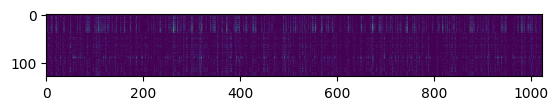

In [31]:
plt.imshow(bottleneck['sub-CON001_ses-control_task-rest_run-0_bold_both.npz']['bottleneck_right'])

In [4]:
import os
import glob
import numpy as np
import tensorflow as tf
from scipy.stats import pearsonr
from collections import defaultdict
import pickle

# -------- CONFIG --------
model_path    = "/mnt/compneuro/deepmreye_finetuning/two_stream_deepmreye.h5"
stroke_root   = "/mnt/compneuro/deepmreye_finetuning/stroke_nifti/"

# Load model
inference_model = tf.keras.models.load_model(model_path, compile=False)
print("Model loaded successfully.")

# --------- 1A. Bottleneck feature extractor ------------------
# Use dense_b_right / dense_b_left as the bottleneck layers
try:
    bottleneck_right = tf.keras.Model(
        inputs  = inference_model.input,
        outputs = inference_model.get_layer('dense_b_right').output
    )
    bottleneck_left  = tf.keras.Model(
        inputs  = inference_model.input,
        outputs = inference_model.get_layer('dense_b_left').output
    )
except ValueError as e:
    # In case you ever change layer names, this will remind you
    raise ValueError(
        "Pick appropriate bottleneck layers from your model, e.g.:\n"
        f"Existing layers: {list(l.name for l in inference_model.layers)}."
    ) from e

print("Bottleneck models created for right and left eye streams.")

# ---------- 1. Collect all *run-0_bold_both.npz files ----------
both_files = sorted(glob.glob(
    os.path.join(stroke_root, "**", "*run-0_bold_both.npz"),
    recursive=True
))
print(f"\nFound {len(both_files)} _both.npz files:")
for f in both_files:
    print(" ", os.path.basename(f))


# ---------- 2. Data loader for stroke (no labels) ----------
def load_stroke_both_npz(fp):
    """
    Load combined eye mask npz (no labels).
    data_XXXX shape: (47, 29, 18)
    Returns right (T, 23, 29, 18, 1), left (T, 23, 29, 18, 1)
    """
    d = np.load(fp)
    data_keys = sorted(
        [k for k in d.keys() if k.startswith('data_')],
        key=lambda k: int(k.split('_')[1])
    )
    right_list, left_list = [], []
    for dk in data_keys:
        tr = d[dk]   # (47, 29, 18)
        right_list.append(tr[1:24,  :, :][..., np.newaxis].astype(np.float32))
        left_list.append( tr[24:47, :, :][..., np.newaxis].astype(np.float32))
    return (np.array(right_list,  dtype=np.float32),
            np.array(left_list,   dtype=np.float32))


# ---------- 3. Global storage for CNN internal features ----------
# We'll build: file_basename → dict with bottleneck feature vectors
stroke_bottleneck = {}  # file_basename → dict of arrays

all_pred_right = []
all_pred_left  = []
per_file_results = []

print(f"\n{'File':45s} | {'N':>5}")
print("-" * 55)

for fp in both_files:
    basename = os.path.basename(fp)
    rights, lefts = load_stroke_both_npz(fp)
    T = rights.shape[0]
    if T == 0:
        print(f"  Skipping (no valid TRs): {basename}")
        continue

    # --- Get bottleneck features instead of predictions ---
    # Right‑eye bottleneck (N_TR, D_bottleneck)
    if hasattr(bottleneck_right, 'predict_on_batch'):
        b_right = bottleneck_right.predict_on_batch([rights, lefts])   # usually uses right input
    else:
        b_right = bottleneck_right.predict([rights, lefts], verbose=0)
    # Left‑eye bottleneck
    if hasattr(bottleneck_left, 'predict_on_batch'):
        b_left  = bottleneck_left.predict_on_batch([rights, lefts])
    else:
        b_left  = bottleneck_left.predict([rights, lefts], verbose=0)

    # Optional: keep old predictions too (for comparison)
    preds           = inference_model.predict([rights, lefts], verbose=0)
    gaze_right_pred = preds[0]   # (T, 2)
    gaze_left_pred  = preds[1]   # (T, 2)

    # Store per‑file bottleneck bundle
    stroke_bottleneck[basename] = {
        'bottleneck_right': b_right,   # (T, D_bottleneck)
        'bottleneck_left':  b_left,    # (T, D_bottleneck)
        'T':                T,
        # Optionally keep the predictions as well
        'pred_x_right': gaze_right_pred[:, 0],
        'pred_y_right': gaze_right_pred[:, 1],
        'pred_x_left':  gaze_left_pred[:, 0],
        'pred_y_left':  gaze_left_pred[:, 1],
    }

    # For later aggregation (right–left CNN prediction consistency)
    all_pred_right.append(gaze_right_pred)
    all_pred_left.append(gaze_left_pred)

    # Right–left eye prediction consistency per file (still on predictions)
    if T > 2:
        rX_RL, _ = pearsonr(gaze_right_pred[:, 0], gaze_left_pred[:, 0])
        rY_RL, _ = pearsonr(gaze_right_pred[:, 1], gaze_left_pred[:, 1])
    else:
        rX_RL = np.nan
        rY_RL = np.nan

    per_file_results.append({
        'file': basename,
        'N': T,
        'rX_RL': rX_RL,
        'rY_RL': rY_RL,
    })

    print(f"{basename:45s} | {T:5d}")

# ---------- 4. Aggregate right–left CNN prediction consistency ----------
all_pred_right = np.concatenate(all_pred_right, axis=0)
all_pred_left  = np.concatenate(all_pred_left,  axis=0)

rX_RL_agg, _ = pearsonr(all_pred_right[:, 0], all_pred_left[:, 0])  # X
rY_RL_agg, _ = pearsonr(all_pred_right[:, 1], all_pred_left[:, 1])  # Y

print("\n========= AGGREGATE SUMMARY (stroke, both eyes) =========")
print(f"Total test TRs: {len(all_pred_right)}")
print(f"\n--- Right vs Left eye prediction consistency (CNN only) ---")
print(f"{'Pearson r (X: right pred vs left pred)':45s} {rX_RL_agg:12.3f}")
print(f"{'Pearson r (Y: right pred vs left pred)':45s} {rY_RL_agg:12.3f}")


# ---------- 5. Per‑file CNN prediction consistency (sorted) ----------
per_file_results_sorted = sorted(
    per_file_results,
    key=lambda x: x.get('rX_RL', -np.inf),
    reverse=True
)

print("\n========= PER-FILE RESULTS (sorted by rX_RL) =========")
print(f"{'File':45s} | {'N':>5} | {'rX_RL':>8} | {'rY_RL':>8}")
print("-" * 75)
for r in per_file_results_sorted:
    print(f"{r['file']:45s} | {r['N']:5d} | "
          f"{r['rX_RL']:8.3f} | {r['rY_RL']:8.3f}")


# ---------- 6. Save bottleneck + prediction features ---------------
save_path_bneck = "/mnt/compneuro/deepmreye_finetuning/stroke_bottleneck.pkl"
with open(save_path_bneck, "wb") as f:
    pickle.dump(stroke_bottleneck, f)

print(f"\nSaved stroke_bottleneck to:\n  {save_path_bneck}")

# Optional: also keep what you had before (for backward compatibility)
save_path_pred = "/mnt/compneuro/deepmreye_finetuning/stroke_predictions.pkl"
stroke_predictions = {}
for basename, d in stroke_bottleneck.items():
    stroke_predictions[basename] = {
        key: d[key] for key in [
            'pred_x_right', 'pred_y_right',
            'pred_x_left',  'pred_y_left',
            'T'
        ]
    }
with open(save_path_pred, "wb") as f:
    pickle.dump(stroke_predictions, f)
print(f"Also saved stroke_predictions (back compat) to:\n  {save_path_pred}")

Model loaded successfully.
Bottleneck models created for right and left eye streams.

Found 418 _both.npz files:
  sub-CON001_ses-control_task-rest_run-0_bold_both.npz
  sub-CON002_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON002_ses-control_task-rest_run-0_bold_both.npz
  sub-CON003_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON003_ses-control_task-rest_run-0_bold_both.npz
  sub-CON004_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON005_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON005_ses-control_task-rest_run-0_bold_both.npz
  sub-CON006_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON006_ses-control_task-rest_run-0_bold_both.npz
  sub-CON007_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON007_ses-control_task-rest_run-0_bold_both.npz
  sub-CON008_ses-control_task-rest_run-0_bold_both.npz
  sub-CON009_ses-control2_task-rest_run-0_bold_both.npz
  sub-CON009_ses-control_task-rest_run-0_bold_both.npz
  sub-CON010_ses-control2_task-rest_run-0_bold_both.npz

In [37]:
rows = []

for basename, d in stroke_bottleneck.items():
    # Parse ID and Session from basename
    # e.g. 'sub-CON001_ses-acute_task-rest_run-0_bold_both.npz'
    id_match  = re.search(r'sub-([^_]+)', basename)
    ses_match = re.search(r'ses-([^_]+)', basename)
    if not id_match or not ses_match:
        continue
    ID = id_match.group(1)
    Session = ses_match.group(1)

    b_right = d['bottleneck_right']  # (128, 1024)
    b_left  = d['bottleneck_left']   # (128, 1024)

    # Mean and std per eye
    b_right_mean = b_right.mean(axis=0)  # (1024,)
    b_right_std  = b_right.std(axis=0)   # (1024,)
    b_left_mean  = b_left.mean(axis=0)
    b_left_std   = b_left.std(axis=0)

    # Concatenate: each session has 4×1024 features
    b_concat = np.concatenate([
        b_right_mean, b_right_std,
        b_left_mean,  b_left_std
    ])  # (4096,)

    rows.append({
        'ID':      ID,
        'Session': Session,
        'bottleneck_flat': b_concat,
    })

bneck_df = pd.DataFrame(rows)
print("Bottleneck‑aggregated table:", bneck_df.shape)

Bottleneck‑aggregated table: (418, 3)


In [38]:
bneck_with_clinical = bneck_df.merge(
    stroke_csv[['ID', 'Session', 'nih_total', 'lesion_size', 'subj_type']],
    on=['ID', 'Session'],
    how='left'
)

# Keep stroke subjects (subj_type == 0) for clinical prediction
stroke_only = bneck_with_clinical[bneck_with_clinical['subj_type'] == 0].copy()
print("Stroke‑only sessions:", len(stroke_only))

# Drop rows without NIH or lesion
stroke_only = stroke_only.dropna(subset=['nih_total', 'lesion_size'])
print("After dropping NAs:", len(stroke_only))

Stroke‑only sessions: 326
After dropping NAs: 241


In [39]:
X_bneck = np.stack(stroke_only['bottleneck_flat'].values)  # (N_sessions, 4096)
y_nih   = stroke_only['nih_total'].values
y_lesion= stroke_only['lesion_size'].values

# Optional: Z‑score bottleneck features (highly recommended)
scaler = StandardScaler()
X_bneck_z = scaler.fit_transform(X_bneck)

NameError: name 'StandardScaler' is not defined

(270, 47, 29, 18)
(270, 23, 29, 18)
(270, 23, 29, 18)


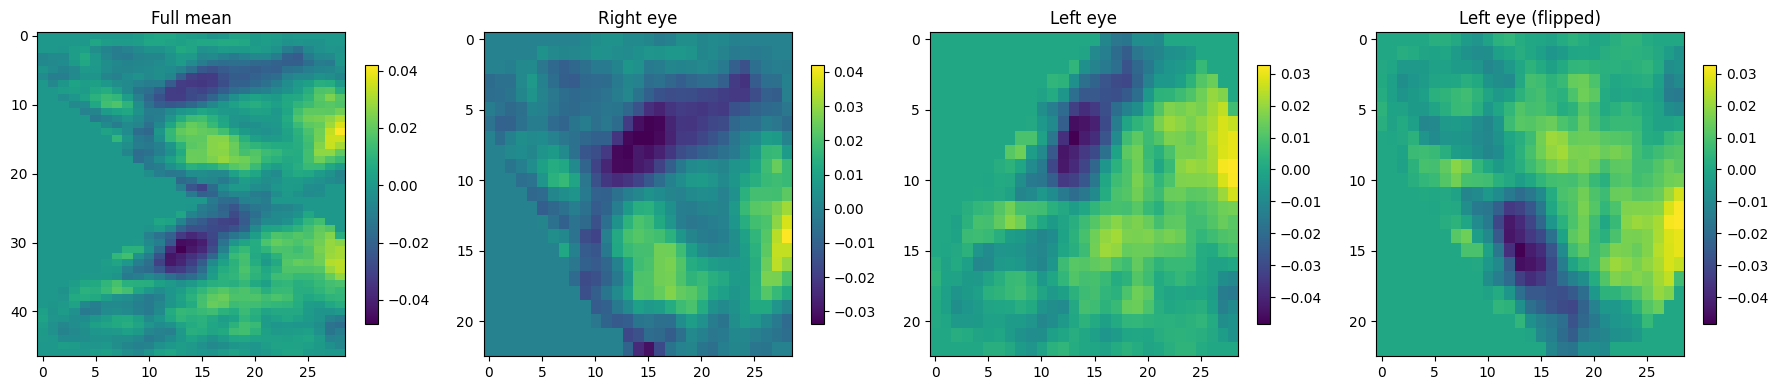

In [4]:
import numpy as np
import matplotlib.pyplot as plt
example_data = np.load('/mnt/compneuro/deepmreye_finetuning/processed_data/dataset1_guided_fixations/sub-NDARBE123PWH.npz')

data_keys  = sorted([k for k in example_data.keys() if k.startswith('data_')],
                    key=lambda k: int(k.split('_')[1]))
label_keys = sorted([k for k in example_data.keys() if k.startswith('label_')],
                    key=lambda k: int(k.split('_')[1]))
n_trs = len(data_keys)
gaze  = np.array([np.median(example_data[k], axis=0) for k in label_keys])

# ── Subject mean image as reference ──────────────────────────────────────────
all_trs = np.array([example_data[k].astype(float) for k in data_keys])  # (n_trs, 47, 29, 18)
print(all_trs.shape)

right_eye = all_trs[:, :23, :, :]
left_eye  = all_trs[:, 24:, :, :]
print(right_eye.shape)
print(left_eye.shape)

images = [
    (np.mean(all_trs,                  axis=(0, 3)), "Full mean"),
    (np.mean(right_eye,                axis=(0, 3)), "Right eye"),
    (np.mean(left_eye,                 axis=(0, 3)), "Left eye"),
    (np.mean(left_eye[:, ::-1, :, :], axis=(0, 3)), "Left eye (flipped)"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (img, title) in zip(axes, images):
    im = ax.imshow(img, aspect="auto")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

In [79]:
mid

23

In [5]:
import os
import glob
import numpy as np

src_root = '/mnt/compneuro/deepmreye_finetuning/processed_data/'
dst_root = '/mnt/compneuro/deepmreye_finetuning/Cemal/processed_data_single_flipped_eyes/'

datasets = sorted(os.listdir(src_root))
print(f"Datasets: {datasets}")

for dataset in datasets:
    src_dir = os.path.join(src_root, dataset)
    dst_dir = os.path.join(dst_root, dataset)
    os.makedirs(dst_dir, exist_ok=True)

    npz_files = sorted(glob.glob(os.path.join(src_dir, '*.npz')))
    print(f"\n{dataset}: {len(npz_files)} files")

    for npz_path in npz_files:
        base     = os.path.basename(npz_path).replace('.npz', '')
        out_right = os.path.join(dst_dir, f'{base}_right_flipped.npz')
        out_left  = os.path.join(dst_dir, f'{base}_left.npz')

        # Skip if both already exist
        #if os.path.exists(out_right) and os.path.exists(out_left):
         #   print(f"  ↷ Skip (exists): {base}")
        #    continue

        try:
            f         = np.load(npz_path, allow_pickle=True)
            data_keys = sorted([k for k in f.keys() if k.startswith('data_')],
                               key=lambda k: int(k.split('_')[1]))
            label_keys = sorted([k for k in f.keys() if k.startswith('label_')],
                                key=lambda k: int(k.split('_')[1]))

            # Check spatial dims from first data entry — shape (X, Y, Z)
            sample     = f[data_keys[0]]          # (47, 29, 18)
            mid        = sample.shape[0] // 2     # = 23
            # right: [:mid]  → (23, 29, 18)
            # left:  [mid+1:] → (23, 29, 18)  — drop central voxel

            right_dict = {}
            left_dict  = {}

            for dk, lk in zip(data_keys, label_keys):
                tr    = f[dk]    # (47, 29, 18)
                label = f[lk]    # (10, 2)

                right_patch        = tr[1:24, :, :][::-1, :, :]           # (23, 29, 18) mirrored
                left_patch_flipped = tr[24:, :, :]  # (23, 29, 18) 

                idx = dk.split('_')[1]
                right_dict[f'data_{idx}']  = right_patch
                right_dict[f'label_{idx}'] = label
                left_dict[f'data_{idx}']   = left_patch_flipped
                left_dict[f'label_{idx}']  = label

            np.savez(out_right, **right_dict)
            np.savez(out_left,  **left_dict)
            print(f"  ✓ {base}  patch shape: right={right_patch.shape} left={left_patch_flipped.shape}")

        except Exception as e:
            print(f"  ✗ {base}: {e}")

print(f"\n{'='*60}\nDone. Output: {dst_root}")

Datasets: ['dataset1_guided_fixations', 'dataset2_pursuit', 'dataset3_pursuit', 'dataset4_pursuit', 'dataset5_free_viewing', 'dataset7_resting_state', 'stroke_dataset']

dataset1_guided_fixations: 170 files
  ✓ sub-NDARAA948VFH  patch shape: right=(23, 29, 18) left=(23, 29, 18)
  ✓ sub-NDARAC349YUC  patch shape: right=(23, 29, 18) left=(23, 29, 18)
  ✓ sub-NDARAC350BZ0  patch shape: right=(23, 29, 18) left=(23, 29, 18)
  ✓ sub-NDARAC495TJ2  patch shape: right=(23, 29, 18) left=(23, 29, 18)
  ✓ sub-NDARAD615WLJ  patch shape: right=(23, 29, 18) left=(23, 29, 18)
  ✓ sub-NDARAE012DGA  patch shape: right=(23, 29, 18) left=(23, 29, 18)
  ✓ sub-NDARAE358VBE  patch shape: right=(23, 29, 18) left=(23, 29, 18)
  ✓ sub-NDARAG115LZP  patch shape: right=(23, 29, 18) left=(23, 29, 18)
  ✓ sub-NDARAG340ERT  patch shape: right=(23, 29, 18) left=(23, 29, 18)
  ✓ sub-NDARAH503YG1  patch shape: right=(23, 29, 18) left=(23, 29, 18)
  ✓ sub-NDARAH948UF0  patch shape: right=(23, 29, 18) left=(23, 29, 18)
 

In [6]:
import tensorflow as tf

# List physical GPUs
gpus = tf.config.list_physical_devices('GPU')
print("GPUs found:", gpus)

2026-04-03 13:30:56.658347: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-03 13:30:56.721409: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-03 13:30:56.721478: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-03 13:30:56.725598: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-03 13:30:56.743178: I tensorflow/core/platform/cpu_feature_guar

GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-04-03 13:31:03.571749: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-03 13:31:03.704414: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-03 13:31:03.706215: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [7]:
import os
import numpy as np
from deepmreye import preprocess, train, analyse
from deepmreye.util import model_opts, data_generator
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt 
import pandas as pd
import random
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import random
from collections import defaultdict
import re
from scipy.stats import pearsonr


# Define options for model training -- using default settings 
opts = model_opts.get_opts()
print(opts)

{'kernel': 3, 'lr': 2e-05, 'filters': 32, 'multiplier': 2, 'depth': 4, 'dropout_rate': 0.1, 'num_dense': 2, 'num_fc': 1024, 'gaussian_noise': 0, 'activation': <function mish at 0x7ff3c96dfe20>, 'groups': 8, 'inner_timesteps': 10, 'loss_euclidean': 1, 'loss_confidence': 0.1, 'epochs': 25, 'steps_per_epoch': 1500, 'validation_steps': 1500, 'train_test_split': 0.6, 'batch_size': 8, 'mixed_batches': True, 'mc_dropout': False, 'rotation_x': 5, 'rotation_y': 5, 'rotation_z': 5, 'shift': 4, 'zoom': 0.15}


In [12]:
all_files = []
for root, dirs, files in os.walk('/mnt/compneuro/deepmreye_finetuning/Cemal/processed_data_single_flipped_eyes/'):
    if 'dataset7_resting_state' in root:
        continue
    for name in files:
        all_files.append(os.path.join(root, name))
        print(os.path.join(root, name))

/mnt/compneuro/deepmreye_finetuning/Cemal/processed_data_single_flipped_eyes/dataset1_guided_fixations/sub-NDARAA948VFH_right_flipped.npz
/mnt/compneuro/deepmreye_finetuning/Cemal/processed_data_single_flipped_eyes/dataset1_guided_fixations/sub-NDARAA948VFH_left.npz
/mnt/compneuro/deepmreye_finetuning/Cemal/processed_data_single_flipped_eyes/dataset1_guided_fixations/sub-NDARAC349YUC_right_flipped.npz
/mnt/compneuro/deepmreye_finetuning/Cemal/processed_data_single_flipped_eyes/dataset1_guided_fixations/sub-NDARAC349YUC_left.npz
/mnt/compneuro/deepmreye_finetuning/Cemal/processed_data_single_flipped_eyes/dataset1_guided_fixations/sub-NDARAC350BZ0_right_flipped.npz
/mnt/compneuro/deepmreye_finetuning/Cemal/processed_data_single_flipped_eyes/dataset1_guided_fixations/sub-NDARAC350BZ0_left.npz
/mnt/compneuro/deepmreye_finetuning/Cemal/processed_data_single_flipped_eyes/dataset1_guided_fixations/sub-NDARAC495TJ2_right_flipped.npz
/mnt/compneuro/deepmreye_finetuning/Cemal/processed_data_sing

In [20]:
def get_subject_id(filepath):
    """
    Works for ALL naming conventions:
      sub-NDARAA948VFH_right.npz      → sub-NDARAA948VFH
      AS_18_08_14_right.npz           → AS_18_08_14
      S01_ET_right.npz                → S01_ET
      04_3I9G_right.npz               → 04_3I9G
      S21_right.npz                   → S21
    """
    basename = os.path.basename(filepath).replace('.npz', '')
    # Strip exactly _right or _left_flipped from the END
    for suffix in ('_left', '_right_flipped'):
        if basename.endswith(suffix):
            return basename[:-len(suffix)]
    return None  # should never happen if files are named correctly


from collections import Counter

# Recompute with fixed extractor
subject_file_counts = Counter(get_subject_id(f) for f in all_files)
failed = [f for f in all_files if get_subject_id(f) is None]

print(f"Unique subject IDs:  {len(subject_file_counts)}")
print(f"Total files:         {sum(subject_file_counts.values())}")
print(f"Failed extractions:  {len(failed)}")

# All subjects should now have exactly 2 files
for count_val, n in sorted(Counter(subject_file_counts.values()).items()):
    print(f"  {n} subjects with {count_val} files")

# Redo train/test split
rng = np.random.default_rng(seed=42)
all_subjects = np.array(sorted(subject_file_counts.keys()))
rng.shuffle(all_subjects)

split_idx      = int(0.8 * len(all_subjects))
train_subjects = set(all_subjects[:split_idx])
test_subjects  = set(all_subjects[split_idx:])

train_files = [f for f in all_files if get_subject_id(f) in train_subjects]
test_files  = [f for f in all_files if get_subject_id(f) in test_subjects]

print(f"\nTrain subjects: {len(train_subjects)}  →  {len(train_files)} files")
print(f"Test  subjects: {len(test_subjects)}  →  {len(test_files)} files")

overlap = set(get_subject_id(f) for f in train_files) & set(get_subject_id(f) for f in test_files)
print(f"Leakage check — overlapping subjects: {len(overlap)}  ← must be 0")

Unique subject IDs:  264
Total files:         528
Failed extractions:  0
  264 subjects with 2 files

Train subjects: 211  →  422 files
Test  subjects: 53  →  106 files
Leakage check — overlapping subjects: 0  ← must be 0


In [21]:
# I want to use the same train/test splits across 3 models (trained on both eyes, left eye, and right eye).
# Therefore I slightly edited the native function in a way that it accepts predefined train and test lists.

def create_holdout_generators(datasets=None, train_split=0.6, train_list=None, test_list=None, **args):
    # If train_list and test_list are provided, use them directly
    if train_list is not None and test_list is not None:
        full_training_list = train_list
        full_testing_list = test_list
    else:
        # Otherwise, build from datasets
        full_training_list, full_testing_list = list(), list()
        for fn_data in datasets:
            this_file_list = [fn_data + p for p in os.listdir(fn_data)]
            np.random.shuffle(this_file_list)
            split_idx = int(train_split * len(this_file_list))
            this_training_list = this_file_list[0:split_idx]
            this_testing_list = this_file_list[split_idx:]
            full_training_list.extend(this_training_list)
            full_testing_list.extend(this_testing_list)

    # Call create_generators with the final lists
    (
        training_generator,
        testing_generator,
        single_testing_generators,
        single_testing_names,
        single_training_generators,
        single_training_names,
    ) = data_generator.create_generators(full_training_list, full_testing_list, **args)

    return (
        training_generator,
        testing_generator,
        single_testing_generators,
        single_testing_names,
        single_training_generators,
        single_training_names,
        full_testing_list,
        full_training_list,
    )


# This function converts paths of the train and test splits from 'both eyes' to 'right' or  'left' eyes
def get_divided_paths(file_list, eye="left"):
    """
    Convert a list of original .npz file paths to divided left or right paths.

    Parameters:
        file_list (list of str): original file paths
        eye (str): "left" or "right"

    Returns:
        list of str: paths to divided files
    """
    if eye not in ["left", "right"]:
        raise ValueError('eye must be "left" or "right"')

    divided_paths = []
    for orig_path in file_list:
        parts = orig_path.split(os.sep)
        dataset_folder = parts[5]  # e.g., dataset1_guided_fixations
        filename = os.path.basename(orig_path)
        base = filename.replace(".npz", "")

        divided_path = os.path.join(f"/mnt/compneuro/deepmreye_finetuning/processed_data_separate_eyes/{eye}",dataset_folder, f"{base}_{eye}.npz")
        divided_paths.append(divided_path)

    return divided_paths

# Creating a static visualization 
def visualise_predictions_static(
    evaluation, scores, subject_index=None,
    color="rgb(0, 150, 175)", bg_color="rgb(247,247,247)",
    ylim=[-6,6], subTR=False
):
    """
    Static version of visualise_predictions_slider.
    Shows:
        - Model performance across participants (left)
        - Predicted vs true gaze for a chosen participant (right)

    Args:
        evaluation (dict): dict with subject -> {'real_y', 'pred_y'}
        scores (dict): dict with subject -> score arrays
        subject_index (int or None): index of subject in list to plot.
                                     If None, picks a random subject.
        color (str): main line color
        bg_color (str): background color
        ylim (list): y-axis limits for gaze plots
        subTR (bool): reshape option
    """
    # Prepare model performance data
    all_scores = [item.values for _, item in scores.items()]
    all_scores = np.array(all_scores)
    to_plot = np.concatenate((all_scores[..., 2], all_scores[..., 5]), axis=0)  # Pearson & R2
    x_labels = ["Pearson"] * all_scores[..., 2].shape[0] + ["R^2-Score"] * all_scores[..., 5].shape[0]
    participants = list(evaluation.keys()) * 2

    # Select participant
    subjects = list(evaluation.keys())
    if subject_index is None:
        rand_sub = random.choice(subjects)
    else:
        rand_sub = subjects[subject_index]

    item = evaluation[rand_sub]
    if subTR:
        this_real = np.reshape(item["real_y"], (item["real_y"].shape[0]*item["real_y"].shape[1], -1))
        this_pred = np.reshape(item["pred_y"], (item["pred_y"].shape[0]*item["pred_y"].shape[1], -1))
    else:
        this_real = np.nanmedian(item["real_y"], axis=1)
        this_pred = np.nanmedian(item["pred_y"], axis=1)

    # Create subplot
    fig = make_subplots(
        rows=2, cols=4,
        horizontal_spacing=0.05, vertical_spacing=0.15,
        shared_xaxes="columns",
        specs=[[{"rowspan": 2, "colspan": 2}, None, {"colspan": 2}, None],
               [None, None, {"colspan": 2}, None]]
    )

    # Left: box plots of model performance
    for i in range(4):
        fig.add_trace(
            go.Box(
                y=to_plot[:, i],
                x=x_labels,
                boxpoints="all",
                marker=dict(opacity=0.65, color=color, line=dict(color="rgb(0,0,0)", width=2)),
                line=dict(color="rgb(0,0,0)"),
                fillcolor="rgb(180,180,180)",
            ),
            row=1, col=1
        )

    # Right: predicted vs true gaze for selected participant
    fig.add_trace(go.Scatter(
        x=np.arange(len(this_real[:,0])),
        y=this_real[:,0],
        mode="lines",
        line_color="rgb(0,0,0)",
        opacity=0.5,
        line_width=3,
        name="True X"
    ), row=1, col=3)

    fig.add_trace(go.Scatter(
        x=np.arange(len(this_pred[:,0])),
        y=this_pred[:,0],
        mode="lines",
        line_color=color,
        opacity=0.85,
        line_width=3,
        name="Predicted X"
    ), row=1, col=3)

    fig.add_trace(go.Scatter(
        x=np.arange(len(this_real[:,1])),
        y=this_real[:,1],
        mode="lines",
        line_color="rgb(0,0,0)",
        opacity=0.5,
        line_width=3,
        name="True Y"
    ), row=2, col=3)

    fig.add_trace(go.Scatter(
        x=np.arange(len(this_pred[:,1])),
        y=this_pred[:,1],
        mode="lines",
        line_color=color,
        opacity=0.85,
        line_width=3,
        name="Predicted Y"
    ), row=2, col=3)

    # Layout and aesthetics
    annotations = [
        dict(x=0.10, y=1.08, xref="paper", yref="paper",
             text="<b>Model Performance across participants</b>",
             font=dict(size=20), showarrow=False),
        dict(x=0.855, y=1.08, xref="paper", yref="paper",
             text=f"<b>Predicted vs True gaze ({os.path.splitext(os.path.basename(rand_sub))[0]})</b>",
             font=dict(size=20), showarrow=False)
    ]

    fig.update_layout(
        showlegend=False,
        margin=dict(t=70, l=50, b=50, r=50),
        plot_bgcolor=bg_color,
        paper_bgcolor=bg_color,
        boxmode="group",
        autosize=False,
        width=1600,
        height=650,
        annotations=annotations
    )

    fig.update_yaxes(range=[-1.1,1.1], row=1, col=1)
    fig.update_yaxes(range=ylim, row=1, col=3, ticksuffix="°", title=dict(text="X", font=dict(size=20)))
    fig.update_yaxes(range=ylim, row=2, col=3, ticksuffix="°", title=dict(text="Y", font=dict(size=20)))
    fig.update_xaxes(range=[-2, 150+2], row=1, col=3, title=dict(text="Functional Volume (TR)", font=dict(size=20)))
    fig.update_xaxes(range=[-2, 150+2], row=2, col=3)

    return fig


In [22]:
# Create the generators fro the model trained on both eyes 
generators_single_flipped = create_holdout_generators(train_list=train_files, test_list=test_files, batch_size=opts['batch_size'], augment_list=((opts['rotation_x'], opts['rotation_y'], opts['rotation_z']), opts['shift'], opts['zoom']), mixed_batches=True)

Training set (/mnt/compneuro/deepmreye_finetuning/Cemal/processed_data_single_flipped_eyes/dataset1_guided_fixations) contains 422 subjects: 
['sub-NDARAA948VFH_right_flipped', 'sub-NDARAA948VFH_left',
 'sub-NDARAC349YUC_right_flipped', 'sub-NDARAC349YUC_left',
 'sub-NDARAC350BZ0_right_flipped', 'sub-NDARAC350BZ0_left',
 'sub-NDARAD615WLJ_right_flipped', 'sub-NDARAD615WLJ_left',
 'sub-NDARAE012DGA_right_flipped', 'sub-NDARAE012DGA_left',
 'sub-NDARAE358VBE_right_flipped', 'sub-NDARAE358VBE_left',
 'sub-NDARAG115LZP_right_flipped', 'sub-NDARAG115LZP_left',
 'sub-NDARAH503YG1_right_flipped', 'sub-NDARAH503YG1_left',
 'sub-NDARAH948UF0_right_flipped', 'sub-NDARAH948UF0_left',
 'sub-NDARAK738BGC_right_flipped', 'sub-NDARAK738BGC_left',
 'sub-NDARAP176AD1_right_flipped', 'sub-NDARAP176AD1_left',
 'sub-NDARAP785CTE_right_flipped', 'sub-NDARAP785CTE_left',
 'sub-NDARAT358XM9_right_flipped', 'sub-NDARAT358XM9_left',
 'sub-NDARAX272ZJL_right_flipped', 'sub-NDARAX272ZJL_left',
 'sub-NDARBE123PWH

In [23]:
# Train model
(model_single_flipped, model_inference_single_flipped) = train.train_model(dataset='single_flipped', generators=generators_single_flipped, opts=opts, use_multiprocessing=True,
                                            return_untrained=False, verbose=1, save=True)

Input shape (8, 23, 29, 18, 1), Output shape (8, 10, 2)
Subjects in training set: 422, Subjects in test set: 106


2026-04-03 13:38:47.610657: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-03 13:38:47.614802: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-03 13:38:47.617773: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Epoch 1/25


2026-04-03 13:39:01.679237: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-04-03 13:39:01.826197: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-03 13:39:02.085205: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-03 13:39:03.977843: I external/local_xla/xla/service/service.cc:168] XLA service 0x55793d8816a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-03 13:39:03.977917: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A4000, Compute Capability 8.6
2026-04-03 13:39:03.993963: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775223544.152847 3120578 device_compiler.h:186] 

1500/1500 [==============================] - 238s 140ms/step - loss: 7.7428 - val_loss: 6.8542 - lr: 2.0000e-05
Epoch 2/25
1500/1500 [==============================] - 162s 108ms/step - loss: 7.3653 - val_loss: 6.5095 - lr: 1.9279e-05
Epoch 3/25
1500/1500 [==============================] - 165s 110ms/step - loss: 7.1350 - val_loss: 6.5149 - lr: 1.8554e-05
Epoch 4/25
1500/1500 [==============================] - 165s 110ms/step - loss: 7.0795 - val_loss: 6.3191 - lr: 1.7826e-05
Epoch 5/25
1500/1500 [==============================] - 165s 110ms/step - loss: 6.9250 - val_loss: 6.3148 - lr: 1.7095e-05
Epoch 6/25
1500/1500 [==============================] - 164s 110ms/step - loss: 6.9608 - val_loss: 6.2514 - lr: 1.6361e-05
Epoch 7/25
1500/1500 [==============================] - 164s 109ms/step - loss: 6.8397 - val_loss: 6.2104 - lr: 1.5623e-05
Epoch 8/25
1500/1500 [==============================] - 159s 106ms/step - loss: 6.8917 - val_loss: 6.1339 - lr: 1.4881e-05
Epoch 9/25
1500/1500 [=====

In [24]:
#Evaluate the model 
(evaluation_single_flipped, scores_single_flipped) = train.evaluate_model(dataset='single_flipped', model=model_inference_single_flipped, generators=generators_single_flipped, save=True, model_description='', verbose=2, percentile_cut=80)

1 / 106 - Model Performance for /mnt/compneuro/deepmreye_finetuning/Cemal/processed_data_single_flipped_eyes/dataset1_guided_fixations/sub-NDARAC495TJ2_right_flipped.npz
              Pearson             R^2-Score             Eucl. Error             
                    X     Y  Mean         X     Y  Mean        Mean Median   Std
Default         0.319 0.623 0.471     0.088 0.387 0.238       6.789  6.037 3.956
Default subTR   0.319 0.623 0.471     0.088 0.387 0.237       6.790  6.038 3.955
Refined         0.396 0.575 0.485     0.148 0.324 0.236       6.293  5.575 3.979
Refined subTR   0.391 0.587 0.489     0.144 0.340 0.242       6.293  5.586 3.981


2 / 106 - Model Performance for /mnt/compneuro/deepmreye_finetuning/Cemal/processed_data_single_flipped_eyes/dataset1_guided_fixations/sub-NDARAC495TJ2_left.npz
              Pearson             R^2-Score             Eucl. Error             
                    X     Y  Mean         X     Y  Mean        Mean Median   Std
Default         0.5

In [69]:
fig = visualise_predictions_static(evaluation_single_flipped, scores_single_flipped, color="rgb(0, 150, 175)", bg_color="rgb(255,255,255)", ylim=[-11, 11], subject_index=1)
fig.show()

In [27]:
import numpy as np
from scipy.stats import pearsonr

# Extract subject ID and eye side from filepath
def parse_filepath(fp):
    base = os.path.basename(fp).replace('.npz', '')
    if base.endswith('_left'):
        return base[:-len('_left')], 'left'
    elif base.endswith('_right_flipped'):
        return base[:-len('_right_flipped')], 'right'
    return None, None

# Group files by subject
from collections import defaultdict
subject_evals = defaultdict(dict)

for fp, eval_data in evaluation_single_flipped.items():
    sub_id, eye = parse_filepath(fp)
    if sub_id and eye:
        dataset = [p for p in fp.split('/') if 'dataset' in p][0]
        key = f"{dataset}/{sub_id}"
        subject_evals[key][eye] = eval_data

# Compute right-left correlation of predicted series
results = []
for key, eyes in subject_evals.items():
    if 'right' not in eyes or 'left' not in eyes:
        continue

    # pred_y shape: (n_runs, n_subTR, 2) → take mean over subTR dim → (n_runs, 2)
    pred_right = eyes['right']['pred_y'].mean(axis=1)  # (n_runs, 2)
    pred_left  = eyes['left']['pred_y'].mean(axis=1)   # (n_runs, 2)

    # Correlate X and Y timeseries between eyes
    min_len = min(len(pred_right), len(pred_left))
    r_x, _ = pearsonr(pred_right[:min_len, 0], pred_left[:min_len, 0])
    r_y, _ = pearsonr(pred_right[:min_len, 1], pred_left[:min_len, 1])

    # Also correlate each eye's prediction with its own real_y
    real = eyes['right']['real_y'].mean(axis=1)  # labels are same for both eyes

    results.append({
        'subject':        key,
        'r_left_right_X': r_x,
        'r_left_right_Y': r_y,
        'r_left_right_mean': np.mean([r_x, r_y])
    })

import pandas as pd
df = pd.DataFrame(results).sort_values('r_left_right_mean', ascending=False)

print(f"Mean right-left prediction correlation:")
print(f"  X axis: {df['r_left_right_X'].mean():.3f} ± {df['r_left_right_X'].std():.3f}")
print(f"  Y axis: {df['r_left_right_Y'].mean():.3f} ± {df['r_left_right_Y'].std():.3f}")
print(f"  Mean:   {df['r_left_right_mean'].mean():.3f} ± {df['r_left_right_mean'].std():.3f}")
print()
print(df.to_string(index=False))

Mean right-left prediction correlation:
  X axis: 0.458 ± 0.253
  Y axis: 0.847 ± 0.164
  Mean:   0.653 ± 0.186

                                   subject  r_left_right_X  r_left_right_Y  r_left_right_mean
dataset1_guided_fixations/sub-NDARWM656UWL           0.849           0.952              0.901
dataset1_guided_fixations/sub-NDARRX897XV1           0.841           0.936              0.888
dataset1_guided_fixations/sub-NDARLU939YX4           0.791           0.941              0.866
dataset1_guided_fixations/sub-NDARBF805EHN           0.805           0.926              0.865
dataset1_guided_fixations/sub-NDARFU916UZY           0.803           0.922              0.862
dataset1_guided_fixations/sub-NDARRB901DWV           0.760           0.946              0.853
dataset1_guided_fixations/sub-NDARGK041TPB           0.761           0.940              0.851
dataset1_guided_fixations/sub-NDARFJ179MG0           0.700           0.961              0.831
dataset1_guided_fixations/sub-NDARJF517HC

In [28]:
import numpy as np

right_scores = []
left_scores  = []

for fp, df_scores in scores_single_flipped.items():
    if 'dataset1' not in fp:
        continue
    
    # Extract the Refined model, Mean Pearson value
    # df_scores is a DataFrame with rows: Default, Default subTR, Refined, Refined subTR
    # and columns: Pearson X, Pearson Y, Pearson Mean, ...
    refined_pearson_mean = df_scores.loc['Refined', ('Pearson', 'Mean')]
    
    if '_right_flipped' in fp:
        right_scores.append(refined_pearson_mean)
    elif '_left' in fp:
        left_scores.append(refined_pearson_mean)

print(f"Dataset1 — Refined model Pearson (Mean XY):")
print(f"  Right eye: {np.mean(right_scores):.3f} ± {np.std(right_scores):.3f}  (n={len(right_scores)})")
print(f"  Left eye:  {np.mean(left_scores):.3f} ± {np.std(left_scores):.3f}  (n={len(left_scores)})")
print(f"  Difference (right - left): {np.mean(right_scores) - np.mean(left_scores):.3f}")

# Per-subject paired difference to check consistency
paired_diffs = []
for r, l in zip(sorted([s for s in right_scores]), sorted([s for s in left_scores])):
    paired_diffs.append(r - l)

print(f"\n  Paired diff > 0 (right better): {sum(d > 0 for d in paired_diffs)}/{len(paired_diffs)}")
print(f"  Paired diff < 0 (left better):  {sum(d < 0 for d in paired_diffs)}/{len(paired_diffs)}")

Dataset1 — Refined model Pearson (Mean XY):
  Right eye: 0.727 ± 0.161  (n=30)
  Left eye:  0.678 ± 0.178  (n=30)
  Difference (right - left): 0.049

  Paired diff > 0 (right better): 29/30
  Paired diff < 0 (left better):  1/30


In [29]:
# Suggested: report right-left agreement separately per axis
# and flag subjects below a threshold for QC

QC_threshold_X = 0.3   # below this → likely bad data
QC_threshold_Y = 0.6   # below this → likely bad data

flagged = df[(df['r_left_right_X'] < QC_threshold_X) | 
             (df['r_left_right_Y'] < QC_threshold_Y)]
print(f"Flagged subjects: {len(flagged)}")
print(flagged[['subject', 'r_left_right_X', 'r_left_right_Y']])

Flagged subjects: 16
                                       subject  r_left_right_X  r_left_right_Y
43                    dataset4_pursuit/21_STHZ           0.299           0.887
30                dataset2_pursuit/AS_18_08_14           0.265           0.869
7   dataset1_guided_fixations/sub-NDARDA472JE3           0.295           0.815
42                    dataset4_pursuit/20_Q7YI           0.157           0.909
1   dataset1_guided_fixations/sub-NDARAG340ERT           0.118           0.943
49                    dataset4_pursuit/40_OQ93           0.282           0.752
40                     dataset3_pursuit/S36_ET           0.273           0.724
0   dataset1_guided_fixations/sub-NDARAC495TJ2           0.209           0.786
51                   dataset5_free_viewing/S24           0.161           0.822
48                    dataset4_pursuit/39_4EES           0.192           0.784
35                     dataset3_pursuit/S05_ET           0.083           0.779
41                    dataset4_

In [107]:
# These would also be useful
print(model_inference_single_flipped.input_shape)
print(model_inference_single_flipped.output_shape)

# And to see where features live before the prediction head
for i, layer in enumerate(model_inference_single_flipped.layers):
    print(i, layer.name, layer.output_shape)

(None, 23, 29, 18, 1)
[(None, 10, 2), (None, 10)]
0 input_1 [(None, 23, 29, 18, 1)]
1 gaussian_noise (None, 23, 29, 18, 1)
2 conv3d (None, 23, 29, 18, 32)
3 dropout (None, 23, 29, 18, 32)
4 conv3d_1 (None, 23, 29, 18, 32)
5 average_pooling3d (None, 11, 14, 9, 32)
6 group_normalization (None, 11, 14, 9, 32)
7 activation (None, 11, 14, 9, 32)
8 conv3d_3 (None, 11, 14, 9, 64)
9 group_normalization_1 (None, 11, 14, 9, 64)
10 activation_1 (None, 11, 14, 9, 64)
11 conv3d_4 (None, 11, 14, 9, 64)
12 conv3d_2 (None, 11, 14, 9, 64)
13 add (None, 11, 14, 9, 64)
14 conv3d_5 (None, 11, 14, 9, 64)
15 average_pooling3d_1 (None, 5, 7, 4, 64)
16 group_normalization_2 (None, 5, 7, 4, 64)
17 activation_2 (None, 5, 7, 4, 64)
18 conv3d_7 (None, 5, 7, 4, 128)
19 group_normalization_3 (None, 5, 7, 4, 128)
20 activation_3 (None, 5, 7, 4, 128)
21 conv3d_8 (None, 5, 7, 4, 128)
22 conv3d_6 (None, 5, 7, 4, 128)
23 add_1 (None, 5, 7, 4, 128)
24 group_normalization_4 (None, 5, 7, 4, 128)
25 activation_4 (None, 5, 7